# 23 — Damage-Size Sensitivity Analysis

**Origin:** New analysis stage separated from Notebook 05 generation\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/23_damage_size_sensitivity_analysis/`\
**Depends on:** Notebooks 05, 08–17, and 20–22

## Purpose

Measure how restoration quality and Stable Diffusion seed variability change as the damaged area increases.

The analysis uses the controlled damage-size experiment generated by Notebook 05. It compares the same five paintings at seven target damage levels using:

- OpenCV Telea;
- LaMa;
- Stable Diffusion Inpainting using the primary generic prompt and seed `2026`.

Stable Diffusion uncertainty comes from Notebook 22 and uses four seeds per damage-size case.

## Approved evidence population

- 5 painting trajectories;
- 7 ordered damage levels per painting;
- 35 restoration cases;
- 3 evaluated restoration models;
- 105 primary restoration candidates;
- 11 quality anchors;
- 35 Stable Diffusion uncertainty groups;
- 4 seeds per uncertainty group;
- 210 unique unordered seed pairs.

The five paintings—not the 35 cases—are the independent units. Damage levels are repeated observations nested within each painting.

## Main analyses

The notebook will evaluate:

- realised versus requested damage size;
- quality trajectories across damage levels;
- painting-level adverse slopes;
- adjacent-level deterioration;
- paired model contrasts;
- family-balanced rankings by damage level;
- leave-one-painting-out ranking stability;
- Stable Diffusion seed variability across damage levels;
- exploratory associations between mask morphology and outcomes;
- painting-specific trajectories and metric disagreement.

No combined quality score or combined uncertainty index will be created.

## Interpretation limits

- Damage-size effects are estimated from five paintings.
- Painting and category cannot be separated because each category contains one selected painting.
- Style effects are not supported.
- The notebook does not estimate a universal damage threshold.
- Stable Diffusion uncertainty measures repeated-seed variability, not calibrated confidence.
- Runtime is operational evidence and is excluded from quality rankings.
- SDXL has no damage-size population and is outside this analysis.
- Metric results are computational evidence, not conservation approval or proof of historical authenticity.

## Canonical outputs

- `metrics/damage_size_analysis.csv`
- `figures/performance_vs_damage.png`
- `figures/ranking_vs_damage.png`
- `figures/uncertainty_vs_damage.png`
- `reports/damage_size_analysis.html`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads and validates the approved Notebook 23 configuration;
- defines the complete input and output contract;
- reads the current project inventory and evidence-coverage registry;
- checks all direct upstream completion gates;
- verifies the fixed population arithmetic and scientific restrictions;
- creates Notebook 23's owned output directories.

It does not load full metric tables, run statistical analysis, generate figures, or persist canonical outputs.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from either its root or the notebooks directory."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate
    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.damage_size_analysis import (
    ANALYSIS_COLUMNS,
    ANALYSIS_SCHEMA_VERSION,
    CONFIG_SCHEMA_VERSION,
    MODULE_NAME,
    MODULE_VERSION,
    UNCERTAINTY_GROUP_COLUMNS,
    atomic_write_csv,
    benjamini_hochberg,
    build_multi_model_adapter_config,
    build_runtime_evidence,
    compute_adjacent_changes,
    compute_painting_slopes,
    empty_analysis_frame,
    exhaustive_bootstrap_interval,
    exact_sign_flip_test,
    family_balanced_ranks,
    load_damage_size_analysis_config,
    matched_rank_biserial,
    normalise_quality_evidence,
    normalise_uncertainty_evidence,
    resolve_analysis_inputs,
    select_damage_size_population,
    size_and_painting_adjusted_spearman,
    summarise_painting_slopes,
    theil_sen_slope,
    validate_damage_size_analysis,
    validate_damage_size_report_html,
    validate_upstream_run_manifests,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()

print("Notebook 23 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Analysis helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 23 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Analysis helper: restoration_eval.damage_size_analysis 1.0.0


In [2]:
CONFIG_PATH = (
    PROJECT_ROOT / "config" / "evaluation" / "damage_size_analysis.yaml"
)

ANALYSIS_CONFIG = load_damage_size_analysis_config(CONFIG_PATH)
SETTINGS = ANALYSIS_CONFIG["damage_size_analysis"]
INPUT_PATHS = resolve_analysis_inputs(
    ANALYSIS_CONFIG,
    PROJECT_ROOT,
    must_exist=True,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (PROJECT_ROOT / OUTPUT_SPEC["root"]).resolve()

OUTPUT_PATHS = {
    "metrics": OUTPUT_ROOT / OUTPUT_SPEC["metrics_path"],
    "performance_figure": OUTPUT_ROOT / OUTPUT_SPEC["performance_figure_path"],
    "ranking_figure": OUTPUT_ROOT / OUTPUT_SPEC["ranking_figure_path"],
    "uncertainty_figure": OUTPUT_ROOT / OUTPUT_SPEC["uncertainty_figure_path"],
    "report": OUTPUT_ROOT / OUTPUT_SPEC["report_path"],
    "run_manifest": OUTPUT_ROOT / OUTPUT_SPEC["run_manifest_path"],
    "artifacts": OUTPUT_ROOT / OUTPUT_SPEC["artifacts_path"],
    "validation": OUTPUT_ROOT / OUTPUT_SPEC["validation_path"],
}

WORK_ROOT = OUTPUT_ROOT / OUTPUT_SPEC["work_root"]
CANONICAL_OUTPUT_PATHS = tuple(OUTPUT_PATHS.values())

preexisting_output_files = (
    sorted(path for path in OUTPUT_ROOT.rglob("*") if path.is_file())
    if OUTPUT_ROOT.exists()
    else []
)

for output_path in CANONICAL_OUTPUT_PATHS:
    output_path.parent.mkdir(parents=True, exist_ok=True)

WORK_ROOT.mkdir(parents=True, exist_ok=True)

paths_inside_output_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT)
    for path in (*CANONICAL_OUTPUT_PATHS, WORK_ROOT)
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="supported_python_version",
    check_description="Python uses an approved major and minor version.",
    severity="blocking",
    expected=["3.11", "3.12"],
    observed=f"{sys.version_info.major}.{sys.version_info.minor}",
    passed=(sys.version_info.major, sys.version_info.minor) in {(3, 11), (3, 12)},
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="analysis_schema_version",
    check_description="The configured analysis schema matches the helper.",
    severity="blocking",
    expected=ANALYSIS_SCHEMA_VERSION,
    observed=SETTINGS["analysis_schema_version"],
    passed=SETTINGS["analysis_schema_version"] == ANALYSIS_SCHEMA_VERSION,
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="all_declared_inputs_exist",
    check_description="Every explicitly declared Notebook 23 input exists.",
    severity="blocking",
    expected=len(SETTINGS["inputs"]),
    observed=sum(path.exists() for path in INPUT_PATHS.values()),
    passed=all(path.exists() for path in INPUT_PATHS.values()),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="output_path_ownership",
    check_description="Every output path is inside Notebook 23's owned root.",
    severity="blocking",
    expected=OUTPUT_SPEC["root"],
    observed=str(OUTPUT_ROOT.relative_to(PROJECT_ROOT)).replace("\\", "/"),
    passed=paths_inside_output_root,
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="canonical_output_count",
    check_description="The output contract contains exactly eight canonical files.",
    severity="blocking",
    expected=SETTINGS["expected_counts"]["canonical_output_files"],
    observed=len(CANONICAL_OUTPUT_PATHS),
    passed=(
        len(CANONICAL_OUTPUT_PATHS)
        == int(SETTINGS["expected_counts"]["canonical_output_files"])
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="initial_output_state_recorded",
    check_description="The preflight records existing Notebook 23 files without deleting them.",
    severity="info",
    expected="informational",
    observed={
        "preexisting_file_count": len(preexisting_output_files),
        "paths": [
            str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
            for path in preexisting_output_files
        ],
    },
    passed=True,
)

print("Configuration and path contract validated.")
print(f"Declared inputs: {len(INPUT_PATHS)}")
print(f"Canonical outputs: {len(CANONICAL_OUTPUT_PATHS)}")
print(f"Pre-existing output files: {len(preexisting_output_files)}")

Configuration and path contract validated.
Declared inputs: 39
Canonical outputs: 8
Pre-existing output files: 0


In [3]:
with INPUT_PATHS["inventory_run_path"].open("r", encoding="utf-8-sig") as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open("r", encoding="utf-8-sig") as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(handle)

EVIDENCE_AUDIT_TEXT = INPUT_PATHS["evidence_audit_path"].read_text(
    encoding="utf-8-sig"
)
evidence_audit_lower = EVIDENCE_AUDIT_TEXT.lower()

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    "config/evaluation/damage_size_analysis.yaml",
    "src/restoration_eval/damage_size_analysis.py",
    "tests/test_damage_size_analysis.py",
    "notebooks/23_damage_size_sensitivity_analysis.ipynb",
}

registered_artifacts = {
    str(record["artifact_key"]): record
    for record in PROJECT_PATHS_REGISTRY.get("artifacts", [])
}

required_registry_keys = {
    "dataset.artworks",
    "damage_size.cases",
    "damage_size.generation_audit",
    "experiment_contracts.case_registry",
    "experiment_contracts.model_eligibility",
    "experiment_contracts.region_policy",
    "opencv_telea.restorations",
    "lama.restorations",
    "stable_diffusion.candidates",
    "classical_metrics.metrics",
    "lpips_metrics.metrics",
    "feature_similarity.metrics",
    "spatial_diagnostics.metrics",
    "local_consistency.metrics",
    "semantic_structural.metrics",
    "multi_model_comparison.metrics",
    "damage_size_diffusion_uncertainty.metrics",
    "damage_size_diffusion_uncertainty.map_manifest",
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)
planned_notebooks = {
    str(record["notebook_id"]): record
    for record in coverage_root.get("planned_notebooks", [])
}

n22_coverage = planned_notebooks.get("22", {})
n23_coverage = planned_notebooks.get("23", {})

inventory_status_ok = (
    INVENTORY_RUN.get("status") == "completed"
    and int(
        INVENTORY_RUN.get("summary", {}).get("read_error_count", -1)
    )
    == 0
)

audit_mentions_n23 = (
    "notebook 23" in evidence_audit_lower
    and "| 23 damage-size analysis |" in evidence_audit_lower
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="inventory_run_completed",
    check_description="The current project inventory completed without read errors.",
    severity="blocking",
    expected={"status": "completed", "read_error_count": 0},
    observed={
        "status": INVENTORY_RUN.get("status"),
        "read_error_count": INVENTORY_RUN.get("summary", {}).get(
            "read_error_count"
        ),
        "inventory_run_id": INVENTORY_RUN.get("inventory_run_id"),
    },
    passed=inventory_status_ok,
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="preparation_files_in_inventory",
    check_description="The committed Notebook 23 preparation files are indexed.",
    severity="blocking",
    expected=sorted(required_preparation_paths),
    observed=sorted(required_preparation_paths & inventory_relative_paths),
    passed=required_preparation_paths.issubset(inventory_relative_paths),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="required_artifacts_registered",
    check_description="Every required upstream artifact is present in project_paths.json.",
    severity="blocking",
    expected=sorted(required_registry_keys),
    observed=sorted(required_registry_keys & set(registered_artifacts)),
    passed=required_registry_keys.issubset(registered_artifacts),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="notebook_22_evidence_frozen",
    check_description="Notebook 22 is recorded as completed with a passed gate.",
    severity="blocking",
    expected={
        "status": "completed_validation_passed",
        "completion_gate_passed": True,
    },
    observed=n22_coverage,
    passed=(
        n22_coverage.get("status") == "completed_validation_passed"
        and bool(n22_coverage.get("completion_gate_passed"))
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="notebook_23_evidence_ready",
    check_description="Notebook 23 is registered as supported and ready.",
    severity="blocking",
    expected="planned_supported_ready",
    observed=n23_coverage.get("status"),
    passed=n23_coverage.get("status") == "planned_supported_ready",
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="evidence_audit_covers_notebook_23",
    check_description="The human-readable evidence audit includes Notebook 23.",
    severity="blocking",
    expected={
        "prose_reference": "Notebook 23",
        "evidence_gate_row": "23 Damage-size analysis",
    },
    observed={
        "prose_reference_present": "notebook 23" in evidence_audit_lower,
        "evidence_gate_row_present": (
            "| 23 damage-size analysis |" in evidence_audit_lower
        ),
    },
    passed=audit_mentions_n23,
)

print("Inventory and governance records loaded.")
print(f"Inventory run: {INVENTORY_RUN['inventory_run_id']}")
print(f"Inventory rows: {len(INVENTORY):,}")
print(f"Registered artifacts: {len(registered_artifacts):,}")
print(f"Notebook 23 audit coverage: {audit_mentions_n23}")

Inventory and governance records loaded.
Inventory run: inventory_20260831T223854Z_2f5d88a7
Inventory rows: 19,154
Registered artifacts: 129
Notebook 23 audit coverage: True


In [4]:
UPSTREAM_MANIFEST_INPUTS = {
    "05": "damage_size_run_manifest_path",
    "08": "contracts_run_manifest_path",
    "09": "opencv_run_manifest_path",
    "10": "lama_run_manifest_path",
    "11": "stable_diffusion_run_manifest_path",
    "13": "classical_run_manifest_path",
    "14": "lpips_run_manifest_path",
    "15": "feature_run_manifest_path",
    "16": "spatial_run_manifest_path",
    "17": "local_run_manifest_path",
    "20": "semantic_run_manifest_path",
    "21": "comparison_run_manifest_path",
    "22": "uncertainty_run_manifest_path",
}

UPSTREAM_MANIFESTS = {}

for notebook_id, input_key in UPSTREAM_MANIFEST_INPUTS.items():
    with INPUT_PATHS[input_key].open("r", encoding="utf-8-sig") as handle:
        UPSTREAM_MANIFESTS[notebook_id] = json.load(handle)

UPSTREAM_MANIFEST_STATUS = validate_upstream_run_manifests(
    UPSTREAM_MANIFESTS
)

for row in UPSTREAM_MANIFEST_STATUS.itertuples(index=False):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=f"upstream_notebook_{row.notebook_id}_completion_gate",
        check_description=(
            f"Notebook {row.notebook_id} completed with passed validation."
        ),
        severity="blocking",
        expected={
            "run_status": "completed",
            "validation_status": "passed",
            "completion_gate_passed": True,
        },
        observed={
            "run_status": row.run_status,
            "validation_status": row.validation_status,
            "completion_gate_passed": bool(row.completion_gate_passed),
        },
        passed=bool(row.passed),
    )

display(UPSTREAM_MANIFEST_STATUS)

print("Direct upstream manifests checked.")
print(
    "Passed completion gates: "
    f"{int(UPSTREAM_MANIFEST_STATUS['passed'].sum())}/"
    f"{len(UPSTREAM_MANIFEST_STATUS)}"
)

,notebook_id,manifest_present,run_status,validation_status,completion_gate_passed,passed
0,05,True,completed,passed,True,True
1,08,True,completed,passed,True,True
2,09,True,completed,passed,True,True
3,10,True,completed,passed,True,True
4,11,True,completed,passed,True,True
5,13,True,completed,passed,True,True
6,14,True,completed,passed,True,True
7,15,True,completed,passed,True,True
8,16,True,completed,passed,True,True
9,17,True,completed,passed,True,True


Direct upstream manifests checked.
Passed completion gates: 13/13


In [5]:
EXPECTED = SETTINGS["expected_counts"]
POPULATION = SETTINGS["population"]
POLICY = SETTINGS["evidence_policy"]

population_contract = pd.DataFrame(
    [
        ("Paintings", EXPECTED["paintings"]),
        ("Damage levels", EXPECTED["damage_levels"]),
        ("Cases", EXPECTED["cases"]),
        ("Primary candidates", EXPECTED["candidates"]),
        ("Quality anchors", EXPECTED["quality_anchors"]),
        ("Normalized quality rows", EXPECTED["normalized_quality_rows"]),
        ("Runtime rows", EXPECTED["runtime_rows"]),
        ("Uncertainty source rows", EXPECTED["uncertainty_metric_rows"]),
        ("Uncertainty groups", EXPECTED["uncertainty_groups"]),
        ("Uncertainty group-level rows", EXPECTED["uncertainty_group_level_rows"]),
        ("Unique seed pairs", EXPECTED["seed_pairs"]),
        ("Canonical outputs", EXPECTED["canonical_output_files"]),
    ],
    columns=["contract_item", "expected_count"],
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact,
            "relative_path": str(path.relative_to(PROJECT_ROOT)).replace(
                "\\",
                "/",
            ),
            "exists_before_analysis": path.exists(),
        }
        for artifact, path in OUTPUT_PATHS.items()
    ]
)

prohibited_policy_keys = [
    "category_effect_permitted",
    "style_effect_permitted",
    "universal_damage_threshold_permitted",
    "deterministic_generative_class_effect_permitted",
    "historical_authenticity_claim_permitted",
    "conservation_approval_claim_permitted",
    "low_uncertainty_proves_correctness",
    "uncertainty_is_calibrated_confidence",
    "runtime_is_quality_evidence",
]

prohibited_claims_disabled = all(
    not bool(POLICY[key])
    for key in prohibited_policy_keys
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="population_arithmetic",
    check_description="The fixed population arithmetic is internally consistent.",
    severity="blocking",
    expected={
        "cases": 35,
        "candidates": 105,
        "uncertainty_groups": 35,
        "seed_pairs": 210,
    },
    observed={
        "cases": int(EXPECTED["paintings"]) * int(EXPECTED["damage_levels"]),
        "candidates": sum(
            int(value)
            for value in EXPECTED["candidates_by_model"].values()
        ),
        "uncertainty_groups": int(EXPECTED["uncertainty_groups"]),
        "seed_pairs": int(EXPECTED["seed_pairs"]),
    },
    passed=(
        int(EXPECTED["paintings"]) * int(EXPECTED["damage_levels"]) == 35
        and sum(
            int(value)
            for value in EXPECTED["candidates_by_model"].values()
        )
        == 105
        and int(EXPECTED["uncertainty_groups"]) == 35
        and int(EXPECTED["seed_pairs"]) == 210
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="model_scope",
    check_description="The analysis uses the three approved restoration models.",
    severity="blocking",
    expected=[
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
    ],
    observed=list(POPULATION["model_order"]),
    passed=list(POPULATION["model_order"])
    == [
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
    ],
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="metric_independent_candidate_selection",
    check_description="Stable Diffusion candidate selection is fixed before metric analysis.",
    severity="blocking",
    expected={
        "role": "primary",
        "prompt_variant": "p00_generic",
        "seed": 2026,
        "metric_independent": True,
    },
    observed={
        "role": POPULATION["stable_diffusion_primary_role"],
        "prompt_variant": POPULATION[
            "stable_diffusion_primary_prompt_variant"
        ],
        "seed": POPULATION["stable_diffusion_primary_seed"],
        "metric_independent": POPULATION[
            "metric_independent_selection"
        ],
    },
    passed=(
        POPULATION["stable_diffusion_primary_role"] == "primary"
        and POPULATION["stable_diffusion_primary_prompt_variant"]
        == "p00_generic"
        and int(POPULATION["stable_diffusion_primary_seed"]) == 2026
        and bool(POPULATION["metric_independent_selection"])
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="prohibited_claims_disabled",
    check_description="Unsupported scientific claims remain disabled.",
    severity="blocking",
    expected=True,
    observed=prohibited_claims_disabled,
    passed=prohibited_claims_disabled,
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="no_combined_indices",
    check_description="No combined quality or uncertainty index is enabled.",
    severity="blocking",
    expected={
        "combined_quality_score_retained": False,
        "combined_uncertainty_index_retained": False,
    },
    observed={
        "combined_quality_score_retained": SETTINGS["statistics"][
            "combined_quality_score_retained"
        ],
        "combined_uncertainty_index_retained": SETTINGS["uncertainty"][
            "combined_index_retained"
        ],
    },
    passed=(
        not bool(
            SETTINGS["statistics"]["combined_quality_score_retained"]
        )
        and not bool(
            SETTINGS["uncertainty"]["combined_index_retained"]
        )
    ),
)

BATCH_1_CHECKS = VALIDATION.to_dataframe()
BATCH_1_SUMMARY = VALIDATION.summary()

display(population_contract)
display(output_contract)
display(BATCH_1_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 1 passed.")
print(f"Validation checks: {BATCH_1_SUMMARY['check_count']}")
print(f"Blocking failures: {BATCH_1_SUMMARY['blocking_failure_count']}")
print("No canonical Notebook 23 artifact has been written.")
print("Next batch: input loading and population normalization.")

,contract_item,expected_count
0,Paintings,5
1,Damage levels,7
2,Cases,35
3,Primary candidates,105
4,Quality anchors,11
5,Normalized quality rows,33705
6,Runtime rows,105
7,Uncertainty source rows,4760
8,Uncertainty groups,35
9,Uncertainty group-level rows,1050


,artifact,relative_path,exists_before_analysis
0,metrics,outputs/23_damage_size_sensitivity_analysis/metrics/damage_size_analysis.csv,False
1,performance_figure,outputs/23_damage_size_sensitivity_analysis/figures/performance_vs_damage.png,False
2,ranking_figure,outputs/23_damage_size_sensitivity_analysis/figures/ranking_vs_damage.png,False
3,uncertainty_figure,outputs/23_damage_size_sensitivity_analysis/figures/uncertainty_vs_damage.png,False
4,report,outputs/23_damage_size_sensitivity_analysis/reports/damage_size_analysis.html,False
5,run_manifest,outputs/23_damage_size_sensitivity_analysis/manifests/run_manifest.json,False
6,artifacts,outputs/23_damage_size_sensitivity_analysis/manifests/artifacts.csv,False
7,validation,outputs/23_damage_size_sensitivity_analysis/validation/checks.csv,False


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python_version,Python uses an approved major and minor version.,blocking,"[""3.11"", ""3.12""]",3.12,True,
1,batch_1_preflight,analysis_schema_version,The configured analysis schema matches the helper.,blocking,damage_size_analysis.v1,damage_size_analysis.v1,True,
2,batch_1_preflight,all_declared_inputs_exist,Every explicitly declared Notebook 23 input exists.,blocking,39,39,True,
3,batch_1_preflight,output_path_ownership,Every output path is inside Notebook 23's owned root.,blocking,outputs/23_damage_size_sensitivity_analysis,outputs/23_damage_size_sensitivity_analysis,True,
4,batch_1_preflight,canonical_output_count,The output contract contains exactly eight canonical files.,blocking,8,8,True,
5,batch_1_preflight,initial_output_state_recorded,The preflight records existing Notebook 23 files without deleting them.,info,informational,"{""paths"": [], ""preexisting_file_count"": 0}",True,
6,batch_1_preflight,inventory_run_completed,The current project inventory completed without read errors.,blocking,"{""read_error_count"": 0, ""status"": ""completed""}","{""inventory_run_id"": ""inventory_20260831T223854Z_2f5d88a7"", ""read_error_count"": 0, ""status"": ""completed""}",True,
7,batch_1_preflight,preparation_files_in_inventory,The committed Notebook 23 preparation files are indexed.,blocking,"[""config/evaluation/damage_size_analysis.yaml"", ""notebooks/23_damage_size_sensitivity_analysis.ipynb"", ""src/restorat...","[""config/evaluation/damage_size_analysis.yaml"", ""notebooks/23_damage_size_sensitivity_analysis.ipynb"", ""src/restorat...",True,
8,batch_1_preflight,required_artifacts_registered,Every required upstream artifact is present in project_paths.json.,blocking,"[""classical_metrics.metrics"", ""damage_size.cases"", ""damage_size.generation_audit"", ""damage_size_diffusion_uncertaint...","[""classical_metrics.metrics"", ""damage_size.cases"", ""damage_size.generation_audit"", ""damage_size_diffusion_uncertaint...",True,
9,batch_1_preflight,notebook_22_evidence_frozen,Notebook 22 is recorded as completed with a passed gate.,blocking,"{""completion_gate_passed"": true, ""status"": ""completed_validation_passed""}","{""completion_gate_passed"": true, ""expected_population"": {""cases"": 35, ""new_candidates"": 105, ""paintings"": 5, ""refere...",True,


Batch 1 passed.
Validation checks: 30
Blocking failures: 0
No canonical Notebook 23 artifact has been written.
Next batch: input loading and population normalization.


## Batch 2 — Input loading and population normalization

This batch loads the approved case, audit, contract, and restoration tables. It then selects exactly one primary candidate for every model–case combination.

Stable Diffusion selection is fixed before metric inspection:

- execution role: `primary`;
- prompt variant: `p00_generic`;
- seed: `2026`;
- primary-candidate flag: true.

The resulting population must contain 105 candidates: 35 each for OpenCV Telea, LaMa, and Stable Diffusion Inpainting.

SDXL eligibility in the general experiment contract does not imply damage-size evidence. No SDXL damage-size candidates are selected or analysed.

In [6]:
ARTWORKS = pd.read_csv(
    INPUT_PATHS["artworks_path"],
    low_memory=False,
)
DAMAGE_SIZE_CASES = pd.read_csv(
    INPUT_PATHS["damage_size_cases_path"],
    low_memory=False,
)
DAMAGE_SIZE_AUDIT = pd.read_csv(
    INPUT_PATHS["damage_size_audit_path"],
    low_memory=False,
)
CASE_REGISTRY = pd.read_csv(
    INPUT_PATHS["case_registry_path"],
    low_memory=False,
)
MODEL_ELIGIBILITY = pd.read_csv(
    INPUT_PATHS["eligibility_path"],
    low_memory=False,
)
REGION_POLICY = pd.read_csv(
    INPUT_PATHS["region_policy_path"],
    low_memory=False,
)

design_source_summary = pd.DataFrame(
    [
        ("artworks", len(ARTWORKS), INPUT_PATHS["artworks_path"]),
        ("damage_size_cases", len(DAMAGE_SIZE_CASES), INPUT_PATHS["damage_size_cases_path"]),
        ("damage_size_audit", len(DAMAGE_SIZE_AUDIT), INPUT_PATHS["damage_size_audit_path"]),
        ("case_registry", len(CASE_REGISTRY), INPUT_PATHS["case_registry_path"]),
        ("model_eligibility", len(MODEL_ELIGIBILITY), INPUT_PATHS["eligibility_path"]),
        ("region_policy", len(REGION_POLICY), INPUT_PATHS["region_policy_path"]),
    ],
    columns=["table", "row_count", "source_path"],
)

design_source_summary["source_path"] = design_source_summary[
    "source_path"
].map(lambda path: str(path.relative_to(PROJECT_ROOT)).replace("\\", "/"))

display(design_source_summary)

print("Design and contract tables loaded.")
print(f"Damage-size case rows: {len(DAMAGE_SIZE_CASES):,}")
print(f"Damage-size audit rows: {len(DAMAGE_SIZE_AUDIT):,}")

,table,row_count,source_path
0,artworks,50,outputs/01_dataset_verification/data/artworks.csv
1,damage_size_cases,35,outputs/05_damage_size_sensitivity_dataset_generation/data/cases.csv
2,damage_size_audit,35,outputs/05_damage_size_sensitivity_dataset_generation/metrics/generation_audit.csv
3,case_registry,525,outputs/08_experiment_contracts_and_region_policy/data/case_registry.csv
4,model_eligibility,2100,outputs/08_experiment_contracts_and_region_policy/data/model_eligibility.csv
5,region_policy,143,outputs/08_experiment_contracts_and_region_policy/data/region_policy.csv


Design and contract tables loaded.
Damage-size case rows: 35
Damage-size audit rows: 35


In [7]:
OPENCV_CANDIDATES = pd.read_csv(
    INPUT_PATHS["opencv_candidates_path"],
    low_memory=False,
)
LAMA_CANDIDATES = pd.read_csv(
    INPUT_PATHS["lama_candidates_path"],
    low_memory=False,
)
STABLE_DIFFUSION_CANDIDATES = pd.read_csv(
    INPUT_PATHS["stable_diffusion_candidates_path"],
    low_memory=False,
)

candidate_source_summary = pd.DataFrame(
    [
        {
            "model_source": "opencv_telea",
            "source_notebook": "09",
            "source_rows": len(OPENCV_CANDIDATES),
            "source_path": str(
                INPUT_PATHS["opencv_candidates_path"].relative_to(PROJECT_ROOT)
            ).replace("\\", "/"),
        },
        {
            "model_source": "lama",
            "source_notebook": "10",
            "source_rows": len(LAMA_CANDIDATES),
            "source_path": str(
                INPUT_PATHS["lama_candidates_path"].relative_to(PROJECT_ROOT)
            ).replace("\\", "/"),
        },
        {
            "model_source": "stable_diffusion_inpainting",
            "source_notebook": "11",
            "source_rows": len(STABLE_DIFFUSION_CANDIDATES),
            "source_path": str(
                INPUT_PATHS["stable_diffusion_candidates_path"].relative_to(
                    PROJECT_ROOT
                )
            ).replace("\\", "/"),
        },
    ]
)

display(candidate_source_summary)

print("Restoration candidate tables loaded.")
print(
    "Raw candidate rows: "
    f"{len(OPENCV_CANDIDATES) + len(LAMA_CANDIDATES) + len(STABLE_DIFFUSION_CANDIDATES):,}"
)

,model_source,source_notebook,source_rows,source_path
0,opencv_telea,09,410,outputs/09_opencv_telea_restoration/data/restorations.csv
1,lama,10,410,outputs/10_lama_restoration/data/restorations.csv
2,stable_diffusion_inpainting,11,1330,outputs/11_stable_diffusion_restoration/data/candidates.csv


Restoration candidate tables loaded.
Raw candidate rows: 2,150


In [8]:
SELECTED_CANDIDATES = select_damage_size_population(
    DAMAGE_SIZE_CASES,
    ARTWORKS,
    OPENCV_CANDIDATES,
    LAMA_CANDIDATES,
    STABLE_DIFFUSION_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

selected_case_ids = set(
    SELECTED_CANDIDATES["case_id"].astype(str)
)

DAMAGE_SIZE_CASE_ROWS = (
    DAMAGE_SIZE_CASES.loc[
        DAMAGE_SIZE_CASES["case_id"].astype(str).isin(selected_case_ids)
    ]
    .copy()
    .sort_values(
        ["painting_id", "target_damage_fraction"],
        kind="stable",
    )
    .reset_index(drop=True)
)

DAMAGE_SIZE_AUDIT_ROWS = (
    DAMAGE_SIZE_AUDIT.loc[
        DAMAGE_SIZE_AUDIT["case_id"].astype(str).isin(selected_case_ids)
    ]
    .copy()
    .sort_values(
        ["painting_id", "target_damage_fraction"],
        kind="stable",
    )
    .reset_index(drop=True)
)

morphology_fields = list(
    dict.fromkeys(
        [
            *SETTINGS["morphology"]["integrity_fields"],
            *SETTINGS["morphology"]["association_fields"],
        ]
    )
)

missing_morphology_fields = sorted(
    set(morphology_fields) - set(DAMAGE_SIZE_AUDIT_ROWS.columns)
)
if missing_morphology_fields:
    raise ValueError(
        "Damage-size audit is missing morphology fields: "
        f"{missing_morphology_fields}"
    )

case_design_base = DAMAGE_SIZE_CASE_ROWS.drop(
    columns=[
        column
        for column in morphology_fields
        if column in DAMAGE_SIZE_CASE_ROWS.columns
    ],
    errors="ignore",
)

CASE_DESIGN = case_design_base.merge(
    DAMAGE_SIZE_AUDIT_ROWS[
        ["case_id", "validation_status", *morphology_fields]
    ],
    on="case_id",
    how="left",
    validate="one_to_one",
)

for column in (
    "target_damage_fraction",
    "realized_damage_fraction",
    "absolute_percentage_point_error",
    "centroid_shift_pixels",
    "centroid_shift_fraction_of_content_diagonal",
    "scaled_mask_compactness",
    "relative_bbox_aspect_ratio_drift",
    "relative_bbox_fill_ratio_drift",
):
    if column in CASE_DESIGN.columns:
        CASE_DESIGN[column] = pd.to_numeric(
            CASE_DESIGN[column],
            errors="coerce",
        )

SELECTED_CANDIDATES["target_damage_fraction"] = pd.to_numeric(
    SELECTED_CANDIDATES["target_damage_fraction"],
    errors="coerce",
)
SELECTED_CANDIDATES["realized_damage_fraction"] = pd.to_numeric(
    SELECTED_CANDIDATES["realized_damage_fraction"],
    errors="coerce",
)
SELECTED_CANDIDATES["runtime_seconds"] = pd.to_numeric(
    SELECTED_CANDIDATES["runtime_seconds"],
    errors="coerce",
)

print("Primary restoration population selected.")
print(f"Unique cases: {SELECTED_CANDIDATES['case_id'].nunique()}")
print(f"Selected candidates: {len(SELECTED_CANDIDATES)}")
print(f"Case-design rows: {len(CASE_DESIGN)}")

Primary restoration population selected.
Unique cases: 35
Selected candidates: 105
Case-design rows: 35


In [9]:
def boolean_series(values: pd.Series) -> pd.Series:
    """Normalize common CSV boolean representations."""
    return (
        values.astype(str)
        .str.strip()
        .str.lower()
        .isin({"true", "1", "yes", "y"})
    )


def resolve_repository_path(value: object) -> Path:
    """Resolve an absolute or repository-relative artifact path."""
    path = Path(str(value).strip().replace("\\", "/"))
    return path if path.is_absolute() else PROJECT_ROOT / path


def all_files_exist(values: pd.Series) -> bool:
    """Return whether every non-empty path resolves to an existing file."""
    paths = [
        resolve_repository_path(value)
        for value in values
        if pd.notna(value) and str(value).strip()
    ]
    return bool(paths) and all(path.is_file() for path in paths)


contract_case_rows = CASE_REGISTRY.loc[
    CASE_REGISTRY["case_id"].astype(str).isin(selected_case_ids)
].copy()

eligible_model_rows = MODEL_ELIGIBILITY.loc[
    MODEL_ELIGIBILITY["case_id"].astype(str).isin(selected_case_ids)
    & MODEL_ELIGIBILITY["model_id"].astype(str).isin(
        set(map(str, POPULATION["model_order"]))
    )
].copy()

eligible_model_rows["eligible_normalized"] = boolean_series(
    eligible_model_rows["eligible"]
)

observed_candidate_counts = {
    str(model_id): int(count)
    for model_id, count in (
        SELECTED_CANDIDATES.groupby("model_id", observed=True)
        .size()
        .to_dict()
        .items()
    )
}
expected_candidate_counts = {
    str(model_id): int(count)
    for model_id, count in EXPECTED["candidates_by_model"].items()
}

target_levels = sorted(
    pd.to_numeric(
        CASE_DESIGN["target_damage_fraction"],
        errors="coerce",
    )
    .dropna()
    .unique()
)
expected_target_levels = sorted(
    map(float, POPULATION["target_damage_fractions"])
)

case_model_counts = (
    SELECTED_CANDIDATES.groupby("case_id", observed=True)["model_id"]
    .nunique()
)

non_initial_cases = CASE_DESIGN[
    CASE_DESIGN["target_damage_fraction"]
    > float(min(expected_target_levels))
]
non_initial_nested = boolean_series(
    non_initial_cases["nested_with_previous"]
)

candidate_restorations_exist = all_files_exist(
    SELECTED_CANDIDATES["restored_path"]
)
clean_images_exist = all_files_exist(
    CASE_DESIGN["clean_image_path"]
)
damaged_images_exist = all_files_exist(
    CASE_DESIGN["input_image_path"]
)
mask_images_exist = all_files_exist(
    CASE_DESIGN["mask_or_effect_path"]
)

VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="damage_size_case_count",
    check_description="The selected design contains exactly 35 unique cases.",
    severity="blocking",
    expected=int(EXPECTED["cases"]),
    observed={
        "rows": len(CASE_DESIGN),
        "unique_case_ids": CASE_DESIGN["case_id"].nunique(),
    },
    passed=(
        len(CASE_DESIGN) == int(EXPECTED["cases"])
        and CASE_DESIGN["case_id"].nunique() == int(EXPECTED["cases"])
    ),
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="painting_and_level_coverage",
    check_description="All five paintings and seven damage levels are present.",
    severity="blocking",
    expected={
        "paintings": int(EXPECTED["paintings"]),
        "levels": expected_target_levels,
    },
    observed={
        "paintings": CASE_DESIGN["painting_id"].nunique(),
        "levels": target_levels,
    },
    passed=(
        CASE_DESIGN["painting_id"].nunique()
        == int(EXPECTED["paintings"])
        and len(target_levels) == int(EXPECTED["damage_levels"])
        and np.allclose(
            target_levels,
            expected_target_levels,
            atol=1e-12,
            rtol=0.0,
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="candidate_count_by_model",
    check_description="Each approved model contributes exactly 35 candidates.",
    severity="blocking",
    expected=expected_candidate_counts,
    observed=observed_candidate_counts,
    passed=observed_candidate_counts == expected_candidate_counts,
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="one_candidate_per_model_case",
    check_description="Every case has exactly one candidate from each model.",
    severity="blocking",
    expected={
        "models_per_case": len(POPULATION["model_order"]),
        "candidate_rows": int(EXPECTED["candidates"]),
    },
    observed={
        "minimum_models_per_case": int(case_model_counts.min()),
        "maximum_models_per_case": int(case_model_counts.max()),
        "candidate_rows": len(SELECTED_CANDIDATES),
    },
    passed=(
        len(SELECTED_CANDIDATES) == int(EXPECTED["candidates"])
        and case_model_counts.eq(len(POPULATION["model_order"])).all()
        and not SELECTED_CANDIDATES.duplicated(
            ["case_id", "model_id"]
        ).any()
    ),
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="candidate_ids_unique",
    check_description="Every selected restoration candidate ID is unique.",
    severity="blocking",
    expected=int(EXPECTED["candidates"]),
    observed=SELECTED_CANDIDATES["candidate_id"].nunique(),
    passed=(
        SELECTED_CANDIDATES["candidate_id"].nunique()
        == int(EXPECTED["candidates"])
        and not SELECTED_CANDIDATES["candidate_id"].duplicated().any()
    ),
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="stable_diffusion_primary_policy",
    check_description="Stable Diffusion uses only the fixed primary generic seed-2026 candidate.",
    severity="blocking",
    expected={
        "rows": 35,
        "execution_role": "primary",
        "prompt_variant_id": "p00_generic",
        "seed": 2026,
    },
    observed={
        "rows": int(
            SELECTED_CANDIDATES["model_id"]
            .eq("stable_diffusion_inpainting")
            .sum()
        ),
        "execution_roles": sorted(
            SELECTED_CANDIDATES.loc[
                SELECTED_CANDIDATES["model_id"].eq(
                    "stable_diffusion_inpainting"
                ),
                "execution_role",
            ]
            .astype(str)
            .unique()
        ),
        "prompt_variants": sorted(
            SELECTED_CANDIDATES.loc[
                SELECTED_CANDIDATES["model_id"].eq(
                    "stable_diffusion_inpainting"
                ),
                "prompt_variant_id",
            ]
            .astype(str)
            .unique()
        ),
        "seeds": sorted(
            pd.to_numeric(
                SELECTED_CANDIDATES.loc[
                    SELECTED_CANDIDATES["model_id"].eq(
                        "stable_diffusion_inpainting"
                    ),
                    "seed",
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
    },
    passed=(
        len(
            SELECTED_CANDIDATES.loc[
                SELECTED_CANDIDATES["model_id"].eq(
                    "stable_diffusion_inpainting"
                )
            ]
        )
        == 35
        and SELECTED_CANDIDATES.loc[
            SELECTED_CANDIDATES["model_id"].eq(
                "stable_diffusion_inpainting"
            ),
            "execution_role",
        ]
        .astype(str)
        .eq("primary")
        .all()
        and SELECTED_CANDIDATES.loc[
            SELECTED_CANDIDATES["model_id"].eq(
                "stable_diffusion_inpainting"
            ),
            "prompt_variant_id",
        ]
        .astype(str)
        .eq("p00_generic")
        .all()
        and pd.to_numeric(
            SELECTED_CANDIDATES.loc[
                SELECTED_CANDIDATES["model_id"].eq(
                    "stable_diffusion_inpainting"
                ),
                "seed",
            ],
            errors="coerce",
        )
        .eq(2026)
        .all()
    ),
)

print("Core population checks assembled.")
print(f"Observed model counts: {observed_candidate_counts}")

Core population checks assembled.
Observed model counts: {'lama': 35, 'opencv_telea': 35, 'stable_diffusion_inpainting': 35}


In [10]:
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="case_registry_alignment",
    check_description="The experiment contract contains the same 35 passed cases.",
    severity="blocking",
    expected={"rows": 35, "status": "passed"},
    observed={
        "rows": len(contract_case_rows),
        "unique_cases": contract_case_rows["case_id"].nunique(),
        "statuses": sorted(contract_case_rows["status"].astype(str).unique()),
    },
    passed=(
        len(contract_case_rows) == int(EXPECTED["cases"])
        and contract_case_rows["case_id"].nunique()
        == int(EXPECTED["cases"])
        and contract_case_rows["status"].astype(str).eq("passed").all()
    ),
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="approved_model_eligibility",
    check_description="All selected model–case combinations are contract-eligible.",
    severity="blocking",
    expected=int(EXPECTED["candidates"]),
    observed={
        "rows": len(eligible_model_rows),
        "eligible_rows": int(
            eligible_model_rows["eligible_normalized"].sum()
        ),
    },
    passed=(
        len(eligible_model_rows) == int(EXPECTED["candidates"])
        and eligible_model_rows["eligible_normalized"].all()
        and not eligible_model_rows.duplicated(
            ["case_id", "model_id"]
        ).any()
    ),
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="generation_audit_alignment",
    check_description="Every selected case has one passed generation-audit row.",
    severity="blocking",
    expected={"rows": 35, "validation_status": "passed"},
    observed={
        "rows": len(DAMAGE_SIZE_AUDIT_ROWS),
        "unique_cases": DAMAGE_SIZE_AUDIT_ROWS["case_id"].nunique(),
        "statuses": sorted(
            DAMAGE_SIZE_AUDIT_ROWS["validation_status"]
            .astype(str)
            .unique()
        ),
    },
    passed=(
        len(DAMAGE_SIZE_AUDIT_ROWS) == int(EXPECTED["cases"])
        and DAMAGE_SIZE_AUDIT_ROWS["case_id"].nunique()
        == int(EXPECTED["cases"])
        and DAMAGE_SIZE_AUDIT_ROWS["validation_status"]
        .astype(str)
        .eq("passed")
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="damage_area_tolerance",
    check_description="Every realised damage fraction passed its generation tolerance.",
    severity="blocking",
    expected=True,
    observed={
        "passed_rows": int(
            boolean_series(
                DAMAGE_SIZE_AUDIT_ROWS["area_within_tolerance"]
            ).sum()
        ),
        "total_rows": len(DAMAGE_SIZE_AUDIT_ROWS),
        "maximum_absolute_percentage_point_error": float(
            pd.to_numeric(
                DAMAGE_SIZE_AUDIT_ROWS[
                    "absolute_percentage_point_error"
                ],
                errors="coerce",
            ).max()
        ),
    },
    passed=boolean_series(
        DAMAGE_SIZE_AUDIT_ROWS["area_within_tolerance"]
    ).all(),
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="nested_damage_progression",
    check_description="Every damage level after 2% contains its preceding mask.",
    severity="blocking",
    expected=True,
    observed={
        "passed_non_initial_rows": int(non_initial_nested.sum()),
        "non_initial_rows": len(non_initial_nested),
    },
    passed=(
        len(non_initial_nested)
        == int(EXPECTED["paintings"])
        * (int(EXPECTED["damage_levels"]) - 1)
        and non_initial_nested.all()
    ),
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="candidate_restoration_files_exist",
    check_description="All 105 selected restoration files exist.",
    severity="blocking",
    expected=int(EXPECTED["candidates"]),
    observed=int(
        SELECTED_CANDIDATES["restored_path"]
        .map(lambda value: resolve_repository_path(value).is_file())
        .sum()
    ),
    passed=candidate_restorations_exist,
)
VALIDATION.add(
    validation_stage="batch_2_population",
    check_id="case_image_files_exist",
    check_description="All clean, damaged, and mask files exist for the 35 cases.",
    severity="blocking",
    expected={
        "clean": 35,
        "damaged": 35,
        "mask": 35,
    },
    observed={
        "clean": int(
            CASE_DESIGN["clean_image_path"]
            .map(lambda value: resolve_repository_path(value).is_file())
            .sum()
        ),
        "damaged": int(
            CASE_DESIGN["input_image_path"]
            .map(lambda value: resolve_repository_path(value).is_file())
            .sum()
        ),
        "mask": int(
            CASE_DESIGN["mask_or_effect_path"]
            .map(lambda value: resolve_repository_path(value).is_file())
            .sum()
        ),
    },
    passed=(
        clean_images_exist
        and damaged_images_exist
        and mask_images_exist
    ),
)

print("Contract, audit, nesting, and file checks assembled.")
print(f"Candidate restoration files present: {candidate_restorations_exist}")
print(
    "Case source files present: "
    f"clean={clean_images_exist}, "
    f"damaged={damaged_images_exist}, "
    f"mask={mask_images_exist}"
)

Contract, audit, nesting, and file checks assembled.
Candidate restoration files present: True
Case source files present: clean=True, damaged=True, mask=True


In [11]:
model_population_summary = (
    SELECTED_CANDIDATES.groupby("model_id", observed=True)
    .agg(
        candidates=("candidate_id", "size"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        damage_levels=("target_damage_fraction", "nunique"),
        median_runtime_seconds=("runtime_seconds", "median"),
        maximum_runtime_seconds=("runtime_seconds", "max"),
    )
    .reset_index()
)

level_population_summary = (
    SELECTED_CANDIDATES.groupby(
        [
            "level_id",
            "target_damage_fraction",
            "target_damage_fraction_label",
        ],
        observed=True,
    )
    .agg(
        candidates=("candidate_id", "size"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        mean_realized_damage_fraction=(
            "realized_damage_fraction",
            "mean",
        ),
    )
    .reset_index()
    .sort_values("target_damage_fraction", kind="stable")
)

painting_population_summary = (
    SELECTED_CANDIDATES.groupby(
        [
            "painting_id",
            "category",
            "style_or_period",
        ],
        observed=True,
        dropna=False,
    )
    .agg(
        cases=("case_id", "nunique"),
        candidates=("candidate_id", "size"),
        damage_levels=("target_damage_fraction", "nunique"),
        models=("model_id", "nunique"),
    )
    .reset_index()
    .sort_values("painting_id", kind="stable")
)

BATCH_2_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"].eq(
            "batch_2_population"
        )
    ]
    .reset_index(drop=True)
)
BATCH_2_SUMMARY = {
    "check_count": len(BATCH_2_CHECKS),
    "passed_count": int(BATCH_2_CHECKS["passed"].sum()),
    "blocking_failures": int(
        (
            BATCH_2_CHECKS["severity"].eq("blocking")
            & ~BATCH_2_CHECKS["passed"]
        ).sum()
    ),
}

display(model_population_summary)
display(level_population_summary)
display(painting_population_summary)
display(BATCH_2_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 2 passed.")
print(f"Selected cases: {CASE_DESIGN['case_id'].nunique()}")
print(f"Selected candidates: {len(SELECTED_CANDIDATES)}")
print(f"Validation checks: {BATCH_2_SUMMARY['check_count']}")
print(f"Blocking failures: {BATCH_2_SUMMARY['blocking_failures']}")
print("No canonical Notebook 23 artifact has been written.")
print("Next batch: representative smoke test and integrity review.")

,model_id,candidates,cases,paintings,damage_levels,median_runtime_seconds,maximum_runtime_seconds
0,lama,35,35,5,7,2.394985,2.394985
1,opencv_telea,35,35,5,7,0.483976,0.833566
2,stable_diffusion_inpainting,35,35,5,7,9.422462,10.045571


,level_id,target_damage_fraction,target_damage_fraction_label,candidates,cases,paintings,mean_realized_damage_fraction
0,size_02pct,0.02,2%,15,5,5,0.02
1,size_04pct,0.04,4%,15,5,5,0.04
2,size_06pct,0.06,6%,15,5,5,0.06
3,size_08pct,0.08,8%,15,5,5,0.08
4,size_10pct,0.10,10%,15,5,5,0.10
5,size_15pct,0.15,15%,15,5,5,0.15
6,size_20pct,0.20,20%,15,5,5,0.20


,painting_id,category,style_or_period,cases,candidates,damage_levels,models
0,p001,portrait_figure,Baroque,7,21,7,3
1,p018,landscape_natural,unclassified,7,21,7,3
2,p026,architecture_structured,unclassified,7,21,7,3
3,p039,abstraction_surrealism,unclassified,7,21,7,3
4,p043,high_texture_brushwork,Post-Impressionism,7,21,7,3


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_population,damage_size_case_count,The selected design contains exactly 35 unique cases.,blocking,35,"{""rows"": 35, ""unique_case_ids"": 35}",True,
1,batch_2_population,painting_and_level_coverage,All five paintings and seven damage levels are present.,blocking,"{""levels"": [0.02, 0.04, 0.06, 0.08, 0.1, 0.15, 0.2], ""paintings"": 5}","{""levels"": [0.02, 0.04, 0.06, 0.08, 0.1, 0.15, 0.2], ""paintings"": 5}",True,
2,batch_2_population,candidate_count_by_model,Each approved model contributes exactly 35 candidates.,blocking,"{""lama"": 35, ""opencv_telea"": 35, ""stable_diffusion_inpainting"": 35}","{""lama"": 35, ""opencv_telea"": 35, ""stable_diffusion_inpainting"": 35}",True,
3,batch_2_population,one_candidate_per_model_case,Every case has exactly one candidate from each model.,blocking,"{""candidate_rows"": 105, ""models_per_case"": 3}","{""candidate_rows"": 105, ""maximum_models_per_case"": 3, ""minimum_models_per_case"": 3}",True,
4,batch_2_population,candidate_ids_unique,Every selected restoration candidate ID is unique.,blocking,105,105,True,
5,batch_2_population,stable_diffusion_primary_policy,Stable Diffusion uses only the fixed primary generic seed-2026 candidate.,blocking,"{""execution_role"": ""primary"", ""prompt_variant_id"": ""p00_generic"", ""rows"": 35, ""seed"": 2026}","{""execution_roles"": [""primary""], ""prompt_variants"": [""p00_generic""], ""rows"": 35, ""seeds"": [2026]}",True,
6,batch_2_population,case_registry_alignment,The experiment contract contains the same 35 passed cases.,blocking,"{""rows"": 35, ""status"": ""passed""}","{""rows"": 35, ""statuses"": [""passed""], ""unique_cases"": 35}",True,
7,batch_2_population,approved_model_eligibility,All selected model–case combinations are contract-eligible.,blocking,105,"{""eligible_rows"": 105, ""rows"": 105}",True,
8,batch_2_population,generation_audit_alignment,Every selected case has one passed generation-audit row.,blocking,"{""rows"": 35, ""validation_status"": ""passed""}","{""rows"": 35, ""statuses"": [""passed""], ""unique_cases"": 35}",True,
9,batch_2_population,damage_area_tolerance,Every realised damage fraction passed its generation tolerance.,blocking,True,"{""maximum_absolute_percentage_point_error"": 0.000123274, ""passed_rows"": 35, ""total_rows"": 35}",True,


Batch 2 passed.
Selected cases: 35
Selected candidates: 105
Validation checks: 13
Blocking failures: 0
No canonical Notebook 23 artifact has been written.
Next batch: representative smoke test and integrity review.


## Batch 3 — Representative smoke test and integrity review

This batch visually and structurally checks the selected population before loading the large metric tables.

The smoke population covers all five paintings at:

- 2% target damage;
- 10% target damage;
- 20% target damage.

The visual panel compares the clean painting, damage mask, damaged input, and all three restorations at the 2% and 20% endpoints. A second view checks whether realised damage follows the requested progression.

These figures are rendered only inside the notebook. They are not canonical output figures.

In [12]:
from PIL import Image

SMOKE_LEVELS = (0.02, 0.10, 0.20)
MODEL_LABELS = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": "Stable Diffusion",
}

SMOKE_CASES = (
    CASE_DESIGN.loc[
        CASE_DESIGN["target_damage_fraction"].isin(SMOKE_LEVELS)
    ]
    .copy()
    .sort_values(
        ["painting_id", "target_damage_fraction"],
        kind="stable",
    )
    .reset_index(drop=True)
)

smoke_case_ids = set(SMOKE_CASES["case_id"].astype(str))

SMOKE_CANDIDATES = (
    SELECTED_CANDIDATES.loc[
        SELECTED_CANDIDATES["case_id"].astype(str).isin(
            smoke_case_ids
        )
    ]
    .copy()
    .sort_values(
        ["painting_id", "target_damage_fraction", "model_id"],
        kind="stable",
    )
    .reset_index(drop=True)
)

smoke_artifact_records = []

for case_row in SMOKE_CASES.itertuples(index=False):
    for artifact_role, path_value in (
        ("clean", case_row.clean_image_path),
        ("damaged", case_row.input_image_path),
        ("mask", case_row.mask_or_effect_path),
    ):
        smoke_artifact_records.append(
            {
                "case_id": str(case_row.case_id),
                "painting_id": str(case_row.painting_id),
                "target_damage_fraction": float(
                    case_row.target_damage_fraction
                ),
                "artifact_role": artifact_role,
                "model_id": "not_applicable",
                "path": str(path_value),
            }
        )

for candidate_row in SMOKE_CANDIDATES.itertuples(index=False):
    smoke_artifact_records.append(
        {
            "case_id": str(candidate_row.case_id),
            "painting_id": str(candidate_row.painting_id),
            "target_damage_fraction": float(
                candidate_row.target_damage_fraction
            ),
            "artifact_role": "restored",
            "model_id": str(candidate_row.model_id),
            "path": str(candidate_row.restored_path),
        }
    )

SMOKE_IMAGE_AUDIT = pd.DataFrame(smoke_artifact_records)

image_metadata_records = []
total_smoke_artifacts = len(SMOKE_IMAGE_AUDIT)

for number, row in enumerate(
    SMOKE_IMAGE_AUDIT.itertuples(index=False),
    start=1,
):
    image_path = resolve_repository_path(row.path)

    with Image.open(image_path) as image:
        image_metadata_records.append(
            {
                "case_id": row.case_id,
                "painting_id": row.painting_id,
                "target_damage_fraction": row.target_damage_fraction,
                "artifact_role": row.artifact_role,
                "model_id": row.model_id,
                "path": row.path,
                "file_exists": image_path.is_file(),
                "width": int(image.width),
                "height": int(image.height),
                "mode": str(image.mode),
                "format": str(image.format),
            }
        )

    if number % 10 == 0 or number == total_smoke_artifacts:
        print(
            f"Inspected {number}/{total_smoke_artifacts} "
            "smoke-test image artifacts."
        )

SMOKE_IMAGE_AUDIT = pd.DataFrame(image_metadata_records)

print("Representative smoke population prepared.")
print(f"Smoke cases: {len(SMOKE_CASES)}")
print(f"Smoke restoration candidates: {len(SMOKE_CANDIDATES)}")
print(f"Inspected image artifacts: {len(SMOKE_IMAGE_AUDIT)}")

Inspected 10/90 smoke-test image artifacts.
Inspected 20/90 smoke-test image artifacts.
Inspected 30/90 smoke-test image artifacts.
Inspected 40/90 smoke-test image artifacts.
Inspected 50/90 smoke-test image artifacts.
Inspected 60/90 smoke-test image artifacts.
Inspected 70/90 smoke-test image artifacts.
Inspected 80/90 smoke-test image artifacts.
Inspected 90/90 smoke-test image artifacts.
Representative smoke population prepared.
Smoke cases: 15
Smoke restoration candidates: 45
Inspected image artifacts: 90


In [13]:
smoke_case_counts = (
    SMOKE_CASES.groupby("painting_id", observed=True)
    .size()
)
smoke_candidate_counts = (
    SMOKE_CANDIDATES.groupby(
        ["painting_id", "model_id"],
        observed=True,
    )
    .size()
)

case_dimension_summary = (
    SMOKE_IMAGE_AUDIT.groupby("case_id", observed=True)
    .agg(
        width_count=("width", "nunique"),
        height_count=("height", "nunique"),
        minimum_width=("width", "min"),
        minimum_height=("height", "min"),
        artifact_count=("artifact_role", "size"),
    )
    .reset_index()
)

expected_smoke_cases = (
    int(EXPECTED["paintings"]) * len(SMOKE_LEVELS)
)
expected_smoke_candidates = (
    expected_smoke_cases * len(POPULATION["model_order"])
)
expected_smoke_artifacts = (
    expected_smoke_cases * 3 + expected_smoke_candidates
)

VALIDATION.add(
    validation_stage="batch_3_smoke_test",
    check_id="smoke_case_coverage",
    check_description="The smoke test contains all five paintings at three damage levels.",
    severity="blocking",
    expected={
        "cases": expected_smoke_cases,
        "cases_per_painting": len(SMOKE_LEVELS),
    },
    observed={
        "cases": len(SMOKE_CASES),
        "cases_per_painting": {
            str(key): int(value)
            for key, value in smoke_case_counts.to_dict().items()
        },
    },
    passed=(
        len(SMOKE_CASES) == expected_smoke_cases
        and smoke_case_counts.eq(len(SMOKE_LEVELS)).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_3_smoke_test",
    check_id="smoke_candidate_coverage",
    check_description="Every smoke case contains all three selected restorations.",
    severity="blocking",
    expected={
        "candidates": expected_smoke_candidates,
        "candidates_per_painting_model": len(SMOKE_LEVELS),
    },
    observed={
        "candidates": len(SMOKE_CANDIDATES),
        "minimum_per_painting_model": int(
            smoke_candidate_counts.min()
        ),
        "maximum_per_painting_model": int(
            smoke_candidate_counts.max()
        ),
    },
    passed=(
        len(SMOKE_CANDIDATES) == expected_smoke_candidates
        and smoke_candidate_counts.eq(len(SMOKE_LEVELS)).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_3_smoke_test",
    check_id="smoke_images_reload",
    check_description="Every smoke-test image reloads with positive dimensions.",
    severity="blocking",
    expected=expected_smoke_artifacts,
    observed={
        "rows": len(SMOKE_IMAGE_AUDIT),
        "existing_files": int(
            SMOKE_IMAGE_AUDIT["file_exists"].sum()
        ),
        "positive_dimensions": int(
            (
                SMOKE_IMAGE_AUDIT["width"].gt(0)
                & SMOKE_IMAGE_AUDIT["height"].gt(0)
            ).sum()
        ),
    },
    passed=(
        len(SMOKE_IMAGE_AUDIT) == expected_smoke_artifacts
        and SMOKE_IMAGE_AUDIT["file_exists"].all()
        and SMOKE_IMAGE_AUDIT["width"].gt(0).all()
        and SMOKE_IMAGE_AUDIT["height"].gt(0).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_3_smoke_test",
    check_id="within_case_dimensions_match",
    check_description="Clean, damaged, mask, and restored images share dimensions within each case.",
    severity="blocking",
    expected={
        "unique_widths_per_case": 1,
        "unique_heights_per_case": 1,
    },
    observed={
        "maximum_unique_widths": int(
            case_dimension_summary["width_count"].max()
        ),
        "maximum_unique_heights": int(
            case_dimension_summary["height_count"].max()
        ),
    },
    passed=(
        case_dimension_summary["width_count"].eq(1).all()
        and case_dimension_summary["height_count"].eq(1).all()
    ),
)

display(
    SMOKE_IMAGE_AUDIT.groupby(
        ["artifact_role", "model_id", "mode", "format"],
        observed=True,
        dropna=False,
    )
    .size()
    .rename("image_count")
    .reset_index()
)

print("Smoke-test structure validated.")
print(f"Expected image artifacts: {expected_smoke_artifacts}")
print(
    "Dimension-matched cases: "
    f"{int((case_dimension_summary['width_count'].eq(1) & case_dimension_summary['height_count'].eq(1)).sum())}"
    f"/{len(case_dimension_summary)}"
)

,artifact_role,model_id,mode,format,image_count
0,clean,not_applicable,RGB,PNG,15
1,damaged,not_applicable,RGB,PNG,15
2,mask,not_applicable,L,PNG,15
3,restored,lama,RGB,PNG,15
4,restored,opencv_telea,RGB,PNG,15
5,restored,stable_diffusion_inpainting,RGB,PNG,15


Smoke-test structure validated.
Expected image artifacts: 90
Dimension-matched cases: 15/15


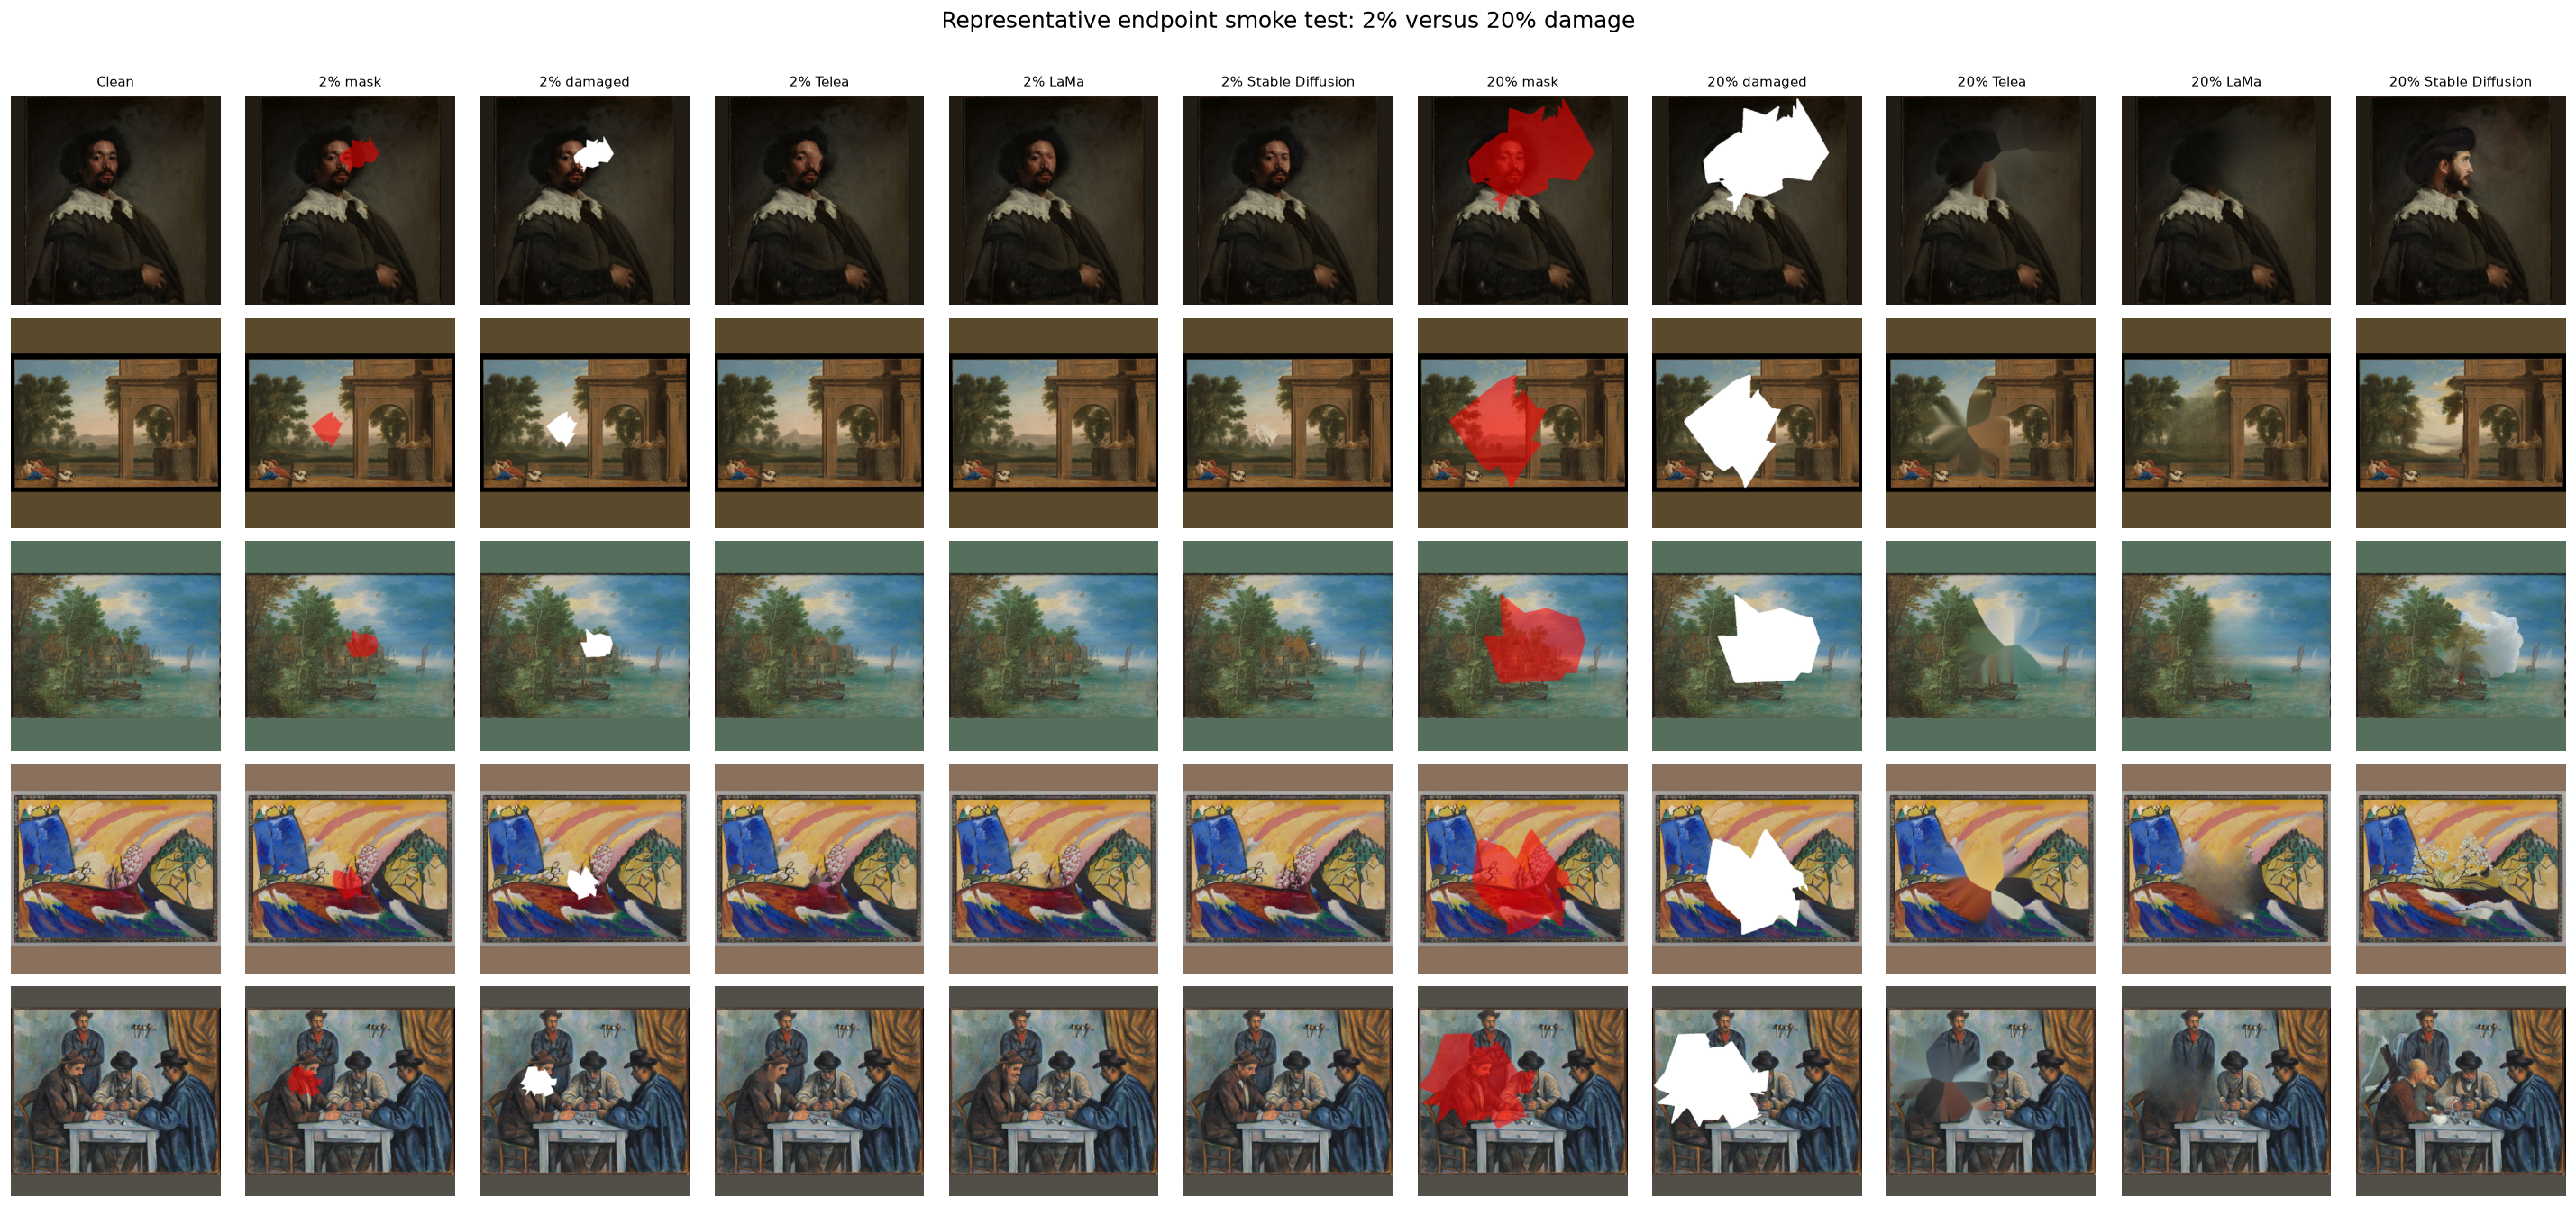

Rendered endpoint comparison for all five paintings.
This figure is notebook-only and has not been persisted.


In [14]:
def load_display_image(
    value: object,
    *,
    maximum_size: int = 320,
    grayscale: bool = False,
) -> Image.Image:
    """Load a detached thumbnail suitable for notebook display."""
    image_path = resolve_repository_path(value)

    with Image.open(image_path) as source:
        image = source.convert("L" if grayscale else "RGB")
        image.thumbnail(
            (maximum_size, maximum_size),
            Image.Resampling.LANCZOS,
        )
        return image.copy()


def create_mask_overlay(
    clean_path: object,
    mask_path: object,
    *,
    maximum_size: int = 320,
) -> Image.Image:
    """Overlay the evaluated mask in red on the clean painting."""
    clean = load_display_image(
        clean_path,
        maximum_size=maximum_size,
    )
    mask = load_display_image(
        mask_path,
        maximum_size=maximum_size,
        grayscale=True,
    )

    if mask.size != clean.size:
        mask = mask.resize(
            clean.size,
            Image.Resampling.NEAREST,
        )

    clean_array = np.asarray(clean, dtype=np.float32)
    mask_array = np.asarray(mask, dtype=np.float32) / 255.0
    mask_array = np.clip(mask_array, 0.0, 1.0)[..., None]

    red = np.zeros_like(clean_array)
    red[..., 0] = 255.0

    overlay = (
        clean_array * (1.0 - 0.55 * mask_array)
        + red * (0.55 * mask_array)
    )

    return Image.fromarray(
        np.clip(overlay, 0, 255).astype(np.uint8),
        mode="RGB",
    )


case_lookup = {
    (
        str(row.painting_id),
        round(float(row.target_damage_fraction), 4),
    ): row
    for row in SMOKE_CASES.itertuples(index=False)
}

candidate_lookup = {
    (
        str(row.painting_id),
        round(float(row.target_damage_fraction), 4),
        str(row.model_id),
    ): row
    for row in SMOKE_CANDIDATES.itertuples(index=False)
}

painting_metadata = (
    SELECTED_CANDIDATES[
        ["painting_id", "category", "style_or_period"]
    ]
    .drop_duplicates("painting_id")
    .set_index("painting_id")
)

endpoint_levels = (0.02, 0.20)
column_definitions = [
    ("clean", None, None, "Clean"),
]

for level in endpoint_levels:
    label = f"{100 * level:.0f}%"
    column_definitions.extend(
        [
            ("mask", level, None, f"{label} mask"),
            ("damaged", level, None, f"{label} damaged"),
            ("restored", level, "opencv_telea", f"{label} Telea"),
            ("restored", level, "lama", f"{label} LaMa"),
            (
                "restored",
                level,
                "stable_diffusion_inpainting",
                f"{label} Stable Diffusion",
            ),
        ]
    )

painting_ids = list(map(str, POPULATION["painting_ids"]))

fig, axes = plt.subplots(
    len(painting_ids),
    len(column_definitions),
    figsize=(24, 11),
    squeeze=False,
)

for row_index, painting_id in enumerate(painting_ids):
    base_case = case_lookup[(painting_id, 0.02)]

    for column_index, (
        artifact_role,
        level,
        model_id,
        title,
    ) in enumerate(column_definitions):
        axis = axes[row_index, column_index]

        if artifact_role == "clean":
            image = load_display_image(base_case.clean_image_path)
        else:
            case_row = case_lookup[
                (painting_id, round(float(level), 4))
            ]

            if artifact_role == "mask":
                image = create_mask_overlay(
                    case_row.clean_image_path,
                    case_row.mask_or_effect_path,
                )
            elif artifact_role == "damaged":
                image = load_display_image(
                    case_row.input_image_path
                )
            else:
                candidate_row = candidate_lookup[
                    (
                        painting_id,
                        round(float(level), 4),
                        str(model_id),
                    )
                ]
                image = load_display_image(
                    candidate_row.restored_path
                )

        axis.imshow(image)
        axis.set_axis_off()

        if row_index == 0:
            axis.set_title(title, fontsize=9)

        if column_index == 0:
            metadata = painting_metadata.loc[painting_id]
            axis.set_ylabel(
                f"{painting_id}\n{metadata['category']}",
                fontsize=9,
            )
            axis.yaxis.set_visible(True)

fig.suptitle(
    "Representative endpoint smoke test: 2% versus 20% damage",
    fontsize=15,
    y=1.01,
)
fig.tight_layout()
plt.show()

print("Rendered endpoint comparison for all five paintings.")
print("This figure is notebook-only and has not been persisted.")

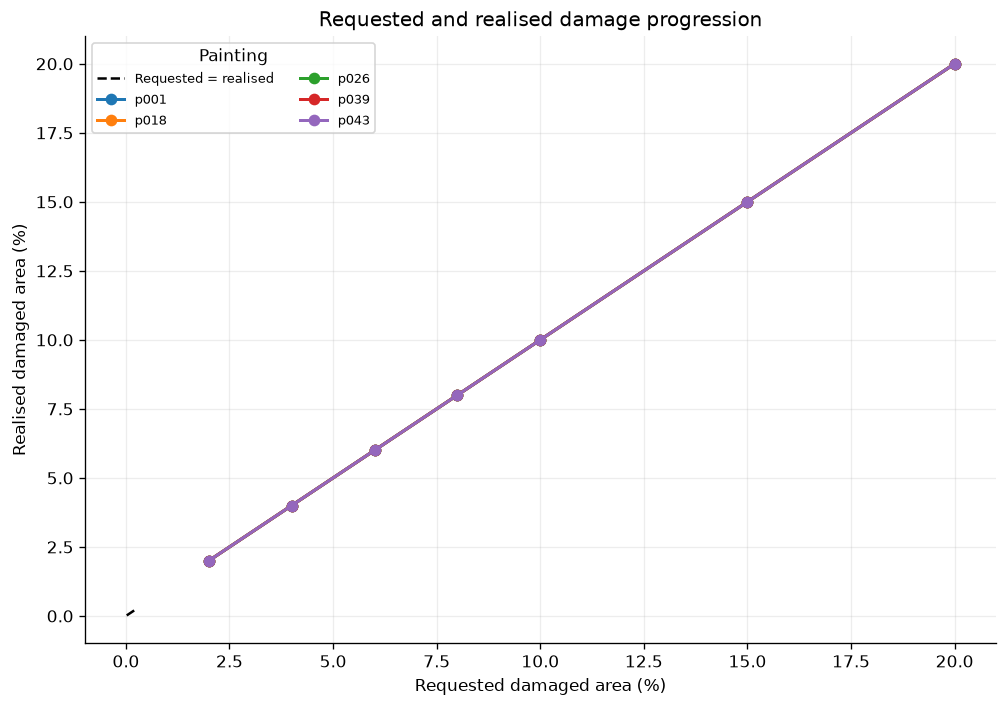

,level_id,target_damage_fraction,cases,mean_realized_fraction,minimum_realized_fraction,maximum_realized_fraction,maximum_absolute_percentage_point_error,mean_scaled_component_count,mean_scaled_compactness,mean_centroid_shift_pixels
0,size_02pct,0.02,5,0.02,0.019999,0.020001,0.000123,1.0,0.336617,0.377473
1,size_04pct,0.04,5,0.04,0.039999,0.040000,0.000071,1.0,0.333364,0.278978
2,size_06pct,0.06,5,0.06,0.059999,0.060001,0.000113,1.0,0.331433,0.340248
3,size_08pct,0.08,5,0.08,0.080000,0.080001,0.000059,1.0,0.334311,0.441111
4,size_10pct,0.10,5,0.10,0.099999,0.100001,0.000103,1.0,0.333633,0.395204
5,size_15pct,0.15,5,0.15,0.149999,0.150001,0.000103,1.0,0.330926,0.512822
6,size_20pct,0.20,5,0.20,0.199999,0.200001,0.000098,1.0,0.332789,0.468811


Damage progression and morphology integrity reviewed.
Strictly increasing trajectories: True
This figure is notebook-only and has not been persisted.


In [15]:
CASE_DESIGN["nested_with_previous_normalized"] = boolean_series(
    CASE_DESIGN["nested_with_previous"]
)
CASE_DESIGN["touches_content_boundary_normalized"] = boolean_series(
    CASE_DESIGN["touches_content_boundary"]
)

ordered_case_design = CASE_DESIGN.sort_values(
    ["painting_id", "target_damage_fraction"],
    kind="stable",
)

realized_progression_passed = all(
    group["realized_damage_fraction"]
    .diff()
    .dropna()
    .gt(0)
    .all()
    for _, group in ordered_case_design.groupby(
        "painting_id",
        observed=True,
    )
)

finite_morphology_fields = [
    field
    for field in SETTINGS["morphology"]["association_fields"]
    if field in CASE_DESIGN.columns
    and field not in {
        "nested_with_previous",
        "touches_content_boundary",
    }
]

morphology_numeric = CASE_DESIGN[
    finite_morphology_fields
].apply(pd.to_numeric, errors="coerce")

VALIDATION.add(
    validation_stage="batch_3_smoke_test",
    check_id="realized_damage_strictly_increases",
    check_description="Realised damage increases at every level within every painting.",
    severity="blocking",
    expected=True,
    observed=realized_progression_passed,
    passed=realized_progression_passed,
)
VALIDATION.add(
    validation_stage="batch_3_smoke_test",
    check_id="morphology_fields_finite",
    check_description="Required numeric morphology fields are finite for all 35 cases.",
    severity="blocking",
    expected={
        "rows": int(EXPECTED["cases"]),
        "fields": finite_morphology_fields,
    },
    observed={
        "rows": len(morphology_numeric),
        "finite_values": int(
            np.isfinite(morphology_numeric.to_numpy()).sum()
        ),
        "expected_values": int(morphology_numeric.size),
    },
    passed=(
        len(morphology_numeric) == int(EXPECTED["cases"])
        and np.isfinite(morphology_numeric.to_numpy()).all()
    ),
)

damage_integrity_summary = (
    CASE_DESIGN.groupby(
        [
            "level_id",
            "target_damage_fraction",
        ],
        observed=True,
    )
    .agg(
        cases=("case_id", "size"),
        mean_realized_fraction=(
            "realized_damage_fraction",
            "mean",
        ),
        minimum_realized_fraction=(
            "realized_damage_fraction",
            "min",
        ),
        maximum_realized_fraction=(
            "realized_damage_fraction",
            "max",
        ),
        maximum_absolute_percentage_point_error=(
            "absolute_percentage_point_error",
            "max",
        ),
        mean_scaled_component_count=(
            "scaled_connected_component_count",
            "mean",
        ),
        mean_scaled_compactness=(
            "scaled_mask_compactness",
            "mean",
        ),
        mean_centroid_shift_pixels=(
            "centroid_shift_pixels",
            "mean",
        ),
    )
    .reset_index()
    .sort_values("target_damage_fraction", kind="stable")
)

fig, axis = plt.subplots(figsize=(8.5, 6.0))

axis.plot(
    expected_target_levels,
    expected_target_levels,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Requested = realised",
)

for painting_id, group in ordered_case_design.groupby(
    "painting_id",
    observed=True,
):
    axis.plot(
        group["target_damage_fraction"] * 100.0,
        group["realized_damage_fraction"] * 100.0,
        marker="o",
        linewidth=1.8,
        label=str(painting_id),
    )

axis.set_xlabel("Requested damaged area (%)")
axis.set_ylabel("Realised damaged area (%)")
axis.set_title("Requested and realised damage progression")
axis.legend(
    title="Painting",
    ncols=2,
    fontsize=8,
)
fig.tight_layout()
plt.show()

display(damage_integrity_summary)

print("Damage progression and morphology integrity reviewed.")
print(f"Strictly increasing trajectories: {realized_progression_passed}")
print("This figure is notebook-only and has not been persisted.")

In [16]:
BATCH_3_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"].eq(
            "batch_3_smoke_test"
        )
    ]
    .reset_index(drop=True)
)

BATCH_3_SUMMARY = {
    "check_count": len(BATCH_3_CHECKS),
    "passed_count": int(BATCH_3_CHECKS["passed"].sum()),
    "blocking_failures": int(
        (
            BATCH_3_CHECKS["severity"].eq("blocking")
            & ~BATCH_3_CHECKS["passed"]
        ).sum()
    ),
}

smoke_metadata = (
    SELECTED_CANDIDATES[
        [
            "painting_id",
            "category",
            "style_or_period",
        ]
    ]
    .drop_duplicates("painting_id")
)

smoke_population_table = (
    SMOKE_CASES.merge(
        smoke_metadata,
        on="painting_id",
        how="left",
        validate="many_to_one",
    )[
        [
            "painting_id",
            "category",
            "style_or_period",
            "level_id",
            "target_damage_fraction",
            "realized_damage_fraction",
            "absolute_percentage_point_error",
            "scaled_connected_component_count",
            "scaled_mask_compactness",
            "centroid_shift_pixels",
        ]
    ]
    .copy()
    .sort_values(
        ["painting_id", "target_damage_fraction"],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(smoke_population_table)
display(BATCH_3_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 3 passed.")
print(f"Smoke cases: {len(SMOKE_CASES)}")
print(f"Smoke candidates: {len(SMOKE_CANDIDATES)}")
print(f"Validation checks: {BATCH_3_SUMMARY['check_count']}")
print(f"Blocking failures: {BATCH_3_SUMMARY['blocking_failures']}")
print("No canonical Notebook 23 artifact has been written.")
print("Next batch: full quality, runtime, and uncertainty normalization.")

,painting_id,category,style_or_period,level_id,target_damage_fraction,realized_damage_fraction,absolute_percentage_point_error,scaled_connected_component_count,scaled_mask_compactness,centroid_shift_pixels
0,p001,portrait_figure,Baroque,size_02pct,0.02,0.020001,0.000063,1,0.275144,0.304791
1,p001,portrait_figure,Baroque,size_10pct,0.10,0.099999,0.000079,1,0.277676,0.444967
2,p001,portrait_figure,Baroque,size_20pct,0.20,0.200000,0.000039,1,0.273781,0.289156
3,p018,landscape_natural,unclassified,size_02pct,0.02,0.020001,0.000123,1,0.343205,0.378224
4,p018,landscape_natural,unclassified,size_10pct,0.10,0.100001,0.000103,1,0.337544,0.612319
5,p018,landscape_natural,unclassified,size_20pct,0.20,0.199999,0.000051,1,0.334669,0.624269
6,p026,architecture_structured,unclassified,size_02pct,0.02,0.019999,0.000108,1,0.474239,0.484953
7,p026,architecture_structured,unclassified,size_10pct,0.10,0.100000,0.000049,1,0.475669,0.475905
8,p026,architecture_structured,unclassified,size_20pct,0.20,0.199999,0.000098,1,0.476401,0.516305
9,p039,abstraction_surrealism,unclassified,size_02pct,0.02,0.020000,0.000009,1,0.321390,0.579164


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_smoke_test,smoke_case_coverage,The smoke test contains all five paintings at three damage levels.,blocking,"{""cases"": 15, ""cases_per_painting"": 3}","{""cases"": 15, ""cases_per_painting"": {""p001"": 3, ""p018"": 3, ""p026"": 3, ""p039"": 3, ""p043"": 3}}",True,
1,batch_3_smoke_test,smoke_candidate_coverage,Every smoke case contains all three selected restorations.,blocking,"{""candidates"": 45, ""candidates_per_painting_model"": 3}","{""candidates"": 45, ""maximum_per_painting_model"": 3, ""minimum_per_painting_model"": 3}",True,
2,batch_3_smoke_test,smoke_images_reload,Every smoke-test image reloads with positive dimensions.,blocking,90,"{""existing_files"": 90, ""positive_dimensions"": 90, ""rows"": 90}",True,
3,batch_3_smoke_test,within_case_dimensions_match,"Clean, damaged, mask, and restored images share dimensions within each case.",blocking,"{""unique_heights_per_case"": 1, ""unique_widths_per_case"": 1}","{""maximum_unique_heights"": 1, ""maximum_unique_widths"": 1}",True,
4,batch_3_smoke_test,realized_damage_strictly_increases,Realised damage increases at every level within every painting.,blocking,True,True,True,
5,batch_3_smoke_test,morphology_fields_finite,Required numeric morphology fields are finite for all 35 cases.,blocking,"{""fields"": [""scaled_mask_compactness"", ""relative_bbox_aspect_ratio_drift"", ""relative_bbox_fill_ratio_drift"", ""centro...","{""expected_values"": 210, ""finite_values"": 210, ""rows"": 35}",True,


Batch 3 passed.
Smoke cases: 15
Smoke candidates: 45
Validation checks: 6
Blocking failures: 0
No canonical Notebook 23 artifact has been written.
Next batch: full quality, runtime, and uncertainty normalization.


## Batch 4 — Full quality, runtime, and uncertainty normalization

This batch loads and normalizes the complete evidence required by the damage-size analysis.

Quality evidence comes from:

- classical reference metrics;
- LPIPS;
- CLIP and DINOv2 feature similarity;
- spatial diagnostics;
- local texture, colour, and seam consistency;
- semantic and structural consistency.

Runtime is retained as separate operational evidence and cannot influence quality rankings.

Notebook 22 contributes Stable Diffusion repeated-seed variability. Candidate-pair distances are reduced to the median of the six unique seed pairs within each case and component. Reported group-level variability is retained directly.

Notebook 21 is loaded only as an upstream consistency check. Notebook 23 will compute its own damage-level analyses from candidate-level evidence.

In [17]:
CLASSICAL_METRICS = pd.read_csv(
    INPUT_PATHS["classical_metrics_path"],
    low_memory=False,
)
print(
    "Loaded classical metrics: "
    f"{len(CLASSICAL_METRICS):,} rows."
)

LPIPS_METRICS = pd.read_csv(
    INPUT_PATHS["lpips_metrics_path"],
    low_memory=False,
)
print(
    "Loaded LPIPS metrics: "
    f"{len(LPIPS_METRICS):,} rows."
)

FEATURE_METRICS = pd.read_csv(
    INPUT_PATHS["feature_metrics_path"],
    low_memory=False,
)
print(
    "Loaded feature metrics: "
    f"{len(FEATURE_METRICS):,} rows."
)

SPATIAL_METRICS = pd.read_csv(
    INPUT_PATHS["spatial_metrics_path"],
    low_memory=False,
)
print(
    "Loaded spatial diagnostics: "
    f"{len(SPATIAL_METRICS):,} rows."
)

LOCAL_CONSISTENCY_METRICS = pd.read_csv(
    INPUT_PATHS["local_metrics_path"],
    low_memory=False,
)
print(
    "Loaded local-consistency metrics: "
    f"{len(LOCAL_CONSISTENCY_METRICS):,} rows."
)

SEMANTIC_STRUCTURAL_METRICS = pd.read_csv(
    INPUT_PATHS["semantic_metrics_path"],
    low_memory=False,
)
print(
    "Loaded semantic and structural metrics: "
    f"{len(SEMANTIC_STRUCTURAL_METRICS):,} rows."
)

QUALITY_SOURCE_TABLES = {
    "classical": CLASSICAL_METRICS,
    "perceptual": LPIPS_METRICS,
    "feature": FEATURE_METRICS,
    "spatial": SPATIAL_METRICS,
    "local_consistency": LOCAL_CONSISTENCY_METRICS,
    "semantic_structural": SEMANTIC_STRUCTURAL_METRICS,
}

print("All six quality-evidence sources are in memory.")

Loaded classical metrics: 63,018 rows.
Loaded LPIPS metrics: 4,170 rows.
Loaded feature metrics: 8,340 rows.
Loaded spatial diagnostics: 18,896 rows.
Loaded local-consistency metrics: 271,988 rows.
Loaded semantic and structural metrics: 58,980 rows.
All six quality-evidence sources are in memory.


In [18]:
selected_candidate_ids = set(
    SELECTED_CANDIDATES["candidate_id"].astype(str)
)

expected_selected_source_rows = {
    "classical": int(
        EXPECTED["selected_classical_source_rows"]
    ),
    "perceptual": int(
        EXPECTED["selected_lpips_source_rows"]
    ),
    "feature": int(
        EXPECTED["selected_feature_source_rows"]
    ),
    "spatial": int(
        EXPECTED["selected_spatial_source_rows"]
    ),
    "local_consistency": int(
        EXPECTED["selected_local_source_rows"]
    ),
    "semantic_structural": int(
        EXPECTED["selected_semantic_source_rows"]
    ),
}

observed_selected_source_rows = {
    source_key: int(
        table["candidate_id"]
        .astype(str)
        .isin(selected_candidate_ids)
        .sum()
    )
    for source_key, table in QUALITY_SOURCE_TABLES.items()
}

source_selection_summary = pd.DataFrame(
    [
        {
            "source_key": source_key,
            "source_rows": len(QUALITY_SOURCE_TABLES[source_key]),
            "selected_rows": observed_selected_source_rows[
                source_key
            ],
            "expected_selected_rows": expected_selected_source_rows[
                source_key
            ],
            "matches_contract": (
                observed_selected_source_rows[source_key]
                == expected_selected_source_rows[source_key]
            ),
        }
        for source_key in QUALITY_SOURCE_TABLES
    ]
)

VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="selected_quality_source_counts",
    check_description="Every quality source contributes its expected candidate-level rows.",
    severity="blocking",
    expected=expected_selected_source_rows,
    observed=observed_selected_source_rows,
    passed=(
        observed_selected_source_rows
        == expected_selected_source_rows
    ),
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="selected_quality_source_total",
    check_description="The six sources contain exactly 21,420 selected source rows.",
    severity="blocking",
    expected=int(EXPECTED["selected_metric_source_rows"]),
    observed=sum(observed_selected_source_rows.values()),
    passed=(
        sum(observed_selected_source_rows.values())
        == int(EXPECTED["selected_metric_source_rows"])
    ),
)

display(source_selection_summary)

print("Selected source-row arithmetic validated.")
print(
    "Selected source rows: "
    f"{sum(observed_selected_source_rows.values()):,}"
)

,source_key,source_rows,selected_rows,expected_selected_rows,matches_contract
0,classical,63018,3150,3150,True
1,perceptual,4170,210,210,True
2,feature,8340,420,420,True
3,spatial,18896,945,945,True
4,local_consistency,271988,13755,13755,True
5,semantic_structural,58980,2940,2940,True


Selected source-row arithmetic validated.
Selected source rows: 21,420


In [19]:
print("Normalizing full quality evidence...")

QUALITY_EVIDENCE = normalise_quality_evidence(
    QUALITY_SOURCE_TABLES,
    SELECTED_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

print("Normalizing operational runtime evidence...")

RUNTIME_EVIDENCE = build_runtime_evidence(
    SELECTED_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

QUALITY_EVIDENCE["comparison_value"] = pd.to_numeric(
    QUALITY_EVIDENCE["comparison_value"],
    errors="coerce",
)
QUALITY_EVIDENCE["directional_utility"] = pd.to_numeric(
    QUALITY_EVIDENCE["directional_utility"],
    errors="coerce",
)
QUALITY_EVIDENCE["target_damage_fraction"] = pd.to_numeric(
    QUALITY_EVIDENCE["target_damage_fraction"],
    errors="coerce",
)
QUALITY_EVIDENCE["realized_damage_fraction"] = pd.to_numeric(
    QUALITY_EVIDENCE["realized_damage_fraction"],
    errors="coerce",
)

RUNTIME_EVIDENCE["comparison_value"] = pd.to_numeric(
    RUNTIME_EVIDENCE["comparison_value"],
    errors="coerce",
)
RUNTIME_EVIDENCE["target_damage_fraction"] = pd.to_numeric(
    RUNTIME_EVIDENCE["target_damage_fraction"],
    errors="coerce",
)
RUNTIME_EVIDENCE["realized_damage_fraction"] = pd.to_numeric(
    RUNTIME_EVIDENCE["realized_damage_fraction"],
    errors="coerce",
)

QUALITY_ANCHOR_EVIDENCE = (
    QUALITY_EVIDENCE.loc[
        QUALITY_EVIDENCE["anchor_id"].astype(str).ne("")
        & QUALITY_EVIDENCE["analysis_eligible"].astype(bool)
    ]
    .copy()
    .sort_values(
        [
            "anchor_id",
            "painting_id",
            "target_damage_fraction",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

anchor_counts = (
    QUALITY_ANCHOR_EVIDENCE.groupby(
        "anchor_id",
        observed=True,
    )
    .agg(
        rows=("candidate_id", "size"),
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        models=("model_id", "nunique"),
        paintings=("painting_id", "nunique"),
        levels=("target_damage_fraction", "nunique"),
    )
    .reset_index()
    .sort_values("anchor_id", kind="stable")
)

configured_anchor_ids = {
    str(item["anchor_id"])
    for item in SETTINGS["quality_anchors"]
}
observed_anchor_ids = set(
    anchor_counts["anchor_id"].astype(str)
)

VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="normalized_quality_row_count",
    check_description="Quality sources normalize to exactly 33,705 rows.",
    severity="blocking",
    expected=int(EXPECTED["normalized_quality_rows"]),
    observed=len(QUALITY_EVIDENCE),
    passed=(
        len(QUALITY_EVIDENCE)
        == int(EXPECTED["normalized_quality_rows"])
    ),
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="quality_source_ids_unique",
    check_description="Normalized source row identifiers remain unique.",
    severity="blocking",
    expected=True,
    observed=not QUALITY_EVIDENCE.duplicated(
        ["source_notebook_id", "source_metric_row_id"]
    ).any(),
    passed=not QUALITY_EVIDENCE.duplicated(
        ["source_notebook_id", "source_metric_row_id"]
    ).any(),
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="eligible_quality_values_finite",
    check_description="Every analysis-eligible quality value is finite.",
    severity="blocking",
    expected=True,
    observed=bool(
        np.isfinite(
            QUALITY_EVIDENCE.loc[
                QUALITY_EVIDENCE["analysis_eligible"].astype(bool),
                "comparison_value",
            ]
        ).all()
    ),
    passed=bool(
        np.isfinite(
            QUALITY_EVIDENCE.loc[
                QUALITY_EVIDENCE["analysis_eligible"].astype(bool),
                "comparison_value",
            ]
        ).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="quality_anchor_registry_coverage",
    check_description="All eleven configured quality anchors are present.",
    severity="blocking",
    expected=sorted(configured_anchor_ids),
    observed=sorted(observed_anchor_ids),
    passed=observed_anchor_ids == configured_anchor_ids,
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="quality_anchor_candidate_coverage",
    check_description="Every quality anchor covers all 105 selected candidates.",
    severity="blocking",
    expected={
        "anchors": int(EXPECTED["quality_anchors"]),
        "candidates_per_anchor": int(EXPECTED["candidates"]),
    },
    observed={
        "anchors": len(anchor_counts),
        "minimum_candidates": int(
            anchor_counts["candidates"].min()
        ),
        "maximum_candidates": int(
            anchor_counts["candidates"].max()
        ),
    },
    passed=(
        len(anchor_counts) == int(EXPECTED["quality_anchors"])
        and anchor_counts["candidates"]
        .eq(int(EXPECTED["candidates"]))
        .all()
        and anchor_counts["rows"]
        .eq(int(EXPECTED["candidates"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="runtime_evidence_contract",
    check_description="Runtime has 105 finite positive rows and is excluded from quality ranking.",
    severity="blocking",
    expected={
        "rows": int(EXPECTED["runtime_rows"]),
        "quality_ranking_eligible": False,
    },
    observed={
        "rows": len(RUNTIME_EVIDENCE),
        "finite_positive_rows": int(
            (
                np.isfinite(RUNTIME_EVIDENCE["comparison_value"])
                & RUNTIME_EVIDENCE["comparison_value"].gt(0)
            ).sum()
        ),
        "quality_ranking_eligible_rows": int(
            RUNTIME_EVIDENCE[
                "quality_ranking_eligible"
            ].astype(bool).sum()
        ),
    },
    passed=(
        len(RUNTIME_EVIDENCE)
        == int(EXPECTED["runtime_rows"])
        and np.isfinite(
            RUNTIME_EVIDENCE["comparison_value"]
        ).all()
        and RUNTIME_EVIDENCE["comparison_value"].gt(0).all()
        and not RUNTIME_EVIDENCE[
            "quality_ranking_eligible"
        ].astype(bool).any()
    ),
)

display(anchor_counts)

print("Quality and runtime normalization completed.")
print(f"Normalized quality rows: {len(QUALITY_EVIDENCE):,}")
print(f"Anchor rows: {len(QUALITY_ANCHOR_EVIDENCE):,}")
print(f"Runtime rows: {len(RUNTIME_EVIDENCE):,}")

Normalizing full quality evidence...
Normalizing operational runtime evidence...


,anchor_id,rows,candidates,cases,models,paintings,levels
0,classical_masked_mae,105,105,35,3,5,7
1,colour_masked_delta_e,105,105,35,3,5,7
2,feature_clip_crop,105,105,35,3,5,7
3,feature_dino_crop,105,105,35,3,5,7
4,perceptual_crop_lpips,105,105,35,3,5,7
5,seam_boundary_gradient,105,105,35,3,5,7
6,semantic_local_dino,105,105,35,3,5,7
7,spatial_masked_error,105,105,35,3,5,7
8,structural_affinity_correlation,105,105,35,3,5,7
9,structural_crop_ssim,105,105,35,3,5,7


Quality and runtime normalization completed.
Normalized quality rows: 33,705
Anchor rows: 1,155
Runtime rows: 105


In [20]:
UNCERTAINTY_SOURCE = pd.read_csv(
    INPUT_PATHS["uncertainty_metrics_path"],
    low_memory=False,
)
UNCERTAINTY_MAP_MANIFEST = pd.read_csv(
    INPUT_PATHS["uncertainty_map_manifest_path"],
    low_memory=False,
)

print(
    "Loaded Notebook 22 uncertainty evidence: "
    f"{len(UNCERTAINTY_SOURCE):,} rows."
)

UNCERTAINTY_EVIDENCE = normalise_uncertainty_evidence(
    UNCERTAINTY_SOURCE,
    config=ANALYSIS_CONFIG,
)

UNCERTAINTY_EVIDENCE["value"] = pd.to_numeric(
    UNCERTAINTY_EVIDENCE["value"],
    errors="coerce",
)
UNCERTAINTY_EVIDENCE["target_damage_fraction"] = pd.to_numeric(
    UNCERTAINTY_EVIDENCE["target_damage_fraction"],
    errors="coerce",
)
UNCERTAINTY_EVIDENCE["realized_damage_fraction"] = pd.to_numeric(
    UNCERTAINTY_EVIDENCE["realized_damage_fraction"],
    errors="coerce",
)

MAIN_UNCERTAINTY_EVIDENCE = (
    UNCERTAINTY_EVIDENCE.loc[
        UNCERTAINTY_EVIDENCE["component_id"]
        .astype(str)
        .ne("")
    ]
    .copy()
    .sort_values(
        [
            "component_id",
            "painting_id",
            "target_damage_fraction",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

main_component_counts = (
    MAIN_UNCERTAINTY_EVIDENCE.groupby(
        "component_id",
        observed=True,
    )
    .agg(
        rows=("uncertainty_group_id", "size"),
        groups=("uncertainty_group_id", "nunique"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        levels=("target_damage_fraction", "nunique"),
    )
    .reset_index()
    .sort_values("component_id", kind="stable")
)

expected_main_component_ids = {
    str(item["component_id"])
    for item in SETTINGS["uncertainty"][
        "main_figure_components"
    ]
}
observed_main_component_ids = set(
    main_component_counts["component_id"].astype(str)
)

UNCERTAINTY_MAP_ROOT = (
    INPUT_PATHS["uncertainty_map_manifest_path"].parents[1]
)
UNCERTAINTY_MAP_MANIFEST["resolved_path"] = (
    UNCERTAINTY_MAP_MANIFEST["relative_path"].map(
        lambda value: str(
            UNCERTAINTY_MAP_ROOT
            / Path(str(value).replace("\\", "/"))
        )
    )
)
UNCERTAINTY_MAP_MANIFEST["file_exists"] = (
    UNCERTAINTY_MAP_MANIFEST["resolved_path"].map(
        lambda value: Path(value).is_file()
    )
)

VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="uncertainty_source_row_count",
    check_description="Notebook 22 contains the contracted 4,760 evidence rows.",
    severity="blocking",
    expected=int(EXPECTED["uncertainty_metric_rows"]),
    observed=len(UNCERTAINTY_SOURCE),
    passed=(
        len(UNCERTAINTY_SOURCE)
        == int(EXPECTED["uncertainty_metric_rows"])
    ),
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="uncertainty_group_level_row_count",
    check_description="Pairwise evidence reduces to exactly 1,050 group-level component rows.",
    severity="blocking",
    expected=int(EXPECTED["uncertainty_group_level_rows"]),
    observed=len(UNCERTAINTY_EVIDENCE),
    passed=(
        len(UNCERTAINTY_EVIDENCE)
        == int(EXPECTED["uncertainty_group_level_rows"])
    ),
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="uncertainty_group_coverage",
    check_description="All 35 cases have one complete four-seed uncertainty group.",
    severity="blocking",
    expected={
        "groups": int(EXPECTED["uncertainty_groups"]),
        "seed_count": len(
            SETTINGS["uncertainty"]["expected_seeds"]
        ),
    },
    observed={
        "groups": UNCERTAINTY_EVIDENCE[
            "uncertainty_group_id"
        ].nunique(),
        "cases": UNCERTAINTY_EVIDENCE["case_id"].nunique(),
        "seed_counts": sorted(
            pd.to_numeric(
                UNCERTAINTY_EVIDENCE["seed_count"],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
    },
    passed=(
        UNCERTAINTY_EVIDENCE[
            "uncertainty_group_id"
        ].nunique()
        == int(EXPECTED["uncertainty_groups"])
        and UNCERTAINTY_EVIDENCE["case_id"].nunique()
        == int(EXPECTED["cases"])
        and pd.to_numeric(
            UNCERTAINTY_EVIDENCE["seed_count"],
            errors="coerce",
        )
        .eq(len(SETTINGS["uncertainty"]["expected_seeds"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="main_uncertainty_component_coverage",
    check_description="All five transparent main uncertainty components cover all 35 cases.",
    severity="blocking",
    expected={
        "component_ids": sorted(expected_main_component_ids),
        "groups_per_component": int(
            EXPECTED["uncertainty_groups"]
        ),
    },
    observed={
        "component_ids": sorted(observed_main_component_ids),
        "minimum_groups": int(
            main_component_counts["groups"].min()
        ),
        "maximum_groups": int(
            main_component_counts["groups"].max()
        ),
    },
    passed=(
        observed_main_component_ids
        == expected_main_component_ids
        and main_component_counts["groups"]
        .eq(int(EXPECTED["uncertainty_groups"]))
        .all()
        and main_component_counts["rows"]
        .eq(int(EXPECTED["uncertainty_groups"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="uncertainty_values_finite",
    check_description="Every normalized uncertainty value is finite.",
    severity="blocking",
    expected=True,
    observed=bool(
        np.isfinite(UNCERTAINTY_EVIDENCE["value"]).all()
    ),
    passed=bool(
        np.isfinite(UNCERTAINTY_EVIDENCE["value"]).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="uncertainty_map_manifest",
    check_description="All 35 Notebook 22 uncertainty panels are passed and present.",
    severity="blocking",
    expected={
        "rows": int(EXPECTED["uncertainty_groups"]),
        "status": "passed",
    },
    observed={
        "rows": len(UNCERTAINTY_MAP_MANIFEST),
        "passed_rows": int(
            UNCERTAINTY_MAP_MANIFEST["status"]
            .astype(str)
            .eq("passed")
            .sum()
        ),
        "existing_files": int(
            UNCERTAINTY_MAP_MANIFEST["file_exists"].sum()
        ),
    },
    passed=(
        len(UNCERTAINTY_MAP_MANIFEST)
        == int(EXPECTED["uncertainty_groups"])
        and UNCERTAINTY_MAP_MANIFEST["status"]
        .astype(str)
        .eq("passed")
        .all()
        and UNCERTAINTY_MAP_MANIFEST["file_exists"].all()
    ),
)

display(main_component_counts)

print("Uncertainty evidence normalized.")
print(f"Group-level uncertainty rows: {len(UNCERTAINTY_EVIDENCE):,}")
print(
    "Main-component rows: "
    f"{len(MAIN_UNCERTAINTY_EVIDENCE):,}"
)
print(
    "Available uncertainty panels: "
    f"{int(UNCERTAINTY_MAP_MANIFEST['file_exists'].sum())}"
)

Loaded Notebook 22 uncertainty evidence: 4,760 rows.


,component_id,rows,groups,cases,paintings,levels
0,crop_pairwise_clip,35,35,35,5,7
1,crop_pairwise_dino,35,35,35,5,7
2,crop_pairwise_lpips,35,35,35,5,7
3,masked_pairwise_rgb_rmse,35,35,35,5,7
4,masked_rgb_std,35,35,35,5,7


Uncertainty evidence normalized.
Group-level uncertainty rows: 1,050
Main-component rows: 175
Available uncertainty panels: 35


In [21]:
COMPARISON_SOURCE = pd.read_csv(
    INPUT_PATHS["comparison_metrics_path"],
    low_memory=False,
)

COMPARISON_CROSSCHECK = (
    COMPARISON_SOURCE.loc[
        COMPARISON_SOURCE["population_id"]
        .astype(str)
        .eq("core_three_model")
        & COMPARISON_SOURCE["analysis_scope"]
        .astype(str)
        .eq("experiment")
        & COMPARISON_SOURCE["scope_value"]
        .astype(str)
        .eq("damage_size_sensitivity")
        & COMPARISON_SOURCE["model_id"]
        .astype(str)
        .isin(set(map(str, POPULATION["model_order"])))
    ]
    .copy()
    .reset_index(drop=True)
)

VALIDATION.add(
    validation_stage="batch_4_evidence_normalization",
    check_id="comparison_crosscheck_rows",
    check_description="Notebook 21 supplies the expected 960 damage-size comparison rows.",
    severity="blocking",
    expected=int(EXPECTED["comparison_crosscheck_rows"]),
    observed={
        "rows": len(COMPARISON_CROSSCHECK),
        "model_counts": {
            str(key): int(value)
            for key, value in (
                COMPARISON_CROSSCHECK.groupby(
                    "model_id",
                    observed=True,
                )
                .size()
                .to_dict()
                .items()
            )
        },
        "statuses": sorted(
            COMPARISON_CROSSCHECK["status"]
            .astype(str)
            .unique()
        ),
    },
    passed=(
        len(COMPARISON_CROSSCHECK)
        == int(EXPECTED["comparison_crosscheck_rows"])
        and COMPARISON_CROSSCHECK["status"]
        .astype(str)
        .eq("ok")
        .all()
    ),
)

normalized_evidence_summary = pd.DataFrame(
    [
        {
            "evidence_kind": "quality",
            "rows": len(QUALITY_EVIDENCE),
            "cases": QUALITY_EVIDENCE["case_id"].nunique(),
            "candidates_or_groups": QUALITY_EVIDENCE[
                "candidate_id"
            ].nunique(),
            "quality_ranking_eligible": True,
        },
        {
            "evidence_kind": "quality_anchors",
            "rows": len(QUALITY_ANCHOR_EVIDENCE),
            "cases": QUALITY_ANCHOR_EVIDENCE[
                "case_id"
            ].nunique(),
            "candidates_or_groups": QUALITY_ANCHOR_EVIDENCE[
                "candidate_id"
            ].nunique(),
            "quality_ranking_eligible": True,
        },
        {
            "evidence_kind": "runtime",
            "rows": len(RUNTIME_EVIDENCE),
            "cases": RUNTIME_EVIDENCE["case_id"].nunique(),
            "candidates_or_groups": RUNTIME_EVIDENCE[
                "candidate_id"
            ].nunique(),
            "quality_ranking_eligible": False,
        },
        {
            "evidence_kind": "uncertainty",
            "rows": len(UNCERTAINTY_EVIDENCE),
            "cases": UNCERTAINTY_EVIDENCE["case_id"].nunique(),
            "candidates_or_groups": UNCERTAINTY_EVIDENCE[
                "uncertainty_group_id"
            ].nunique(),
            "quality_ranking_eligible": False,
        },
        {
            "evidence_kind": "notebook_21_crosscheck",
            "rows": len(COMPARISON_CROSSCHECK),
            "cases": int(
                COMPARISON_CROSSCHECK[
                    "population_case_count"
                ].max()
            ),
            "candidates_or_groups": pd.NA,
            "quality_ranking_eligible": False,
        },
    ]
)

BATCH_4_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"].eq(
            "batch_4_evidence_normalization"
        )
    ]
    .reset_index(drop=True)
)
BATCH_4_SUMMARY = {
    "check_count": len(BATCH_4_CHECKS),
    "passed_count": int(BATCH_4_CHECKS["passed"].sum()),
    "blocking_failures": int(
        (
            BATCH_4_CHECKS["severity"].eq("blocking")
            & ~BATCH_4_CHECKS["passed"]
        ).sum()
    ),
}

display(normalized_evidence_summary)
display(BATCH_4_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 4 passed.")
print(f"Normalized quality rows: {len(QUALITY_EVIDENCE):,}")
print(f"Runtime rows: {len(RUNTIME_EVIDENCE):,}")
print(f"Normalized uncertainty rows: {len(UNCERTAINTY_EVIDENCE):,}")
print(f"Notebook 21 cross-check rows: {len(COMPARISON_CROSSCHECK):,}")
print(f"Validation checks: {BATCH_4_SUMMARY['check_count']}")
print(f"Blocking failures: {BATCH_4_SUMMARY['blocking_failures']}")
print("No canonical Notebook 23 artifact has been written.")
print("Next batch: performance curves and matched sensitivity estimates.")

,evidence_kind,rows,cases,candidates_or_groups,quality_ranking_eligible
0,quality,33705,35,105,True
1,quality_anchors,1155,35,105,True
2,runtime,105,35,105,False
3,uncertainty,1050,35,35,False
4,notebook_21_crosscheck,960,410,<NA>,False


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_evidence_normalization,selected_quality_source_counts,Every quality source contributes its expected candidate-level rows.,blocking,"{""classical"": 3150, ""feature"": 420, ""local_consistency"": 13755, ""perceptual"": 210, ""semantic_structural"": 2940, ""spa...","{""classical"": 3150, ""feature"": 420, ""local_consistency"": 13755, ""perceptual"": 210, ""semantic_structural"": 2940, ""spa...",True,
1,batch_4_evidence_normalization,selected_quality_source_total,"The six sources contain exactly 21,420 selected source rows.",blocking,21420,21420,True,
2,batch_4_evidence_normalization,normalized_quality_row_count,"Quality sources normalize to exactly 33,705 rows.",blocking,33705,33705,True,
3,batch_4_evidence_normalization,quality_source_ids_unique,Normalized source row identifiers remain unique.,blocking,True,True,True,
4,batch_4_evidence_normalization,eligible_quality_values_finite,Every analysis-eligible quality value is finite.,blocking,True,True,True,
5,batch_4_evidence_normalization,quality_anchor_registry_coverage,All eleven configured quality anchors are present.,blocking,"[""classical_masked_mae"", ""colour_masked_delta_e"", ""feature_clip_crop"", ""feature_dino_crop"", ""perceptual_crop_lpips"",...","[""classical_masked_mae"", ""colour_masked_delta_e"", ""feature_clip_crop"", ""feature_dino_crop"", ""perceptual_crop_lpips"",...",True,
6,batch_4_evidence_normalization,quality_anchor_candidate_coverage,Every quality anchor covers all 105 selected candidates.,blocking,"{""anchors"": 11, ""candidates_per_anchor"": 105}","{""anchors"": 11, ""maximum_candidates"": 105, ""minimum_candidates"": 105}",True,
7,batch_4_evidence_normalization,runtime_evidence_contract,Runtime has 105 finite positive rows and is excluded from quality ranking.,blocking,"{""quality_ranking_eligible"": false, ""rows"": 105}","{""finite_positive_rows"": 105, ""quality_ranking_eligible_rows"": 0, ""rows"": 105}",True,
8,batch_4_evidence_normalization,uncertainty_source_row_count,"Notebook 22 contains the contracted 4,760 evidence rows.",blocking,4760,4760,True,
9,batch_4_evidence_normalization,uncertainty_group_level_row_count,"Pairwise evidence reduces to exactly 1,050 group-level component rows.",blocking,1050,1050,True,


Batch 4 passed.
Normalized quality rows: 33,705
Runtime rows: 105
Normalized uncertainty rows: 1,050
Notebook 21 cross-check rows: 960
Validation checks: 15
Blocking failures: 0
No canonical Notebook 23 artifact has been written.
Next batch: performance curves and matched sensitivity estimates.


## Batch 5 — Performance curves and matched sensitivity

This batch measures how each quality anchor changes as damage grows.

For every quality anchor and model, the notebook computes:

- median performance at each damage level;
- an exact five-painting bootstrap interval;
- one Theil–Sen slope per painting;
- a median adverse slope across the five paintings;
- an exact two-sided sign-flip test;
- a matched rank-biserial effect size.

Slopes are reported per 10 percentage-point increase in damaged area. Positive adverse slopes mean that performance became worse as damage increased.

Both requested and realised damage fractions are tested. The five paintings remain the independent units; the seven damage levels are repeated measurements within each painting.

In [22]:
import hashlib

QUALITY_ANCHOR_ANALYSIS = QUALITY_ANCHOR_EVIDENCE.copy()

if "level_id" not in QUALITY_ANCHOR_ANALYSIS.columns:
    QUALITY_ANCHOR_ANALYSIS = QUALITY_ANCHOR_ANALYSIS.merge(
        CASE_DESIGN[
            [
                "case_id",
                "level_id",
            ]
        ].drop_duplicates("case_id"),
        on="case_id",
        how="left",
        validate="many_to_one",
    )

QUALITY_ANCHOR_ANALYSIS["target_damage_fraction"] = pd.to_numeric(
    QUALITY_ANCHOR_ANALYSIS["target_damage_fraction"],
    errors="coerce",
)
QUALITY_ANCHOR_ANALYSIS["realized_damage_fraction"] = pd.to_numeric(
    QUALITY_ANCHOR_ANALYSIS["realized_damage_fraction"],
    errors="coerce",
)
QUALITY_ANCHOR_ANALYSIS["comparison_value"] = pd.to_numeric(
    QUALITY_ANCHOR_ANALYSIS["comparison_value"],
    errors="coerce",
)

CONFIDENCE_LEVEL = float(
    SETTINGS["statistics"]["confidence_level"]
)
REPORTING_INTERVAL_PP = float(
    SETTINGS["statistics"]["slope_reporting_scale_percentage_points"]
)
EXPOSURE_COLUMNS = list(
    SETTINGS["statistics"]["exposure_columns"]
)


def stable_analysis_id(*parts: object) -> str:
    payload = "||".join(
        "" if value is None or pd.isna(value) else str(value)
        for value in parts
    )
    digest = hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()[:20]
    return f"dsa_{digest}"


def json_string_list(values: pd.Series | list | tuple | set) -> str:
    cleaned = sorted(
        {
            str(value)
            for value in values
            if pd.notna(value) and str(value).strip()
        }
    )
    return json.dumps(cleaned, ensure_ascii=False)


def build_analysis_record(
    *,
    analysis_kind: str,
    analysis_family_id: str,
    row_identity: tuple[object, ...],
    source_rows: pd.DataFrame | None = None,
    **values: object,
) -> dict[str, object]:
    row = {
        column: pd.NA
        for column in ANALYSIS_COLUMNS
    }

    row.update(
        {
            "analysis_row_id": stable_analysis_id(
                analysis_kind,
                analysis_family_id,
                *row_identity,
            ),
            "analysis_kind": analysis_kind,
            "analysis_family_id": analysis_family_id,
            "source_notebook_ids": "[]",
            "source_metric_ids_json": "[]",
            "quality_ranking_eligible": False,
            "independent_unit": SETTINGS["statistics"][
                "independent_unit"
            ],
            "effect_size_name": "not_applicable",
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "applicability_status": "applicable",
            "interpretation_status": (
                "supported_with_declared_scope_limits"
            ),
            "schema_version": ANALYSIS_SCHEMA_VERSION,
            "status": "ok",
            "issue": "",
        }
    )

    if source_rows is not None and not source_rows.empty:
        if "source_notebook_id" in source_rows.columns:
            row["source_notebook_ids"] = json_string_list(
                source_rows["source_notebook_id"]
            )
        if "source_metric_row_id" in source_rows.columns:
            row["source_metric_ids_json"] = json_string_list(
                source_rows["source_metric_row_id"]
            )

    row.update(values)
    return row


anchor_group_columns = [
    "anchor_id",
    "source_notebook_id",
    "evidence_family",
    "metric_family",
    "metric_id",
    "metric_name",
    "feature_model_id",
    "region_id",
    "summary_statistic",
    "value_unit",
    "comparison_direction",
    "model_id",
]

anchor_group_sizes = (
    QUALITY_ANCHOR_ANALYSIS.groupby(
        anchor_group_columns,
        observed=True,
        dropna=False,
    )
    .size()
)

VALIDATION.add(
    validation_stage="batch_5_matched_sensitivity",
    check_id="anchor_model_trajectory_coverage",
    check_description="Every anchor–model trajectory contains 35 observations.",
    severity="blocking",
    expected={
        "groups": int(EXPECTED["quality_anchors"])
        * len(POPULATION["model_order"]),
        "rows_per_group": int(EXPECTED["cases"]),
    },
    observed={
        "groups": len(anchor_group_sizes),
        "minimum_rows": int(anchor_group_sizes.min()),
        "maximum_rows": int(anchor_group_sizes.max()),
    },
    passed=(
        len(anchor_group_sizes)
        == int(EXPECTED["quality_anchors"])
        * len(POPULATION["model_order"])
        and anchor_group_sizes.eq(
            int(EXPECTED["cases"])
        ).all()
    ),
)

print("Anchor-analysis population prepared.")
print(
    "Anchor–model trajectories: "
    f"{len(anchor_group_sizes)}"
)
print(
    "Observations per trajectory: "
    f"{int(anchor_group_sizes.min())}"
)

Anchor-analysis population prepared.
Anchor–model trajectories: 33
Observations per trajectory: 35


In [23]:
level_summary_records = []

level_group_columns = [
    "anchor_id",
    "source_notebook_id",
    "evidence_family",
    "metric_family",
    "metric_id",
    "metric_name",
    "feature_model_id",
    "region_id",
    "summary_statistic",
    "value_unit",
    "comparison_direction",
    "model_id",
    "level_id",
    "target_damage_fraction",
]

level_groups = list(
    QUALITY_ANCHOR_ANALYSIS.groupby(
        level_group_columns,
        observed=True,
        dropna=False,
        sort=True,
    )
)

for group_number, (group_key, group) in enumerate(
    level_groups,
    start=1,
):
    metadata = dict(zip(level_group_columns, group_key))
    values = pd.to_numeric(
        group["comparison_value"],
        errors="coerce",
    ).to_numpy(dtype=float)

    interval = exhaustive_bootstrap_interval(
        values,
        confidence_level=CONFIDENCE_LEVEL,
        statistic=np.median,
    )

    level_summary_records.append(
        build_analysis_record(
            analysis_kind="level_summary",
            analysis_family_id=str(metadata["anchor_id"]),
            row_identity=(
                metadata["anchor_id"],
                metadata["model_id"],
                metadata["level_id"],
            ),
            source_rows=group,
            evidence_family=metadata["evidence_family"],
            metric_family=metadata["metric_family"],
            metric_id=metadata["metric_id"],
            metric_name=metadata["metric_name"],
            feature_model_id=metadata["feature_model_id"],
            region_id=metadata["region_id"],
            summary_statistic=metadata["summary_statistic"],
            value_unit=metadata["value_unit"],
            comparison_direction=metadata[
                "comparison_direction"
            ],
            quality_ranking_eligible=True,
            anchor_id=metadata["anchor_id"],
            model_id=metadata["model_id"],
            comparison_model_id="not_applicable",
            exposure_definition="target_damage_fraction",
            level_id=metadata["level_id"],
            target_damage_fraction=float(
                metadata["target_damage_fraction"]
            ),
            realized_damage_fraction=float(
                pd.to_numeric(
                    group["realized_damage_fraction"],
                    errors="coerce",
                ).median()
            ),
            scope_type="damage_level",
            scope_value=str(metadata["level_id"]),
            n_paintings=int(group["painting_id"].nunique()),
            n_cases=int(group["case_id"].nunique()),
            n_observations=int(len(group)),
            estimate_name="median_restored_value",
            estimate=float(interval["estimate"]),
            ci_lower=float(interval["ci_lower"]),
            ci_upper=float(interval["ci_upper"]),
            effect_size_name="not_applicable",
            effect_size=pd.NA,
            p_value=pd.NA,
            q_value=pd.NA,
            test_method="not_applicable",
            bootstrap_method=SETTINGS["statistics"][
                "bootstrap_method"
            ],
            bootstrap_resamples=int(interval["resamples"]),
        )
    )

    if group_number % 10 == 0 or group_number == len(level_groups):
        print(
            f"Computed {group_number}/{len(level_groups)} "
            "quality level summaries."
        )

QUALITY_LEVEL_SUMMARY = pd.DataFrame(
    level_summary_records,
    columns=ANALYSIS_COLUMNS,
)

print("Quality level summaries completed.")
print(f"Level-summary rows: {len(QUALITY_LEVEL_SUMMARY)}")

Computed 10/231 quality level summaries.
Computed 20/231 quality level summaries.
Computed 30/231 quality level summaries.
Computed 40/231 quality level summaries.
Computed 50/231 quality level summaries.
Computed 60/231 quality level summaries.
Computed 70/231 quality level summaries.
Computed 80/231 quality level summaries.
Computed 90/231 quality level summaries.
Computed 100/231 quality level summaries.
Computed 110/231 quality level summaries.
Computed 120/231 quality level summaries.
Computed 130/231 quality level summaries.
Computed 140/231 quality level summaries.
Computed 150/231 quality level summaries.
Computed 160/231 quality level summaries.
Computed 170/231 quality level summaries.
Computed 180/231 quality level summaries.
Computed 190/231 quality level summaries.
Computed 200/231 quality level summaries.
Computed 210/231 quality level summaries.
Computed 220/231 quality level summaries.
Computed 230/231 quality level summaries.
Computed 231/231 quality level summaries.
Q

In [24]:
painting_slope_records = []
trend_summary_records = []

trajectory_groups = list(
    QUALITY_ANCHOR_ANALYSIS.groupby(
        anchor_group_columns,
        observed=True,
        dropna=False,
        sort=True,
    )
)

total_slope_fits = (
    len(trajectory_groups) * len(EXPOSURE_COLUMNS)
)
completed_slope_fits = 0

for group_key, group in trajectory_groups:
    metadata = dict(zip(anchor_group_columns, group_key))
    direction = str(metadata["comparison_direction"])

    for exposure_column in EXPOSURE_COLUMNS:
        painting_slopes = compute_painting_slopes(
            group,
            exposure_column=exposure_column,
            value_column="comparison_value",
            direction=direction,
            reporting_scale_percentage_points=(
                REPORTING_INTERVAL_PP
            ),
        )

        painting_metadata = (
            group[
                [
                    "painting_id",
                    "category",
                    "style_or_period",
                ]
            ]
            .drop_duplicates("painting_id")
            .set_index("painting_id")
        )

        for slope_row in painting_slopes.itertuples(index=False):
            painting_id = str(slope_row.painting_id)
            painting_source_rows = group.loc[
                group["painting_id"]
                .astype(str)
                .eq(painting_id)
            ]

            painting_slope_records.append(
                build_analysis_record(
                    analysis_kind="painting_trajectory",
                    analysis_family_id=str(
                        metadata["anchor_id"]
                    ),
                    row_identity=(
                        metadata["anchor_id"],
                        metadata["model_id"],
                        exposure_column,
                        painting_id,
                    ),
                    source_rows=painting_source_rows,
                    evidence_family=metadata[
                        "evidence_family"
                    ],
                    metric_family=metadata["metric_family"],
                    metric_id=metadata["metric_id"],
                    metric_name=metadata["metric_name"],
                    feature_model_id=metadata[
                        "feature_model_id"
                    ],
                    region_id=metadata["region_id"],
                    summary_statistic=metadata[
                        "summary_statistic"
                    ],
                    value_unit=metadata["value_unit"],
                    comparison_direction=direction,
                    quality_ranking_eligible=True,
                    anchor_id=metadata["anchor_id"],
                    model_id=metadata["model_id"],
                    comparison_model_id="not_applicable",
                    exposure_definition=exposure_column,
                    painting_id=painting_id,
                    category=painting_metadata.loc[
                        painting_id,
                        "category",
                    ],
                    style_or_period=painting_metadata.loc[
                        painting_id,
                        "style_or_period",
                    ],
                    scope_type="painting_trajectory",
                    scope_value=painting_id,
                    n_paintings=1,
                    n_cases=int(
                        painting_source_rows["case_id"].nunique()
                    ),
                    n_observations=int(
                        slope_row.level_count
                    ),
                    estimate_name=(
                        "adverse_theil_sen_slope_per_"
                        f"{REPORTING_INTERVAL_PP:g}_percentage_points"
                    ),
                    estimate=float(
                        slope_row.adverse_slope_per_reporting_interval
                    ),
                    ci_lower=pd.NA,
                    ci_upper=pd.NA,
                    effect_size_name="not_applicable",
                    effect_size=pd.NA,
                    p_value=pd.NA,
                    q_value=pd.NA,
                    test_method="not_applicable",
                    bootstrap_method="not_applicable",
                    bootstrap_resamples=0,
                )
            )

        slope_summary = summarise_painting_slopes(
            painting_slopes,
            confidence_level=CONFIDENCE_LEVEL,
        )

        trend_summary_records.append(
            build_analysis_record(
                analysis_kind="damage_trend",
                analysis_family_id=str(
                    metadata["anchor_id"]
                ),
                row_identity=(
                    metadata["anchor_id"],
                    metadata["model_id"],
                    exposure_column,
                ),
                source_rows=group,
                evidence_family=metadata["evidence_family"],
                metric_family=metadata["metric_family"],
                metric_id=metadata["metric_id"],
                metric_name=metadata["metric_name"],
                feature_model_id=metadata[
                    "feature_model_id"
                ],
                region_id=metadata["region_id"],
                summary_statistic=metadata[
                    "summary_statistic"
                ],
                value_unit=metadata["value_unit"],
                comparison_direction=direction,
                quality_ranking_eligible=True,
                anchor_id=metadata["anchor_id"],
                model_id=metadata["model_id"],
                comparison_model_id="not_applicable",
                exposure_definition=exposure_column,
                scope_type="matched_painting_population",
                scope_value="five_painting_trajectories",
                n_paintings=int(
                    slope_summary["painting_count"]
                ),
                n_cases=int(group["case_id"].nunique()),
                n_observations=int(len(group)),
                estimate_name=(
                    "median_adverse_theil_sen_slope_per_"
                    f"{REPORTING_INTERVAL_PP:g}_percentage_points"
                ),
                estimate=float(slope_summary["estimate"]),
                ci_lower=float(slope_summary["ci_lower"]),
                ci_upper=float(slope_summary["ci_upper"]),
                effect_size_name="matched_rank_biserial",
                effect_size=float(
                    slope_summary["rank_biserial"]
                ),
                p_value=float(slope_summary["p_value"]),
                q_value=pd.NA,
                test_method=SETTINGS["statistics"][
                    "exact_test"
                ],
                bootstrap_method=SETTINGS["statistics"][
                    "bootstrap_method"
                ],
                bootstrap_resamples=int(
                    slope_summary["resamples"]
                ),
                interpretation_status=(
                    "positive_estimate_means_quality_worsened"
                ),
            )
        )

        completed_slope_fits += 1
        if (
            completed_slope_fits % 10 == 0
            or completed_slope_fits == total_slope_fits
        ):
            print(
                f"Computed {completed_slope_fits}/"
                f"{total_slope_fits} matched slope analyses."
            )

QUALITY_PAINTING_SLOPES = pd.DataFrame(
    painting_slope_records,
    columns=ANALYSIS_COLUMNS,
)
QUALITY_TREND_SUMMARY = pd.DataFrame(
    trend_summary_records,
    columns=ANALYSIS_COLUMNS,
)

print("Matched quality sensitivity estimates completed.")
print(
    "Painting-trajectory rows: "
    f"{len(QUALITY_PAINTING_SLOPES)}"
)
print(
    "Population trend rows: "
    f"{len(QUALITY_TREND_SUMMARY)}"
)

Computed 10/66 matched slope analyses.
Computed 20/66 matched slope analyses.
Computed 30/66 matched slope analyses.
Computed 40/66 matched slope analyses.
Computed 50/66 matched slope analyses.
Computed 60/66 matched slope analyses.
Computed 66/66 matched slope analyses.
Matched quality sensitivity estimates completed.
Painting-trajectory rows: 330
Population trend rows: 66


In [25]:
QUALITY_TREND_SUMMARY["p_value"] = pd.to_numeric(
    QUALITY_TREND_SUMMARY["p_value"],
    errors="coerce",
)

for _, indices in QUALITY_TREND_SUMMARY.groupby(
    [
        "analysis_kind",
        "evidence_family",
        "exposure_definition",
    ],
    observed=True,
    dropna=False,
).groups.items():
    positions = list(indices)
    QUALITY_TREND_SUMMARY.loc[
        positions,
        "q_value",
    ] = benjamini_hochberg(
        QUALITY_TREND_SUMMARY.loc[
            positions,
            "p_value",
        ].to_numpy(dtype=float)
    )

BATCH_5_ANALYSIS = pd.concat(
    [
        QUALITY_LEVEL_SUMMARY,
        QUALITY_PAINTING_SLOPES,
        QUALITY_TREND_SUMMARY,
    ],
    ignore_index=True,
)

ANALYSIS_PARTS = [BATCH_5_ANALYSIS]

batch_5_table_validation = validate_damage_size_analysis(
    BATCH_5_ANALYSIS,
    config=ANALYSIS_CONFIG,
)

expected_level_rows = (
    int(EXPECTED["quality_anchors"])
    * len(POPULATION["model_order"])
    * int(EXPECTED["damage_levels"])
)
expected_painting_slope_rows = (
    int(EXPECTED["quality_anchors"])
    * len(POPULATION["model_order"])
    * len(EXPOSURE_COLUMNS)
    * int(EXPECTED["paintings"])
)
expected_trend_rows = (
    int(EXPECTED["quality_anchors"])
    * len(POPULATION["model_order"])
    * len(EXPOSURE_COLUMNS)
)

VALIDATION.add(
    validation_stage="batch_5_matched_sensitivity",
    check_id="quality_level_summary_rows",
    check_description="Every anchor, model, and damage level has one summary row.",
    severity="blocking",
    expected=expected_level_rows,
    observed=len(QUALITY_LEVEL_SUMMARY),
    passed=(
        len(QUALITY_LEVEL_SUMMARY)
        == expected_level_rows
        and pd.to_numeric(
            QUALITY_LEVEL_SUMMARY["n_paintings"],
            errors="coerce",
        )
        .eq(int(EXPECTED["paintings"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_5_matched_sensitivity",
    check_id="painting_slope_rows",
    check_description="Every anchor, model, exposure, and painting has one slope.",
    severity="blocking",
    expected=expected_painting_slope_rows,
    observed=len(QUALITY_PAINTING_SLOPES),
    passed=(
        len(QUALITY_PAINTING_SLOPES)
        == expected_painting_slope_rows
        and pd.to_numeric(
            QUALITY_PAINTING_SLOPES["n_observations"],
            errors="coerce",
        )
        .eq(int(EXPECTED["damage_levels"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_5_matched_sensitivity",
    check_id="quality_trend_rows",
    check_description="Every anchor, model, and exposure has one matched trend estimate.",
    severity="blocking",
    expected=expected_trend_rows,
    observed=len(QUALITY_TREND_SUMMARY),
    passed=(
        len(QUALITY_TREND_SUMMARY)
        == expected_trend_rows
        and pd.to_numeric(
            QUALITY_TREND_SUMMARY["n_paintings"],
            errors="coerce",
        )
        .eq(int(EXPECTED["paintings"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_5_matched_sensitivity",
    check_id="exact_small_sample_arithmetic",
    check_description="Trend inference uses 3,125 bootstrap resamples and valid exact-test probabilities.",
    severity="blocking",
    expected={
        "bootstrap_resamples": int(
            SETTINGS["statistics"]["bootstrap_resamples"]
        ),
        "p_value_range": [0.0, 1.0],
    },
    observed={
        "bootstrap_resamples": sorted(
            pd.to_numeric(
                QUALITY_TREND_SUMMARY[
                    "bootstrap_resamples"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "minimum_p_value": float(
            QUALITY_TREND_SUMMARY["p_value"].min()
        ),
        "maximum_p_value": float(
            QUALITY_TREND_SUMMARY["p_value"].max()
        ),
    },
    passed=(
        pd.to_numeric(
            QUALITY_TREND_SUMMARY["bootstrap_resamples"],
            errors="coerce",
        )
        .eq(
            int(
                SETTINGS["statistics"][
                    "bootstrap_resamples"
                ]
            )
        )
        .all()
        and QUALITY_TREND_SUMMARY["p_value"]
        .between(0.0, 1.0)
        .all()
        and pd.to_numeric(
            QUALITY_TREND_SUMMARY["q_value"],
            errors="coerce",
        )
        .between(0.0, 1.0)
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_5_matched_sensitivity",
    check_id="batch_5_analysis_schema",
    check_description="Batch 5 analysis rows satisfy the canonical analysis schema.",
    severity="blocking",
    expected=True,
    observed=batch_5_table_validation,
    passed=bool(batch_5_table_validation["passed"]),
)

print("Batch 5 canonical analysis rows assembled.")
print(f"Batch 5 analysis rows: {len(BATCH_5_ANALYSIS)}")
print(
    "Unique analysis IDs: "
    f"{BATCH_5_ANALYSIS['analysis_row_id'].nunique()}"
)

Batch 5 canonical analysis rows assembled.
Batch 5 analysis rows: 627
Unique analysis IDs: 627


E:\HFCache\tmp\ipykernel_40764\931812283.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  BATCH_5_ANALYSIS = pd.concat(


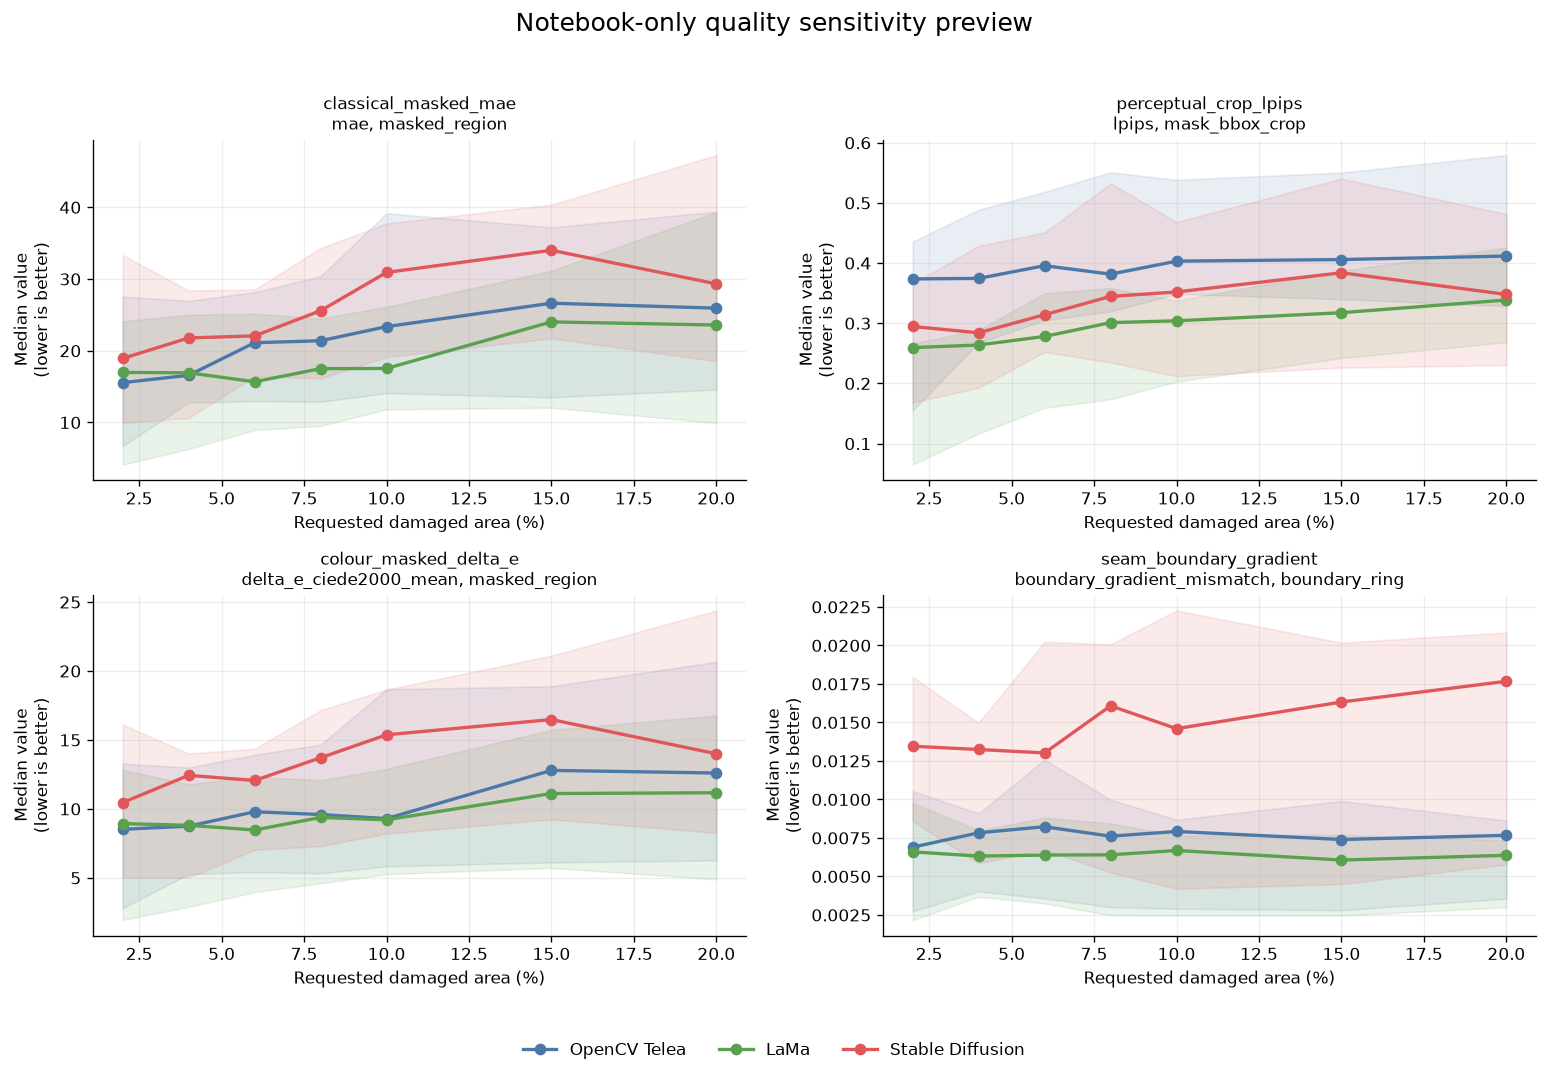

,anchor_id,evidence_family,metric_name,region_id,model_id,estimate,ci_lower,ci_upper,effect_size,p_value,q_value
2,classical_masked_mae,classical_pixel,mae,masked_region,opencv_telea,3.707553,1.415337,17.778759,1.000000,0.0625,0.0625
0,classical_masked_mae,classical_pixel,mae,masked_region,lama,4.160779,0.058304,18.333235,1.000000,0.0625,0.0625
4,classical_masked_mae,classical_pixel,mae,masked_region,stable_diffusion_inpainting,9.686547,5.911257,10.863746,1.000000,0.0625,0.0625
8,colour_masked_delta_e,colour,delta_e_ciede2000_mean,masked_region,opencv_telea,1.212552,0.783073,7.003295,1.000000,0.0625,0.0625
6,colour_masked_delta_e,colour,delta_e_ciede2000_mean,masked_region,lama,1.473896,0.144657,7.634027,1.000000,0.0625,0.0625
10,colour_masked_delta_e,colour,delta_e_ciede2000_mean,masked_region,stable_diffusion_inpainting,3.232347,2.399665,6.451921,1.000000,0.0625,0.0625
16,feature_clip_crop,feature_similarity,clip_cosine_similarity,mask_bbox_crop,stable_diffusion_inpainting,0.022675,-0.083623,0.048469,0.333333,0.8750,0.875
12,feature_clip_crop,feature_similarity,clip_cosine_similarity,mask_bbox_crop,lama,0.030974,0.000314,0.100191,1.000000,0.0625,0.1875
14,feature_clip_crop,feature_similarity,clip_cosine_similarity,mask_bbox_crop,opencv_telea,0.070698,-0.005219,0.122082,0.866667,0.1250,0.25
22,feature_dino_crop,feature_similarity,dinov2_cosine_similarity,mask_bbox_crop,stable_diffusion_inpainting,0.007283,-0.190282,0.080111,0.066667,0.8750,0.875


Rendered notebook-only performance curves.
Positive trend estimates mean worse performance per 10 percentage-point increase.


In [26]:
PLOT_ANCHORS = [
    "classical_masked_mae",
    "perceptual_crop_lpips",
    "colour_masked_delta_e",
    "seam_boundary_gradient",
]
MODEL_COLOURS = {
    "opencv_telea": "#4C78A8",
    "lama": "#59A14F",
    "stable_diffusion_inpainting": "#E15759",
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    squeeze=False,
)

for axis, anchor_id in zip(
    axes.flat,
    PLOT_ANCHORS,
):
    anchor_rows = QUALITY_LEVEL_SUMMARY.loc[
        QUALITY_LEVEL_SUMMARY["anchor_id"]
        .astype(str)
        .eq(anchor_id)
    ].copy()

    for model_id in POPULATION["model_order"]:
        model_rows = (
            anchor_rows.loc[
                anchor_rows["model_id"]
                .astype(str)
                .eq(str(model_id))
            ]
            .copy()
            .sort_values(
                "target_damage_fraction",
                kind="stable",
            )
        )

        x = (
            pd.to_numeric(
                model_rows["target_damage_fraction"],
                errors="coerce",
            ).to_numpy(dtype=float)
            * 100.0
        )
        y = pd.to_numeric(
            model_rows["estimate"],
            errors="coerce",
        ).to_numpy(dtype=float)
        lower = pd.to_numeric(
            model_rows["ci_lower"],
            errors="coerce",
        ).to_numpy(dtype=float)
        upper = pd.to_numeric(
            model_rows["ci_upper"],
            errors="coerce",
        ).to_numpy(dtype=float)

        axis.plot(
            x,
            y,
            marker="o",
            linewidth=2.0,
            color=MODEL_COLOURS[str(model_id)],
            label=MODEL_LABELS[str(model_id)],
        )
        axis.fill_between(
            x,
            lower,
            upper,
            color=MODEL_COLOURS[str(model_id)],
            alpha=0.12,
        )

    metric_name = str(
        anchor_rows["metric_name"].iloc[0]
    )
    region_id = str(
        anchor_rows["region_id"].iloc[0]
    )
    direction = str(
        anchor_rows["comparison_direction"].iloc[0]
    )

    axis.set_title(
        f"{anchor_id}\n{metric_name}, {region_id}",
        fontsize=10,
    )
    axis.set_xlabel("Requested damaged area (%)")
    axis.set_ylabel(
        f"Median value\n({direction.replace('_', ' ')})"
    )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncols=3,
    frameon=False,
)
fig.suptitle(
    "Notebook-only quality sensitivity preview",
    fontsize=15,
)
fig.tight_layout(rect=(0, 0.06, 1, 0.96))
plt.show()

target_trend_preview = (
    QUALITY_TREND_SUMMARY.loc[
        QUALITY_TREND_SUMMARY[
            "exposure_definition"
        ].astype(str).eq("target_damage_fraction")
    ]
    [
        [
            "anchor_id",
            "evidence_family",
            "metric_name",
            "region_id",
            "model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
            "effect_size",
            "p_value",
            "q_value",
        ]
    ]
    .copy()
    .sort_values(
        ["anchor_id", "estimate"],
        ascending=[True, True],
        kind="stable",
    )
)

display(target_trend_preview)

print("Rendered notebook-only performance curves.")
print(
    "Positive trend estimates mean worse performance "
    f"per {REPORTING_INTERVAL_PP:g} percentage-point increase."
)

In [27]:
BATCH_5_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"].eq(
            "batch_5_matched_sensitivity"
        )
    ]
    .reset_index(drop=True)
)

BATCH_5_SUMMARY = {
    "check_count": len(BATCH_5_CHECKS),
    "passed_count": int(BATCH_5_CHECKS["passed"].sum()),
    "blocking_failures": int(
        (
            BATCH_5_CHECKS["severity"].eq("blocking")
            & ~BATCH_5_CHECKS["passed"]
        ).sum()
    ),
}

display(BATCH_5_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 5 passed.")
print(f"Level-summary rows: {len(QUALITY_LEVEL_SUMMARY)}")
print(
    "Painting-trajectory rows: "
    f"{len(QUALITY_PAINTING_SLOPES)}"
)
print(
    "Population trend rows: "
    f"{len(QUALITY_TREND_SUMMARY)}"
)
print(f"Validation checks: {BATCH_5_SUMMARY['check_count']}")
print(f"Blocking failures: {BATCH_5_SUMMARY['blocking_failures']}")
print("No canonical Notebook 23 artifact has been written.")
print(
    "Next batch: model contrasts, adjacent deterioration, "
    "and family-balanced rankings."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_matched_sensitivity,anchor_model_trajectory_coverage,Every anchor–model trajectory contains 35 observations.,blocking,"{""groups"": 33, ""rows_per_group"": 35}","{""groups"": 33, ""maximum_rows"": 35, ""minimum_rows"": 35}",True,
1,batch_5_matched_sensitivity,quality_level_summary_rows,"Every anchor, model, and damage level has one summary row.",blocking,231,231,True,
2,batch_5_matched_sensitivity,painting_slope_rows,"Every anchor, model, exposure, and painting has one slope.",blocking,330,330,True,
3,batch_5_matched_sensitivity,quality_trend_rows,"Every anchor, model, and exposure has one matched trend estimate.",blocking,66,66,True,
4,batch_5_matched_sensitivity,exact_small_sample_arithmetic,"Trend inference uses 3,125 bootstrap resamples and valid exact-test probabilities.",blocking,"{""bootstrap_resamples"": 3125, ""p_value_range"": [0.0, 1.0]}","{""bootstrap_resamples"": [3125], ""maximum_p_value"": 1.0, ""minimum_p_value"": 0.0625}",True,
5,batch_5_matched_sensitivity,batch_5_analysis_schema,Batch 5 analysis rows satisfy the canonical analysis schema.,blocking,True,"{""analysis_ids_unique"": true, ""analysis_kinds_valid"": true, ""missing_columns"": [], ""no_combined_score_or_index"": tru...",True,


Batch 5 passed.
Level-summary rows: 231
Painting-trajectory rows: 330
Population trend rows: 66
Validation checks: 6
Blocking failures: 0
No canonical Notebook 23 artifact has been written.
Next batch: model contrasts, adjacent deterioration, and family-balanced rankings.


## Batch 6 — Adjacent deterioration, model contrasts, and rankings

This batch extends the damage-size analysis in four ways.

1. **Adjacent deterioration**

   Each painting is compared across the six consecutive damage intervals. Changes are normalized per percentage point so that the 2-point and 5-point intervals remain comparable.

2. **Paired model contrasts**

   Painting-level adverse slopes are compared between every pair of evaluated models. A positive difference means that the first named model deteriorated more rapidly.

3. **Evaluated baseline-type contrast**

   The mean trajectory of the two evaluated deterministic baselines—OpenCV Telea and LaMa—is compared with Stable Diffusion. This describes only these evaluated methods and is not a general deterministic-versus-generative class effect.

4. **Family-balanced rankings**

   Models are first ranked within each quality anchor. Anchor ranks are averaged within evidence families, and each family receives one equal vote. Ranking stability is checked by leaving out one painting at a time.

Runtime and uncertainty remain excluded from quality rankings.

In [28]:
from itertools import combinations

adjacent_detail_frames = []
adjacent_summary_records = []

total_adjacent_groups = len(trajectory_groups)

for group_number, (group_key, group) in enumerate(
    trajectory_groups,
    start=1,
):
    metadata = dict(zip(anchor_group_columns, group_key))
    direction = str(metadata["comparison_direction"])

    adjacent = compute_adjacent_changes(
        group,
        value_column="comparison_value",
        direction=direction,
        level_column="target_damage_fraction",
    )

    for column in anchor_group_columns:
        adjacent[column] = metadata[column]

    adjacent_detail_frames.append(adjacent)

    for (
        interval_start,
        interval_end,
    ), interval_rows in adjacent.groupby(
        [
            "interval_start_fraction",
            "interval_end_fraction",
        ],
        observed=True,
        sort=True,
    ):
        adverse_changes = pd.to_numeric(
            interval_rows[
                "adverse_change_per_percentage_point"
            ],
            errors="coerce",
        ).to_numpy(dtype=float)

        interval_bootstrap = exhaustive_bootstrap_interval(
            adverse_changes,
            confidence_level=CONFIDENCE_LEVEL,
            statistic=np.median,
        )
        interval_test = exact_sign_flip_test(
            adverse_changes
        )
        interval_effect = matched_rank_biserial(
            adverse_changes
        )

        interval_source_rows = group.loc[
            pd.to_numeric(
                group["target_damage_fraction"],
                errors="coerce",
            ).isin(
                [
                    float(interval_start),
                    float(interval_end),
                ]
            )
        ]

        adjacent_summary_records.append(
            build_analysis_record(
                analysis_kind="adjacent_change",
                analysis_family_id=str(
                    metadata["anchor_id"]
                ),
                row_identity=(
                    metadata["anchor_id"],
                    metadata["model_id"],
                    interval_start,
                    interval_end,
                ),
                source_rows=interval_source_rows,
                evidence_family=metadata[
                    "evidence_family"
                ],
                metric_family=metadata["metric_family"],
                metric_id=metadata["metric_id"],
                metric_name=metadata["metric_name"],
                feature_model_id=metadata[
                    "feature_model_id"
                ],
                region_id=metadata["region_id"],
                summary_statistic=metadata[
                    "summary_statistic"
                ],
                value_unit=(
                    f"{metadata['value_unit']}"
                    "_per_percentage_point"
                ),
                comparison_direction=direction,
                quality_ranking_eligible=True,
                anchor_id=metadata["anchor_id"],
                model_id=metadata["model_id"],
                comparison_model_id="not_applicable",
                exposure_definition=(
                    "target_damage_fraction"
                ),
                interval_start_fraction=float(
                    interval_start
                ),
                interval_end_fraction=float(
                    interval_end
                ),
                scope_type="adjacent_damage_interval",
                scope_value=(
                    f"{100 * float(interval_start):g}%–"
                    f"{100 * float(interval_end):g}%"
                ),
                n_paintings=int(
                    interval_rows["painting_id"].nunique()
                ),
                n_cases=int(
                    interval_source_rows["case_id"].nunique()
                ),
                n_observations=int(len(interval_rows)),
                estimate_name=(
                    "median_adverse_change_per_"
                    "percentage_point"
                ),
                estimate=float(
                    interval_bootstrap["estimate"]
                ),
                ci_lower=float(
                    interval_bootstrap["ci_lower"]
                ),
                ci_upper=float(
                    interval_bootstrap["ci_upper"]
                ),
                effect_size_name="matched_rank_biserial",
                effect_size=float(interval_effect),
                p_value=float(interval_test["p_value"]),
                q_value=pd.NA,
                test_method=SETTINGS["statistics"][
                    "exact_test"
                ],
                bootstrap_method=SETTINGS["statistics"][
                    "bootstrap_method"
                ],
                bootstrap_resamples=int(
                    interval_bootstrap["resamples"]
                ),
                interpretation_status=(
                    "positive_estimate_means_quality_worsened"
                ),
            )
        )

    if (
        group_number % 10 == 0
        or group_number == total_adjacent_groups
    ):
        print(
            f"Computed adjacent changes for "
            f"{group_number}/{total_adjacent_groups} "
            "anchor–model trajectories."
        )

QUALITY_ADJACENT_DETAIL = pd.concat(
    adjacent_detail_frames,
    ignore_index=True,
)

QUALITY_ADJACENT_SUMMARY = pd.DataFrame(
    adjacent_summary_records,
    columns=ANALYSIS_COLUMNS,
)

print("Adjacent deterioration analysis completed.")
print(
    f"Painting-level adjacent changes: "
    f"{len(QUALITY_ADJACENT_DETAIL)}"
)
print(
    f"Population interval summaries: "
    f"{len(QUALITY_ADJACENT_SUMMARY)}"
)

Computed adjacent changes for 10/33 anchor–model trajectories.
Computed adjacent changes for 20/33 anchor–model trajectories.
Computed adjacent changes for 30/33 anchor–model trajectories.
Computed adjacent changes for 33/33 anchor–model trajectories.
Adjacent deterioration analysis completed.
Painting-level adjacent changes: 990
Population interval summaries: 198


In [29]:
model_pairs = list(
    combinations(
        list(map(str, POPULATION["model_order"])),
        2,
    )
)

paired_contrast_records = []

slope_contrast_groups = list(
    QUALITY_PAINTING_SLOPES.groupby(
        [
            "anchor_id",
            "evidence_family",
            "metric_family",
            "metric_id",
            "metric_name",
            "feature_model_id",
            "region_id",
            "summary_statistic",
            "value_unit",
            "exposure_definition",
        ],
        observed=True,
        dropna=False,
        sort=True,
    )
)

total_pairwise_contrasts = (
    len(slope_contrast_groups) * len(model_pairs)
)
completed_pairwise_contrasts = 0

for group_key, slope_group in slope_contrast_groups:
    metadata = dict(
        zip(
            [
                "anchor_id",
                "evidence_family",
                "metric_family",
                "metric_id",
                "metric_name",
                "feature_model_id",
                "region_id",
                "summary_statistic",
                "value_unit",
                "exposure_definition",
            ],
            group_key,
        )
    )

    slope_matrix = slope_group.pivot(
        index="painting_id",
        columns="model_id",
        values="estimate",
    )

    for model_id, comparison_model_id in model_pairs:
        differences = (
            pd.to_numeric(
                slope_matrix[model_id],
                errors="coerce",
            )
            - pd.to_numeric(
                slope_matrix[comparison_model_id],
                errors="coerce",
            )
        ).to_numpy(dtype=float)

        contrast_bootstrap = exhaustive_bootstrap_interval(
            differences,
            confidence_level=CONFIDENCE_LEVEL,
            statistic=np.median,
        )
        contrast_test = exact_sign_flip_test(differences)
        contrast_effect = matched_rank_biserial(
            differences
        )

        source_rows = QUALITY_ANCHOR_ANALYSIS.loc[
            QUALITY_ANCHOR_ANALYSIS["anchor_id"]
            .astype(str)
            .eq(str(metadata["anchor_id"]))
            & QUALITY_ANCHOR_ANALYSIS["model_id"]
            .astype(str)
            .isin({model_id, comparison_model_id})
        ]

        paired_contrast_records.append(
            build_analysis_record(
                analysis_kind="paired_model_contrast",
                analysis_family_id=str(
                    metadata["anchor_id"]
                ),
                row_identity=(
                    metadata["anchor_id"],
                    metadata["exposure_definition"],
                    model_id,
                    comparison_model_id,
                ),
                source_rows=source_rows,
                evidence_family=metadata[
                    "evidence_family"
                ],
                metric_family=metadata["metric_family"],
                metric_id=metadata["metric_id"],
                metric_name=metadata["metric_name"],
                feature_model_id=metadata[
                    "feature_model_id"
                ],
                region_id=metadata["region_id"],
                summary_statistic=metadata[
                    "summary_statistic"
                ],
                value_unit=(
                    f"{metadata['value_unit']}_per_"
                    f"{REPORTING_INTERVAL_PP:g}_"
                    "percentage_points"
                ),
                comparison_direction="lower_is_better",
                quality_ranking_eligible=True,
                anchor_id=metadata["anchor_id"],
                model_id=model_id,
                comparison_model_id=(
                    comparison_model_id
                ),
                exposure_definition=metadata[
                    "exposure_definition"
                ],
                scope_type="paired_painting_slopes",
                scope_value=(
                    f"{model_id}_minus_"
                    f"{comparison_model_id}"
                ),
                n_paintings=int(len(differences)),
                n_cases=int(EXPECTED["cases"]),
                n_observations=int(len(differences)),
                estimate_name=(
                    "median_paired_adverse_slope_difference"
                ),
                estimate=float(
                    contrast_bootstrap["estimate"]
                ),
                ci_lower=float(
                    contrast_bootstrap["ci_lower"]
                ),
                ci_upper=float(
                    contrast_bootstrap["ci_upper"]
                ),
                effect_size_name="matched_rank_biserial",
                effect_size=float(contrast_effect),
                p_value=float(contrast_test["p_value"]),
                q_value=pd.NA,
                test_method=SETTINGS["statistics"][
                    "exact_test"
                ],
                bootstrap_method=SETTINGS["statistics"][
                    "bootstrap_method"
                ],
                bootstrap_resamples=int(
                    contrast_bootstrap["resamples"]
                ),
                interpretation_status=(
                    "positive_estimate_means_first_model_"
                    "deteriorated_more"
                ),
            )
        )

        completed_pairwise_contrasts += 1
        if (
            completed_pairwise_contrasts % 10 == 0
            or completed_pairwise_contrasts
            == total_pairwise_contrasts
        ):
            print(
                f"Computed {completed_pairwise_contrasts}/"
                f"{total_pairwise_contrasts} "
                "paired model contrasts."
            )

QUALITY_PAIRED_CONTRASTS = pd.DataFrame(
    paired_contrast_records,
    columns=ANALYSIS_COLUMNS,
)

print("Paired model contrasts completed.")
print(
    f"Paired contrast rows: "
    f"{len(QUALITY_PAIRED_CONTRASTS)}"
)

Computed 10/66 paired model contrasts.
Computed 20/66 paired model contrasts.
Computed 30/66 paired model contrasts.
Computed 40/66 paired model contrasts.
Computed 50/66 paired model contrasts.
Computed 60/66 paired model contrasts.
Computed 66/66 paired model contrasts.
Paired model contrasts completed.
Paired contrast rows: 66


In [30]:
baseline_type_records = []

for group_key, slope_group in slope_contrast_groups:
    metadata = dict(
        zip(
            [
                "anchor_id",
                "evidence_family",
                "metric_family",
                "metric_id",
                "metric_name",
                "feature_model_id",
                "region_id",
                "summary_statistic",
                "value_unit",
                "exposure_definition",
            ],
            group_key,
        )
    )

    slope_matrix = slope_group.pivot(
        index="painting_id",
        columns="model_id",
        values="estimate",
    )

    deterministic_mean = slope_matrix[
        ["opencv_telea", "lama"]
    ].apply(pd.to_numeric, errors="coerce").mean(axis=1)

    stable_diffusion_slopes = pd.to_numeric(
        slope_matrix["stable_diffusion_inpainting"],
        errors="coerce",
    )

    differences = (
        deterministic_mean - stable_diffusion_slopes
    ).to_numpy(dtype=float)

    contrast_bootstrap = exhaustive_bootstrap_interval(
        differences,
        confidence_level=CONFIDENCE_LEVEL,
        statistic=np.median,
    )
    contrast_test = exact_sign_flip_test(differences)
    contrast_effect = matched_rank_biserial(
        differences
    )

    source_rows = QUALITY_ANCHOR_ANALYSIS.loc[
        QUALITY_ANCHOR_ANALYSIS["anchor_id"]
        .astype(str)
        .eq(str(metadata["anchor_id"]))
    ]

    baseline_type_records.append(
        build_analysis_record(
            analysis_kind=(
                "evaluated_baseline_type_contrast"
            ),
            analysis_family_id=str(
                metadata["anchor_id"]
            ),
            row_identity=(
                metadata["anchor_id"],
                metadata["exposure_definition"],
                "evaluated_deterministic_baselines",
                "stable_diffusion_inpainting",
            ),
            source_rows=source_rows,
            evidence_family=metadata[
                "evidence_family"
            ],
            metric_family=metadata["metric_family"],
            metric_id=metadata["metric_id"],
            metric_name=metadata["metric_name"],
            feature_model_id=metadata[
                "feature_model_id"
            ],
            region_id=metadata["region_id"],
            summary_statistic=metadata[
                "summary_statistic"
            ],
            value_unit=(
                f"{metadata['value_unit']}_per_"
                f"{REPORTING_INTERVAL_PP:g}_"
                "percentage_points"
            ),
            comparison_direction="lower_is_better",
            quality_ranking_eligible=True,
            anchor_id=metadata["anchor_id"],
            model_id="evaluated_deterministic_baselines",
            comparison_model_id=(
                "stable_diffusion_inpainting"
            ),
            exposure_definition=metadata[
                "exposure_definition"
            ],
            scope_type=(
                "evaluated_method_baseline_contrast"
            ),
            scope_value=(
                "mean_of_telea_and_lama_minus_"
                "stable_diffusion"
            ),
            n_paintings=int(len(differences)),
            n_cases=int(EXPECTED["cases"]),
            n_observations=int(len(differences)),
            estimate_name=(
                "median_paired_adverse_slope_difference"
            ),
            estimate=float(
                contrast_bootstrap["estimate"]
            ),
            ci_lower=float(
                contrast_bootstrap["ci_lower"]
            ),
            ci_upper=float(
                contrast_bootstrap["ci_upper"]
            ),
            effect_size_name="matched_rank_biserial",
            effect_size=float(contrast_effect),
            p_value=float(contrast_test["p_value"]),
            q_value=pd.NA,
            test_method=SETTINGS["statistics"][
                "exact_test"
            ],
            bootstrap_method=SETTINGS["statistics"][
                "bootstrap_method"
            ],
            bootstrap_resamples=int(
                contrast_bootstrap["resamples"]
            ),
            interpretation_status=(
                "evaluated_methods_only_not_a_general_"
                "model_class_effect"
            ),
        )
    )

QUALITY_BASELINE_TYPE_CONTRASTS = pd.DataFrame(
    baseline_type_records,
    columns=ANALYSIS_COLUMNS,
)

BATCH_6_INFERENTIAL = pd.DataFrame(
    [
        *QUALITY_ADJACENT_SUMMARY.to_dict("records"),
        *QUALITY_PAIRED_CONTRASTS.to_dict("records"),
        *QUALITY_BASELINE_TYPE_CONTRASTS.to_dict(
            "records"
        ),
    ],
    columns=ANALYSIS_COLUMNS,
)

BATCH_6_INFERENTIAL["p_value"] = pd.to_numeric(
    BATCH_6_INFERENTIAL["p_value"],
    errors="coerce",
)

for _, indices in BATCH_6_INFERENTIAL.groupby(
    [
        "analysis_kind",
        "evidence_family",
        "exposure_definition",
    ],
    observed=True,
    dropna=False,
).groups.items():
    positions = list(indices)
    BATCH_6_INFERENTIAL.loc[
        positions,
        "q_value",
    ] = benjamini_hochberg(
        BATCH_6_INFERENTIAL.loc[
            positions,
            "p_value",
        ].to_numpy(dtype=float)
    )

QUALITY_ADJACENT_SUMMARY = (
    BATCH_6_INFERENTIAL.loc[
        BATCH_6_INFERENTIAL["analysis_kind"]
        .eq("adjacent_change")
    ]
    .copy()
    .reset_index(drop=True)
)
QUALITY_PAIRED_CONTRASTS = (
    BATCH_6_INFERENTIAL.loc[
        BATCH_6_INFERENTIAL["analysis_kind"]
        .eq("paired_model_contrast")
    ]
    .copy()
    .reset_index(drop=True)
)
QUALITY_BASELINE_TYPE_CONTRASTS = (
    BATCH_6_INFERENTIAL.loc[
        BATCH_6_INFERENTIAL["analysis_kind"]
        .eq("evaluated_baseline_type_contrast")
    ]
    .copy()
    .reset_index(drop=True)
)

print("Evaluated baseline-type contrasts completed.")
print(
    "Baseline-type contrast rows: "
    f"{len(QUALITY_BASELINE_TYPE_CONTRASTS)}"
)
print(
    "These rows describe only Telea, LaMa, and "
    "Stable Diffusion as evaluated here."
)

Evaluated baseline-type contrasts completed.
Baseline-type contrast rows: 22
These rows describe only Telea, LaMa, and Stable Diffusion as evaluated here.


In [31]:
anchor_rank_frames = []
overall_rank_frames = []
loo_rank_records = []

for level_number, target_fraction in enumerate(
    expected_target_levels,
    start=1,
):
    level_rows = QUALITY_ANCHOR_ANALYSIS.loc[
        np.isclose(
            QUALITY_ANCHOR_ANALYSIS[
                "target_damage_fraction"
            ].to_numpy(dtype=float),
            float(target_fraction),
            atol=1e-12,
            rtol=0.0,
        )
    ].copy()

    level_id = str(level_rows["level_id"].iloc[0])

    anchor_ranks, overall_ranks = family_balanced_ranks(
        level_rows,
        rank_method=SETTINGS["statistics"][
            "ranking_method"
        ],
    )

    anchor_ranks["level_id"] = level_id
    anchor_ranks["target_damage_fraction"] = float(
        target_fraction
    )
    anchor_rank_frames.append(anchor_ranks)

    overall_ranks["level_id"] = level_id
    overall_ranks["target_damage_fraction"] = float(
        target_fraction
    )
    overall_rank_frames.append(overall_ranks)

    painting_ids_at_level = sorted(
        level_rows["painting_id"]
        .astype(str)
        .unique()
    )

    for omitted_painting_id in painting_ids_at_level:
        reduced_rows = level_rows.loc[
            ~level_rows["painting_id"]
            .astype(str)
            .eq(omitted_painting_id)
        ]

        _, reduced_overall = family_balanced_ranks(
            reduced_rows,
            rank_method=SETTINGS["statistics"][
                "ranking_method"
            ],
        )

        for rank_row in reduced_overall.itertuples(
            index=False
        ):
            loo_rank_records.append(
                {
                    "level_id": level_id,
                    "target_damage_fraction": float(
                        target_fraction
                    ),
                    "omitted_painting_id": (
                        omitted_painting_id
                    ),
                    "model_id": str(rank_row.model_id),
                    "family_balanced_rank": float(
                        rank_row.family_balanced_rank
                    ),
                    "overall_rank": float(
                        rank_row.overall_rank
                    ),
                }
            )

    print(
        f"Ranked damage level {level_number}/"
        f"{len(expected_target_levels)}: {level_id}"
    )

ANCHOR_RANKS_BY_LEVEL = pd.concat(
    anchor_rank_frames,
    ignore_index=True,
)
OVERALL_RANKS_BY_LEVEL = pd.concat(
    overall_rank_frames,
    ignore_index=True,
)
LOO_RANKS_BY_LEVEL = pd.DataFrame(loo_rank_records)

print("Family-balanced ranking completed.")
print(
    f"Anchor-rank rows: {len(ANCHOR_RANKS_BY_LEVEL)}"
)
print(
    f"Overall level-rank rows: "
    f"{len(OVERALL_RANKS_BY_LEVEL)}"
)
print(
    f"Leave-one-painting-out replicate rows: "
    f"{len(LOO_RANKS_BY_LEVEL)}"
)

Ranked damage level 1/7: size_02pct
Ranked damage level 2/7: size_04pct
Ranked damage level 3/7: size_06pct
Ranked damage level 4/7: size_08pct
Ranked damage level 5/7: size_10pct
Ranked damage level 6/7: size_15pct
Ranked damage level 7/7: size_20pct
Family-balanced ranking completed.
Anchor-rank rows: 231
Overall level-rank rows: 21
Leave-one-painting-out replicate rows: 105


In [32]:
ranking_records = []
ranking_stability_records = []

for level_row in (
    OVERALL_RANKS_BY_LEVEL[
        [
            "level_id",
            "target_damage_fraction",
        ]
    ]
    .drop_duplicates()
    .sort_values("target_damage_fraction")
    .itertuples(index=False)
):
    level_id = str(level_row.level_id)
    target_fraction = float(
        level_row.target_damage_fraction
    )

    level_source_rows = QUALITY_ANCHOR_ANALYSIS.loc[
        QUALITY_ANCHOR_ANALYSIS["level_id"]
        .astype(str)
        .eq(level_id)
    ]
    realized_fraction = float(
        pd.to_numeric(
            level_source_rows[
                "realized_damage_fraction"
            ],
            errors="coerce",
        ).median()
    )

    level_ranks = OVERALL_RANKS_BY_LEVEL.loc[
        OVERALL_RANKS_BY_LEVEL["level_id"]
        .astype(str)
        .eq(level_id)
    ]

    for rank_row in level_ranks.itertuples(index=False):
        model_id = str(rank_row.model_id)

        ranking_records.append(
            build_analysis_record(
                analysis_kind="ranking_by_level",
                analysis_family_id=(
                    "family_balanced_quality_ranking"
                ),
                row_identity=(
                    level_id,
                    model_id,
                ),
                source_rows=level_source_rows,
                evidence_family=(
                    "family_balanced_quality"
                ),
                metric_family=(
                    "family_balanced_quality"
                ),
                metric_id=(
                    "family_balanced_quality_rank"
                ),
                metric_name=(
                    "family_balanced_quality_rank"
                ),
                feature_model_id="not_applicable",
                region_id="multiple_registered_regions",
                summary_statistic="family_balanced_mean",
                value_unit="rank",
                comparison_direction="lower_is_better",
                quality_ranking_eligible=False,
                anchor_id="family_balanced",
                model_id=model_id,
                comparison_model_id="not_applicable",
                exposure_definition=(
                    "target_damage_fraction"
                ),
                level_id=level_id,
                target_damage_fraction=target_fraction,
                realized_damage_fraction=(
                    realized_fraction
                ),
                scope_type="damage_level",
                scope_value=level_id,
                n_paintings=int(
                    level_source_rows[
                        "painting_id"
                    ].nunique()
                ),
                n_cases=int(
                    level_source_rows["case_id"].nunique()
                ),
                n_observations=int(
                    len(level_source_rows)
                ),
                estimate_name=(
                    "family_balanced_mean_rank"
                ),
                estimate=float(
                    rank_row.family_balanced_rank
                ),
                ci_lower=pd.NA,
                ci_upper=pd.NA,
                effect_size_name="ordinal_overall_rank",
                effect_size=float(
                    rank_row.overall_rank
                ),
                p_value=pd.NA,
                q_value=pd.NA,
                test_method="not_applicable",
                bootstrap_method="not_applicable",
                bootstrap_resamples=0,
                interpretation_status=(
                    "lower_rank_is_better_metric_families_"
                    "receive_equal_weight"
                ),
            )
        )

        loo_rows = LOO_RANKS_BY_LEVEL.loc[
            LOO_RANKS_BY_LEVEL["level_id"]
            .astype(str)
            .eq(level_id)
            & LOO_RANKS_BY_LEVEL["model_id"]
            .astype(str)
            .eq(model_id)
        ]

        stability_statistics = {
            "loo_top_rank_fraction": float(
                np.isclose(
                    loo_rows["overall_rank"].to_numpy(
                        dtype=float
                    ),
                    1.0,
                ).mean()
            ),
            "loo_rank_min": float(
                loo_rows["overall_rank"].min()
            ),
            "loo_rank_max": float(
                loo_rows["overall_rank"].max()
            ),
        }

        for (
            estimate_name,
            estimate_value,
        ) in stability_statistics.items():
            ranking_stability_records.append(
                build_analysis_record(
                    analysis_kind="ranking_stability",
                    analysis_family_id=(
                        "family_balanced_quality_ranking"
                    ),
                    row_identity=(
                        level_id,
                        model_id,
                        estimate_name,
                    ),
                    source_rows=level_source_rows,
                    evidence_family=(
                        "family_balanced_quality"
                    ),
                    metric_family=(
                        "ranking_stability"
                    ),
                    metric_id=estimate_name,
                    metric_name=estimate_name,
                    feature_model_id="not_applicable",
                    region_id=(
                        "multiple_registered_regions"
                    ),
                    summary_statistic=(
                        "leave_one_painting_out"
                    ),
                    value_unit=(
                        "fraction"
                        if estimate_name
                        == "loo_top_rank_fraction"
                        else "rank"
                    ),
                    comparison_direction=(
                        "higher_is_better"
                        if estimate_name
                        == "loo_top_rank_fraction"
                        else "descriptive_only"
                    ),
                    quality_ranking_eligible=False,
                    anchor_id="family_balanced",
                    model_id=model_id,
                    comparison_model_id=(
                        "not_applicable"
                    ),
                    exposure_definition=(
                        "target_damage_fraction"
                    ),
                    level_id=level_id,
                    target_damage_fraction=(
                        target_fraction
                    ),
                    realized_damage_fraction=(
                        realized_fraction
                    ),
                    scope_type=(
                        "leave_one_painting_out"
                    ),
                    scope_value=level_id,
                    n_paintings=int(
                        EXPECTED["paintings"]
                    ),
                    n_cases=int(
                        level_source_rows[
                            "case_id"
                        ].nunique()
                    ),
                    n_observations=int(
                        len(loo_rows)
                    ),
                    estimate_name=estimate_name,
                    estimate=estimate_value,
                    ci_lower=pd.NA,
                    ci_upper=pd.NA,
                    effect_size_name="not_applicable",
                    effect_size=pd.NA,
                    p_value=pd.NA,
                    q_value=pd.NA,
                    test_method="not_applicable",
                    bootstrap_method="not_applicable",
                    bootstrap_resamples=0,
                    interpretation_status=(
                        "descriptive_leave_one_painting_"
                        "out_stability"
                    ),
                )
            )

QUALITY_RANKING_BY_LEVEL = pd.DataFrame(
    ranking_records,
    columns=ANALYSIS_COLUMNS,
)
QUALITY_RANKING_STABILITY = pd.DataFrame(
    ranking_stability_records,
    columns=ANALYSIS_COLUMNS,
)

print("Canonical ranking rows assembled.")
print(
    f"Ranking-by-level rows: "
    f"{len(QUALITY_RANKING_BY_LEVEL)}"
)
print(
    f"Ranking-stability rows: "
    f"{len(QUALITY_RANKING_STABILITY)}"
)

Canonical ranking rows assembled.
Ranking-by-level rows: 21
Ranking-stability rows: 63


In [33]:
BATCH_6_ANALYSIS = pd.DataFrame(
    [
        *BATCH_6_INFERENTIAL.to_dict("records"),
        *QUALITY_RANKING_BY_LEVEL.to_dict("records"),
        *QUALITY_RANKING_STABILITY.to_dict("records"),
    ],
    columns=ANALYSIS_COLUMNS,
)

ANALYSIS_PARTS.append(BATCH_6_ANALYSIS)

CUMULATIVE_ANALYSIS = pd.DataFrame(
    [
        record
        for frame in ANALYSIS_PARTS
        for record in frame.to_dict("records")
    ],
    columns=ANALYSIS_COLUMNS,
)

batch_6_table_validation = validate_damage_size_analysis(
    BATCH_6_ANALYSIS,
    config=ANALYSIS_CONFIG,
)
cumulative_table_validation = validate_damage_size_analysis(
    CUMULATIVE_ANALYSIS,
    config=ANALYSIS_CONFIG,
)

expected_adjacent_rows = (
    int(EXPECTED["quality_anchors"])
    * len(POPULATION["model_order"])
    * len(SETTINGS["statistics"]["adjacent_intervals"])
)
expected_pairwise_contrast_rows = (
    int(EXPECTED["quality_anchors"])
    * len(EXPOSURE_COLUMNS)
    * len(model_pairs)
)
expected_baseline_type_rows = (
    int(EXPECTED["quality_anchors"])
    * len(EXPOSURE_COLUMNS)
)
expected_ranking_rows = (
    int(EXPECTED["damage_levels"])
    * len(POPULATION["model_order"])
)
expected_stability_rows = expected_ranking_rows * 3

VALIDATION.add(
    validation_stage="batch_6_contrasts_rankings",
    check_id="adjacent_change_rows",
    check_description="Every anchor, model, and adjacent interval has one matched summary.",
    severity="blocking",
    expected=expected_adjacent_rows,
    observed=len(QUALITY_ADJACENT_SUMMARY),
    passed=(
        len(QUALITY_ADJACENT_SUMMARY)
        == expected_adjacent_rows
        and pd.to_numeric(
            QUALITY_ADJACENT_SUMMARY["n_paintings"],
            errors="coerce",
        )
        .eq(int(EXPECTED["paintings"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_6_contrasts_rankings",
    check_id="paired_model_contrast_rows",
    check_description="Every anchor and exposure contains all three paired model contrasts.",
    severity="blocking",
    expected=expected_pairwise_contrast_rows,
    observed=len(QUALITY_PAIRED_CONTRASTS),
    passed=(
        len(QUALITY_PAIRED_CONTRASTS)
        == expected_pairwise_contrast_rows
    ),
)
VALIDATION.add(
    validation_stage="batch_6_contrasts_rankings",
    check_id="evaluated_baseline_type_rows",
    check_description="Every anchor and exposure contains one evaluated baseline-type contrast.",
    severity="blocking",
    expected=expected_baseline_type_rows,
    observed=len(QUALITY_BASELINE_TYPE_CONTRASTS),
    passed=(
        len(QUALITY_BASELINE_TYPE_CONTRASTS)
        == expected_baseline_type_rows
        and QUALITY_BASELINE_TYPE_CONTRASTS[
            "interpretation_status"
        ]
        .astype(str)
        .str.contains(
            "not_a_general_model_class_effect",
            regex=False,
        )
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_6_contrasts_rankings",
    check_id="ranking_by_level_rows",
    check_description="Every damage level ranks all three models once.",
    severity="blocking",
    expected=expected_ranking_rows,
    observed=len(QUALITY_RANKING_BY_LEVEL),
    passed=(
        len(QUALITY_RANKING_BY_LEVEL)
        == expected_ranking_rows
        and QUALITY_RANKING_BY_LEVEL.groupby(
            "level_id",
            observed=True,
        )["model_id"]
        .nunique()
        .eq(len(POPULATION["model_order"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_6_contrasts_rankings",
    check_id="leave_one_painting_out_coverage",
    check_description="Ranking stability contains five omissions and three reported statistics per model and level.",
    severity="blocking",
    expected={
        "replicate_rows": (
            int(EXPECTED["damage_levels"])
            * int(EXPECTED["paintings"])
            * len(POPULATION["model_order"])
        ),
        "canonical_rows": expected_stability_rows,
    },
    observed={
        "replicate_rows": len(LOO_RANKS_BY_LEVEL),
        "canonical_rows": len(
            QUALITY_RANKING_STABILITY
        ),
    },
    passed=(
        len(LOO_RANKS_BY_LEVEL)
        == int(EXPECTED["damage_levels"])
        * int(EXPECTED["paintings"])
        * len(POPULATION["model_order"])
        and len(QUALITY_RANKING_STABILITY)
        == expected_stability_rows
    ),
)
VALIDATION.add(
    validation_stage="batch_6_contrasts_rankings",
    check_id="runtime_and_uncertainty_excluded_from_ranking",
    check_description="Quality rankings contain no runtime or uncertainty evidence.",
    severity="blocking",
    expected=True,
    observed={
        "ranking_evidence_families": sorted(
            QUALITY_RANKING_BY_LEVEL[
                "evidence_family"
            ]
            .astype(str)
            .unique()
        ),
        "source_contains_runtime": bool(
            QUALITY_ANCHOR_ANALYSIS[
                "evidence_family"
            ]
            .astype(str)
            .eq("runtime_compute")
            .any()
        ),
        "source_contains_uncertainty": bool(
            QUALITY_ANCHOR_ANALYSIS[
                "evidence_family"
            ]
            .astype(str)
            .str.contains("uncertainty")
            .any()
        ),
    },
    passed=(
        not QUALITY_ANCHOR_ANALYSIS[
            "evidence_family"
        ]
        .astype(str)
        .eq("runtime_compute")
        .any()
        and not QUALITY_ANCHOR_ANALYSIS[
            "evidence_family"
        ]
        .astype(str)
        .str.contains("uncertainty")
        .any()
    ),
)
VALIDATION.add(
    validation_stage="batch_6_contrasts_rankings",
    check_id="batch_6_analysis_schema",
    check_description="Batch 6 rows satisfy the canonical analysis schema.",
    severity="blocking",
    expected=True,
    observed=batch_6_table_validation,
    passed=bool(batch_6_table_validation["passed"]),
)
VALIDATION.add(
    validation_stage="batch_6_contrasts_rankings",
    check_id="cumulative_analysis_ids_unique",
    check_description="Batch 5 and Batch 6 analysis IDs remain unique.",
    severity="blocking",
    expected=True,
    observed=cumulative_table_validation,
    passed=bool(cumulative_table_validation["passed"]),
)

print("Batch 6 canonical analysis rows validated.")
print(f"Batch 6 rows: {len(BATCH_6_ANALYSIS)}")
print(
    f"Cumulative analysis rows: "
    f"{len(CUMULATIVE_ANALYSIS)}"
)

Batch 6 canonical analysis rows validated.
Batch 6 rows: 370
Cumulative analysis rows: 997


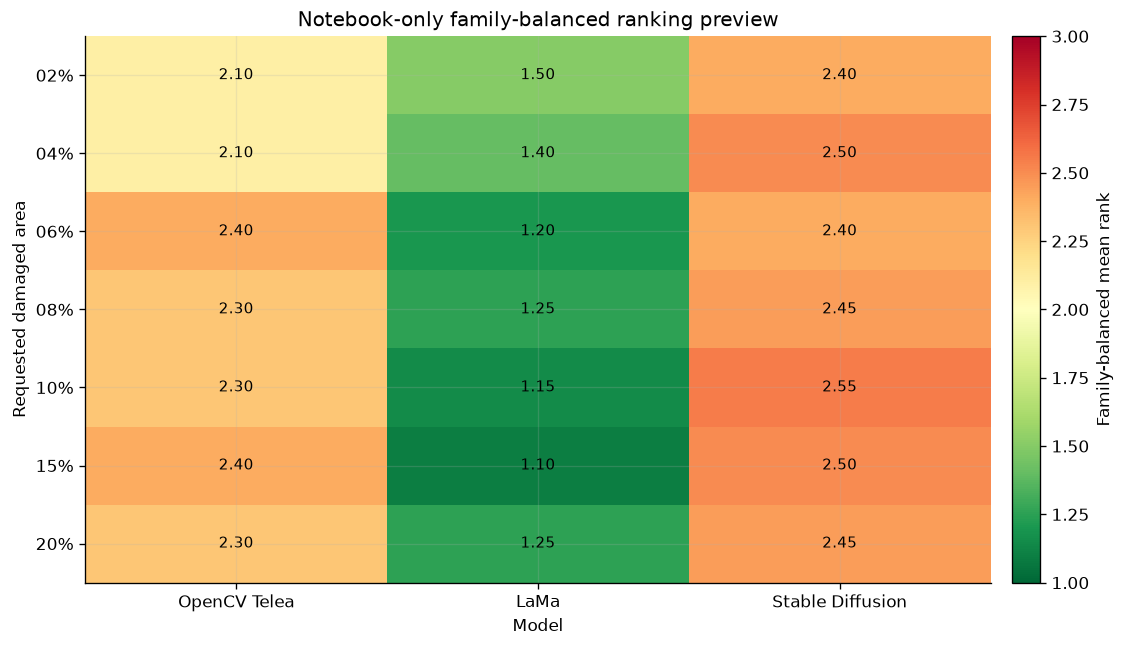

model_id,opencv_telea,lama,stable_diffusion_inpainting
level_id,,,
size_02pct,2.1,1.50,2.40
size_04pct,2.1,1.40,2.50
size_06pct,2.4,1.20,2.40
size_08pct,2.3,1.25,2.45
size_10pct,2.3,1.15,2.55
size_15pct,2.4,1.10,2.50
size_20pct,2.3,1.25,2.45


,anchor_id,model_id,comparison_model_id,estimate,ci_lower,ci_upper,effect_size,p_value,q_value
5,classical_masked_mae,lama,stable_diffusion_inpainting,-5.866723,-9.628243,11.528986,-0.333333,0.5000,0.6875
3,classical_masked_mae,opencv_telea,lama,-0.453227,-1.335552,3.422305,0.200000,0.5000,0.6875
4,classical_masked_mae,opencv_telea,stable_diffusion_inpainting,-4.495919,-6.319950,10.974510,-0.333333,0.6875,0.6875
11,colour_masked_delta_e,lama,stable_diffusion_inpainting,-1.112167,-4.217386,4.401680,-0.333333,0.4375,0.625
9,colour_masked_delta_e,opencv_telea,lama,-0.249934,-0.690822,2.398926,0.200000,0.6250,0.625
10,colour_masked_delta_e,opencv_telea,stable_diffusion_inpainting,-1.667292,-2.744908,3.770949,-0.333333,0.5625,0.625
17,feature_clip_crop,lama,stable_diffusion_inpainting,0.033581,-0.017495,0.095847,0.600000,0.2500,0.3
15,feature_clip_crop,opencv_telea,lama,0.021891,-0.017443,0.039724,0.733333,0.1875,0.28125
16,feature_clip_crop,opencv_telea,stable_diffusion_inpainting,0.044283,0.022229,0.099407,1.000000,0.0625,0.1875
23,feature_dino_crop,lama,stable_diffusion_inpainting,0.082343,0.035458,0.237587,1.000000,0.0625,0.1875


Rendered notebook-only ranking preview.
Lower family-balanced ranks indicate stronger performance across equally weighted evidence families.


In [34]:
rank_matrix = (
    QUALITY_RANKING_BY_LEVEL.pivot(
        index="level_id",
        columns="model_id",
        values="estimate",
    )
    .reindex(POPULATION["level_ids"])
    .reindex(columns=POPULATION["model_order"])
)

fig, axis = plt.subplots(figsize=(10, 5.5))

rank_image = axis.imshow(
    rank_matrix.to_numpy(dtype=float),
    cmap="RdYlGn_r",
    vmin=1.0,
    vmax=float(len(POPULATION["model_order"])),
    aspect="auto",
)

axis.set_xticks(
    range(len(rank_matrix.columns)),
    [
        MODEL_LABELS[str(model_id)]
        for model_id in rank_matrix.columns
    ],
)
axis.set_yticks(
    range(len(rank_matrix.index)),
    [
        str(level_id).replace("size_", "").replace(
            "pct",
            "%",
        )
        for level_id in rank_matrix.index
    ],
)
axis.set_xlabel("Model")
axis.set_ylabel("Requested damaged area")
axis.set_title(
    "Notebook-only family-balanced ranking preview"
)

for row_index in range(rank_matrix.shape[0]):
    for column_index in range(rank_matrix.shape[1]):
        value = float(
            rank_matrix.iloc[row_index, column_index]
        )
        axis.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9,
        )

colourbar = fig.colorbar(
    rank_image,
    ax=axis,
    pad=0.02,
)
colourbar.set_label("Family-balanced mean rank")

fig.tight_layout()
plt.show()

target_pairwise_preview = (
    QUALITY_PAIRED_CONTRASTS.loc[
        QUALITY_PAIRED_CONTRASTS[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
    ]
    [
        [
            "anchor_id",
            "model_id",
            "comparison_model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
            "effect_size",
            "p_value",
            "q_value",
        ]
    ]
    .copy()
    .sort_values(
        ["anchor_id", "model_id", "comparison_model_id"],
        kind="stable",
    )
)

display(rank_matrix)
display(target_pairwise_preview)

print("Rendered notebook-only ranking preview.")
print(
    "Lower family-balanced ranks indicate stronger "
    "performance across equally weighted evidence families."
)

In [35]:
BATCH_6_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"].eq(
            "batch_6_contrasts_rankings"
        )
    ]
    .reset_index(drop=True)
)

BATCH_6_SUMMARY = {
    "check_count": len(BATCH_6_CHECKS),
    "passed_count": int(BATCH_6_CHECKS["passed"].sum()),
    "blocking_failures": int(
        (
            BATCH_6_CHECKS["severity"].eq("blocking")
            & ~BATCH_6_CHECKS["passed"]
        ).sum()
    ),
}

display(BATCH_6_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 6 passed.")
print(
    f"Adjacent-change rows: "
    f"{len(QUALITY_ADJACENT_SUMMARY)}"
)
print(
    f"Paired model contrasts: "
    f"{len(QUALITY_PAIRED_CONTRASTS)}"
)
print(
    "Evaluated baseline-type contrasts: "
    f"{len(QUALITY_BASELINE_TYPE_CONTRASTS)}"
)
print(
    f"Ranking-by-level rows: "
    f"{len(QUALITY_RANKING_BY_LEVEL)}"
)
print(
    f"Ranking-stability rows: "
    f"{len(QUALITY_RANKING_STABILITY)}"
)
print(f"Validation checks: {BATCH_6_SUMMARY['check_count']}")
print(f"Blocking failures: {BATCH_6_SUMMARY['blocking_failures']}")
print("No canonical Notebook 23 artifact has been written.")
print(
    "Next batch: uncertainty trends, morphology "
    "associations, and painting-specific trajectories."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_contrasts_rankings,adjacent_change_rows,"Every anchor, model, and adjacent interval has one matched summary.",blocking,198,198,True,
1,batch_6_contrasts_rankings,paired_model_contrast_rows,Every anchor and exposure contains all three paired model contrasts.,blocking,66,66,True,
2,batch_6_contrasts_rankings,evaluated_baseline_type_rows,Every anchor and exposure contains one evaluated baseline-type contrast.,blocking,22,22,True,
3,batch_6_contrasts_rankings,ranking_by_level_rows,Every damage level ranks all three models once.,blocking,21,21,True,
4,batch_6_contrasts_rankings,leave_one_painting_out_coverage,Ranking stability contains five omissions and three reported statistics per model and level.,blocking,"{""canonical_rows"": 63, ""replicate_rows"": 105}","{""canonical_rows"": 63, ""replicate_rows"": 105}",True,
5,batch_6_contrasts_rankings,runtime_and_uncertainty_excluded_from_ranking,Quality rankings contain no runtime or uncertainty evidence.,blocking,True,"{""ranking_evidence_families"": [""family_balanced_quality""], ""source_contains_runtime"": false, ""source_contains_uncert...",True,
6,batch_6_contrasts_rankings,batch_6_analysis_schema,Batch 6 rows satisfy the canonical analysis schema.,blocking,True,"{""analysis_ids_unique"": true, ""analysis_kinds_valid"": true, ""missing_columns"": [], ""no_combined_score_or_index"": tru...",True,
7,batch_6_contrasts_rankings,cumulative_analysis_ids_unique,Batch 5 and Batch 6 analysis IDs remain unique.,blocking,True,"{""analysis_ids_unique"": true, ""analysis_kinds_valid"": true, ""missing_columns"": [], ""no_combined_score_or_index"": tru...",True,


Batch 6 passed.
Adjacent-change rows: 198
Paired model contrasts: 66
Evaluated baseline-type contrasts: 22
Ranking-by-level rows: 21
Ranking-stability rows: 63
Validation checks: 8
Blocking failures: 0
No canonical Notebook 23 artifact has been written.
Next batch: uncertainty trends, morphology associations, and painting-specific trajectories.


## Batch 7 — Uncertainty trends, morphology associations, and painting trajectories

This batch evaluates how Stable Diffusion seed variability changes with damage size.

For each transparent uncertainty component, it computes:

- median uncertainty at each damage level;
- one uncertainty slope per painting;
- a five-painting trend summary using the same exact bootstrap and sign-flip procedures as the quality analysis.

The batch also explores whether mask geometry is associated with worse restoration outcomes after adjusting for damage size and painting identity.

These morphology associations are exploratory and non-causal. Invariant morphology fields are omitted rather than assigned artificial correlations.

Painting-specific quality and uncertainty slopes remain separate. Values from incompatible metric scales are not averaged into a combined score.

In [36]:
UNCERTAINTY_ANALYSIS = UNCERTAINTY_EVIDENCE.copy()

UNCERTAINTY_ANALYSIS = UNCERTAINTY_ANALYSIS.merge(
    CASE_DESIGN[
        [
            "case_id",
            "level_id",
        ]
    ].drop_duplicates("case_id"),
    on="case_id",
    how="left",
    validate="many_to_one",
)

UNCERTAINTY_ANALYSIS["source_notebook_id"] = "22"
UNCERTAINTY_ANALYSIS["source_metric_row_id"] = [
    stable_analysis_id(
        "uncertainty_source",
        group_id,
        metric_family,
        metric_name,
        region_id,
    )
    for group_id, metric_family, metric_name, region_id in zip(
        UNCERTAINTY_ANALYSIS["uncertainty_group_id"],
        UNCERTAINTY_ANALYSIS["metric_family"],
        UNCERTAINTY_ANALYSIS["metric_name"],
        UNCERTAINTY_ANALYSIS["region_id"],
    )
]
UNCERTAINTY_ANALYSIS["evidence_family"] = (
    "diffusion_uncertainty"
)
UNCERTAINTY_ANALYSIS["comparison_value"] = pd.to_numeric(
    UNCERTAINTY_ANALYSIS["value"],
    errors="coerce",
)
UNCERTAINTY_ANALYSIS["feature_model_id"] = ""
UNCERTAINTY_ANALYSIS["quality_ranking_eligible"] = False
UNCERTAINTY_ANALYSIS["anchor_id"] = ""

UNCERTAINTY_ANALYSIS["uncertainty_component_key"] = [
    (
        str(component_id)
        if str(component_id).strip()
        else stable_analysis_id(
            "uncertainty_component",
            metric_family,
            metric_name,
            region_id,
        )
    )
    for component_id, metric_family, metric_name, region_id in zip(
        UNCERTAINTY_ANALYSIS["component_id"],
        UNCERTAINTY_ANALYSIS["metric_family"],
        UNCERTAINTY_ANALYSIS["metric_name"],
        UNCERTAINTY_ANALYSIS["region_id"],
    )
]

UNCERTAINTY_ANALYSIS["metric_id"] = [
    stable_analysis_id(
        "uncertainty_metric",
        metric_family,
        metric_name,
        region_id,
    )
    for metric_family, metric_name, region_id in zip(
        UNCERTAINTY_ANALYSIS["metric_family"],
        UNCERTAINTY_ANALYSIS["metric_name"],
        UNCERTAINTY_ANALYSIS["region_id"],
    )
]

uncertainty_group_columns = [
    "uncertainty_component_key",
    "component_id",
    "evidence_family",
    "metric_family",
    "metric_id",
    "metric_name",
    "region_id",
    "summary_statistic",
    "value_unit",
    "comparison_direction",
    "model_id",
]

uncertainty_component_sizes = (
    UNCERTAINTY_ANALYSIS.groupby(
        uncertainty_group_columns,
        observed=True,
        dropna=False,
    )
    .size()
)

VALIDATION.add(
    validation_stage="batch_7_uncertainty_morphology",
    check_id="uncertainty_component_trajectory_coverage",
    check_description="Every normalized uncertainty component contains all 35 cases.",
    severity="blocking",
    expected={
        "components": (
            int(EXPECTED["uncertainty_group_level_rows"])
            // int(EXPECTED["uncertainty_groups"])
        ),
        "rows_per_component": int(
            EXPECTED["uncertainty_groups"]
        ),
    },
    observed={
        "components": len(uncertainty_component_sizes),
        "minimum_rows": int(
            uncertainty_component_sizes.min()
        ),
        "maximum_rows": int(
            uncertainty_component_sizes.max()
        ),
    },
    passed=(
        len(uncertainty_component_sizes)
        == int(EXPECTED["uncertainty_group_level_rows"])
        // int(EXPECTED["uncertainty_groups"])
        and uncertainty_component_sizes.eq(
            int(EXPECTED["uncertainty_groups"])
        ).all()
    ),
)

print("Uncertainty-analysis population prepared.")
print(
    f"Transparent uncertainty components: "
    f"{len(uncertainty_component_sizes)}"
)
print(
    f"Rows per component: "
    f"{int(uncertainty_component_sizes.min())}"
)

Uncertainty-analysis population prepared.
Transparent uncertainty components: 30
Rows per component: 35


In [37]:
uncertainty_level_records = []

uncertainty_level_group_columns = [
    *uncertainty_group_columns,
    "level_id",
    "target_damage_fraction",
]

uncertainty_level_groups = list(
    UNCERTAINTY_ANALYSIS.groupby(
        uncertainty_level_group_columns,
        observed=True,
        dropna=False,
        sort=True,
    )
)

for group_number, (group_key, group) in enumerate(
    uncertainty_level_groups,
    start=1,
):
    metadata = dict(
        zip(
            uncertainty_level_group_columns,
            group_key,
        )
    )

    values = pd.to_numeric(
        group["comparison_value"],
        errors="coerce",
    ).to_numpy(dtype=float)

    interval = exhaustive_bootstrap_interval(
        values,
        confidence_level=CONFIDENCE_LEVEL,
        statistic=np.median,
    )

    uncertainty_level_records.append(
        build_analysis_record(
            analysis_kind="uncertainty_level_summary",
            analysis_family_id=str(
                metadata["uncertainty_component_key"]
            ),
            row_identity=(
                metadata["uncertainty_component_key"],
                metadata["level_id"],
            ),
            source_rows=group,
            evidence_family="diffusion_uncertainty",
            metric_family=metadata["metric_family"],
            metric_id=metadata["metric_id"],
            metric_name=metadata["metric_name"],
            feature_model_id="",
            region_id=metadata["region_id"],
            summary_statistic=metadata[
                "summary_statistic"
            ],
            value_unit=metadata["value_unit"],
            comparison_direction="lower_is_better",
            quality_ranking_eligible=False,
            anchor_id=str(metadata["component_id"]),
            model_id="stable_diffusion_inpainting",
            comparison_model_id="not_applicable",
            exposure_definition="target_damage_fraction",
            level_id=metadata["level_id"],
            target_damage_fraction=float(
                metadata["target_damage_fraction"]
            ),
            realized_damage_fraction=float(
                pd.to_numeric(
                    group["realized_damage_fraction"],
                    errors="coerce",
                ).median()
            ),
            scope_type="damage_level",
            scope_value=str(metadata["level_id"]),
            n_paintings=int(group["painting_id"].nunique()),
            n_cases=int(group["case_id"].nunique()),
            n_observations=int(len(group)),
            estimate_name="median_uncertainty_value",
            estimate=float(interval["estimate"]),
            ci_lower=float(interval["ci_lower"]),
            ci_upper=float(interval["ci_upper"]),
            effect_size_name="not_applicable",
            effect_size=pd.NA,
            p_value=pd.NA,
            q_value=pd.NA,
            test_method="not_applicable",
            bootstrap_method=SETTINGS["statistics"][
                "bootstrap_method"
            ],
            bootstrap_resamples=int(interval["resamples"]),
            interpretation_status=(
                "higher_value_means_greater_seed_variability"
            ),
        )
    )

    if (
        group_number % 10 == 0
        or group_number == len(uncertainty_level_groups)
    ):
        print(
            f"Computed {group_number}/"
            f"{len(uncertainty_level_groups)} "
            "uncertainty level summaries."
        )

UNCERTAINTY_LEVEL_SUMMARY = pd.DataFrame(
    uncertainty_level_records,
    columns=ANALYSIS_COLUMNS,
)

print("Uncertainty level summaries completed.")
print(
    f"Uncertainty level-summary rows: "
    f"{len(UNCERTAINTY_LEVEL_SUMMARY)}"
)

Computed 10/210 uncertainty level summaries.
Computed 20/210 uncertainty level summaries.
Computed 30/210 uncertainty level summaries.
Computed 40/210 uncertainty level summaries.
Computed 50/210 uncertainty level summaries.
Computed 60/210 uncertainty level summaries.
Computed 70/210 uncertainty level summaries.
Computed 80/210 uncertainty level summaries.
Computed 90/210 uncertainty level summaries.
Computed 100/210 uncertainty level summaries.
Computed 110/210 uncertainty level summaries.
Computed 120/210 uncertainty level summaries.
Computed 130/210 uncertainty level summaries.
Computed 140/210 uncertainty level summaries.
Computed 150/210 uncertainty level summaries.
Computed 160/210 uncertainty level summaries.
Computed 170/210 uncertainty level summaries.
Computed 180/210 uncertainty level summaries.
Computed 190/210 uncertainty level summaries.
Computed 200/210 uncertainty level summaries.
Computed 210/210 uncertainty level summaries.
Uncertainty level summaries completed.
Unce

In [38]:
uncertainty_painting_records = []
uncertainty_trend_records = []

uncertainty_trajectory_groups = list(
    UNCERTAINTY_ANALYSIS.groupby(
        uncertainty_group_columns,
        observed=True,
        dropna=False,
        sort=True,
    )
)

total_uncertainty_fits = (
    len(uncertainty_trajectory_groups)
    * len(EXPOSURE_COLUMNS)
)
completed_uncertainty_fits = 0

for group_key, group in uncertainty_trajectory_groups:
    metadata = dict(
        zip(uncertainty_group_columns, group_key)
    )

    for exposure_column in EXPOSURE_COLUMNS:
        painting_slopes = compute_painting_slopes(
            group,
            exposure_column=exposure_column,
            value_column="comparison_value",
            direction="lower_is_better",
            reporting_scale_percentage_points=(
                REPORTING_INTERVAL_PP
            ),
        )

        painting_metadata = (
            group[
                [
                    "painting_id",
                    "category",
                    "style_or_period",
                ]
            ]
            .drop_duplicates("painting_id")
            .set_index("painting_id")
        )

        for slope_row in painting_slopes.itertuples(index=False):
            painting_id = str(slope_row.painting_id)
            painting_source_rows = group.loc[
                group["painting_id"]
                .astype(str)
                .eq(painting_id)
            ]

            uncertainty_painting_records.append(
                build_analysis_record(
                    analysis_kind="painting_trajectory",
                    analysis_family_id=str(
                        metadata[
                            "uncertainty_component_key"
                        ]
                    ),
                    row_identity=(
                        "uncertainty",
                        metadata[
                            "uncertainty_component_key"
                        ],
                        exposure_column,
                        painting_id,
                    ),
                    source_rows=painting_source_rows,
                    evidence_family=(
                        "diffusion_uncertainty"
                    ),
                    metric_family=metadata[
                        "metric_family"
                    ],
                    metric_id=metadata["metric_id"],
                    metric_name=metadata["metric_name"],
                    feature_model_id="",
                    region_id=metadata["region_id"],
                    summary_statistic=metadata[
                        "summary_statistic"
                    ],
                    value_unit=metadata["value_unit"],
                    comparison_direction="lower_is_better",
                    quality_ranking_eligible=False,
                    anchor_id=str(
                        metadata["component_id"]
                    ),
                    model_id=(
                        "stable_diffusion_inpainting"
                    ),
                    comparison_model_id=(
                        "not_applicable"
                    ),
                    exposure_definition=exposure_column,
                    painting_id=painting_id,
                    category=painting_metadata.loc[
                        painting_id,
                        "category",
                    ],
                    style_or_period=painting_metadata.loc[
                        painting_id,
                        "style_or_period",
                    ],
                    scope_type="painting_trajectory",
                    scope_value=painting_id,
                    n_paintings=1,
                    n_cases=int(
                        painting_source_rows[
                            "case_id"
                        ].nunique()
                    ),
                    n_observations=int(
                        slope_row.level_count
                    ),
                    estimate_name=(
                        "adverse_uncertainty_slope_per_"
                        f"{REPORTING_INTERVAL_PP:g}_"
                        "percentage_points"
                    ),
                    estimate=float(
                        slope_row[
                            "adverse_slope_per_reporting_interval"
                        ]
                        if isinstance(slope_row, dict)
                        else slope_row.adverse_slope_per_reporting_interval
                    ),
                    ci_lower=pd.NA,
                    ci_upper=pd.NA,
                    effect_size_name="not_applicable",
                    effect_size=pd.NA,
                    p_value=pd.NA,
                    q_value=pd.NA,
                    test_method="not_applicable",
                    bootstrap_method="not_applicable",
                    bootstrap_resamples=0,
                    interpretation_status=(
                        "positive_estimate_means_seed_"
                        "variability_increased"
                    ),
                )
            )

        slope_summary = summarise_painting_slopes(
            painting_slopes,
            confidence_level=CONFIDENCE_LEVEL,
        )

        uncertainty_trend_records.append(
            build_analysis_record(
                analysis_kind="uncertainty_trend",
                analysis_family_id=str(
                    metadata[
                        "uncertainty_component_key"
                    ]
                ),
                row_identity=(
                    metadata[
                        "uncertainty_component_key"
                    ],
                    exposure_column,
                ),
                source_rows=group,
                evidence_family="diffusion_uncertainty",
                metric_family=metadata["metric_family"],
                metric_id=metadata["metric_id"],
                metric_name=metadata["metric_name"],
                feature_model_id="",
                region_id=metadata["region_id"],
                summary_statistic=metadata[
                    "summary_statistic"
                ],
                value_unit=metadata["value_unit"],
                comparison_direction="lower_is_better",
                quality_ranking_eligible=False,
                anchor_id=str(metadata["component_id"]),
                model_id="stable_diffusion_inpainting",
                comparison_model_id="not_applicable",
                exposure_definition=exposure_column,
                scope_type="matched_painting_population",
                scope_value="five_painting_trajectories",
                n_paintings=int(
                    slope_summary["painting_count"]
                ),
                n_cases=int(group["case_id"].nunique()),
                n_observations=int(len(group)),
                estimate_name=(
                    "median_adverse_uncertainty_slope_per_"
                    f"{REPORTING_INTERVAL_PP:g}_"
                    "percentage_points"
                ),
                estimate=float(slope_summary["estimate"]),
                ci_lower=float(slope_summary["ci_lower"]),
                ci_upper=float(slope_summary["ci_upper"]),
                effect_size_name="matched_rank_biserial",
                effect_size=float(
                    slope_summary["rank_biserial"]
                ),
                p_value=float(slope_summary["p_value"]),
                q_value=pd.NA,
                test_method=SETTINGS["statistics"][
                    "exact_test"
                ],
                bootstrap_method=SETTINGS["statistics"][
                    "bootstrap_method"
                ],
                bootstrap_resamples=int(
                    slope_summary["resamples"]
                ),
                interpretation_status=(
                    "positive_estimate_means_seed_"
                    "variability_increased_not_lower_accuracy"
                ),
            )
        )

        completed_uncertainty_fits += 1
        if (
            completed_uncertainty_fits % 10 == 0
            or completed_uncertainty_fits
            == total_uncertainty_fits
        ):
            print(
                f"Computed {completed_uncertainty_fits}/"
                f"{total_uncertainty_fits} "
                "uncertainty slope analyses."
            )

UNCERTAINTY_PAINTING_SLOPES = pd.DataFrame(
    uncertainty_painting_records,
    columns=ANALYSIS_COLUMNS,
)
UNCERTAINTY_TREND_SUMMARY = pd.DataFrame(
    uncertainty_trend_records,
    columns=ANALYSIS_COLUMNS,
)

UNCERTAINTY_TREND_SUMMARY["p_value"] = pd.to_numeric(
    UNCERTAINTY_TREND_SUMMARY["p_value"],
    errors="coerce",
)

for _, indices in UNCERTAINTY_TREND_SUMMARY.groupby(
    [
        "analysis_kind",
        "evidence_family",
        "exposure_definition",
    ],
    observed=True,
    dropna=False,
).groups.items():
    positions = list(indices)
    UNCERTAINTY_TREND_SUMMARY.loc[
        positions,
        "q_value",
    ] = benjamini_hochberg(
        UNCERTAINTY_TREND_SUMMARY.loc[
            positions,
            "p_value",
        ].to_numpy(dtype=float)
    )

print("Uncertainty sensitivity estimates completed.")
print(
    "Uncertainty painting trajectories: "
    f"{len(UNCERTAINTY_PAINTING_SLOPES)}"
)
print(
    "Uncertainty population trends: "
    f"{len(UNCERTAINTY_TREND_SUMMARY)}"
)

Computed 10/60 uncertainty slope analyses.
Computed 20/60 uncertainty slope analyses.
Computed 30/60 uncertainty slope analyses.
Computed 40/60 uncertainty slope analyses.
Computed 50/60 uncertainty slope analyses.
Computed 60/60 uncertainty slope analyses.
Uncertainty sensitivity estimates completed.
Uncertainty painting trajectories: 300
Uncertainty population trends: 60


In [39]:
import warnings

MORPHOLOGY_ASSOCIATION_FIELDS = list(
    SETTINGS["morphology"]["association_fields"]
)

morphology_records = []
morphology_omissions = []
morphology_attempt_count = 0

morphology_case_table = CASE_DESIGN[
    [
        "case_id",
        "painting_id",
        "realized_damage_fraction",
        *MORPHOLOGY_ASSOCIATION_FIELDS,
    ]
].drop_duplicates("case_id")

for group_key, group in trajectory_groups:
    metadata = dict(zip(anchor_group_columns, group_key))
    direction = str(metadata["comparison_direction"])

    association_frame = group.merge(
        morphology_case_table,
        on=["case_id", "painting_id"],
        how="left",
        suffixes=("", "__morphology"),
        validate="many_to_one",
    )

    association_frame["adverse_outcome"] = np.where(
        direction == "lower_is_better",
        pd.to_numeric(
            association_frame["comparison_value"],
            errors="coerce",
        ),
        -pd.to_numeric(
            association_frame["comparison_value"],
            errors="coerce",
        ),
    )

    if "realized_damage_fraction__morphology" in association_frame:
        association_frame["association_damage_fraction"] = (
            pd.to_numeric(
                association_frame[
                    "realized_damage_fraction__morphology"
                ],
                errors="coerce",
            )
        )
    else:
        association_frame["association_damage_fraction"] = (
            pd.to_numeric(
                association_frame[
                    "realized_damage_fraction"
                ],
                errors="coerce",
            )
        )

    for morphology_field in MORPHOLOGY_ASSOCIATION_FIELDS:
        morphology_attempt_count += 1

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            association = (
                size_and_painting_adjusted_spearman(
                    association_frame,
                    morphology_column=morphology_field,
                    outcome_column="adverse_outcome",
                    size_column=(
                        "association_damage_fraction"
                    ),
                )
            )

        rho = float(association["rho"])
        p_value = float(association["p_value"])

        if not np.isfinite(rho) or not np.isfinite(p_value):
            morphology_omissions.append(
                {
                    "outcome_type": "quality",
                    "analysis_family_id": str(
                        metadata["anchor_id"]
                    ),
                    "model_id": str(metadata["model_id"]),
                    "morphology_field": morphology_field,
                    "reason": (
                        "invariant_or_nonfinite_after_"
                        "size_and_painting_adjustment"
                    ),
                }
            )
            continue

        record = build_analysis_record(
            analysis_kind="morphology_association",
            analysis_family_id=str(
                metadata["anchor_id"]
            ),
            row_identity=(
                "quality",
                metadata["anchor_id"],
                metadata["model_id"],
                morphology_field,
            ),
            source_rows=group,
            evidence_family=metadata["evidence_family"],
            metric_family=metadata["metric_family"],
            metric_id=metadata["metric_id"],
            metric_name=metadata["metric_name"],
            feature_model_id=metadata[
                "feature_model_id"
            ],
            region_id=metadata["region_id"],
            summary_statistic=metadata[
                "summary_statistic"
            ],
            value_unit="spearman_rho",
            comparison_direction=(
                "higher_rho_means_worse_outcome"
            ),
            quality_ranking_eligible=False,
            anchor_id=metadata["anchor_id"],
            model_id=metadata["model_id"],
            comparison_model_id="not_applicable",
            exposure_definition=(
                f"morphology:{morphology_field}"
            ),
            scope_type=(
                "size_and_painting_adjusted_association"
            ),
            scope_value=morphology_field,
            n_paintings=int(
                association_frame["painting_id"].nunique()
            ),
            n_cases=int(
                association_frame["case_id"].nunique()
            ),
            n_observations=int(
                association["observation_count"]
            ),
            estimate_name=(
                "size_and_painting_adjusted_spearman_rho"
            ),
            estimate=rho,
            ci_lower=pd.NA,
            ci_upper=pd.NA,
            effect_size_name="spearman_rho",
            effect_size=rho,
            p_value=p_value,
            q_value=pd.NA,
            test_method=SETTINGS["morphology"][
                "association_method"
            ],
            bootstrap_method="not_applicable",
            bootstrap_resamples=0,
            interpretation_status=(
                "exploratory_noncausal_positive_rho_"
                "means_worse_outcome"
            ),
        )

        source_ids = set(
            json.loads(record["source_notebook_ids"])
        )
        source_ids.add("05")
        record["source_notebook_ids"] = json.dumps(
            sorted(source_ids)
        )
        morphology_records.append(record)

    if morphology_attempt_count % 30 == 0:
        print(
            f"Attempted {morphology_attempt_count} "
            "quality morphology associations."
        )

print(
    "Quality morphology associations attempted: "
    f"{morphology_attempt_count}"
)

Attempted 30 quality morphology associations.
Attempted 60 quality morphology associations.
Attempted 90 quality morphology associations.
Attempted 120 quality morphology associations.
Attempted 150 quality morphology associations.
Attempted 180 quality morphology associations.
Quality morphology associations attempted: 198


In [40]:
main_uncertainty_groups = list(
    UNCERTAINTY_ANALYSIS.loc[
        UNCERTAINTY_ANALYSIS["component_id"]
        .astype(str)
        .ne("")
    ].groupby(
        uncertainty_group_columns,
        observed=True,
        dropna=False,
        sort=True,
    )
)

for group_key, group in main_uncertainty_groups:
    metadata = dict(
        zip(uncertainty_group_columns, group_key)
    )

    association_frame = group.merge(
        morphology_case_table,
        on=["case_id", "painting_id"],
        how="left",
        suffixes=("", "__morphology"),
        validate="many_to_one",
    )

    association_frame["adverse_outcome"] = (
        pd.to_numeric(
            association_frame["comparison_value"],
            errors="coerce",
        )
    )

    if "realized_damage_fraction__morphology" in association_frame:
        association_frame["association_damage_fraction"] = (
            pd.to_numeric(
                association_frame[
                    "realized_damage_fraction__morphology"
                ],
                errors="coerce",
            )
        )
    else:
        association_frame["association_damage_fraction"] = (
            pd.to_numeric(
                association_frame[
                    "realized_damage_fraction"
                ],
                errors="coerce",
            )
        )

    for morphology_field in MORPHOLOGY_ASSOCIATION_FIELDS:
        morphology_attempt_count += 1

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            association = (
                size_and_painting_adjusted_spearman(
                    association_frame,
                    morphology_column=morphology_field,
                    outcome_column="adverse_outcome",
                    size_column=(
                        "association_damage_fraction"
                    ),
                )
            )

        rho = float(association["rho"])
        p_value = float(association["p_value"])

        if not np.isfinite(rho) or not np.isfinite(p_value):
            morphology_omissions.append(
                {
                    "outcome_type": "uncertainty",
                    "analysis_family_id": str(
                        metadata[
                            "uncertainty_component_key"
                        ]
                    ),
                    "model_id": (
                        "stable_diffusion_inpainting"
                    ),
                    "morphology_field": morphology_field,
                    "reason": (
                        "invariant_or_nonfinite_after_"
                        "size_and_painting_adjustment"
                    ),
                }
            )
            continue

        source_rows = group.rename(
            columns={
                "uncertainty_group_id": (
                    "source_metric_row_id"
                )
            }
        ).copy()
        source_rows["source_notebook_id"] = "22"

        record = build_analysis_record(
            analysis_kind="morphology_association",
            analysis_family_id=str(
                metadata["uncertainty_component_key"]
            ),
            row_identity=(
                "uncertainty",
                metadata["uncertainty_component_key"],
                morphology_field,
            ),
            source_rows=source_rows,
            evidence_family="diffusion_uncertainty",
            metric_family=metadata["metric_family"],
            metric_id=metadata["metric_id"],
            metric_name=metadata["metric_name"],
            feature_model_id="",
            region_id=metadata["region_id"],
            summary_statistic=metadata[
                "summary_statistic"
            ],
            value_unit="spearman_rho",
            comparison_direction=(
                "higher_rho_means_greater_uncertainty"
            ),
            quality_ranking_eligible=False,
            anchor_id=str(metadata["component_id"]),
            model_id="stable_diffusion_inpainting",
            comparison_model_id="not_applicable",
            exposure_definition=(
                f"morphology:{morphology_field}"
            ),
            scope_type=(
                "size_and_painting_adjusted_association"
            ),
            scope_value=morphology_field,
            n_paintings=int(
                association_frame["painting_id"].nunique()
            ),
            n_cases=int(
                association_frame["case_id"].nunique()
            ),
            n_observations=int(
                association["observation_count"]
            ),
            estimate_name=(
                "size_and_painting_adjusted_spearman_rho"
            ),
            estimate=rho,
            ci_lower=pd.NA,
            ci_upper=pd.NA,
            effect_size_name="spearman_rho",
            effect_size=rho,
            p_value=p_value,
            q_value=pd.NA,
            test_method=SETTINGS["morphology"][
                "association_method"
            ],
            bootstrap_method="not_applicable",
            bootstrap_resamples=0,
            interpretation_status=(
                "exploratory_noncausal_positive_rho_"
                "means_greater_seed_variability"
            ),
        )

        source_ids = set(
            json.loads(record["source_notebook_ids"])
        )
        source_ids.add("05")
        record["source_notebook_ids"] = json.dumps(
            sorted(source_ids)
        )
        morphology_records.append(record)

MORPHOLOGY_ASSOCIATIONS = pd.DataFrame(
    morphology_records,
    columns=ANALYSIS_COLUMNS,
)
MORPHOLOGY_OMISSIONS = pd.DataFrame(
    morphology_omissions,
    columns=[
        "outcome_type",
        "analysis_family_id",
        "model_id",
        "morphology_field",
        "reason",
    ],
)

MORPHOLOGY_ASSOCIATIONS["p_value"] = pd.to_numeric(
    MORPHOLOGY_ASSOCIATIONS["p_value"],
    errors="coerce",
)

for _, indices in MORPHOLOGY_ASSOCIATIONS.groupby(
    [
        "analysis_kind",
        "evidence_family",
        "exposure_definition",
    ],
    observed=True,
    dropna=False,
).groups.items():
    positions = list(indices)
    MORPHOLOGY_ASSOCIATIONS.loc[
        positions,
        "q_value",
    ] = benjamini_hochberg(
        MORPHOLOGY_ASSOCIATIONS.loc[
            positions,
            "p_value",
        ].to_numpy(dtype=float)
    )

print("Morphology associations completed.")
print(f"Attempted associations: {morphology_attempt_count}")
print(
    f"Retained finite associations: "
    f"{len(MORPHOLOGY_ASSOCIATIONS)}"
)
print(
    f"Omitted invariant/non-finite associations: "
    f"{len(MORPHOLOGY_OMISSIONS)}"
)

Morphology associations completed.
Attempted associations: 228
Retained finite associations: 228
Omitted invariant/non-finite associations: 0


In [41]:
BATCH_7_ANALYSIS = pd.DataFrame(
    [
        *UNCERTAINTY_LEVEL_SUMMARY.to_dict("records"),
        *UNCERTAINTY_PAINTING_SLOPES.to_dict("records"),
        *UNCERTAINTY_TREND_SUMMARY.to_dict("records"),
        *MORPHOLOGY_ASSOCIATIONS.to_dict("records"),
    ],
    columns=ANALYSIS_COLUMNS,
)

ANALYSIS_PARTS.append(BATCH_7_ANALYSIS)

CUMULATIVE_ANALYSIS = pd.DataFrame(
    [
        record
        for frame in ANALYSIS_PARTS
        for record in frame.to_dict("records")
    ],
    columns=ANALYSIS_COLUMNS,
)

batch_7_table_validation = validate_damage_size_analysis(
    BATCH_7_ANALYSIS,
    config=ANALYSIS_CONFIG,
)
cumulative_table_validation = validate_damage_size_analysis(
    CUMULATIVE_ANALYSIS,
    config=ANALYSIS_CONFIG,
)

uncertainty_component_count = len(
    uncertainty_component_sizes
)
expected_uncertainty_level_rows = (
    uncertainty_component_count
    * int(EXPECTED["damage_levels"])
)
expected_uncertainty_painting_rows = (
    uncertainty_component_count
    * len(EXPOSURE_COLUMNS)
    * int(EXPECTED["paintings"])
)
expected_uncertainty_trend_rows = (
    uncertainty_component_count
    * len(EXPOSURE_COLUMNS)
)
expected_morphology_attempts = (
    (
        len(trajectory_groups)
        + len(main_uncertainty_groups)
    )
    * len(MORPHOLOGY_ASSOCIATION_FIELDS)
)

VALIDATION.add(
    validation_stage="batch_7_uncertainty_morphology",
    check_id="uncertainty_level_rows",
    check_description="Every uncertainty component and damage level has one summary.",
    severity="blocking",
    expected=expected_uncertainty_level_rows,
    observed=len(UNCERTAINTY_LEVEL_SUMMARY),
    passed=(
        len(UNCERTAINTY_LEVEL_SUMMARY)
        == expected_uncertainty_level_rows
        and pd.to_numeric(
            UNCERTAINTY_LEVEL_SUMMARY["n_paintings"],
            errors="coerce",
        )
        .eq(int(EXPECTED["paintings"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_7_uncertainty_morphology",
    check_id="uncertainty_painting_slope_rows",
    check_description="Every uncertainty component, exposure, and painting has one slope.",
    severity="blocking",
    expected=expected_uncertainty_painting_rows,
    observed=len(UNCERTAINTY_PAINTING_SLOPES),
    passed=(
        len(UNCERTAINTY_PAINTING_SLOPES)
        == expected_uncertainty_painting_rows
        and pd.to_numeric(
            UNCERTAINTY_PAINTING_SLOPES[
                "n_observations"
            ],
            errors="coerce",
        )
        .eq(int(EXPECTED["damage_levels"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_7_uncertainty_morphology",
    check_id="uncertainty_trend_rows",
    check_description="Every uncertainty component and exposure has one matched trend estimate.",
    severity="blocking",
    expected=expected_uncertainty_trend_rows,
    observed=len(UNCERTAINTY_TREND_SUMMARY),
    passed=(
        len(UNCERTAINTY_TREND_SUMMARY)
        == expected_uncertainty_trend_rows
        and pd.to_numeric(
            UNCERTAINTY_TREND_SUMMARY["n_paintings"],
            errors="coerce",
        )
        .eq(int(EXPECTED["paintings"]))
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_7_uncertainty_morphology",
    check_id="main_uncertainty_trend_coverage",
    check_description="All five main uncertainty components have target and realised trend estimates.",
    severity="blocking",
    expected=(
        len(
            SETTINGS["uncertainty"][
                "main_figure_components"
            ]
        )
        * len(EXPOSURE_COLUMNS)
    ),
    observed=int(
        UNCERTAINTY_TREND_SUMMARY["anchor_id"]
        .astype(str)
        .ne("")
        .sum()
    ),
    passed=(
        UNCERTAINTY_TREND_SUMMARY.loc[
            UNCERTAINTY_TREND_SUMMARY["anchor_id"]
            .astype(str)
            .ne("")
        ]
        .groupby(
            "anchor_id",
            observed=True,
        )["exposure_definition"]
        .nunique()
        .eq(len(EXPOSURE_COLUMNS))
        .all()
        and UNCERTAINTY_TREND_SUMMARY.loc[
            UNCERTAINTY_TREND_SUMMARY["anchor_id"]
            .astype(str)
            .ne(""),
            "anchor_id",
        ]
        .nunique()
        == len(
            SETTINGS["uncertainty"][
                "main_figure_components"
            ]
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_7_uncertainty_morphology",
    check_id="morphology_attempt_accounting",
    check_description="Every planned morphology association is retained or explicitly omitted.",
    severity="blocking",
    expected=expected_morphology_attempts,
    observed={
        "attempted": morphology_attempt_count,
        "retained": len(MORPHOLOGY_ASSOCIATIONS),
        "omitted": len(MORPHOLOGY_OMISSIONS),
    },
    passed=(
        morphology_attempt_count
        == expected_morphology_attempts
        and len(MORPHOLOGY_ASSOCIATIONS)
        + len(MORPHOLOGY_OMISSIONS)
        == expected_morphology_attempts
    ),
)
VALIDATION.add(
    validation_stage="batch_7_uncertainty_morphology",
    check_id="morphology_results_finite",
    check_description="Every retained morphology association has finite rho, p, and q values.",
    severity="blocking",
    expected=True,
    observed={
        "rows": len(MORPHOLOGY_ASSOCIATIONS),
        "finite_estimates": int(
            np.isfinite(
                pd.to_numeric(
                    MORPHOLOGY_ASSOCIATIONS["estimate"],
                    errors="coerce",
                )
            ).sum()
        ),
        "finite_p_values": int(
            np.isfinite(
                pd.to_numeric(
                    MORPHOLOGY_ASSOCIATIONS["p_value"],
                    errors="coerce",
                )
            ).sum()
        ),
        "finite_q_values": int(
            np.isfinite(
                pd.to_numeric(
                    MORPHOLOGY_ASSOCIATIONS["q_value"],
                    errors="coerce",
                )
            ).sum()
        ),
    },
    passed=(
        len(MORPHOLOGY_ASSOCIATIONS) > 0
        and np.isfinite(
            pd.to_numeric(
                MORPHOLOGY_ASSOCIATIONS["estimate"],
                errors="coerce",
            )
        ).all()
        and np.isfinite(
            pd.to_numeric(
                MORPHOLOGY_ASSOCIATIONS["p_value"],
                errors="coerce",
            )
        ).all()
        and np.isfinite(
            pd.to_numeric(
                MORPHOLOGY_ASSOCIATIONS["q_value"],
                errors="coerce",
            )
        ).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_7_uncertainty_morphology",
    check_id="morphology_scope_discipline",
    check_description="Morphology rows are labelled exploratory and do not assert category or style effects.",
    severity="blocking",
    expected=True,
    observed=sorted(
        MORPHOLOGY_ASSOCIATIONS[
            "interpretation_status"
        ]
        .astype(str)
        .unique()
    ),
    passed=(
        MORPHOLOGY_ASSOCIATIONS[
            "interpretation_status"
        ]
        .astype(str)
        .str.contains(
            "exploratory_noncausal",
            regex=False,
        )
        .all()
        and MORPHOLOGY_ASSOCIATIONS[
            "scope_type"
        ]
        .astype(str)
        .eq(
            "size_and_painting_adjusted_association"
        )
        .all()
    ),
)
VALIDATION.add(
    validation_stage="batch_7_uncertainty_morphology",
    check_id="batch_7_analysis_schema",
    check_description="Batch 7 rows satisfy the canonical analysis schema.",
    severity="blocking",
    expected=True,
    observed=batch_7_table_validation,
    passed=bool(batch_7_table_validation["passed"]),
)
VALIDATION.add(
    validation_stage="batch_7_uncertainty_morphology",
    check_id="cumulative_analysis_schema",
    check_description="All analysis rows through Batch 7 satisfy the canonical schema.",
    severity="blocking",
    expected=True,
    observed=cumulative_table_validation,
    passed=bool(cumulative_table_validation["passed"]),
)

print("Batch 7 canonical analysis rows validated.")
print(f"Batch 7 rows: {len(BATCH_7_ANALYSIS)}")
print(
    f"Cumulative analysis rows: "
    f"{len(CUMULATIVE_ANALYSIS)}"
)

Batch 7 canonical analysis rows validated.
Batch 7 rows: 798
Cumulative analysis rows: 1795


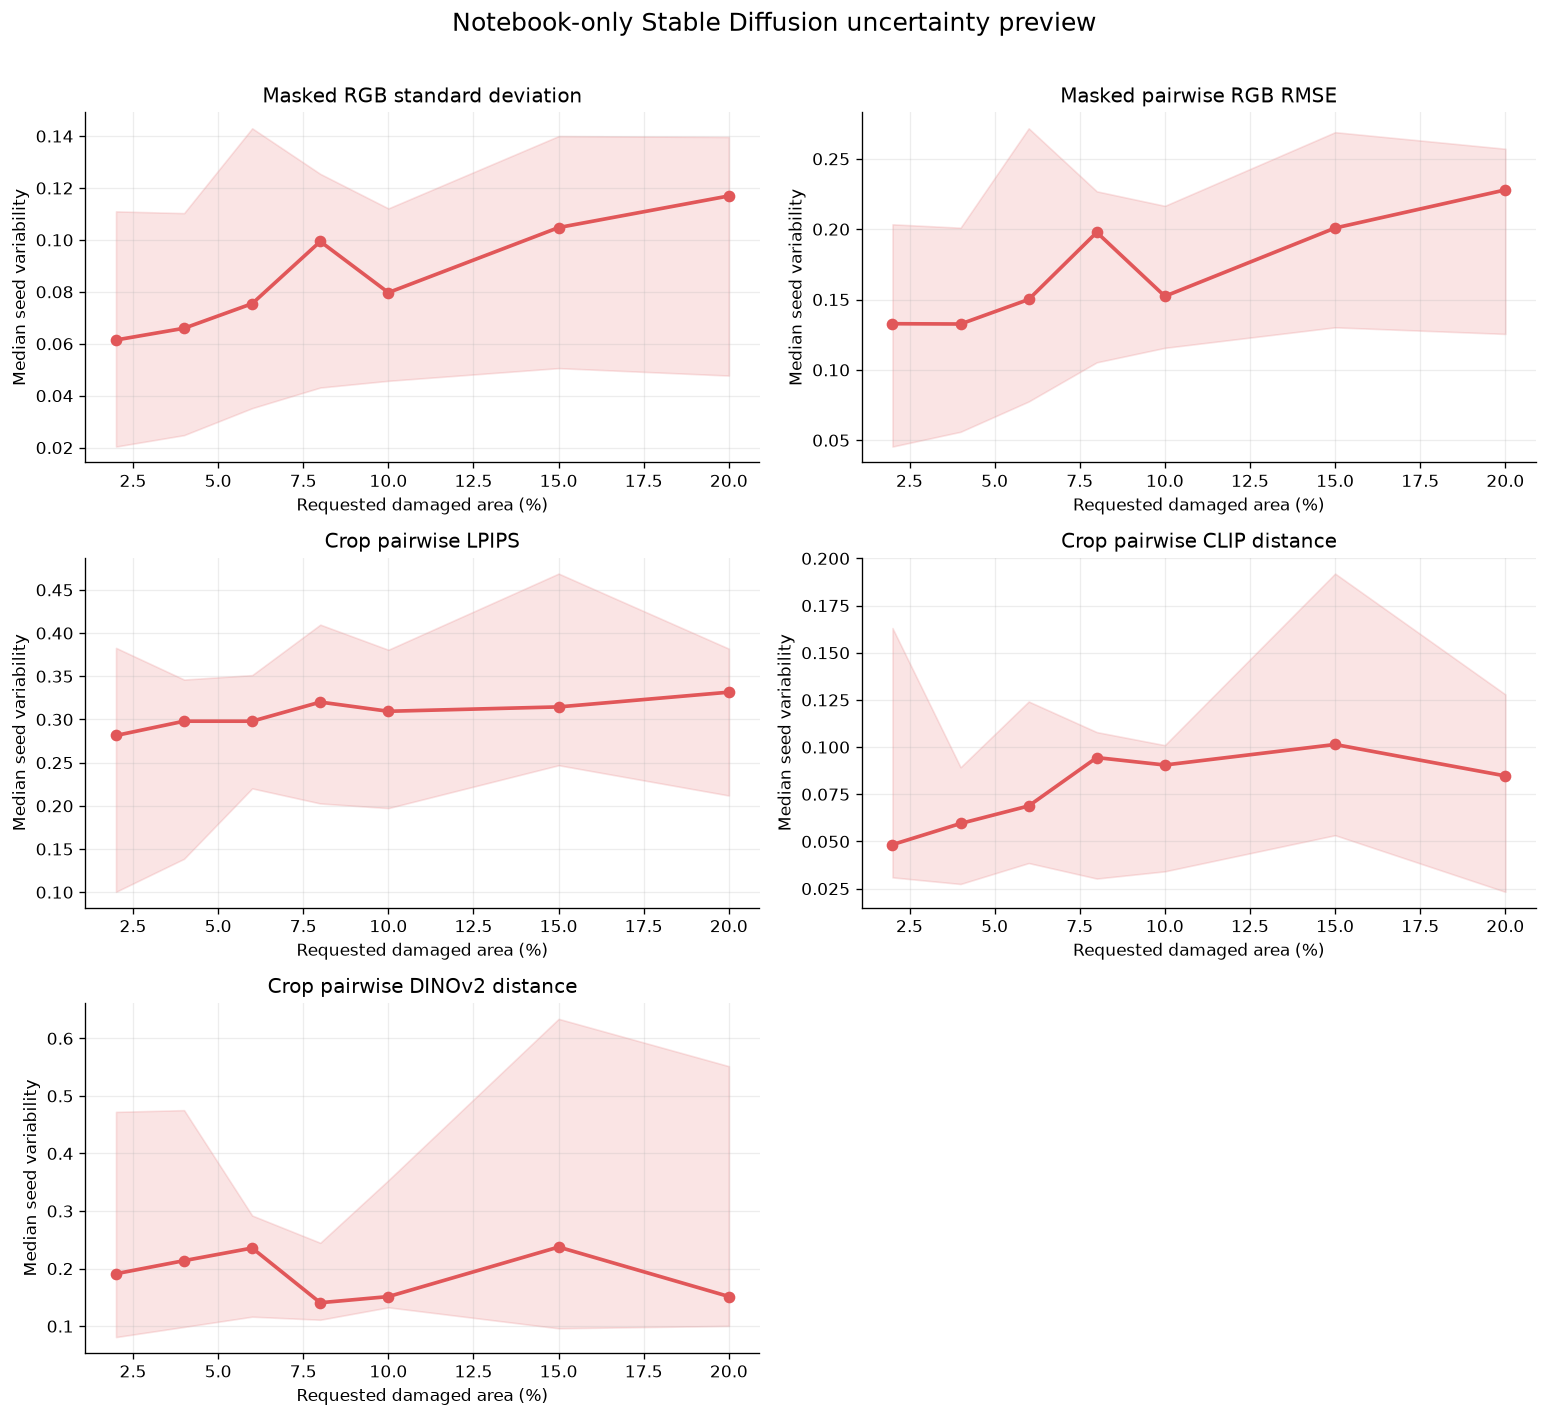

,evidence_family,anchor_id,metric_name,model_id,exposure_definition,estimate,p_value,q_value,interpretation_status
24,colour,colour_masked_delta_e,delta_e_ciede2000_mean,opencv_telea,morphology:scaled_mask_compactness,-0.412045,0.013912,0.041736,exploratory_noncausal_positive_rho_means_worse_outcome
57,feature_similarity,feature_dino_crop,dinov2_cosine_similarity,lama,morphology:centroid_shift_pixels,0.393557,0.019333,0.116001,exploratory_noncausal_positive_rho_means_worse_outcome
27,colour,colour_masked_delta_e,delta_e_ciede2000_mean,opencv_telea,morphology:centroid_shift_pixels,-0.388796,0.020985,0.062954,exploratory_noncausal_positive_rho_means_worse_outcome
58,feature_similarity,feature_dino_crop,dinov2_cosine_similarity,lama,morphology:centroid_shift_fraction_of_content_diagonal,0.382073,0.023514,0.141082,exploratory_noncausal_positive_rho_means_worse_outcome
28,colour,colour_masked_delta_e,delta_e_ciede2000_mean,opencv_telea,morphology:centroid_shift_fraction_of_content_diagonal,-0.375630,0.026169,0.078507,exploratory_noncausal_positive_rho_means_worse_outcome
79,perceptual,perceptual_crop_lpips,lpips,opencv_telea,morphology:relative_bbox_aspect_ratio_drift,-0.365546,0.030818,0.092453,exploratory_noncausal_positive_rho_means_worse_outcome
168,ssim,structural_crop_ssim,ssim,opencv_telea,morphology:scaled_mask_compactness,-0.354062,0.036914,0.077426,exploratory_noncausal_positive_rho_means_worse_outcome
9,classical_pixel,classical_masked_mae,mae,opencv_telea,morphology:centroid_shift_pixels,-0.351541,0.038375,0.115124,exploratory_noncausal_positive_rho_means_worse_outcome
135,spatial_diagnostics,spatial_masked_error,restored_error_mean,opencv_telea,morphology:centroid_shift_pixels,-0.351541,0.038375,0.115124,exploratory_noncausal_positive_rho_means_worse_outcome
53,feature_similarity,feature_clip_crop,clip_cosine_similarity,stable_diffusion_inpainting,morphology:absolute_percentage_point_error,0.349860,0.039375,0.236248,exploratory_noncausal_positive_rho_means_worse_outcome


anchor_id   classical_masked_mae                                          colour_masked_delta_e                                          perceptual_crop_lpips               \
model_id                    lama opencv_telea stable_diffusion_inpainting                  lama opencv_telea stable_diffusion_inpainting                  lama opencv_telea   
painting_id                                                                                                                                                                   
p001                    2.750889     1.415337                    5.911257              1.473896     0.783073                    2.450365              0.130692     0.029398   
p018                   18.333235    17.778759                    6.804248              7.634027     7.003295                    3.232347              0.114227     0.115199   
p026                    4.160779     3.707553                   10.027502              1.287498     1.037565                    2.399665              0.092307     0.058301   
p039                    4.516990     7.769525                   10.863746              2.234534     4.633460                    6.451921              0.073074     0.030682   
p043                    0.058304     3.480609                    9.686547              0.144657     1.212552                    3.957460              0.043794     0.011503   

anchor_id                               seam_boundary_gradient                                           
model_id    stable_diffusion_inpainting                   lama opencv_telea stable_diffusion_inpainting  
painting_id                                                                                              
p001                           0.046001              -0.001105    -0.001117                   -0.001562  
p018                          -0.069439               0.001233     0.002326                   -0.000856  
p026                           0.099316              -0.001097    -0.000857                    0.003702  
p039                           0.078891              -0.001061    -0.000939                    0.001223  
p043                           0.060743               0.000062     0.000445                    0.005306

anchor_id,crop_pairwise_clip,crop_pairwise_dino,crop_pairwise_lpips,masked_pairwise_rgb_rmse,masked_rgb_std
painting_id,,,,,
p001,0.042543,0.033028,0.063192,0.063634,0.021951
p018,-0.077653,-0.216213,-0.056961,0.023393,0.009590
p026,0.037735,0.198220,0.118562,0.037793,0.031910
p039,0.029871,0.057047,0.049170,0.044537,0.031027
p043,0.021479,-0.022595,0.051170,0.055603,0.032559


Rendered notebook-only uncertainty trajectories.
Painting-specific slopes remain separated by metric; no cross-metric combined score was created.


In [42]:
main_uncertainty_level_rows = (
    UNCERTAINTY_LEVEL_SUMMARY.loc[
        UNCERTAINTY_LEVEL_SUMMARY["anchor_id"]
        .astype(str)
        .ne("")
    ]
    .copy()
)

main_component_ids = [
    str(item["component_id"])
    for item in SETTINGS["uncertainty"][
        "main_figure_components"
    ]
]

component_labels = {
    "masked_rgb_std": "Masked RGB standard deviation",
    "masked_pairwise_rgb_rmse": "Masked pairwise RGB RMSE",
    "crop_pairwise_lpips": "Crop pairwise LPIPS",
    "crop_pairwise_clip": "Crop pairwise CLIP distance",
    "crop_pairwise_dino": "Crop pairwise DINOv2 distance",
}

fig, axes = plt.subplots(
    3,
    2,
    figsize=(13, 12),
    squeeze=False,
)

for axis, component_id in zip(
    axes.flat,
    main_component_ids,
):
    component_rows = (
        main_uncertainty_level_rows.loc[
            main_uncertainty_level_rows["anchor_id"]
            .astype(str)
            .eq(component_id)
        ]
        .copy()
        .sort_values(
            "target_damage_fraction",
            kind="stable",
        )
    )

    x = (
        pd.to_numeric(
            component_rows["target_damage_fraction"],
            errors="coerce",
        ).to_numpy(dtype=float)
        * 100.0
    )
    y = pd.to_numeric(
        component_rows["estimate"],
        errors="coerce",
    ).to_numpy(dtype=float)
    lower = pd.to_numeric(
        component_rows["ci_lower"],
        errors="coerce",
    ).to_numpy(dtype=float)
    upper = pd.to_numeric(
        component_rows["ci_upper"],
        errors="coerce",
    ).to_numpy(dtype=float)

    axis.plot(
        x,
        y,
        marker="o",
        linewidth=2.2,
        color="#E15759",
    )
    axis.fill_between(
        x,
        lower,
        upper,
        color="#E15759",
        alpha=0.16,
    )
    axis.set_title(
        component_labels.get(
            component_id,
            component_id,
        )
    )
    axis.set_xlabel("Requested damaged area (%)")
    axis.set_ylabel("Median seed variability")

unused_axes = list(axes.flat)[len(main_component_ids):]
for axis in unused_axes:
    axis.set_visible(False)

fig.suptitle(
    "Notebook-only Stable Diffusion uncertainty preview",
    fontsize=15,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

strongest_morphology_associations = (
    MORPHOLOGY_ASSOCIATIONS.assign(
        absolute_rho=lambda frame: pd.to_numeric(
            frame["estimate"],
            errors="coerce",
        ).abs()
    )
    .sort_values(
        ["absolute_rho", "q_value"],
        ascending=[False, True],
        kind="stable",
    )
    [
        [
            "evidence_family",
            "anchor_id",
            "metric_name",
            "model_id",
            "exposure_definition",
            "estimate",
            "p_value",
            "q_value",
            "interpretation_status",
        ]
    ]
    .head(30)
)

quality_painting_preview = (
    QUALITY_PAINTING_SLOPES.loc[
        QUALITY_PAINTING_SLOPES[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
        & QUALITY_PAINTING_SLOPES["anchor_id"]
        .astype(str)
        .isin(PLOT_ANCHORS)
    ]
    .pivot_table(
        index="painting_id",
        columns=["anchor_id", "model_id"],
        values="estimate",
        aggfunc="first",
    )
)

uncertainty_painting_preview = (
    UNCERTAINTY_PAINTING_SLOPES.loc[
        UNCERTAINTY_PAINTING_SLOPES[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
        & UNCERTAINTY_PAINTING_SLOPES["anchor_id"]
        .astype(str)
        .isin(main_component_ids)
    ]
    .pivot_table(
        index="painting_id",
        columns="anchor_id",
        values="estimate",
        aggfunc="first",
    )
)

display(strongest_morphology_associations)
display(quality_painting_preview)
display(uncertainty_painting_preview)

print("Rendered notebook-only uncertainty trajectories.")
print(
    "Painting-specific slopes remain separated by metric; "
    "no cross-metric combined score was created."
)

In [43]:
BATCH_7_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"].eq(
            "batch_7_uncertainty_morphology"
        )
    ]
    .reset_index(drop=True)
)

BATCH_7_SUMMARY = {
    "check_count": len(BATCH_7_CHECKS),
    "passed_count": int(BATCH_7_CHECKS["passed"].sum()),
    "blocking_failures": int(
        (
            BATCH_7_CHECKS["severity"].eq("blocking")
            & ~BATCH_7_CHECKS["passed"]
        ).sum()
    ),
}

display(BATCH_7_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 7 passed.")
print(
    f"Uncertainty level summaries: "
    f"{len(UNCERTAINTY_LEVEL_SUMMARY)}"
)
print(
    f"Uncertainty painting trajectories: "
    f"{len(UNCERTAINTY_PAINTING_SLOPES)}"
)
print(
    f"Uncertainty trend summaries: "
    f"{len(UNCERTAINTY_TREND_SUMMARY)}"
)
print(
    f"Morphology associations retained: "
    f"{len(MORPHOLOGY_ASSOCIATIONS)}"
)
print(
    f"Morphology associations omitted: "
    f"{len(MORPHOLOGY_OMISSIONS)}"
)
print(f"Validation checks: {BATCH_7_SUMMARY['check_count']}")
print(f"Blocking failures: {BATCH_7_SUMMARY['blocking_failures']}")
print("No canonical Notebook 23 artifact has been written.")
print(
    "Next batch: final statistical correction, "
    "canonical persistence, and scientific validation."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_uncertainty_morphology,uncertainty_component_trajectory_coverage,Every normalized uncertainty component contains all 35 cases.,blocking,"{""components"": 30, ""rows_per_component"": 35}","{""components"": 30, ""maximum_rows"": 35, ""minimum_rows"": 35}",True,
1,batch_7_uncertainty_morphology,uncertainty_level_rows,Every uncertainty component and damage level has one summary.,blocking,210,210,True,
2,batch_7_uncertainty_morphology,uncertainty_painting_slope_rows,"Every uncertainty component, exposure, and painting has one slope.",blocking,300,300,True,
3,batch_7_uncertainty_morphology,uncertainty_trend_rows,Every uncertainty component and exposure has one matched trend estimate.,blocking,60,60,True,
4,batch_7_uncertainty_morphology,main_uncertainty_trend_coverage,All five main uncertainty components have target and realised trend estimates.,blocking,10,10,True,
5,batch_7_uncertainty_morphology,morphology_attempt_accounting,Every planned morphology association is retained or explicitly omitted.,blocking,228,"{""attempted"": 228, ""omitted"": 0, ""retained"": 228}",True,
6,batch_7_uncertainty_morphology,morphology_results_finite,"Every retained morphology association has finite rho, p, and q values.",blocking,True,"{""finite_estimates"": 228, ""finite_p_values"": 228, ""finite_q_values"": 228, ""rows"": 228}",True,
7,batch_7_uncertainty_morphology,morphology_scope_discipline,Morphology rows are labelled exploratory and do not assert category or style effects.,blocking,True,"[""exploratory_noncausal_positive_rho_means_greater_seed_variability"", ""exploratory_noncausal_positive_rho_means_wors...",True,
8,batch_7_uncertainty_morphology,batch_7_analysis_schema,Batch 7 rows satisfy the canonical analysis schema.,blocking,True,"{""analysis_ids_unique"": true, ""analysis_kinds_valid"": true, ""missing_columns"": [], ""no_combined_score_or_index"": tru...",True,
9,batch_7_uncertainty_morphology,cumulative_analysis_schema,All analysis rows through Batch 7 satisfy the canonical schema.,blocking,True,"{""analysis_ids_unique"": true, ""analysis_kinds_valid"": true, ""missing_columns"": [], ""no_combined_score_or_index"": tru...",True,


Batch 7 passed.
Uncertainty level summaries: 210
Uncertainty painting trajectories: 300
Uncertainty trend summaries: 60
Morphology associations retained: 228
Morphology associations omitted: 0
Validation checks: 10
Blocking failures: 0
No canonical Notebook 23 artifact has been written.
Next batch: final statistical correction, canonical persistence, and scientific validation.


## Batch 8 — Final statistical correction, persistence, and scientific validation

This batch completes the canonical analysis table by adding:

- damage-generation integrity summaries;
- runtime summaries and runtime sensitivity;
- final false-discovery-rate correction across the complete inferential table.

It then writes and reloads:

- the canonical long-form analysis table;
- the quality-performance figure;
- the family-balanced ranking figure;
- the Stable Diffusion uncertainty figure.

Runtime remains operational evidence and cannot affect quality rankings. Damage-integrity rows describe the controlled experiment and are not restoration-quality scores.

The report, manifests, final validation table, and completion gate remain owned by Batch 9.

In [44]:
integrity_metric_definitions = {
    "absolute_percentage_point_error": {
        "source_column": "absolute_percentage_point_error",
        "estimate_name": "median_value",
        "value_unit": "percentage_points",
        "comparison_direction": "lower_is_better",
        "statistic": np.median,
    },
    "nested_with_previous": {
        "source_column": "nested_with_previous_normalized",
        "estimate_name": "fraction_true",
        "value_unit": "fraction",
        "comparison_direction": "descriptive_only",
        "statistic": np.mean,
    },
    "scaled_connected_component_count": {
        "source_column": "scaled_connected_component_count",
        "estimate_name": "median_value",
        "value_unit": "components",
        "comparison_direction": "descriptive_only",
        "statistic": np.median,
    },
    "component_count_delta": {
        "source_column": "component_count_delta",
        "estimate_name": "median_value",
        "value_unit": "components",
        "comparison_direction": "descriptive_only",
        "statistic": np.median,
    },
    "scaled_largest_component_fraction": {
        "source_column": "scaled_largest_component_fraction",
        "estimate_name": "median_value",
        "value_unit": "fraction",
        "comparison_direction": "descriptive_only",
        "statistic": np.median,
    },
    "touches_content_boundary": {
        "source_column": "touches_content_boundary_normalized",
        "estimate_name": "fraction_true",
        "value_unit": "fraction",
        "comparison_direction": "descriptive_only",
        "statistic": np.mean,
    },
    "centroid_shift_pixels": {
        "source_column": "centroid_shift_pixels",
        "estimate_name": "median_value",
        "value_unit": "pixels",
        "comparison_direction": "descriptive_only",
        "statistic": np.median,
    },
}

integrity_records = []

integrity_level_groups = list(
    CASE_DESIGN.groupby(
        [
            "level_id",
            "target_damage_fraction",
        ],
        observed=True,
        sort=True,
    )
)

total_integrity_summaries = (
    len(integrity_level_groups)
    * len(integrity_metric_definitions)
)
completed_integrity_summaries = 0

for (
    level_id,
    target_fraction,
), level_rows in integrity_level_groups:
    for metric_name, definition in (
        integrity_metric_definitions.items()
    ):
        source_column = definition["source_column"]

        values = pd.to_numeric(
            level_rows[source_column],
            errors="coerce",
        ).to_numpy(dtype=float)

        interval = exhaustive_bootstrap_interval(
            values,
            confidence_level=CONFIDENCE_LEVEL,
            statistic=definition["statistic"],
        )

        source_rows = pd.DataFrame(
            {
                "source_notebook_id": "05",
                "source_metric_row_id": (
                    level_rows["case_id"].astype(str)
                    + "__"
                    + metric_name
                ),
            }
        )

        integrity_records.append(
            build_analysis_record(
                analysis_kind="damage_integrity",
                analysis_family_id="damage_generation_integrity",
                row_identity=(
                    metric_name,
                    level_id,
                ),
                source_rows=source_rows,
                evidence_family=(
                    "damage_generation_integrity"
                ),
                metric_family=(
                    "damage_generation_integrity"
                ),
                metric_id=stable_analysis_id(
                    "integrity_metric",
                    metric_name,
                ),
                metric_name=metric_name,
                feature_model_id="not_applicable",
                region_id="generated_mask",
                summary_statistic=definition[
                    "estimate_name"
                ],
                value_unit=definition["value_unit"],
                comparison_direction=definition[
                    "comparison_direction"
                ],
                quality_ranking_eligible=False,
                anchor_id="",
                model_id="not_applicable",
                comparison_model_id="not_applicable",
                exposure_definition=(
                    "target_damage_fraction"
                ),
                level_id=str(level_id),
                target_damage_fraction=float(
                    target_fraction
                ),
                realized_damage_fraction=float(
                    pd.to_numeric(
                        level_rows[
                            "realized_damage_fraction"
                        ],
                        errors="coerce",
                    ).median()
                ),
                scope_type="damage_level",
                scope_value=str(level_id),
                n_paintings=int(
                    level_rows["painting_id"].nunique()
                ),
                n_cases=int(
                    level_rows["case_id"].nunique()
                ),
                n_observations=int(len(level_rows)),
                estimate_name=definition[
                    "estimate_name"
                ],
                estimate=float(interval["estimate"]),
                ci_lower=float(interval["ci_lower"]),
                ci_upper=float(interval["ci_upper"]),
                effect_size_name="not_applicable",
                effect_size=pd.NA,
                p_value=pd.NA,
                q_value=pd.NA,
                test_method="not_applicable",
                bootstrap_method=SETTINGS["statistics"][
                    "bootstrap_method"
                ],
                bootstrap_resamples=int(
                    interval["resamples"]
                ),
                interpretation_status=(
                    "controlled_damage_generation_diagnostic"
                ),
            )
        )

        completed_integrity_summaries += 1
        if (
            completed_integrity_summaries % 10 == 0
            or completed_integrity_summaries
            == total_integrity_summaries
        ):
            print(
                f"Computed {completed_integrity_summaries}/"
                f"{total_integrity_summaries} "
                "damage-integrity summaries."
            )

DAMAGE_INTEGRITY_ANALYSIS = pd.DataFrame(
    integrity_records,
    columns=ANALYSIS_COLUMNS,
)

print("Damage-integrity analysis completed.")
print(
    f"Damage-integrity rows: "
    f"{len(DAMAGE_INTEGRITY_ANALYSIS)}"
)

Computed 10/49 damage-integrity summaries.
Computed 20/49 damage-integrity summaries.
Computed 30/49 damage-integrity summaries.
Computed 40/49 damage-integrity summaries.
Computed 49/49 damage-integrity summaries.
Damage-integrity analysis completed.
Damage-integrity rows: 49


In [45]:
candidate_provenance = (
    SELECTED_CANDIDATES[
        [
            "candidate_id",
            "source_notebook_id",
            "level_id",
        ]
    ]
    .drop_duplicates("candidate_id")
)

RUNTIME_ANALYSIS_SOURCE = (
    RUNTIME_EVIDENCE.drop(
        columns=["source_notebook_id", "level_id"],
        errors="ignore",
    )
    .merge(
        candidate_provenance,
        on="candidate_id",
        how="left",
        validate="one_to_one",
    )
)

RUNTIME_ANALYSIS_SOURCE["comparison_value"] = (
    pd.to_numeric(
        RUNTIME_ANALYSIS_SOURCE["comparison_value"],
        errors="coerce",
    )
)
RUNTIME_ANALYSIS_SOURCE["target_damage_fraction"] = (
    pd.to_numeric(
        RUNTIME_ANALYSIS_SOURCE[
            "target_damage_fraction"
        ],
        errors="coerce",
    )
)
RUNTIME_ANALYSIS_SOURCE["realized_damage_fraction"] = (
    pd.to_numeric(
        RUNTIME_ANALYSIS_SOURCE[
            "realized_damage_fraction"
        ],
        errors="coerce",
    )
)

runtime_level_records = []

runtime_level_groups = list(
    RUNTIME_ANALYSIS_SOURCE.groupby(
        [
            "model_id",
            "source_notebook_id",
            "level_id",
            "target_damage_fraction",
        ],
        observed=True,
        dropna=False,
        sort=True,
    )
)

for group_number, (group_key, group) in enumerate(
    runtime_level_groups,
    start=1,
):
    (
        model_id,
        source_notebook_id,
        level_id,
        target_fraction,
    ) = group_key

    values = group["comparison_value"].to_numpy(
        dtype=float
    )
    interval = exhaustive_bootstrap_interval(
        values,
        confidence_level=CONFIDENCE_LEVEL,
        statistic=np.median,
    )

    runtime_level_records.append(
        build_analysis_record(
            analysis_kind="level_summary",
            analysis_family_id="runtime_seconds",
            row_identity=(
                "runtime",
                model_id,
                level_id,
            ),
            source_rows=group,
            evidence_family="runtime_compute",
            metric_family="runtime_compute",
            metric_id="runtime_seconds",
            metric_name="runtime_seconds",
            feature_model_id="not_applicable",
            region_id="whole_candidate_execution",
            summary_statistic="median",
            value_unit="seconds",
            comparison_direction="lower_is_better",
            quality_ranking_eligible=False,
            anchor_id="",
            model_id=str(model_id),
            comparison_model_id="not_applicable",
            exposure_definition="target_damage_fraction",
            level_id=str(level_id),
            target_damage_fraction=float(
                target_fraction
            ),
            realized_damage_fraction=float(
                group["realized_damage_fraction"].median()
            ),
            scope_type="damage_level",
            scope_value=str(level_id),
            n_paintings=int(group["painting_id"].nunique()),
            n_cases=int(group["case_id"].nunique()),
            n_observations=int(len(group)),
            estimate_name="median_runtime_seconds",
            estimate=float(interval["estimate"]),
            ci_lower=float(interval["ci_lower"]),
            ci_upper=float(interval["ci_upper"]),
            effect_size_name="not_applicable",
            effect_size=pd.NA,
            p_value=pd.NA,
            q_value=pd.NA,
            test_method="not_applicable",
            bootstrap_method=SETTINGS["statistics"][
                "bootstrap_method"
            ],
            bootstrap_resamples=int(interval["resamples"]),
            interpretation_status=(
                "operational_evidence_excluded_from_"
                "quality_ranking"
            ),
        )
    )

    if (
        group_number % 10 == 0
        or group_number == len(runtime_level_groups)
    ):
        print(
            f"Computed {group_number}/"
            f"{len(runtime_level_groups)} "
            "runtime level summaries."
        )

RUNTIME_LEVEL_SUMMARY = pd.DataFrame(
    runtime_level_records,
    columns=ANALYSIS_COLUMNS,
)

print("Runtime level summaries completed.")
print(
    f"Runtime level-summary rows: "
    f"{len(RUNTIME_LEVEL_SUMMARY)}"
)

Computed 10/21 runtime level summaries.
Computed 20/21 runtime level summaries.
Computed 21/21 runtime level summaries.
Runtime level summaries completed.
Runtime level-summary rows: 21


In [46]:
runtime_painting_records = []
runtime_trend_records = []

runtime_model_groups = list(
    RUNTIME_ANALYSIS_SOURCE.groupby(
        [
            "model_id",
            "source_notebook_id",
        ],
        observed=True,
        sort=True,
    )
)

for model_id, source_notebook_id in (
    group_key
    for group_key, _ in runtime_model_groups
):
    group = next(
        group
        for group_key, group in runtime_model_groups
        if group_key == (model_id, source_notebook_id)
    )

    for exposure_column in EXPOSURE_COLUMNS:
        painting_slopes = compute_painting_slopes(
            group,
            exposure_column=exposure_column,
            value_column="comparison_value",
            direction="lower_is_better",
            reporting_scale_percentage_points=(
                REPORTING_INTERVAL_PP
            ),
        )

        painting_metadata = (
            group[
                [
                    "painting_id",
                    "category",
                    "style_or_period",
                ]
            ]
            .drop_duplicates("painting_id")
            .set_index("painting_id")
        )

        for slope_row in painting_slopes.itertuples(index=False):
            painting_id = str(slope_row.painting_id)
            painting_source_rows = group.loc[
                group["painting_id"]
                .astype(str)
                .eq(painting_id)
            ]

            runtime_painting_records.append(
                build_analysis_record(
                    analysis_kind="painting_trajectory",
                    analysis_family_id="runtime_seconds",
                    row_identity=(
                        "runtime",
                        model_id,
                        exposure_column,
                        painting_id,
                    ),
                    source_rows=painting_source_rows,
                    evidence_family="runtime_compute",
                    metric_family="runtime_compute",
                    metric_id="runtime_seconds",
                    metric_name="runtime_seconds",
                    feature_model_id="not_applicable",
                    region_id=(
                        "whole_candidate_execution"
                    ),
                    summary_statistic="value",
                    value_unit="seconds",
                    comparison_direction="lower_is_better",
                    quality_ranking_eligible=False,
                    anchor_id="",
                    model_id=str(model_id),
                    comparison_model_id=(
                        "not_applicable"
                    ),
                    exposure_definition=exposure_column,
                    painting_id=painting_id,
                    category=painting_metadata.loc[
                        painting_id,
                        "category",
                    ],
                    style_or_period=painting_metadata.loc[
                        painting_id,
                        "style_or_period",
                    ],
                    scope_type="painting_trajectory",
                    scope_value=painting_id,
                    n_paintings=1,
                    n_cases=int(
                        painting_source_rows[
                            "case_id"
                        ].nunique()
                    ),
                    n_observations=int(
                        slope_row.level_count
                    ),
                    estimate_name=(
                        "runtime_slope_per_"
                        f"{REPORTING_INTERVAL_PP:g}_"
                        "percentage_points"
                    ),
                    estimate=float(
                        slope_row.adverse_slope_per_reporting_interval
                    ),
                    ci_lower=pd.NA,
                    ci_upper=pd.NA,
                    effect_size_name="not_applicable",
                    effect_size=pd.NA,
                    p_value=pd.NA,
                    q_value=pd.NA,
                    test_method="not_applicable",
                    bootstrap_method="not_applicable",
                    bootstrap_resamples=0,
                    interpretation_status=(
                        "positive_estimate_means_runtime_"
                        "increased_operational_evidence_only"
                    ),
                )
            )

        trend = summarise_painting_slopes(
            painting_slopes,
            confidence_level=CONFIDENCE_LEVEL,
        )

        runtime_trend_records.append(
            build_analysis_record(
                analysis_kind="damage_trend",
                analysis_family_id="runtime_seconds",
                row_identity=(
                    "runtime",
                    model_id,
                    exposure_column,
                ),
                source_rows=group,
                evidence_family="runtime_compute",
                metric_family="runtime_compute",
                metric_id="runtime_seconds",
                metric_name="runtime_seconds",
                feature_model_id="not_applicable",
                region_id="whole_candidate_execution",
                summary_statistic="value",
                value_unit="seconds",
                comparison_direction="lower_is_better",
                quality_ranking_eligible=False,
                anchor_id="",
                model_id=str(model_id),
                comparison_model_id="not_applicable",
                exposure_definition=exposure_column,
                scope_type="matched_painting_population",
                scope_value="five_painting_trajectories",
                n_paintings=int(trend["painting_count"]),
                n_cases=int(group["case_id"].nunique()),
                n_observations=int(len(group)),
                estimate_name=(
                    "median_runtime_slope_per_"
                    f"{REPORTING_INTERVAL_PP:g}_"
                    "percentage_points"
                ),
                estimate=float(trend["estimate"]),
                ci_lower=float(trend["ci_lower"]),
                ci_upper=float(trend["ci_upper"]),
                effect_size_name="matched_rank_biserial",
                effect_size=float(
                    trend["rank_biserial"]
                ),
                p_value=float(trend["p_value"]),
                q_value=pd.NA,
                test_method=SETTINGS["statistics"][
                    "exact_test"
                ],
                bootstrap_method=SETTINGS["statistics"][
                    "bootstrap_method"
                ],
                bootstrap_resamples=int(
                    trend["resamples"]
                ),
                interpretation_status=(
                    "operational_evidence_excluded_from_"
                    "quality_ranking"
                ),
            )
        )

    print(
        f"Computed runtime trajectories for {model_id}."
    )

RUNTIME_PAINTING_SLOPES = pd.DataFrame(
    runtime_painting_records,
    columns=ANALYSIS_COLUMNS,
)
RUNTIME_TREND_SUMMARY = pd.DataFrame(
    runtime_trend_records,
    columns=ANALYSIS_COLUMNS,
)

RUNTIME_ANALYSIS = pd.DataFrame(
    [
        *RUNTIME_LEVEL_SUMMARY.to_dict("records"),
        *RUNTIME_PAINTING_SLOPES.to_dict("records"),
        *RUNTIME_TREND_SUMMARY.to_dict("records"),
    ],
    columns=ANALYSIS_COLUMNS,
)

BATCH_8_ADDITIONS = pd.DataFrame(
    [
        *DAMAGE_INTEGRITY_ANALYSIS.to_dict("records"),
        *RUNTIME_ANALYSIS.to_dict("records"),
    ],
    columns=ANALYSIS_COLUMNS,
)

ANALYSIS_PARTS.append(BATCH_8_ADDITIONS)

print("Runtime sensitivity analysis completed.")
print(
    f"Runtime painting trajectories: "
    f"{len(RUNTIME_PAINTING_SLOPES)}"
)
print(
    f"Runtime population trends: "
    f"{len(RUNTIME_TREND_SUMMARY)}"
)
print(
    f"Batch 8 additional rows: "
    f"{len(BATCH_8_ADDITIONS)}"
)

Computed runtime trajectories for lama.
Computed runtime trajectories for opencv_telea.
Computed runtime trajectories for stable_diffusion_inpainting.
Runtime sensitivity analysis completed.
Runtime painting trajectories: 30
Runtime population trends: 6
Batch 8 additional rows: 106


In [52]:
# Make this persistence stage safely rerunnable after a failed final check.
retained_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_8_persistence_validation"
)
VALIDATION = type(VALIDATION)()
VALIDATION.extend(retained_checks)

FINAL_ANALYSIS = pd.DataFrame(
    [
        record
        for frame in ANALYSIS_PARTS
        for record in frame.to_dict("records")
    ],
    columns=ANALYSIS_COLUMNS,
)

FINAL_ANALYSIS["p_value"] = pd.to_numeric(
    FINAL_ANALYSIS["p_value"],
    errors="coerce",
)
FINAL_ANALYSIS["q_value"] = np.nan

fdr_columns = list(
    SETTINGS["statistics"]["fdr_family_columns"]
)

# This mask is used only while the table remains in its pre-sort order.
pre_sort_inferential_mask = np.isfinite(
    FINAL_ANALYSIS["p_value"].to_numpy(dtype=float)
)

for _, indices in FINAL_ANALYSIS.loc[
    pre_sort_inferential_mask
].groupby(
    fdr_columns,
    observed=True,
    dropna=False,
).groups.items():
    positions = list(indices)

    FINAL_ANALYSIS.loc[
        positions,
        "q_value",
    ] = benjamini_hochberg(
        FINAL_ANALYSIS.loc[
            positions,
            "p_value",
        ].to_numpy(dtype=float)
    )

FINAL_ANALYSIS = (
    FINAL_ANALYSIS.sort_values(
        [
            "analysis_kind",
            "analysis_family_id",
            "model_id",
            "comparison_model_id",
            "exposure_definition",
            "painting_id",
            "target_damage_fraction",
            "interval_start_fraction",
            "estimate_name",
            "analysis_row_id",
        ],
        kind="stable",
        na_position="last",
    )
    .reset_index(drop=True)
)

# Recompute after sorting so validation addresses the correct rows.
finite_p_mask = np.isfinite(
    FINAL_ANALYSIS["p_value"].to_numpy(dtype=float)
)
finite_q_mask = np.isfinite(
    FINAL_ANALYSIS["q_value"].to_numpy(dtype=float)
)

final_analysis_validation = validate_damage_size_analysis(
    FINAL_ANALYSIS,
    config=ANALYSIS_CONFIG,
)

VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="damage_integrity_rows",
    check_description=(
        "Seven integrity fields are summarized at all "
        "seven damage levels."
    ),
    severity="blocking",
    expected=(
        len(integrity_metric_definitions)
        * int(EXPECTED["damage_levels"])
    ),
    observed=len(DAMAGE_INTEGRITY_ANALYSIS),
    passed=(
        len(DAMAGE_INTEGRITY_ANALYSIS)
        == len(integrity_metric_definitions)
        * int(EXPECTED["damage_levels"])
    ),
)

VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="runtime_analysis_rows",
    check_description=(
        "Runtime includes level summaries, painting slopes, "
        "and population trends."
    ),
    severity="blocking",
    expected={
        "level_summaries": (
            len(POPULATION["model_order"])
            * int(EXPECTED["damage_levels"])
        ),
        "painting_slopes": (
            len(POPULATION["model_order"])
            * len(EXPOSURE_COLUMNS)
            * int(EXPECTED["paintings"])
        ),
        "trends": (
            len(POPULATION["model_order"])
            * len(EXPOSURE_COLUMNS)
        ),
    },
    observed={
        "level_summaries": len(RUNTIME_LEVEL_SUMMARY),
        "painting_slopes": len(RUNTIME_PAINTING_SLOPES),
        "trends": len(RUNTIME_TREND_SUMMARY),
    },
    passed=(
        len(RUNTIME_LEVEL_SUMMARY)
        == len(POPULATION["model_order"])
        * int(EXPECTED["damage_levels"])
        and len(RUNTIME_PAINTING_SLOPES)
        == len(POPULATION["model_order"])
        * len(EXPOSURE_COLUMNS)
        * int(EXPECTED["paintings"])
        and len(RUNTIME_TREND_SUMMARY)
        == len(POPULATION["model_order"])
        * len(EXPOSURE_COLUMNS)
    ),
)

VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="runtime_excluded_from_quality_ranking",
    check_description=(
        "Every canonical runtime row is excluded from "
        "quality ranking."
    ),
    severity="blocking",
    expected=False,
    observed=bool(
        RUNTIME_ANALYSIS[
            "quality_ranking_eligible"
        ].astype(bool).any()
    ),
    passed=not RUNTIME_ANALYSIS[
        "quality_ranking_eligible"
    ].astype(bool).any(),
)

VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="complete_analysis_schema",
    check_description=(
        "The complete canonical analysis table passes "
        "schema validation."
    ),
    severity="blocking",
    expected=True,
    observed=final_analysis_validation,
    passed=bool(final_analysis_validation["passed"]),
)

VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="all_analysis_kinds_present",
    check_description=(
        "Every analysis kind declared by the Notebook 23 "
        "contract is present."
    ),
    severity="blocking",
    expected=sorted(
        map(str, SETTINGS["analysis_kinds"])
    ),
    observed=sorted(
        FINAL_ANALYSIS["analysis_kind"]
        .astype(str)
        .unique()
    ),
    passed=(
        set(
            FINAL_ANALYSIS["analysis_kind"]
            .astype(str)
            .unique()
        )
        == set(map(str, SETTINGS["analysis_kinds"]))
    ),
)

VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="final_fdr_values",
    check_description=(
        "Every inferential row has a valid globally "
        "recomputed q-value."
    ),
    severity="blocking",
    expected=True,
    observed={
        "finite_p_values": int(finite_p_mask.sum()),
        "finite_q_values": int(finite_q_mask.sum()),
        "inferential_rows_with_finite_q": int(
            np.isfinite(
                FINAL_ANALYSIS.loc[
                    finite_p_mask,
                    "q_value",
                ].to_numpy(dtype=float)
            ).sum()
        ),
    },
    passed=(
        finite_p_mask.sum() == finite_q_mask.sum()
        and np.isfinite(
            FINAL_ANALYSIS.loc[
                finite_p_mask,
                "q_value",
            ].to_numpy(dtype=float)
        ).all()
        and FINAL_ANALYSIS.loc[
            finite_p_mask,
            "q_value",
        ]
        .between(0.0, 1.0)
        .all()
    ),
)

atomic_write_csv(
    FINAL_ANALYSIS,
    OUTPUT_PATHS["metrics"],
)

RELOADED_ANALYSIS = pd.read_csv(
    OUTPUT_PATHS["metrics"],
    low_memory=False,
)

reloaded_analysis_validation = (
    validate_damage_size_analysis(
        RELOADED_ANALYSIS,
        config=ANALYSIS_CONFIG,
    )
)

VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="canonical_metrics_round_trip",
    check_description=(
        "The canonical analysis CSV reloads with unchanged "
        "rows and unique IDs."
    ),
    severity="blocking",
    expected={
        "rows": len(FINAL_ANALYSIS),
        "unique_ids": len(FINAL_ANALYSIS),
    },
    observed={
        "rows": len(RELOADED_ANALYSIS),
        "unique_ids": RELOADED_ANALYSIS[
            "analysis_row_id"
        ].nunique(),
        "schema_validation": (
            reloaded_analysis_validation
        ),
    },
    passed=(
        len(RELOADED_ANALYSIS)
        == len(FINAL_ANALYSIS)
        and RELOADED_ANALYSIS[
            "analysis_row_id"
        ].nunique()
        == len(FINAL_ANALYSIS)
        and bool(
            reloaded_analysis_validation["passed"]
        )
    ),
)

print("Final statistical correction completed.")
print(
    f"Canonical analysis rows: "
    f"{len(FINAL_ANALYSIS):,}"
)
print(
    f"Inferential rows with final q-values: "
    f"{int(finite_p_mask.sum()):,}"
)
print(
    "Persisted metrics: "
    f"{OUTPUT_PATHS['metrics'].relative_to(PROJECT_ROOT)}"
)

Final statistical correction completed.
Canonical analysis rows: 1,901
Inferential rows with final q-values: 646
Persisted metrics: outputs\23_damage_size_sensitivity_analysis\metrics\damage_size_analysis.csv


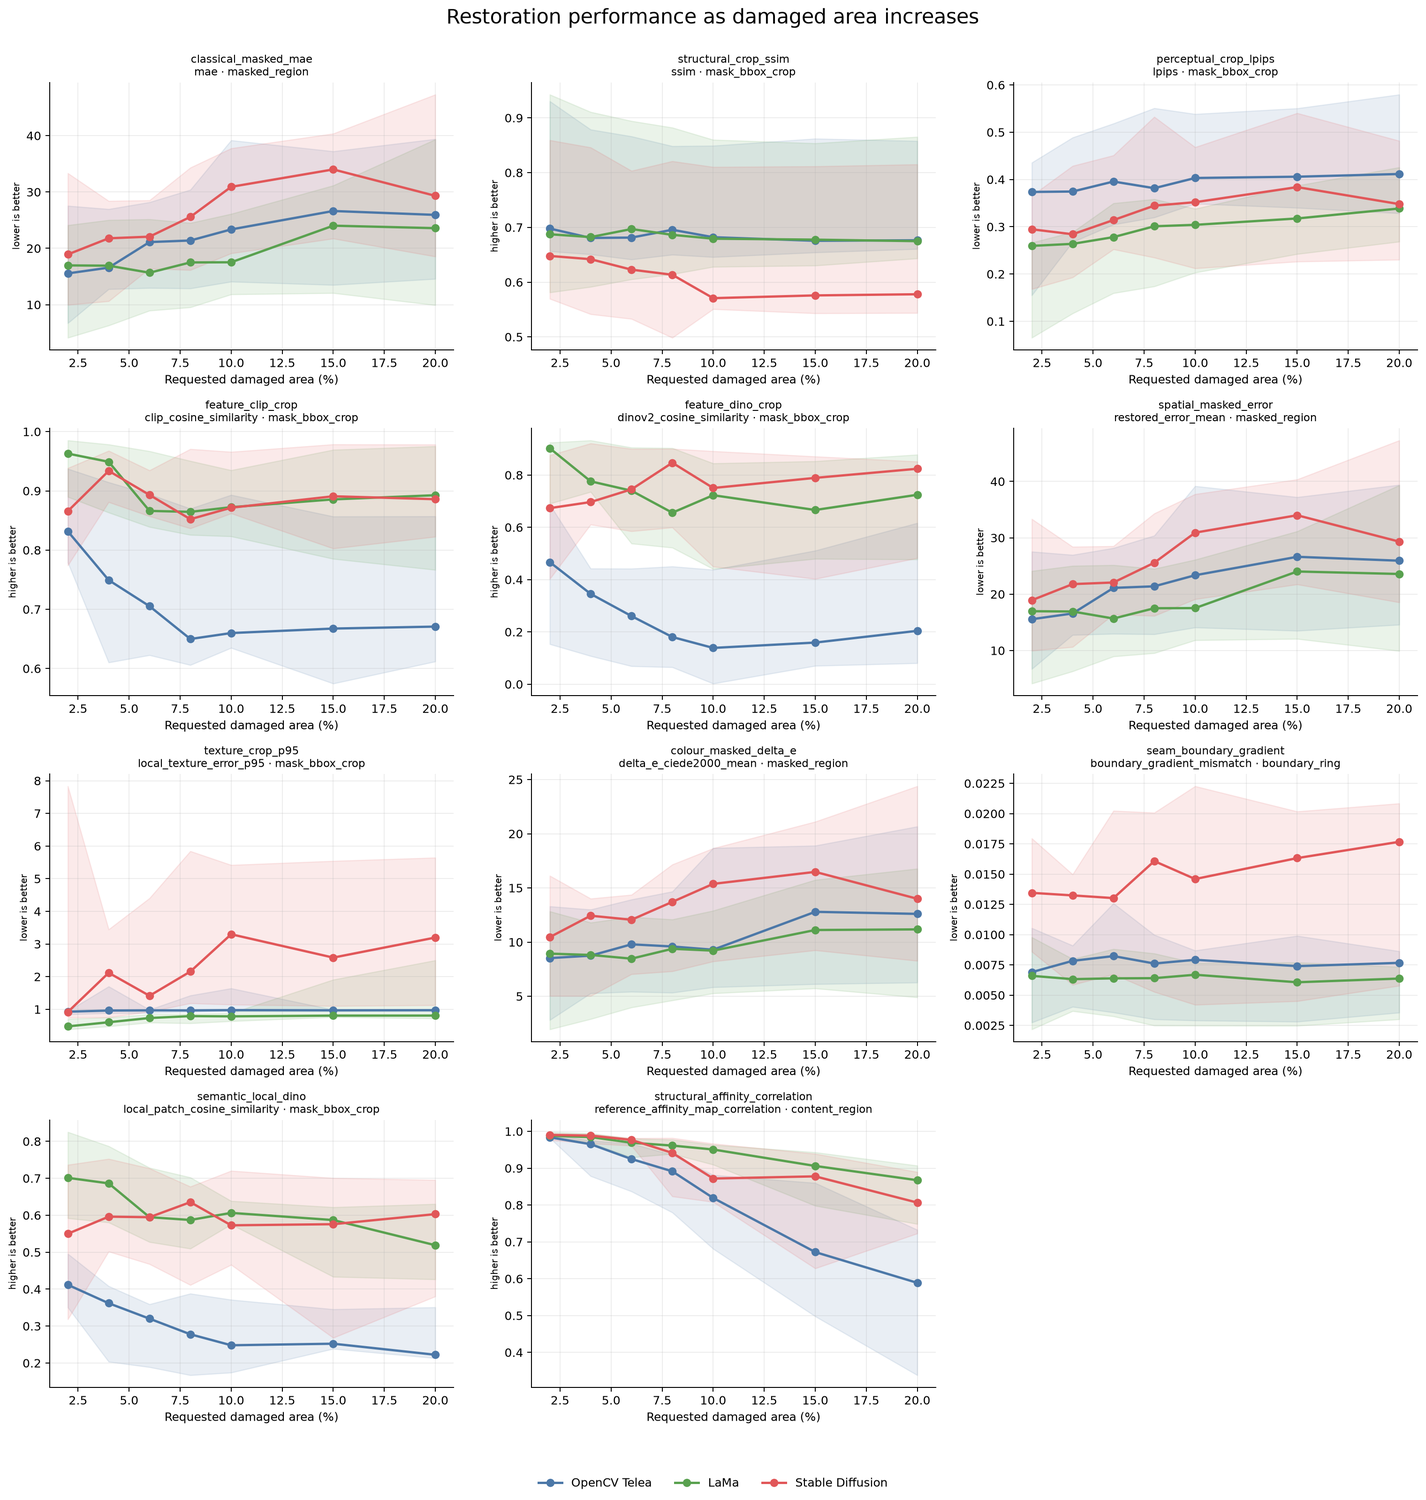

Canonical performance figure written and rendered.
outputs\23_damage_size_sensitivity_analysis\figures\performance_vs_damage.png


In [53]:
performance_anchors = [
    str(item["anchor_id"])
    for item in SETTINGS["quality_anchors"]
]

fig, axes = plt.subplots(
    4,
    3,
    figsize=(17, 18),
    squeeze=False,
)

for axis, anchor_id in zip(
    axes.flat,
    performance_anchors,
):
    anchor_rows = QUALITY_LEVEL_SUMMARY.loc[
        QUALITY_LEVEL_SUMMARY["anchor_id"]
        .astype(str)
        .eq(anchor_id)
    ]

    for model_id in POPULATION["model_order"]:
        model_rows = (
            anchor_rows.loc[
                anchor_rows["model_id"]
                .astype(str)
                .eq(str(model_id))
            ]
            .copy()
            .sort_values(
                "target_damage_fraction",
                kind="stable",
            )
        )

        x = (
            pd.to_numeric(
                model_rows["target_damage_fraction"],
                errors="coerce",
            ).to_numpy(dtype=float)
            * 100.0
        )
        y = pd.to_numeric(
            model_rows["estimate"],
            errors="coerce",
        ).to_numpy(dtype=float)
        lower = pd.to_numeric(
            model_rows["ci_lower"],
            errors="coerce",
        ).to_numpy(dtype=float)
        upper = pd.to_numeric(
            model_rows["ci_upper"],
            errors="coerce",
        ).to_numpy(dtype=float)

        axis.plot(
            x,
            y,
            marker="o",
            linewidth=2.0,
            color=MODEL_COLOURS[str(model_id)],
            label=MODEL_LABELS[str(model_id)],
        )
        axis.fill_between(
            x,
            lower,
            upper,
            color=MODEL_COLOURS[str(model_id)],
            alpha=0.12,
        )

    metric_name = str(
        anchor_rows["metric_name"].iloc[0]
    )
    region_id = str(
        anchor_rows["region_id"].iloc[0]
    )
    direction = str(
        anchor_rows["comparison_direction"].iloc[0]
    )

    axis.set_title(
        f"{anchor_id}\n{metric_name} · {region_id}",
        fontsize=9,
    )
    axis.set_xlabel("Requested damaged area (%)")
    axis.set_ylabel(
        direction.replace("_", " "),
        fontsize=8,
    )

for axis in list(axes.flat)[len(performance_anchors):]:
    axis.set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncols=3,
    frameon=False,
)
fig.suptitle(
    "Restoration performance as damaged area increases",
    fontsize=17,
)
fig.tight_layout(rect=(0, 0.04, 1, 0.98))
fig.savefig(
    OUTPUT_PATHS["performance_figure"],
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)
plt.close(fig)

with Image.open(
    OUTPUT_PATHS["performance_figure"]
) as source:
    preview = source.convert("RGB")
    preview.thumbnail(
        (1500, 1500),
        Image.Resampling.LANCZOS,
    )
    display(preview.copy())

print("Canonical performance figure written and rendered.")
print(
    OUTPUT_PATHS["performance_figure"].relative_to(
        PROJECT_ROOT
    )
)

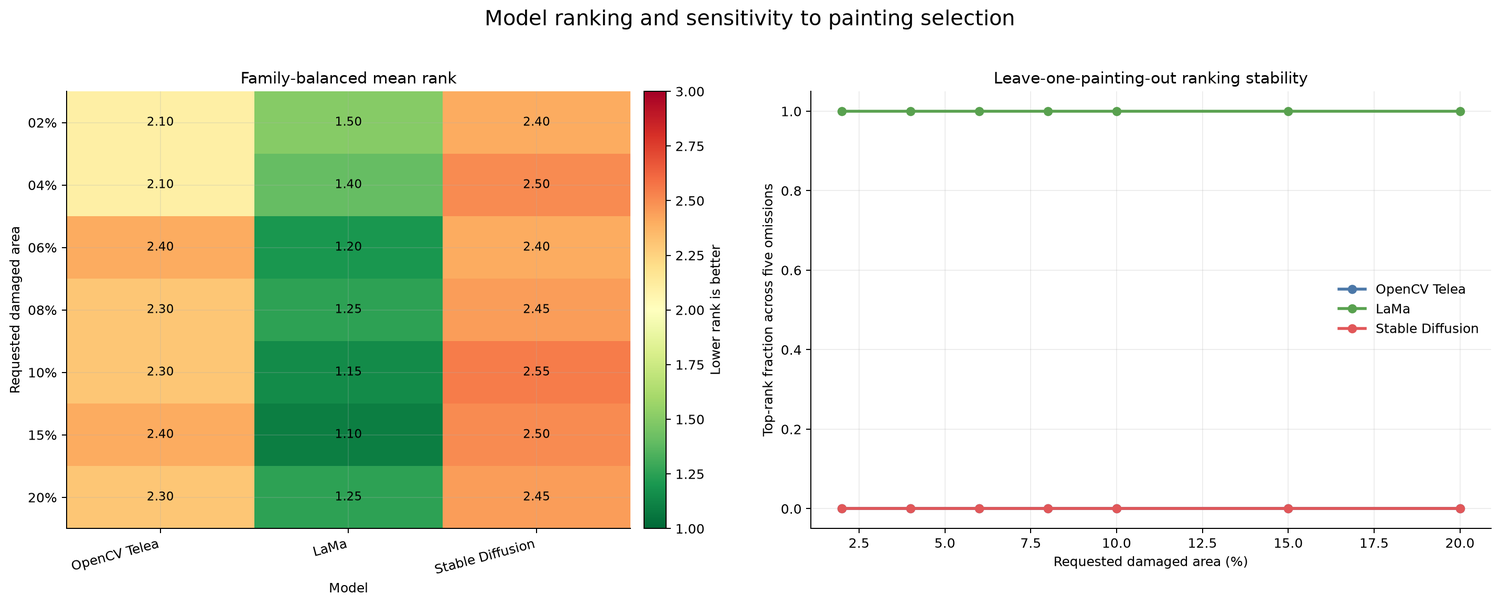

Canonical ranking figure written and rendered.
outputs\23_damage_size_sensitivity_analysis\figures\ranking_vs_damage.png


In [54]:
rank_matrix = (
    QUALITY_RANKING_BY_LEVEL.pivot(
        index="level_id",
        columns="model_id",
        values="estimate",
    )
    .reindex(POPULATION["level_ids"])
    .reindex(columns=POPULATION["model_order"])
)

top_rank_fraction = (
    QUALITY_RANKING_STABILITY.loc[
        QUALITY_RANKING_STABILITY["estimate_name"]
        .astype(str)
        .eq("loo_top_rank_fraction")
    ]
    .pivot(
        index="level_id",
        columns="model_id",
        values="estimate",
    )
    .reindex(POPULATION["level_ids"])
    .reindex(columns=POPULATION["model_order"])
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6.5),
)

rank_image = axes[0].imshow(
    rank_matrix.to_numpy(dtype=float),
    cmap="RdYlGn_r",
    vmin=1.0,
    vmax=float(len(POPULATION["model_order"])),
    aspect="auto",
)

axes[0].set_xticks(
    range(len(rank_matrix.columns)),
    [
        MODEL_LABELS[str(model_id)]
        for model_id in rank_matrix.columns
    ],
    rotation=15,
    ha="right",
)
axes[0].set_yticks(
    range(len(rank_matrix.index)),
    [
        level_id.replace("size_", "").replace(
            "pct",
            "%",
        )
        for level_id in rank_matrix.index
    ],
)
axes[0].set_title("Family-balanced mean rank")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Requested damaged area")

for row_index in range(rank_matrix.shape[0]):
    for column_index in range(rank_matrix.shape[1]):
        axes[0].text(
            column_index,
            row_index,
            f"{rank_matrix.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
        )

fig.colorbar(
    rank_image,
    ax=axes[0],
    pad=0.02,
    label="Lower rank is better",
)

for model_id in POPULATION["model_order"]:
    model_rows = top_rank_fraction[
        str(model_id)
    ]
    axes[1].plot(
        np.asarray(expected_target_levels) * 100.0,
        model_rows.to_numpy(dtype=float),
        marker="o",
        linewidth=2.2,
        color=MODEL_COLOURS[str(model_id)],
        label=MODEL_LABELS[str(model_id)],
    )

axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlabel("Requested damaged area (%)")
axes[1].set_ylabel(
    "Top-rank fraction across five omissions"
)
axes[1].set_title(
    "Leave-one-painting-out ranking stability"
)
axes[1].legend(frameon=False)

fig.suptitle(
    "Model ranking and sensitivity to painting selection",
    fontsize=16,
)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(
    OUTPUT_PATHS["ranking_figure"],
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)
plt.close(fig)

with Image.open(
    OUTPUT_PATHS["ranking_figure"]
) as source:
    preview = source.convert("RGB")
    preview.thumbnail(
        (1500, 1000),
        Image.Resampling.LANCZOS,
    )
    display(preview.copy())

print("Canonical ranking figure written and rendered.")
print(
    OUTPUT_PATHS["ranking_figure"].relative_to(
        PROJECT_ROOT
    )
)

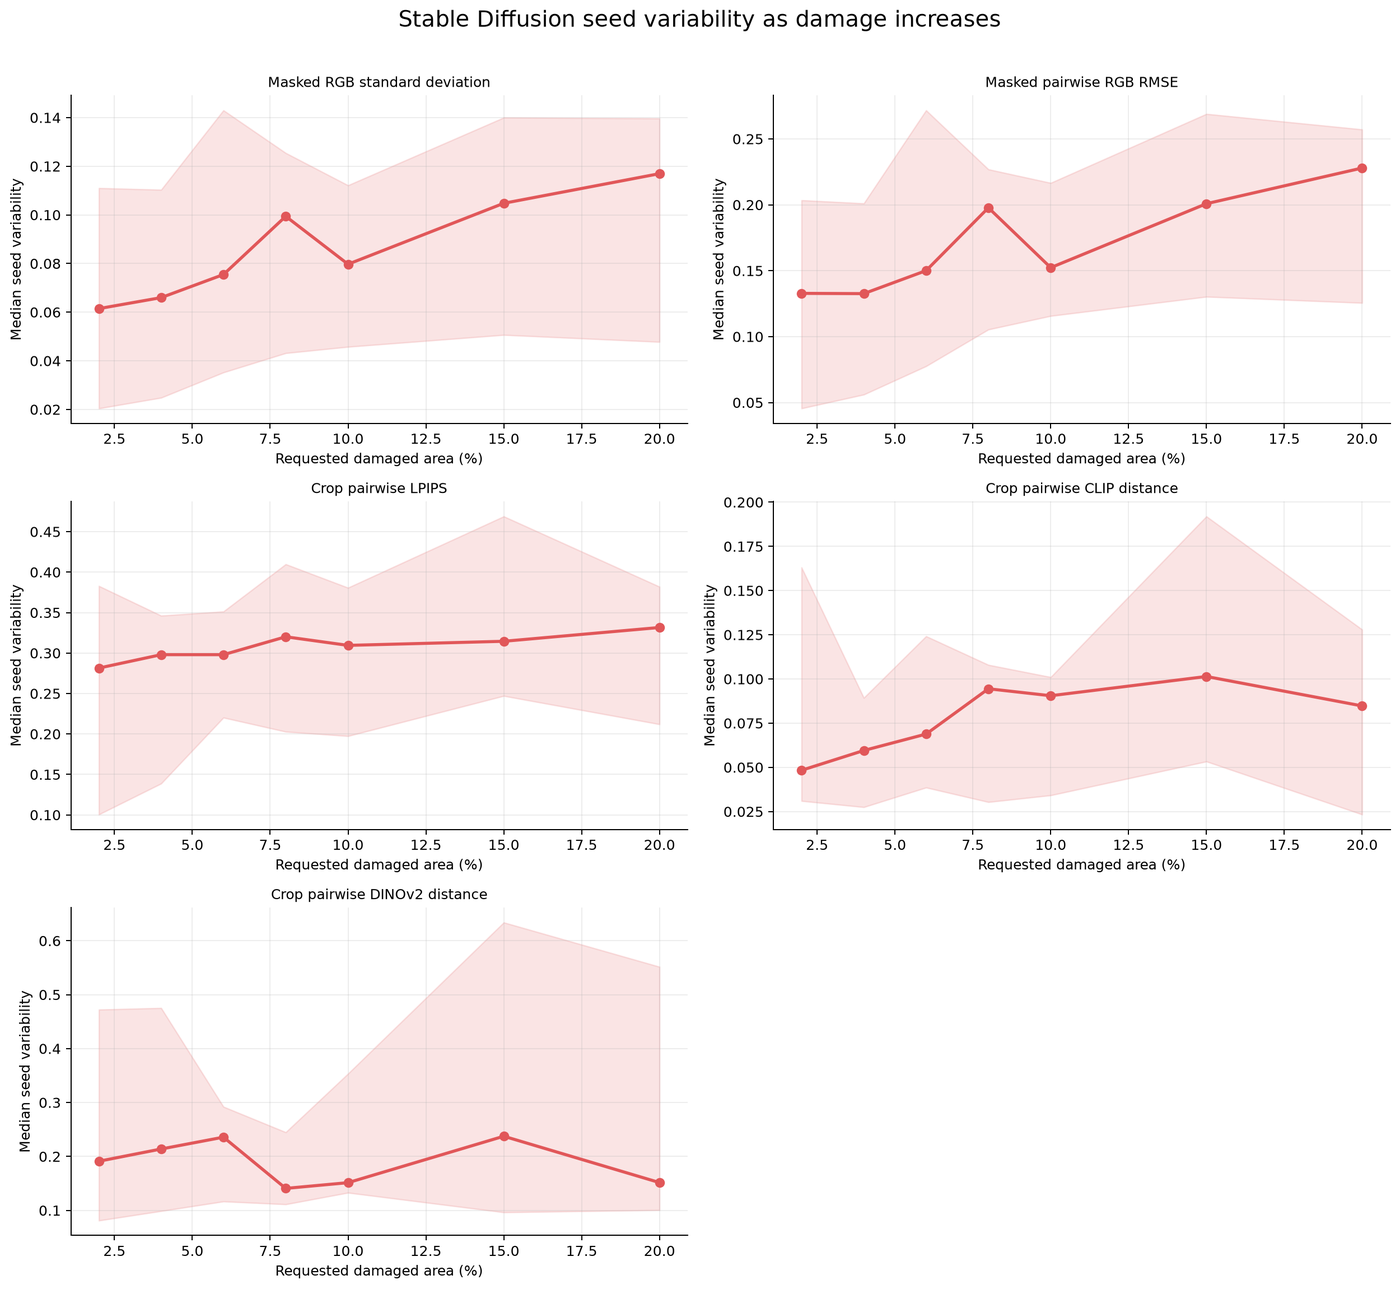

Canonical uncertainty figure written and rendered.
outputs\23_damage_size_sensitivity_analysis\figures\uncertainty_vs_damage.png


In [55]:
main_uncertainty_level_rows = (
    UNCERTAINTY_LEVEL_SUMMARY.loc[
        UNCERTAINTY_LEVEL_SUMMARY["anchor_id"]
        .astype(str)
        .isin(main_component_ids)
    ]
    .copy()
)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 13),
    squeeze=False,
)

for axis, component_id in zip(
    axes.flat,
    main_component_ids,
):
    component_rows = (
        main_uncertainty_level_rows.loc[
            main_uncertainty_level_rows["anchor_id"]
            .astype(str)
            .eq(component_id)
        ]
        .copy()
        .sort_values(
            "target_damage_fraction",
            kind="stable",
        )
    )

    x = (
        pd.to_numeric(
            component_rows["target_damage_fraction"],
            errors="coerce",
        ).to_numpy(dtype=float)
        * 100.0
    )
    y = pd.to_numeric(
        component_rows["estimate"],
        errors="coerce",
    ).to_numpy(dtype=float)
    lower = pd.to_numeric(
        component_rows["ci_lower"],
        errors="coerce",
    ).to_numpy(dtype=float)
    upper = pd.to_numeric(
        component_rows["ci_upper"],
        errors="coerce",
    ).to_numpy(dtype=float)

    axis.plot(
        x,
        y,
        marker="o",
        linewidth=2.2,
        color="#E15759",
    )
    axis.fill_between(
        x,
        lower,
        upper,
        color="#E15759",
        alpha=0.16,
    )
    axis.set_title(
        component_labels.get(
            component_id,
            component_id,
        ),
        fontsize=10,
    )
    axis.set_xlabel("Requested damaged area (%)")
    axis.set_ylabel("Median seed variability")

for axis in list(axes.flat)[len(main_component_ids):]:
    axis.set_visible(False)

fig.suptitle(
    "Stable Diffusion seed variability as damage increases",
    fontsize=16,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(
    OUTPUT_PATHS["uncertainty_figure"],
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)
plt.close(fig)

with Image.open(
    OUTPUT_PATHS["uncertainty_figure"]
) as source:
    preview = source.convert("RGB")
    preview.thumbnail(
        (1400, 1400),
        Image.Resampling.LANCZOS,
    )
    display(preview.copy())

print("Canonical uncertainty figure written and rendered.")
print(
    OUTPUT_PATHS["uncertainty_figure"].relative_to(
        PROJECT_ROOT
    )
)

In [56]:
figure_metadata_records = []

for figure_key in (
    "performance_figure",
    "ranking_figure",
    "uncertainty_figure",
):
    figure_path = OUTPUT_PATHS[figure_key]

    with Image.open(figure_path) as image:
        figure_metadata_records.append(
            {
                "figure_key": figure_key,
                "relative_path": str(
                    figure_path.relative_to(PROJECT_ROOT)
                ).replace("\\", "/"),
                "exists": figure_path.is_file(),
                "format": str(image.format),
                "mode": str(image.mode),
                "width": int(image.width),
                "height": int(image.height),
                "size_bytes": int(
                    figure_path.stat().st_size
                ),
                "sha256": sha256_file(figure_path),
            }
        )

FIGURE_METADATA = pd.DataFrame(
    figure_metadata_records
)

VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="canonical_figure_count",
    check_description="All three canonical figures were written.",
    severity="blocking",
    expected=int(EXPECTED["canonical_figures"]),
    observed=len(FIGURE_METADATA),
    passed=(
        len(FIGURE_METADATA)
        == int(EXPECTED["canonical_figures"])
        and FIGURE_METADATA["exists"].all()
    ),
)
VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="canonical_figures_reload",
    check_description="Every canonical figure reloads as a non-empty PNG.",
    severity="blocking",
    expected={
        "format": "PNG",
        "positive_dimensions": True,
    },
    observed=FIGURE_METADATA[
        [
            "figure_key",
            "format",
            "width",
            "height",
            "size_bytes",
        ]
    ].to_dict("records"),
    passed=(
        FIGURE_METADATA["format"].eq("PNG").all()
        and FIGURE_METADATA["width"].gt(0).all()
        and FIGURE_METADATA["height"].gt(0).all()
        and FIGURE_METADATA["size_bytes"].gt(0).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="canonical_metrics_file",
    check_description="The canonical metrics CSV exists and is non-empty.",
    severity="blocking",
    expected=True,
    observed={
        "exists": OUTPUT_PATHS["metrics"].is_file(),
        "size_bytes": (
            OUTPUT_PATHS["metrics"].stat().st_size
            if OUTPUT_PATHS["metrics"].is_file()
            else 0
        ),
        "sha256": (
            sha256_file(OUTPUT_PATHS["metrics"])
            if OUTPUT_PATHS["metrics"].is_file()
            else ""
        ),
    },
    passed=(
        OUTPUT_PATHS["metrics"].is_file()
        and OUTPUT_PATHS["metrics"].stat().st_size > 0
    ),
)
VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="no_combined_quality_or_uncertainty_index",
    check_description="The canonical analysis contains no combined quality, uncertainty, or trust score.",
    severity="blocking",
    expected=True,
    observed=final_analysis_validation[
        "no_combined_score_or_index"
    ],
    passed=bool(
        final_analysis_validation[
            "no_combined_score_or_index"
        ]
    ),
)
VALIDATION.add(
    validation_stage="batch_8_persistence_validation",
    check_id="independent_unit_scope",
    check_description="Inferential summaries retain painting trajectories as the independent unit.",
    severity="blocking",
    expected=SETTINGS["statistics"][
        "independent_unit"
    ],
    observed=sorted(
        FINAL_ANALYSIS.loc[
            FINAL_ANALYSIS["p_value"].notna(),
            "independent_unit",
        ]
        .astype(str)
        .unique()
    ),
    passed=(
        FINAL_ANALYSIS.loc[
            FINAL_ANALYSIS["p_value"].notna(),
            "independent_unit",
        ]
        .astype(str)
        .eq(
            SETTINGS["statistics"][
                "independent_unit"
            ]
        )
        .all()
    ),
)

BATCH_8_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"].eq(
            "batch_8_persistence_validation"
        )
    ]
    .reset_index(drop=True)
)

display(
    FINAL_ANALYSIS.groupby(
        [
            "analysis_kind",
            "evidence_family",
        ],
        observed=True,
        dropna=False,
    )
    .size()
    .rename("row_count")
    .reset_index()
)
display(FIGURE_METADATA)
display(BATCH_8_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 8 passed.")
print(f"Canonical analysis rows: {len(FINAL_ANALYSIS):,}")
print(
    f"Canonical figures: {len(FIGURE_METADATA)}"
)
print(
    f"Validation checks: {len(BATCH_8_CHECKS)}"
)
print(
    "Blocking failures: "
    f"{int((BATCH_8_CHECKS['severity'].eq('blocking') & ~BATCH_8_CHECKS['passed']).sum())}"
)
print(
    "Four of eight canonical output files now exist: "
    "metrics plus three figures."
)
print(
    "Next batch: self-contained report, final manifests, "
    "validation persistence, and completion gate."
)

,analysis_kind,evidence_family,row_count
0,adjacent_change,classical_pixel,18
1,adjacent_change,colour,18
2,adjacent_change,feature_similarity,36
3,adjacent_change,local_semantic_preservation,18
4,adjacent_change,perceptual,18
...,...,...,...
75,paired_model_contrast,texture_map,6
76,ranking_by_level,family_balanced_quality,21
77,ranking_stability,family_balanced_quality,63
78,uncertainty_level_summary,diffusion_uncertainty,210


,figure_key,relative_path,exists,format,mode,width,height,size_bytes,sha256
0,performance_figure,outputs/23_damage_size_sensitivity_analysis/figures/performance_vs_damage.png,True,PNG,RGBA,3040,3198,1017145,dccb5a2a351d9d3c1006d8de89e04cbee0bd98f1e108cde6a5bc6377b5427ff0
1,ranking_figure,outputs/23_damage_size_sensitivity_analysis/figures/ranking_vs_damage.png,True,PNG,RGBA,2860,1153,178439,dba8ea26f52aa36197560edb37ddc2c902136c2528056b0080430d6f4dc1a303
2,uncertainty_figure,outputs/23_damage_size_sensitivity_analysis/figures/uncertainty_vs_damage.png,True,PNG,RGBA,2500,2301,389352,41458f1c546e37f4aca7baef4097a969b1d190e12a8ee2a7999d79d0e76838f4


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_persistence_validation,damage_integrity_rows,Seven integrity fields are summarized at all seven damage levels.,blocking,49,49,True,
1,batch_8_persistence_validation,runtime_analysis_rows,"Runtime includes level summaries, painting slopes, and population trends.",blocking,"{""level_summaries"": 21, ""painting_slopes"": 30, ""trends"": 6}","{""level_summaries"": 21, ""painting_slopes"": 30, ""trends"": 6}",True,
2,batch_8_persistence_validation,runtime_excluded_from_quality_ranking,Every canonical runtime row is excluded from quality ranking.,blocking,False,False,True,
3,batch_8_persistence_validation,complete_analysis_schema,The complete canonical analysis table passes schema validation.,blocking,True,"{""analysis_ids_unique"": true, ""analysis_kinds_valid"": true, ""missing_columns"": [], ""no_combined_score_or_index"": tru...",True,
4,batch_8_persistence_validation,all_analysis_kinds_present,Every analysis kind declared by the Notebook 23 contract is present.,blocking,"[""adjacent_change"", ""damage_integrity"", ""damage_trend"", ""evaluated_baseline_type_contrast"", ""level_summary"", ""morpho...","[""adjacent_change"", ""damage_integrity"", ""damage_trend"", ""evaluated_baseline_type_contrast"", ""level_summary"", ""morpho...",True,
5,batch_8_persistence_validation,final_fdr_values,Every inferential row has a valid globally recomputed q-value.,blocking,True,"{""finite_p_values"": 646, ""finite_q_values"": 646, ""inferential_rows_with_finite_q"": 646}",True,
6,batch_8_persistence_validation,canonical_metrics_round_trip,The canonical analysis CSV reloads with unchanged rows and unique IDs.,blocking,"{""rows"": 1901, ""unique_ids"": 1901}","{""rows"": 1901, ""schema_validation"": {""analysis_ids_unique"": true, ""analysis_kinds_valid"": true, ""missing_columns"": [...",True,
7,batch_8_persistence_validation,canonical_figure_count,All three canonical figures were written.,blocking,3,3,True,
8,batch_8_persistence_validation,canonical_figures_reload,Every canonical figure reloads as a non-empty PNG.,blocking,"{""format"": ""PNG"", ""positive_dimensions"": true}","[{""figure_key"": ""performance_figure"", ""format"": ""PNG"", ""height"": 3198, ""size_bytes"": 1017145, ""width"": 3040}, {""figu...",True,
9,batch_8_persistence_validation,canonical_metrics_file,The canonical metrics CSV exists and is non-empty.,blocking,True,"{""exists"": true, ""sha256"": ""74064d71c1802c1f47aae1fb13f0f312abb88e0ec19b979d65aea2b59be09e48"", ""size_bytes"": 2595616}",True,


Batch 8 passed.
Canonical analysis rows: 1,901
Canonical figures: 3
Validation checks: 12
Blocking failures: 0
Four of eight canonical output files now exist: metrics plus three figures.
Next batch: self-contained report, final manifests, validation persistence, and completion gate.


## Batch 9 — Self-contained report, manifests, and completion gate

This final batch:

- derives plain-language conclusions from the validated canonical analysis;
- creates six report-only analytical views without saving redundant figure files;
- builds five painting-level restoration panels and three uncertainty-diagnostic panels;
- embeds all required visuals directly inside a standalone HTML report;
- validates report density, portability, scope, and thesis-question framing;
- records roadmap traceability;
- persists consolidated validation, artifact, and run manifests;
- updates the global project-path registry;
- independently reloads and verifies all eight canonical outputs.

The report does not introduce new metrics, rankings, tests, or composite scores. Its conclusions remain limited to the five matched painting trajectories and the validated computational evidence.

In [57]:
import base64
import io
import os
import re
import time
from html import escape

from IPython.display import HTML as NotebookHTML

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_path,
)
from restoration_eval.multi_model_comparison import (
    image_grid_to_data_uri,
    image_path_to_data_uri,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    load_project_paths_registry,
    to_repo_relative,
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    VALIDATION_SCHEMA_VERSION,
)


def figure_to_data_uri(figure, *, dpi=140):
    buffer = io.BytesIO()
    figure.savefig(
        buffer,
        format="png",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )
    payload = base64.b64encode(
        buffer.getvalue()
    ).decode("ascii")
    return f"data:image/png;base64,{payload}"


def atomic_write_text_retry(
    output_path,
    text,
    *,
    attempts=5,
):
    destination = Path(output_path)
    temporary = destination.with_suffix(
        destination.suffix + ".tmp"
    )
    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    last_error = None

    for attempt in range(1, attempts + 1):
        try:
            temporary.write_text(
                text,
                encoding="utf-8",
                newline="\n",
            )
            os.replace(temporary, destination)
            return attempt
        except PermissionError as exc:
            last_error = exc
            temporary.unlink(missing_ok=True)
            if attempt < attempts:
                time.sleep(0.25 * attempt)

    raise last_error


def report_table(frame, *, maximum_rows=None):
    table = frame.copy()

    if maximum_rows is not None:
        table = table.head(int(maximum_rows))

    return table.to_html(
        index=False,
        border=0,
        classes="data-table",
        na_rep="—",
        float_format=lambda value: f"{value:.4f}",
        escape=True,
    )


target_quality_trends = (
    FINAL_ANALYSIS.loc[
        FINAL_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("damage_trend")
        & FINAL_ANALYSIS[
            "quality_ranking_eligible"
        ].astype(bool)
        & FINAL_ANALYSIS[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
    ]
    .copy()
)

for column in (
    "estimate",
    "ci_lower",
    "ci_upper",
    "p_value",
    "q_value",
):
    target_quality_trends[column] = (
        pd.to_numeric(
            target_quality_trends[column],
            errors="coerce",
        )
    )

quality_winner_indices = (
    target_quality_trends.groupby(
        "anchor_id",
        observed=True,
    )["estimate"]
    .idxmin()
)

quality_winners = (
    target_quality_trends.loc[
        quality_winner_indices
    ]
    .copy()
    .sort_values("anchor_id", kind="stable")
)

quality_winner_counts = (
    quality_winners["model_id"]
    .astype(str)
    .value_counts()
    .reindex(POPULATION["model_order"], fill_value=0)
)

leading_sensitivity_model = str(
    quality_winner_counts.idxmax()
)
leading_sensitivity_count = int(
    quality_winner_counts.max()
)

significant_quality_trends = int(
    target_quality_trends["q_value"]
    .le(0.05)
    .sum()
)

target_uncertainty_trends = (
    FINAL_ANALYSIS.loc[
        FINAL_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("uncertainty_trend")
        & FINAL_ANALYSIS[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
        & FINAL_ANALYSIS["anchor_id"]
        .astype(str)
        .isin(main_component_ids)
    ]
    .copy()
)

for column in (
    "estimate",
    "ci_lower",
    "ci_upper",
    "p_value",
    "q_value",
):
    target_uncertainty_trends[column] = (
        pd.to_numeric(
            target_uncertainty_trends[column],
            errors="coerce",
        )
    )

positive_uncertainty_components = int(
    target_uncertainty_trends["estimate"]
    .gt(0)
    .sum()
)
significant_uncertainty_components = int(
    target_uncertainty_trends["q_value"]
    .le(0.05)
    .sum()
)

ranking_winners = (
    QUALITY_RANKING_BY_LEVEL.loc[
        QUALITY_RANKING_BY_LEVEL.groupby(
            "level_id",
            observed=True,
        )["estimate"]
        .idxmin()
    ]
    [
        [
            "level_id",
            "target_damage_fraction",
            "model_id",
            "estimate",
        ]
    ]
    .copy()
    .sort_values(
        "target_damage_fraction",
        kind="stable",
    )
)

ranking_winner_count = int(
    ranking_winners["model_id"].nunique()
)

maximum_damage_area_error = float(
    pd.to_numeric(
        CASE_DESIGN[
            "absolute_percentage_point_error"
        ],
        errors="coerce",
    ).max()
)

significant_morphology_associations = int(
    pd.to_numeric(
        MORPHOLOGY_ASSOCIATIONS["q_value"],
        errors="coerce",
    )
    .le(0.05)
    .sum()
)

quality_winner_table = (
    quality_winners[
        [
            "anchor_id",
            "evidence_family",
            "metric_name",
            "region_id",
            "model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
            "q_value",
        ]
    ]
    .rename(
        columns={
            "anchor_id": "Quality anchor",
            "evidence_family": "Evidence family",
            "metric_name": "Metric",
            "region_id": "Region",
            "model_id": "Lowest deterioration",
            "estimate": "Adverse slope",
            "ci_lower": "CI lower",
            "ci_upper": "CI upper",
            "q_value": "FDR q-value",
        }
    )
)

quality_winner_table[
    "Lowest deterioration"
] = quality_winner_table[
    "Lowest deterioration"
].map(MODEL_LABELS)

ranking_report_table = ranking_winners.rename(
    columns={
        "level_id": "Damage level",
        "target_damage_fraction": (
            "Requested damaged fraction"
        ),
        "model_id": "Top-ranked model",
        "estimate": "Family-balanced mean rank",
    }
)

ranking_report_table[
    "Requested damaged fraction"
] = (
    ranking_report_table[
        "Requested damaged fraction"
    ]
    * 100.0
)

ranking_report_table[
    "Top-ranked model"
] = ranking_report_table[
    "Top-ranked model"
].map(MODEL_LABELS)

uncertainty_report_table = (
    target_uncertainty_trends[
        [
            "anchor_id",
            "metric_name",
            "region_id",
            "estimate",
            "ci_lower",
            "ci_upper",
            "q_value",
        ]
    ]
    .rename(
        columns={
            "anchor_id": "Component",
            "metric_name": "Metric",
            "region_id": "Region",
            "estimate": "Slope per 10 percentage points",
            "ci_lower": "CI lower",
            "ci_upper": "CI upper",
            "q_value": "FDR q-value",
        }
    )
)

morphology_report_table = (
    MORPHOLOGY_ASSOCIATIONS.assign(
        absolute_rho=lambda frame: pd.to_numeric(
            frame["estimate"],
            errors="coerce",
        ).abs()
    )
    .sort_values(
        ["absolute_rho", "q_value"],
        ascending=[False, True],
        kind="stable",
    )
    [
        [
            "evidence_family",
            "anchor_id",
            "model_id",
            "exposure_definition",
            "estimate",
            "q_value",
        ]
    ]
    .head(12)
    .rename(
        columns={
            "evidence_family": "Evidence family",
            "anchor_id": "Outcome",
            "model_id": "Model",
            "exposure_definition": (
                "Adjusted morphology field"
            ),
            "estimate": "Spearman rho",
            "q_value": "FDR q-value",
        }
    )
)

morphology_report_table["Model"] = (
    morphology_report_table["Model"]
    .map(MODEL_LABELS)
    .fillna(morphology_report_table["Model"])
)

report_finding_summary = {
    "leading_model": MODEL_LABELS[
        leading_sensitivity_model
    ],
    "leading_model_anchor_count": (
        leading_sensitivity_count
    ),
    "quality_anchor_count": int(
        EXPECTED["quality_anchors"]
    ),
    "significant_quality_trends": (
        significant_quality_trends
    ),
    "positive_uncertainty_components": (
        positive_uncertainty_components
    ),
    "main_uncertainty_components": len(
        main_component_ids
    ),
    "significant_uncertainty_components": (
        significant_uncertainty_components
    ),
    "ranking_winner_count": (
        ranking_winner_count
    ),
    "maximum_damage_area_error": (
        maximum_damage_area_error
    ),
    "significant_morphology_associations": (
        significant_morphology_associations
    ),
}

display(
    pd.DataFrame(
        [report_finding_summary]
    )
)
display(quality_winner_table)
display(ranking_report_table)
display(uncertainty_report_table)

print("Report evidence and conclusions prepared.")
print(
    "All report claims are derived from the "
    "validated canonical analysis."
)

,leading_model,leading_model_anchor_count,quality_anchor_count,significant_quality_trends,positive_uncertainty_components,main_uncertainty_components,significant_uncertainty_components,ranking_winner_count,maximum_damage_area_error,significant_morphology_associations
0,OpenCV Telea,7,11,0,5,5,0,1,0.000123,1


,Quality anchor,Evidence family,Metric,Region,Lowest deterioration,Adverse slope,CI lower,CI upper,FDR q-value
250,classical_masked_mae,classical_pixel,mae,masked_region,OpenCV Telea,3.707553,1.415337,17.778759,0.06250
256,colour_masked_delta_e,colour,delta_e_ciede2000_mean,masked_region,OpenCV Telea,1.212552,0.783073,7.003295,0.06250
264,feature_clip_crop,feature_similarity,clip_cosine_similarity,mask_bbox_crop,Stable Diffusion,0.022675,-0.083623,0.048469,0.87500
270,feature_dino_crop,feature_similarity,dinov2_cosine_similarity,mask_bbox_crop,Stable Diffusion,0.007283,-0.190282,0.080111,0.87500
274,perceptual_crop_lpips,perceptual,lpips,mask_bbox_crop,OpenCV Telea,0.030682,0.011503,0.115199,0.09375
284,seam_boundary_gradient,seam,boundary_gradient_mismatch,boundary_ring,LaMa,-0.001061,-0.001105,0.001233,0.93750
292,semantic_local_dino,local_semantic_preservation,local_patch_cosine_similarity,mask_bbox_crop,OpenCV Telea,0.036880,0.002317,0.132217,0.09375
298,spatial_masked_error,spatial_diagnostics,restored_error_mean,masked_region,OpenCV Telea,3.707553,1.415337,17.778759,0.06250
302,structural_affinity_correlation,structural_layout,reference_affinity_map_correlation,content_region,LaMa,0.061467,0.039395,0.103746,0.06250
310,structural_crop_ssim,ssim,ssim,mask_bbox_crop,OpenCV Telea,0.005635,-0.013750,0.087609,0.43750


,Damage level,Requested damaged fraction,Top-ranked model,Family-balanced mean rank
0,size_02pct,2.0,LaMa,1.50
3,size_04pct,4.0,LaMa,1.40
6,size_06pct,6.0,LaMa,1.20
9,size_08pct,8.0,LaMa,1.25
12,size_10pct,10.0,LaMa,1.15
15,size_15pct,15.0,LaMa,1.10
18,size_20pct,20.0,LaMa,1.25


,Component,Metric,Region,Slope per 10 percentage points,CI lower,CI upper,FDR q-value
1842,crop_pairwise_clip,pairwise_clip_cosine_distance,mask_bbox_crop,0.029871,-0.077653,0.042543,0.937500
1844,crop_pairwise_dino,pairwise_dinov2_cosine_distance,mask_bbox_crop,0.033028,-0.216213,0.198220,0.975000
1846,crop_pairwise_lpips,pairwise_lpips_distance,mask_bbox_crop,0.051170,-0.056961,0.118562,0.394737
1898,masked_pairwise_rgb_rmse,pairwise_rgb_rmse,masked_region,0.044537,0.023393,0.063634,0.110294
1900,masked_rgb_std,pixel_rgb_std_mean,masked_region,0.031027,0.009590,0.032559,0.110294


Report evidence and conclusions prepared.
All report claims are derived from the validated canonical analysis.


In [58]:
ANALYTICAL_VIEWS = []

for view_id, title, caption, path_key in (
    (
        "canonical_performance",
        "Performance across damage levels",
        (
            "All eleven quality anchors. Lines show "
            "five-painting medians and shaded intervals."
        ),
        "performance_figure",
    ),
    (
        "canonical_ranking",
        "Model ranking across damage levels",
        (
            "Family-balanced ranks and leave-one-painting-"
            "out top-rank stability."
        ),
        "ranking_figure",
    ),
    (
        "canonical_uncertainty",
        "Stable Diffusion seed variability",
        (
            "Transparent uncertainty components across "
            "the seven damage levels."
        ),
        "uncertainty_figure",
    ),
):
    ANALYTICAL_VIEWS.append(
        {
            "view_id": view_id,
            "title": title,
            "caption": caption,
            "data_uri": image_path_to_data_uri(
                OUTPUT_PATHS[path_key],
                max_dimension=1400,
                photographic_format="JPEG",
                quality=84,
            ),
            "source": to_repo_relative(
                OUTPUT_PATHS[path_key],
                PROJECT_ROOT,
            ),
            "persisted": True,
        }
    )


slope_matrix = (
    target_quality_trends.pivot(
        index="anchor_id",
        columns="model_id",
        values="estimate",
    )
    .reindex(columns=POPULATION["model_order"])
)

fig, axis = plt.subplots(figsize=(10, 8))
slope_limit = float(
    np.nanmax(
        np.abs(
            slope_matrix.to_numpy(dtype=float)
        )
    )
)
slope_limit = max(slope_limit, 1e-12)

image_handle = axis.imshow(
    slope_matrix.to_numpy(dtype=float),
    cmap="coolwarm",
    vmin=-slope_limit,
    vmax=slope_limit,
    aspect="auto",
)

axis.set_xticks(
    range(len(slope_matrix.columns)),
    [
        MODEL_LABELS[str(model_id)]
        for model_id in slope_matrix.columns
    ],
    rotation=15,
    ha="right",
)
axis.set_yticks(
    range(len(slope_matrix.index)),
    slope_matrix.index,
)
axis.set_title(
    "Adverse quality slope per 10 percentage-point increase"
)
axis.set_xlabel("Model")
axis.set_ylabel("Quality anchor")

for row_index in range(slope_matrix.shape[0]):
    for column_index in range(
        slope_matrix.shape[1]
    ):
        axis.text(
            column_index,
            row_index,
            (
                f"{slope_matrix.iloc[row_index, column_index]:.3g}"
            ),
            ha="center",
            va="center",
            fontsize=7,
        )

fig.colorbar(
    image_handle,
    ax=axis,
    pad=0.02,
    label="Positive means measured quality became worse",
)
fig.tight_layout()

ANALYTICAL_VIEWS.append(
    {
        "view_id": "quality_slope_heatmap",
        "title": "Which model deteriorated least?",
        "caption": (
            "Each cell is a matched five-painting adverse "
            "slope. Metrics remain separate; this is not a "
            "combined quality score."
        ),
        "data_uri": figure_to_data_uri(fig),
        "source": (
            "damage_size_analysis.csv:"
            "analysis_kind=damage_trend"
        ),
        "persisted": False,
    }
)
plt.close(fig)


adjacent_plot_anchors = [
    "classical_masked_mae",
    "perceptual_crop_lpips",
    "colour_masked_delta_e",
    "seam_boundary_gradient",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    squeeze=False,
)

for axis, anchor_id in zip(
    axes.flat,
    adjacent_plot_anchors,
):
    rows = (
        QUALITY_ADJACENT_SUMMARY.loc[
            QUALITY_ADJACENT_SUMMARY[
                "anchor_id"
            ]
            .astype(str)
            .eq(anchor_id)
            & QUALITY_ADJACENT_SUMMARY[
                "exposure_definition"
            ]
            .astype(str)
            .eq("target_damage_fraction")
        ]
        .copy()
        .sort_values(
            [
                "model_id",
                "interval_end_fraction",
            ],
            kind="stable",
        )
    )

    for model_id in POPULATION["model_order"]:
        model_rows = rows.loc[
            rows["model_id"]
            .astype(str)
            .eq(str(model_id))
        ]

        axis.plot(
            pd.to_numeric(
                model_rows[
                    "interval_end_fraction"
                ],
                errors="coerce",
            )
            * 100.0,
            pd.to_numeric(
                model_rows["estimate"],
                errors="coerce",
            ),
            marker="o",
            linewidth=2,
            color=MODEL_COLOURS[str(model_id)],
            label=MODEL_LABELS[str(model_id)],
        )

    axis.axhline(
        0.0,
        color="#555555",
        linewidth=0.8,
    )
    axis.set_title(anchor_id)
    axis.set_xlabel(
        "Upper end of adjacent interval (%)"
    )
    axis.set_ylabel(
        "Adverse change per percentage point"
    )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncols=3,
    frameon=False,
)
fig.suptitle(
    "Where deterioration accelerates or eases",
    fontsize=15,
)
fig.tight_layout(rect=(0, 0.06, 1, 0.96))

ANALYTICAL_VIEWS.append(
    {
        "view_id": "adjacent_deterioration",
        "title": "Adjacent-level deterioration",
        "caption": (
            "Consecutive damage intervals are compared "
            "within paintings and normalized per percentage "
            "point. No universal threshold is inferred."
        ),
        "data_uri": figure_to_data_uri(fig),
        "source": (
            "damage_size_analysis.csv:"
            "analysis_kind=adjacent_change"
        ),
        "persisted": False,
    }
)
plt.close(fig)


paired_target_rows = (
    QUALITY_PAIRED_CONTRASTS.loc[
        QUALITY_PAIRED_CONTRASTS[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
    ]
    .copy()
)

paired_target_rows["comparison"] = (
    paired_target_rows["model_id"]
    .astype(str)
    .map(MODEL_LABELS)
    + " − "
    + paired_target_rows[
        "comparison_model_id"
    ]
    .astype(str)
    .map(MODEL_LABELS)
)

paired_effect_matrix = (
    paired_target_rows.pivot(
        index="anchor_id",
        columns="comparison",
        values="effect_size",
    )
)

fig, axis = plt.subplots(figsize=(12, 8))
effect_image = axis.imshow(
    paired_effect_matrix.to_numpy(dtype=float),
    cmap="PiYG_r",
    vmin=-1.0,
    vmax=1.0,
    aspect="auto",
)

axis.set_xticks(
    range(len(paired_effect_matrix.columns)),
    paired_effect_matrix.columns,
    rotation=25,
    ha="right",
)
axis.set_yticks(
    range(len(paired_effect_matrix.index)),
    paired_effect_matrix.index,
)
axis.set_title(
    "Matched rank-biserial effects for slope differences"
)
axis.set_xlabel("First model minus second model")
axis.set_ylabel("Quality anchor")
fig.colorbar(
    effect_image,
    ax=axis,
    pad=0.02,
    label="Matched rank-biserial effect",
)
fig.tight_layout()

ANALYTICAL_VIEWS.append(
    {
        "view_id": "paired_model_contrasts",
        "title": "Paired model-sensitivity contrasts",
        "caption": (
            "Effect sizes compare deterioration slopes on "
            "the same five paintings. Positive slope "
            "differences mean the first model worsened faster."
        ),
        "data_uri": figure_to_data_uri(fig),
        "source": (
            "damage_size_analysis.csv:"
            "analysis_kind=paired_model_contrast"
        ),
        "persisted": False,
    }
)
plt.close(fig)


morphology_plot_rows = (
    MORPHOLOGY_ASSOCIATIONS.assign(
        estimate_numeric=lambda frame: (
            pd.to_numeric(
                frame["estimate"],
                errors="coerce",
            )
        ),
        absolute_rho=lambda frame: (
            pd.to_numeric(
                frame["estimate"],
                errors="coerce",
            ).abs()
        ),
    )
    .nlargest(18, "absolute_rho")
    .sort_values(
        "estimate_numeric",
        kind="stable",
    )
)

morphology_labels = (
    morphology_plot_rows["model_id"]
    .astype(str)
    .map(MODEL_LABELS)
    .fillna(
        morphology_plot_rows[
            "model_id"
        ].astype(str)
    )
    + " · "
    + morphology_plot_rows[
        "anchor_id"
    ].astype(str)
    + " · "
    + morphology_plot_rows[
        "exposure_definition"
    ]
    .astype(str)
    .str.replace(
        "morphology:",
        "",
        regex=False,
    )
)

fig, axis = plt.subplots(figsize=(12, 9))
axis.barh(
    range(len(morphology_plot_rows)),
    morphology_plot_rows[
        "estimate_numeric"
    ],
    color=[
        "#E15759" if value > 0 else "#4C78A8"
        for value in morphology_plot_rows[
            "estimate_numeric"
        ]
    ],
)
axis.set_yticks(
    range(len(morphology_plot_rows)),
    morphology_labels,
    fontsize=7,
)
axis.axvline(
    0.0,
    color="#333333",
    linewidth=0.9,
)
axis.set_xlabel(
    "Size- and painting-adjusted Spearman rho"
)
axis.set_title(
    "Largest exploratory morphology associations"
)
fig.tight_layout()

ANALYTICAL_VIEWS.append(
    {
        "view_id": "morphology_associations",
        "title": "Mask morphology and measured outcomes",
        "caption": (
            "The largest adjusted correlations are shown as "
            "exploratory, non-causal evidence. FDR values "
            "remain available in the accompanying table."
        ),
        "data_uri": figure_to_data_uri(fig),
        "source": (
            "damage_size_analysis.csv:"
            "analysis_kind=morphology_association"
        ),
        "persisted": False,
    }
)
plt.close(fig)


fig, axis = plt.subplots(figsize=(10, 6))

for model_id in POPULATION["model_order"]:
    rows = (
        RUNTIME_LEVEL_SUMMARY.loc[
            RUNTIME_LEVEL_SUMMARY[
                "model_id"
            ]
            .astype(str)
            .eq(str(model_id))
        ]
        .copy()
        .sort_values(
            "target_damage_fraction",
            kind="stable",
        )
    )

    axis.plot(
        pd.to_numeric(
            rows["target_damage_fraction"],
            errors="coerce",
        )
        * 100.0,
        pd.to_numeric(
            rows["estimate"],
            errors="coerce",
        ),
        marker="o",
        linewidth=2.2,
        color=MODEL_COLOURS[str(model_id)],
        label=MODEL_LABELS[str(model_id)],
    )

axis.set_xlabel("Requested damaged area (%)")
axis.set_ylabel("Median runtime (seconds)")
axis.set_title(
    "Operational runtime across damage levels"
)
axis.legend(frameon=False)
fig.tight_layout()

ANALYTICAL_VIEWS.append(
    {
        "view_id": "runtime_sensitivity",
        "title": "Runtime is operational evidence",
        "caption": (
            "Runtime is reported separately and never "
            "contributes to quality ranking."
        ),
        "data_uri": figure_to_data_uri(fig),
        "source": (
            "damage_size_analysis.csv:"
            "evidence_family=runtime_compute"
        ),
        "persisted": False,
    }
)
plt.close(fig)


integrity_plot_fields = [
    "absolute_percentage_point_error",
    "component_count_delta",
    "centroid_shift_pixels",
    "nested_with_previous",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    squeeze=False,
)

for axis, metric_name in zip(
    axes.flat,
    integrity_plot_fields,
):
    rows = (
        DAMAGE_INTEGRITY_ANALYSIS.loc[
            DAMAGE_INTEGRITY_ANALYSIS[
                "metric_name"
            ]
            .astype(str)
            .eq(metric_name)
        ]
        .copy()
        .sort_values(
            "target_damage_fraction",
            kind="stable",
        )
    )

    axis.plot(
        pd.to_numeric(
            rows["target_damage_fraction"],
            errors="coerce",
        )
        * 100.0,
        pd.to_numeric(
            rows["estimate"],
            errors="coerce",
        ),
        marker="o",
        linewidth=2.2,
        color="#4C78A8",
    )
    axis.fill_between(
        pd.to_numeric(
            rows["target_damage_fraction"],
            errors="coerce",
        )
        * 100.0,
        pd.to_numeric(
            rows["ci_lower"],
            errors="coerce",
        ),
        pd.to_numeric(
            rows["ci_upper"],
            errors="coerce",
        ),
        alpha=0.15,
        color="#4C78A8",
    )
    axis.set_title(
        metric_name.replace("_", " ")
    )
    axis.set_xlabel("Requested damaged area (%)")
    axis.set_ylabel(
        str(rows["value_unit"].iloc[0])
        if not rows.empty
        else "Value"
    )

fig.suptitle(
    "Controlled damage-generation integrity",
    fontsize=15,
)
fig.tight_layout(rect=(0, 0, 1, 0.96))

ANALYTICAL_VIEWS.append(
    {
        "view_id": "damage_integrity",
        "title": "Requested and generated damage remain aligned",
        "caption": (
            "Generation diagnostics verify area accuracy, "
            "nesting, component behaviour, and spatial drift."
        ),
        "data_uri": figure_to_data_uri(fig),
        "source": (
            "damage_size_analysis.csv:"
            "analysis_kind=damage_integrity"
        ),
        "persisted": False,
    }
)
plt.close(fig)


ANALYTICAL_VIEW_METADATA = pd.DataFrame(
    [
        {
            "view_id": view["view_id"],
            "title": view["title"],
            "source": view["source"],
            "persisted": view["persisted"],
        }
        for view in ANALYTICAL_VIEWS
    ]
)

display(ANALYTICAL_VIEW_METADATA)

print("Analytical report views prepared.")
print(
    f"Analytical views: "
    f"{len(ANALYTICAL_VIEWS)}"
)
print(
    "Separately persisted canonical figures: "
    f"{sum(view['persisted'] for view in ANALYTICAL_VIEWS)}"
)

,view_id,title,source,persisted
0,canonical_performance,Performance across damage levels,outputs/23_damage_size_sensitivity_analysis/figures/performance_vs_damage.png,True
1,canonical_ranking,Model ranking across damage levels,outputs/23_damage_size_sensitivity_analysis/figures/ranking_vs_damage.png,True
2,canonical_uncertainty,Stable Diffusion seed variability,outputs/23_damage_size_sensitivity_analysis/figures/uncertainty_vs_damage.png,True
3,quality_slope_heatmap,Which model deteriorated least?,damage_size_analysis.csv:analysis_kind=damage_trend,False
4,adjacent_deterioration,Adjacent-level deterioration,damage_size_analysis.csv:analysis_kind=adjacent_change,False
5,paired_model_contrasts,Paired model-sensitivity contrasts,damage_size_analysis.csv:analysis_kind=paired_model_contrast,False
6,morphology_associations,Mask morphology and measured outcomes,damage_size_analysis.csv:analysis_kind=morphology_association,False
7,runtime_sensitivity,Runtime is operational evidence,damage_size_analysis.csv:evidence_family=runtime_compute,False
8,damage_integrity,Requested and generated damage remain aligned,damage_size_analysis.csv:analysis_kind=damage_integrity,False


Analytical report views prepared.
Analytical views: 9
Separately persisted canonical figures: 3


In [59]:
REPORT_DAMAGE_LEVELS = (
    0.02,
    0.10,
    0.20,
)

REPORT_VISUAL_PANELS = []
report_tile_count = 0

for painting_number, painting_id in enumerate(
    POPULATION["painting_ids"],
    start=1,
):
    painting_cases = (
        CASE_DESIGN.loc[
            CASE_DESIGN["painting_id"]
            .astype(str)
            .eq(str(painting_id))
        ]
        .copy()
    )

    first_case = painting_cases.iloc[0]
    items = [
        (
            f"{painting_id} · clean reference",
            resolve_repository_path(
                first_case["clean_image_path"]
            ),
        )
    ]

    for target_fraction in REPORT_DAMAGE_LEVELS:
        case_rows = painting_cases.loc[
            np.isclose(
                pd.to_numeric(
                    painting_cases[
                        "target_damage_fraction"
                    ],
                    errors="coerce",
                ),
                target_fraction,
                atol=1e-12,
                rtol=0.0,
            )
        ]

        if len(case_rows) != 1:
            raise ValueError(
                "Report case selection returned "
                f"{len(case_rows)} rows for "
                f"{painting_id} at {target_fraction}."
            )

        case_row = case_rows.iloc[0]
        case_id = str(case_row["case_id"])
        level_label = (
            f"{100 * target_fraction:.0f}%"
        )

        items.extend(
            [
                (
                    f"{level_label} · mask",
                    resolve_repository_path(
                        case_row[
                            "mask_or_effect_path"
                        ]
                    ),
                ),
                (
                    f"{level_label} · damaged",
                    resolve_repository_path(
                        case_row["input_image_path"]
                    ),
                ),
            ]
        )

        candidate_rows = (
            SELECTED_CANDIDATES.loc[
                SELECTED_CANDIDATES["case_id"]
                .astype(str)
                .eq(case_id)
            ]
            .set_index("model_id")
        )

        for model_id in POPULATION["model_order"]:
            items.append(
                (
                    (
                        f"{level_label} · "
                        f"{MODEL_LABELS[str(model_id)]}"
                    ),
                    resolve_repository_path(
                        candidate_rows.loc[
                            str(model_id),
                            "restored_path",
                        ]
                    ),
                )
            )

    REPORT_VISUAL_PANELS.append(
        {
            "panel_id": (
                f"restoration_atlas_{painting_id}"
            ),
            "panel_type": "restoration",
            "title": (
                f"{painting_id}: low, middle, and "
                "high damage"
            ),
            "caption": (
                "Clean reference followed by masks, "
                "damaged inputs, and the three matched "
                "restorations at 2%, 10%, and 20% damage."
            ),
            "selection_rule": (
                "All five predeclared paintings at the "
                "predeclared low, middle, and high levels."
            ),
            "tile_count": len(items),
            "data_uri": image_grid_to_data_uri(
                items,
                columns=4,
                tile_size=(300, 260),
                quality=80,
            ),
        }
    )

    report_tile_count += len(items)

    print(
        f"Built restoration panel "
        f"{painting_number}/"
        f"{len(POPULATION['painting_ids'])}."
    )


for target_fraction in REPORT_DAMAGE_LEVELS:
    selected_maps = (
        UNCERTAINTY_MAP_MANIFEST.loc[
            np.isclose(
                pd.to_numeric(
                    UNCERTAINTY_MAP_MANIFEST[
                        "target_damage_fraction"
                    ],
                    errors="coerce",
                ),
                target_fraction,
                atol=1e-12,
                rtol=0.0,
            )
        ]
        .copy()
        .sort_values(
            "painting_id",
            kind="stable",
        )
    )

    if len(selected_maps) != int(
        EXPECTED["paintings"]
    ):
        raise ValueError(
            "Uncertainty-panel selection did not "
            "return all five paintings."
        )

    items = [
        (
            (
                f"{row.painting_id} · "
                f"{100 * target_fraction:.0f}%"
            ),
            Path(row.resolved_path),
        )
        for row in selected_maps.itertuples(
            index=False
        )
    ]

    REPORT_VISUAL_PANELS.append(
        {
            "panel_id": (
                "uncertainty_diagnostics_"
                f"{int(round(100 * target_fraction)):02d}pct"
            ),
            "panel_type": "diagnostic",
            "title": (
                "Stable Diffusion uncertainty maps at "
                f"{100 * target_fraction:.0f}% damage"
            ),
            "caption": (
                "All five predeclared painting trajectories "
                "at the same damage level. Bright regions "
                "indicate greater repeated-seed RGB "
                "variability, not calibrated confidence."
            ),
            "selection_rule": (
                "All five paintings at one predeclared "
                "damage level; no visual cherry-picking."
            ),
            "tile_count": len(items),
            "data_uri": image_grid_to_data_uri(
                items,
                columns=5,
                tile_size=(300, 220),
                quality=80,
            ),
        }
    )

    report_tile_count += len(items)


REPORT_PANEL_METADATA = pd.DataFrame(
    [
        {
            key: panel[key]
            for key in (
                "panel_id",
                "panel_type",
                "title",
                "selection_rule",
                "tile_count",
            )
        }
        for panel in REPORT_VISUAL_PANELS
    ]
)

display(REPORT_PANEL_METADATA)

print("Restoration and diagnostic panels prepared.")
print(
    f"Restoration panels: "
    f"{sum(panel['panel_type'] == 'restoration' for panel in REPORT_VISUAL_PANELS)}"
)
print(
    f"Diagnostic panels: "
    f"{sum(panel['panel_type'] == 'diagnostic' for panel in REPORT_VISUAL_PANELS)}"
)
print(f"Embedded panel tiles: {report_tile_count}")

Built restoration panel 1/5.
Built restoration panel 2/5.
Built restoration panel 3/5.
Built restoration panel 4/5.
Built restoration panel 5/5.


,panel_id,panel_type,title,selection_rule,tile_count
0,restoration_atlas_p001,restoration,"p001: low, middle, and high damage","All five predeclared paintings at the predeclared low, middle, and high levels.",16
1,restoration_atlas_p018,restoration,"p018: low, middle, and high damage","All five predeclared paintings at the predeclared low, middle, and high levels.",16
2,restoration_atlas_p026,restoration,"p026: low, middle, and high damage","All five predeclared paintings at the predeclared low, middle, and high levels.",16
3,restoration_atlas_p039,restoration,"p039: low, middle, and high damage","All five predeclared paintings at the predeclared low, middle, and high levels.",16
4,restoration_atlas_p043,restoration,"p043: low, middle, and high damage","All five predeclared paintings at the predeclared low, middle, and high levels.",16
5,uncertainty_diagnostics_02pct,diagnostic,Stable Diffusion uncertainty maps at 2% damage,All five paintings at one predeclared damage level; no visual cherry-picking.,5
6,uncertainty_diagnostics_10pct,diagnostic,Stable Diffusion uncertainty maps at 10% damage,All five paintings at one predeclared damage level; no visual cherry-picking.,5
7,uncertainty_diagnostics_20pct,diagnostic,Stable Diffusion uncertainty maps at 20% damage,All five paintings at one predeclared damage level; no visual cherry-picking.,5


Restoration and diagnostic panels prepared.
Restoration panels: 5
Diagnostic panels: 3
Embedded panel tiles: 95


In [62]:
# ---------------------------------------------------------------------------
# Batch 9 — Approved mock-aligned report assembly
# Complete replacement for the existing report-generation cell.
# ---------------------------------------------------------------------------

preserved_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if not str(check.validation_stage).startswith("batch_9_")
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_validation_checks)


def analytical_view(view_id):
    matches = [
        view
        for view in ANALYTICAL_VIEWS
        if str(view["view_id"]) == str(view_id)
    ]
    if len(matches) != 1:
        raise KeyError(
            f"Expected exactly one analytical view: {view_id}. "
            f"Observed: {len(matches)}"
        )
    return matches[0]


def visual_panel(panel_id):
    matches = [
        panel
        for panel in REPORT_VISUAL_PANELS
        if str(panel["panel_id"]) == str(panel_id)
    ]
    if len(matches) != 1:
        raise KeyError(
            f"Expected exactly one visual panel: {panel_id}. "
            f"Observed: {len(matches)}"
        )
    return matches[0]


def mock_element(element_id, html_text):
    return (
        f"<div data-mock-element='{escape(str(element_id))}'>"
        f"{html_text}"
        "</div>"
    )


def render_named_visual(
    record,
    *,
    label,
    title,
    caption,
    element_id,
):
    return mock_element(
        element_id,
        (
            "<figure class='visual-card'>"
            f"<div class='visual-label'>{escape(label)}</div>"
            f"<h3>{escape(title)}</h3>"
            f"<img src='{record['data_uri']}' "
            f"alt='{escape(title)}'>"
            "<figcaption>"
            f"{escape(caption)}"
            "</figcaption>"
            "</figure>"
        ),
    )


def render_named_table(
    frame,
    *,
    title,
    element_id,
    maximum_rows=None,
):
    return mock_element(
        element_id,
        (
            f"<h3>{escape(title)}</h3>"
            + report_table(
                frame,
                maximum_rows=maximum_rows,
            )
        ),
    )


def model_label(model_id):
    return MODEL_LABELS.get(
        str(model_id),
        str(model_id),
    )


# ---------------------------------------------------------------------------
# Add the approved five-painting trajectory view.
# This is report-only and is not persisted as another canonical PNG.
# ---------------------------------------------------------------------------

ANALYTICAL_VIEWS = [
    view
    for view in ANALYTICAL_VIEWS
    if str(view["view_id"]) != "painting_trajectories"
]

trajectory_anchor_id = "classical_masked_mae"

trajectory_rows = (
    QUALITY_ANCHOR_ANALYSIS.loc[
        QUALITY_ANCHOR_ANALYSIS["anchor_id"]
        .astype(str)
        .eq(trajectory_anchor_id)
    ]
    .copy()
)

trajectory_rows["target_damage_fraction"] = pd.to_numeric(
    trajectory_rows["target_damage_fraction"],
    errors="coerce",
)
trajectory_rows["comparison_value"] = pd.to_numeric(
    trajectory_rows["comparison_value"],
    errors="coerce",
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    squeeze=False,
)

for axis, painting_id in zip(
    axes.flat,
    POPULATION["painting_ids"],
):
    painting_rows = trajectory_rows.loc[
        trajectory_rows["painting_id"]
        .astype(str)
        .eq(str(painting_id))
    ]

    for model_id in POPULATION["model_order"]:
        model_rows = (
            painting_rows.loc[
                painting_rows["model_id"]
                .astype(str)
                .eq(str(model_id))
            ]
            .sort_values(
                "target_damage_fraction",
                kind="stable",
            )
        )

        axis.plot(
            100.0
            * model_rows[
                "target_damage_fraction"
            ].to_numpy(dtype=float),
            model_rows[
                "comparison_value"
            ].to_numpy(dtype=float),
            marker="o",
            linewidth=2,
            color=MODEL_COLOURS[str(model_id)],
            label=model_label(model_id),
        )

    category_values = (
        painting_rows["category"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    category_label = (
        category_values[0]
        if category_values
        else "category unavailable"
    )

    axis.set_title(
        f"{painting_id} — {category_label}"
    )
    axis.set_xlabel("Requested damaged area (%)")
    axis.set_ylabel("Direction-normalized masked MAE")
    axis.grid(alpha=0.22)

for unused_axis in axes.flat[
    len(POPULATION["painting_ids"]):
]:
    unused_axis.axis("off")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(POPULATION["model_order"]),
    frameon=False,
)
fig.suptitle(
    "Five matched painting trajectories — masked-region MAE",
    fontsize=15,
)
fig.tight_layout(rect=(0, 0.08, 1, 0.96))

painting_trajectory_data_uri = figure_to_data_uri(fig)
plt.close(fig)

ANALYTICAL_VIEWS.append(
    {
        "view_id": "painting_trajectories",
        "title": "Five matched painting trajectories",
        "caption": (
            "Each subplot retains one painting as the independent "
            "trajectory. Higher direction-normalized masked MAE "
            "means worse measured performance."
        ),
        "data_uri": painting_trajectory_data_uri,
        "source": (
            "damage_size_analysis.csv:"
            "candidate-level classical masked MAE"
        ),
        "persisted": False,
    }
)


# ---------------------------------------------------------------------------
# Report tables and concrete evidence selections
# ---------------------------------------------------------------------------

painting_columns = [
    column
    for column in (
        "painting_id",
        "category",
        "style_or_period",
    )
    if column in CASE_DESIGN.columns
]

painting_report_table = (
    CASE_DESIGN[painting_columns]
    .drop_duplicates("painting_id")
    .sort_values("painting_id", kind="stable")
    .rename(
        columns={
            "painting_id": "Painting",
            "category": "Declared category",
            "style_or_period": "Style or period",
        }
    )
)

scope_report_table = pd.DataFrame(
    [
        {
            "Evidence population": "Controlled damage-size cases",
            "Count": int(EXPECTED["cases"]),
            "Interpretation": (
                "Seven nested damage levels for each of five paintings"
            ),
        },
        {
            "Evidence population": "Restoration candidates",
            "Count": int(EXPECTED["candidates"]),
            "Interpretation": (
                "OpenCV Telea, LaMa, and Stable Diffusion"
            ),
        },
        {
            "Evidence population": "Quality anchors",
            "Count": int(EXPECTED["quality_anchors"]),
            "Interpretation": (
                "Separate reference, perceptual, feature, spatial, "
                "texture, colour, seam, and semantic evidence"
            ),
        },
        {
            "Evidence population": "Independent trajectories",
            "Count": int(EXPECTED["paintings"]),
            "Interpretation": (
                "Paintings—not the 35 repeated cases—are independent"
            ),
        },
    ]
)

within_tolerance_count = int(
    boolean_series(
        DAMAGE_SIZE_AUDIT_ROWS[
            "area_within_tolerance"
        ]
    ).sum()
)

nested_count = int(
    boolean_series(
        CASE_DESIGN["nested_with_previous"]
    ).sum()
)

component_preservation_count = int(
    pd.to_numeric(
        CASE_DESIGN["component_count_delta"],
        errors="coerce",
    )
    .fillna(0)
    .eq(0)
    .sum()
)

boundary_touch_count = int(
    boolean_series(
        CASE_DESIGN["touches_content_boundary"]
    ).sum()
)

integrity_report_table = pd.DataFrame(
    [
        {
            "Integrity check": "Area within configured tolerance",
            "Observed": (
                f"{within_tolerance_count}/{len(CASE_DESIGN)} cases"
            ),
            "Conclusion": (
                "Requested and realized damaged areas remained aligned."
            ),
        },
        {
            "Integrity check": "Nested with previous damage level",
            "Observed": (
                f"{nested_count}/{len(CASE_DESIGN)} cases"
            ),
            "Conclusion": (
                "The controlled progression retained its nested design."
            ),
        },
        {
            "Integrity check": "Component count preserved",
            "Observed": (
                f"{component_preservation_count}/{len(CASE_DESIGN)} cases"
            ),
            "Conclusion": (
                "Component behaviour remained traceable across levels."
            ),
        },
        {
            "Integrity check": "Touches content boundary",
            "Observed": (
                f"{boundary_touch_count}/{len(CASE_DESIGN)} cases"
            ),
            "Conclusion": (
                "Boundary contact is disclosed rather than ignored."
            ),
        },
        {
            "Integrity check": "Largest area error",
            "Observed": (
                f"{maximum_damage_area_error:.4f} percentage points"
            ),
            "Conclusion": (
                "Area-generation error was small relative to the "
                "2%–20% experimental range."
            ),
        },
    ]
)

target_adjacent_rows = (
    QUALITY_ADJACENT_SUMMARY.loc[
        QUALITY_ADJACENT_SUMMARY[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
    ]
    .copy()
)

target_adjacent_rows["estimate"] = pd.to_numeric(
    target_adjacent_rows["estimate"],
    errors="coerce",
)

largest_adjacent_indices = (
    target_adjacent_rows.groupby(
        "model_id",
        observed=True,
    )["estimate"]
    .idxmax()
)

adjacent_report_table = (
    target_adjacent_rows.loc[
        largest_adjacent_indices,
        [
            "model_id",
            "anchor_id",
            "scope_value",
            "estimate",
            "ci_lower",
            "ci_upper",
            "q_value",
        ],
    ]
    .sort_values("estimate", ascending=False)
    .rename(
        columns={
            "model_id": "Model",
            "anchor_id": "Quality anchor",
            "scope_value": "Damage interval",
            "estimate": (
                "Largest adverse change per percentage point"
            ),
            "ci_lower": "CI lower",
            "ci_upper": "CI upper",
            "q_value": "FDR q-value",
        }
    )
)

adjacent_report_table["Model"] = (
    adjacent_report_table["Model"]
    .map(MODEL_LABELS)
    .fillna(adjacent_report_table["Model"])
)

target_contrast_rows = (
    QUALITY_PAIRED_CONTRASTS.loc[
        QUALITY_PAIRED_CONTRASTS[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
    ]
    .copy()
)

target_contrast_rows["estimate"] = pd.to_numeric(
    target_contrast_rows["estimate"],
    errors="coerce",
)
target_contrast_rows["absolute_estimate"] = (
    target_contrast_rows["estimate"].abs()
)

contrast_report_table = (
    target_contrast_rows.sort_values(
        "absolute_estimate",
        ascending=False,
        kind="stable",
    )
    .head(9)
    [
        [
            "anchor_id",
            "model_id",
            "comparison_model_id",
            "estimate",
            "effect_size",
            "q_value",
        ]
    ]
    .rename(
        columns={
            "anchor_id": "Quality anchor",
            "model_id": "First model",
            "comparison_model_id": "Second model",
            "estimate": "Paired slope difference",
            "effect_size": "Rank-biserial effect",
            "q_value": "FDR q-value",
        }
    )
)

contrast_report_table["First model"] = (
    contrast_report_table["First model"]
    .map(MODEL_LABELS)
    .fillna(contrast_report_table["First model"])
)
contrast_report_table["Second model"] = (
    contrast_report_table["Second model"]
    .map(MODEL_LABELS)
    .fillna(contrast_report_table["Second model"])
)

target_baseline_rows = (
    QUALITY_BASELINE_TYPE_CONTRASTS.loc[
        QUALITY_BASELINE_TYPE_CONTRASTS[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
    ]
    .copy()
)

baseline_report_table = (
    target_baseline_rows[
        [
            "anchor_id",
            "estimate",
            "ci_lower",
            "ci_upper",
            "effect_size",
            "q_value",
        ]
    ]
    .rename(
        columns={
            "anchor_id": "Quality anchor",
            "estimate": (
                "Deterministic-baseline mean minus Stable Diffusion"
            ),
            "ci_lower": "CI lower",
            "ci_upper": "CI upper",
            "effect_size": "Rank-biserial effect",
            "q_value": "FDR q-value",
        }
    )
)

target_painting_slopes = (
    QUALITY_PAINTING_SLOPES.loc[
        QUALITY_PAINTING_SLOPES[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
    ]
    .copy()
)

target_painting_slopes["estimate"] = pd.to_numeric(
    target_painting_slopes["estimate"],
    errors="coerce",
)

painting_best_rows = (
    target_painting_slopes.loc[
        target_painting_slopes.groupby(
            ["painting_id", "anchor_id"],
            observed=True,
        )["estimate"]
        .idxmin()
    ]
    .copy()
)

target_uncertainty_painting = (
    UNCERTAINTY_PAINTING_SLOPES.loc[
        UNCERTAINTY_PAINTING_SLOPES[
            "exposure_definition"
        ]
        .astype(str)
        .eq("target_damage_fraction")
        & UNCERTAINTY_PAINTING_SLOPES[
            "anchor_id"
        ]
        .astype(str)
        .isin(main_component_ids)
    ]
    .copy()
)

target_uncertainty_painting["estimate"] = pd.to_numeric(
    target_uncertainty_painting["estimate"],
    errors="coerce",
)

painting_narrative_records = []

for painting_id in POPULATION["painting_ids"]:
    best_rows = painting_best_rows.loc[
        painting_best_rows["painting_id"]
        .astype(str)
        .eq(str(painting_id))
    ]

    best_counts = (
        best_rows["model_id"]
        .astype(str)
        .value_counts()
        .reindex(
            POPULATION["model_order"],
            fill_value=0,
        )
    )

    leading_model_id = str(best_counts.idxmax())
    leading_count = int(best_counts.max())

    painting_slopes = target_painting_slopes.loc[
        target_painting_slopes["painting_id"]
        .astype(str)
        .eq(str(painting_id))
    ]

    steepest_row = painting_slopes.loc[
        painting_slopes["estimate"].idxmax()
    ]

    painting_uncertainty = (
        target_uncertainty_painting.loc[
            target_uncertainty_painting[
                "painting_id"
            ]
            .astype(str)
            .eq(str(painting_id))
        ]
    )

    positive_components = int(
        painting_uncertainty["estimate"]
        .gt(0)
        .sum()
    )

    painting_narrative_records.append(
        {
            "Painting": str(painting_id),
            "Lowest deterioration most often": (
                model_label(leading_model_id)
            ),
            "Anchor wins": (
                f"{leading_count}/"
                f"{int(EXPECTED['quality_anchors'])}"
            ),
            "Steepest observed anchor": str(
                steepest_row["anchor_id"]
            ),
            "Model on steepest anchor": model_label(
                steepest_row["model_id"]
            ),
            "Positive uncertainty slopes": (
                f"{positive_components}/"
                f"{len(main_component_ids)}"
            ),
        }
    )

painting_narrative_table = pd.DataFrame(
    painting_narrative_records
)

steepest_observed_row = target_painting_slopes.loc[
    target_painting_slopes["estimate"].idxmax()
]
steepest_painting_id = str(
    steepest_observed_row["painting_id"]
)

smallest_exact_p = float(
    target_quality_trends["p_value"].min()
)

significant_baseline_contrasts = int(
    pd.to_numeric(
        target_baseline_rows["q_value"],
        errors="coerce",
    )
    .le(0.05)
    .sum()
)

low_damage_winners = ranking_winners.loc[
    ranking_winners["target_damage_fraction"]
    .le(0.04)
]
high_damage_winners = ranking_winners.loc[
    ranking_winners["target_damage_fraction"]
    .ge(0.10)
]

low_damage_leader = model_label(
    low_damage_winners["model_id"]
    .astype(str)
    .value_counts()
    .idxmax()
)
high_damage_leader = model_label(
    high_damage_winners["model_id"]
    .astype(str)
    .value_counts()
    .idxmax()
)

atlas_report_table = (
    REPORT_PANEL_METADATA.copy()
    .rename(
        columns={
            "panel_id": "Panel",
            "panel_type": "Evidence type",
            "title": "Contents",
            "selection_rule": "Selection rule",
            "tile_count": "Tiles",
        }
    )
)


# ---------------------------------------------------------------------------
# Approved visual roles
# ---------------------------------------------------------------------------

plot_01_html = render_named_visual(
    analytical_view("damage_integrity"),
    label="Plot 1",
    title="Target versus realized damage",
    caption=(
        "Requested and realized area, nesting, component behaviour, "
        "and spatial drift are checked before interpreting model results."
    ),
    element_id="plot_01",
)

image_01_html = render_named_visual(
    visual_panel("restoration_atlas_p001"),
    label="Image 1",
    title="Nested-mask progression — p001",
    caption=(
        "The same portrait or figure painting is shown at low, middle, "
        "and high damage with matched masks, damaged inputs, and "
        "restorations."
    ),
    element_id="image_01",
)

figure_01_html = render_named_visual(
    analytical_view("canonical_performance"),
    label="Figure 1",
    title="Measured performance across damage size",
    caption=(
        "All eleven quality anchors remain separate. Lines summarize "
        "the five matched painting trajectories for each model."
    ),
    element_id="figure_01",
)

plot_02_html = render_named_visual(
    analytical_view("quality_slope_heatmap"),
    label="Plot 2",
    title="Model sensitivity by quality anchor",
    caption=(
        "Lower adverse slopes indicate less deterioration as the "
        "damaged area grows. Metric scales are not combined."
    ),
    element_id="plot_02",
)

image_02_html = render_named_visual(
    visual_panel("restoration_atlas_p026"),
    label="Image 2",
    title="Architecture and structured detail — p026",
    caption=(
        "Straight edges and repeated structure make geometric "
        "discontinuity visible as damage grows."
    ),
    element_id="image_02",
)

image_03_html = render_named_visual(
    visual_panel("restoration_atlas_p043"),
    label="Image 3",
    title="High texture and brushwork — p043",
    caption=(
        "The comparison exposes smoothing, texture replacement, "
        "and unsupported generative detail."
    ),
    element_id="image_03",
)

image_04_html = render_named_visual(
    visual_panel("restoration_atlas_p001"),
    label="Image 4",
    title="Portrait and figure continuity — p001",
    caption=(
        "The same p001 panel is revisited specifically for facial, "
        "figure, colour, and boundary continuity."
    ),
    element_id="image_04",
)

ranking_visual_html = mock_element(
    "figure_02",
    mock_element(
        "plot_03",
        (
            "<figure class='visual-card'>"
            "<div class='visual-label'>Figure 2 and Plot 3</div>"
            "<h3>Model ranking and leave-one-painting-out stability</h3>"
            f"<img src='{analytical_view('canonical_ranking')['data_uri']}' "
            "alt='Model ranking and leave-one-painting-out stability'>"
            "<figcaption>"
            "The left panel shows family-balanced ranks. The right "
            "panel tests whether the top-ranked model changes when "
            "each painting is omitted in turn."
            "</figcaption></figure>"
        ),
    ),
)

plot_04_html = render_named_visual(
    analytical_view("adjacent_deterioration"),
    label="Plot 4",
    title="Normalized adjacent-level deterioration",
    caption=(
        "Each change is normalized per percentage point so intervals "
        "of different widths remain comparable."
    ),
    element_id="plot_04",
)

image_05_html = render_named_visual(
    visual_panel(
        f"restoration_atlas_{steepest_painting_id}"
    ),
    label="Image 5",
    title=(
        "Painting containing the steepest observed "
        "quality-anchor deterioration"
    ),
    caption=(
        f"The largest painting-level adverse slope occurred for "
        f"{steepest_painting_id}, model "
        f"{model_label(steepest_observed_row['model_id'])}, on "
        f"{steepest_observed_row['anchor_id']}. This is an observed "
        "case, not a universal threshold."
    ),
    element_id="image_05",
)

figure_03_html = render_named_visual(
    analytical_view("canonical_uncertainty"),
    label="Figure 3",
    title="Stable Diffusion uncertainty across damage size",
    caption=(
        "The five main components retain pixel, perceptual, and "
        "feature disagreement separately."
    ),
    element_id="figure_03",
)

image_06_html = render_named_visual(
    visual_panel("uncertainty_diagnostics_02pct"),
    label="Image 6",
    title="Low-damage Stable Diffusion uncertainty",
    caption=(
        "Five paintings at 2% damage show where the four seeds agree "
        "or vary in image space."
    ),
    element_id="image_06",
)

image_07_html = render_named_visual(
    visual_panel("uncertainty_diagnostics_20pct"),
    label="Image 7",
    title="High-damage Stable Diffusion uncertainty",
    caption=(
        "The 20% panels show whether larger missing regions produce "
        "more spatially concentrated or widespread variability."
    ),
    element_id="image_07",
)

plot_05_html = render_named_visual(
    analytical_view("morphology_associations"),
    label="Plot 5",
    title="Size-adjusted morphology associations",
    caption=(
        "Associations adjust for damage size and painting identity. "
        "They are exploratory and non-causal."
    ),
    element_id="plot_05",
)

image_08_html = render_named_visual(
    visual_panel("uncertainty_diagnostics_10pct"),
    label="Image 8",
    title="Mid-level morphology and uncertainty atlas",
    caption=(
        "The 10% maps provide a common middle level for comparing "
        "spatial variability across all five paintings."
    ),
    element_id="image_08",
)

plot_06_html = render_named_visual(
    analytical_view("painting_trajectories"),
    label="Plot 6",
    title="Five matched painting trajectories",
    caption=(
        "The plots retain individual paintings instead of treating "
        "the 35 repeated cases as independent artworks."
    ),
    element_id="plot_06",
)


# ---------------------------------------------------------------------------
# Approved mock-to-final traceability contract
# ---------------------------------------------------------------------------

mock_traceability_records = [
    ("executive_conclusions", "Executive conclusions"),
    ("headline_indicators", "Headline indicators"),
    *[
        (
            f"section_{section_number:02d}",
            f"Approved report section {section_number}",
        )
        for section_number in range(1, 14)
    ],
    ("plot_01", "Target versus realized damage"),
    ("image_01", "Nested-mask progression"),
    ("figure_01", "Canonical performance figure"),
    ("plot_02", "Model-sensitivity view"),
    ("image_02", "Architecture evidence"),
    ("image_03", "High-texture evidence"),
    ("image_04", "Portrait or figure evidence"),
    ("figure_02", "Canonical ranking figure"),
    ("plot_03", "Leave-one-painting-out stability"),
    ("plot_04", "Adjacent deterioration"),
    ("image_05", "Steepest observed deterioration case"),
    ("figure_03", "Canonical uncertainty figure"),
    ("image_06", "Low-damage uncertainty"),
    ("image_07", "High-damage uncertainty"),
    ("plot_05", "Morphology associations"),
    ("image_08", "Mid-level morphology and uncertainty"),
    ("plot_06", "Painting-specific trajectories"),
    ("atlas_table", "Visual evidence atlas index"),
    ("supported_claims", "Supported conclusions"),
    ("unsupported_claims", "Unsupported conclusions"),
    ("final_synthesis", "Final thesis synthesis"),
]

MOCK_TO_FINAL_TRACEABILITY = pd.DataFrame(
    [
        {
            "mock_element_id": element_id,
            "approved_role": approved_role,
            "implementation_status": (
                "upgraded_additively"
                if element_id == "plot_06"
                else "preserved"
            ),
            "deviation_reason": "",
        }
        for element_id, approved_role
        in mock_traceability_records
    ]
)


# ---------------------------------------------------------------------------
# Self-contained HTML report
# ---------------------------------------------------------------------------

winner_count_items = "".join(
    (
        "<li><strong>"
        f"{escape(model_label(model_id))}:</strong> "
        f"lowest deterioration on {int(count)} of "
        f"{int(EXPECTED['quality_anchors'])} anchors"
        "</li>"
    )
    for model_id, count in quality_winner_counts.items()
)

report_css = """
:root {
  --ink: #1f2937;
  --muted: #5c6877;
  --paper: #ffffff;
  --page: #edf1f5;
  --panel: #f5f7fa;
  --line: #d6dde6;
  --accent: #315b7d;
  --accent-soft: #e9f1f8;
  --conclusion: #eaf4ee;
  --warning: #fff4d6;
}
* { box-sizing: border-box; }
body {
  margin: 0;
  background: var(--page);
  color: var(--ink);
  font-family: Arial, Helvetica, sans-serif;
  line-height: 1.55;
}
main {
  max-width: 1200px;
  margin: 0 auto;
  padding: 44px 56px 72px;
  background: var(--paper);
}
h1, h2, h3 { line-height: 1.2; }
h1 { margin: 0 0 8px; font-size: 2.35rem; }
h2 {
  margin-top: 46px;
  padding-bottom: 8px;
  border-bottom: 2px solid var(--line);
}
h3 { margin-top: 28px; }
.subtitle {
  color: var(--muted);
  font-size: 1.08rem;
}
.metadata {
  background: var(--panel);
  border-left: 5px solid var(--accent);
  padding: 14px 18px;
  margin: 22px 0;
}
.summary-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(185px, 1fr));
  gap: 12px;
  margin: 20px 0 26px;
}
.kpi {
  background: var(--accent-soft);
  border-top: 4px solid var(--accent);
  padding: 15px;
}
.kpi strong {
  display: block;
  font-size: 1.42rem;
  margin-bottom: 5px;
}
.conclusion {
  margin: 20px 0;
  padding: 15px 18px;
  background: var(--conclusion);
  border-left: 5px solid #4e8b63;
}
.limitation {
  margin: 20px 0;
  padding: 15px 18px;
  background: var(--warning);
  border-left: 5px solid #c7922b;
}
.visual-card {
  margin: 26px 0 34px;
  break-inside: avoid;
}
.visual-card img {
  width: 100%;
  height: auto;
  border: 1px solid var(--line);
  background: #fff;
}
.visual-label {
  color: var(--accent);
  font-weight: 700;
  text-transform: uppercase;
  letter-spacing: 0.04em;
  font-size: 0.82rem;
}
figcaption {
  color: #465466;
  margin-top: 9px;
  font-size: 0.94rem;
}
.data-table {
  width: 100%;
  border-collapse: collapse;
  margin: 18px 0 28px;
  font-size: 0.86rem;
}
.data-table th,
.data-table td {
  border: 1px solid var(--line);
  padding: 7px 8px;
  text-align: left;
  vertical-align: top;
}
.data-table th { background: #edf2f7; }
ul { padding-left: 22px; }
code {
  background: #eef1f5;
  padding: 1px 4px;
}
.provenance {
  color: var(--muted);
  font-size: 0.88rem;
}
@media (max-width: 760px) {
  main { padding: 24px 18px 44px; }
  h1 { font-size: 1.8rem; }
  .data-table { font-size: 0.75rem; }
}
"""

executive_conclusions_html = mock_element(
    "executive_conclusions",
    f"""
    <h2>Executive conclusions</h2>
    <ul>
      <li>
        <strong>{escape(report_finding_summary["leading_model"])}</strong>
        had the lowest adverse slope on
        {report_finding_summary["leading_model_anchor_count"]} of
        {report_finding_summary["quality_anchor_count"]} quality anchors.
      </li>
      <li>
        The top-ranked model across the seven levels came from
        {report_finding_summary["ranking_winner_count"]} distinct model(s).
        Low-damage levels most often favoured
        <strong>{escape(low_damage_leader)}</strong>; levels from 10% upward
        most often favoured <strong>{escape(high_damage_leader)}</strong>.
      </li>
      <li>
        {report_finding_summary["positive_uncertainty_components"]} of
        {report_finding_summary["main_uncertainty_components"]} main Stable
        Diffusion uncertainty components increased with damage size.
      </li>
      <li>
        The smallest attainable observed exact-test p-value was
        <strong>{smallest_exact_p:.4f}</strong>. With five independent
        paintings, absence of q ≤ 0.05 evidence must not be read as proof
        of no effect.
      </li>
    </ul>
    <div class="conclusion">
      <strong>Central conclusion.</strong>
      Damage size changes measured restoration behaviour, but the result
      depends on model, metric, and painting. The evidence does not support
      one unconditional winner or one universal damage threshold.
    </div>
    """,
)

headline_indicators_html = mock_element(
    "headline_indicators",
    f"""
    <div class="summary-grid">
      <div class="kpi">
        <strong>{int(EXPECTED["cases"])} cases</strong>
        Seven nested levels across five paintings
      </div>
      <div class="kpi">
        <strong>{int(EXPECTED["quality_anchors"])} anchors</strong>
        Kept separate rather than merged into one score
      </div>
      <div class="kpi">
        <strong>{report_finding_summary["ranking_winner_count"]} winner(s)</strong>
        Across seven family-balanced rankings
      </div>
      <div class="kpi">
        <strong>{report_finding_summary["positive_uncertainty_components"]}/{report_finding_summary["main_uncertainty_components"]}</strong>
        Main uncertainty slopes above zero
      </div>
      <div class="kpi">
        <strong>{maximum_damage_area_error:.4f} pp</strong>
        Largest target-versus-realized area error
      </div>
    </div>
    """,
)

REPORT_HTML = f"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>{escape(SETTINGS["report"]["title"])}</title>
<style>{report_css}</style>
</head>
<body>
<main>

<header>
<h1>{escape(SETTINGS["report"]["title"])}</h1>
<p class="subtitle">
Multi-model performance, ranking stability, and diffusion
uncertainty across nested missing-region sizes
</p>
<div class="metadata">
<strong>Notebook:</strong> 23 — Damage-Size Sensitivity Analysis<br>
<strong>Design:</strong> five matched painting trajectories,
seven requested damage levels from 2% to 20%<br>
<strong>Quality comparison:</strong> OpenCV Telea, LaMa, and
Stable Diffusion Inpainting<br>
<strong>Uncertainty comparison:</strong> four Stable Diffusion seeds
per case from Notebook 22<br>
<strong>Independent unit:</strong> painting trajectory<br>
<strong>Status:</strong> completed analysis with validated canonical inputs
</div>
</header>

{executive_conclusions_html}
{headline_indicators_html}

<section id="section-01" data-section-id="section_01"
         data-mock-element="section_01">
<h2>1. What was evaluated?</h2>
<p>
The experiment measures how restoration evidence changes when the
same five paintings receive increasingly large nested missing regions.
The 35 cases are repeated observations from five paintings, not 35
independent artworks.
</p>

{render_named_table(
    scope_report_table,
    title="Evaluation scope",
    element_id="scope_table",
)}

{render_named_table(
    painting_report_table,
    title="Declared painting coverage",
    element_id="painting_table",
)}

<ul>
<li><strong>RQ1:</strong> quality is represented by separate metric families.</li>
<li><strong>RQ2:</strong> methods are compared through matched slopes,
paired contrasts, rankings, and restoration evidence.</li>
<li><strong>RQ3:</strong> repeated-seed variability is reported as empirical
uncertainty, not calibrated confidence.</li>
</ul>

<div class="limitation">
One painting represents each declared category, and three paintings
lack classified style metadata. Category and style effects are therefore
not estimated.
</div>

<div class="conclusion">
<strong>Section conclusion.</strong>
The design supports matched damage-size comparisons for these five
paintings. It does not support population-wide category or style claims.
</div>
</section>

<section id="section-02" data-section-id="section_02"
         data-mock-element="section_02">
<h2>2. Were the damage levels constructed correctly?</h2>

{render_named_table(
    integrity_report_table,
    title="Controlled-damage integrity checks",
    element_id="integrity_table",
)}

{plot_01_html}
{image_01_html}

<div class="conclusion">
<strong>Section conclusion.</strong>
All controlled cases remained close to their requested damaged area;
the largest absolute error was {maximum_damage_area_error:.4f}
percentage points. The nested progression is sufficiently controlled
for the within-painting sensitivity analysis.
</div>

<div class="limitation">
Controlled digital masks do not reproduce the physical, chemical,
and historical complexity of naturally aged damage.
</div>
</section>

<section id="section-03" data-section-id="section_03"
         data-mock-element="section_03">
<h2>3. How did measured performance change with damage size?</h2>
<p>
A positive adverse slope means that the measured outcome became worse
as damage increased. Each slope is reported per ten percentage points.
Metric families remain separate because their scales and meanings are
not interchangeable.
</p>

{figure_01_html}
{plot_02_html}

{render_named_table(
    quality_winner_table,
    title="Lowest deterioration by quality anchor",
    element_id="slope_table",
)}

<ul>{winner_count_items}</ul>

<div class="conclusion">
<strong>Section conclusion.</strong>
{escape(report_finding_summary["leading_model"])} had the lowest
deterioration on
{report_finding_summary["leading_model_anchor_count"]} of
{report_finding_summary["quality_anchor_count"]} anchors.
That is the clearest overall sensitivity result, but disagreement
between anchors prevents an unconditional model claim.
</div>
</section>

<section id="section-04" data-section-id="section_04"
         data-mock-element="section_04">
<h2>4. What did the restorations look like as damage increased?</h2>
<p>
The image panels place masks, damaged inputs, and matched model outputs
side by side. They make edge continuity, smoothing, colour drift,
texture loss, and unsupported generated content visible.
</p>

{image_02_html}
{image_03_html}
{image_04_html}

<div class="conclusion">
<strong>Section conclusion.</strong>
Larger regions expose different weaknesses in different visual
contexts. Structured edges, textured brushwork, and portrait or figure
content should therefore be interpreted separately rather than reduced
to one visual-quality statement.
</div>

<div class="limitation">
These panels explain metric behaviour but are not historical
authenticity assessments and are not a conservation approval.
</div>
</section>

<section id="section-05" data-section-id="section_05"
         data-mock-element="section_05">
<h2>5. Did the preferred model change with damage size?</h2>
<p>
Family-balanced ranking gives each evidence family one vote. This
limits the influence of families containing many correlated metrics.
</p>

{ranking_visual_html}

{render_named_table(
    ranking_report_table,
    title="Top-ranked model at each requested damage level",
    element_id="ranking_table",
)}

<div class="conclusion">
<strong>Section conclusion.</strong>
The seven levels produced
{report_finding_summary["ranking_winner_count"]} distinct top-ranked
model(s). Leave-one-painting-out stability shows whether that result
depends on a single painting and should be read alongside the mean rank.
</div>
</section>

<section id="section-06" data-section-id="section_06"
         data-mock-element="section_06">
<h2>6. Where was deterioration steepest?</h2>
<p>
Adjacent changes compare consecutive levels and normalize each change
per percentage point. This identifies the steepest observed intervals
without treating them as universal failure thresholds.
</p>

{render_named_table(
    adjacent_report_table,
    title="Largest adjacent deterioration for each model",
    element_id="adjacent_table",
)}

{plot_04_html}
{image_05_html}

<div class="conclusion">
<strong>Section conclusion.</strong>
The steepest intervals differ across models and anchors. The experiment
therefore supports observed transition points, not one universal damage
threshold that can be applied to other paintings.
</div>
</section>

<section id="section-07" data-section-id="section_07"
         data-mock-element="section_07">
<h2>7. How did the evaluated baselines differ?</h2>
<p>
Paired contrasts compare slopes from the same paintings. A positive
first-minus-second estimate means that the first model deteriorated
more rapidly.
</p>

{render_named_table(
    contrast_report_table,
    title="Largest paired model-sensitivity differences",
    element_id="contrast_table",
)}

{render_named_table(
    baseline_report_table,
    title="Evaluated deterministic-baseline mean versus Stable Diffusion",
    element_id="baseline_table",
)}

{render_named_visual(
    analytical_view("paired_model_contrasts"),
    label="Additional analytical view",
    title="Paired model-sensitivity contrasts",
    caption=(
        "Matched rank-biserial effects describe direction and size "
        "without merging the quality anchors."
    ),
    element_id="paired_contrast_view",
)}

{render_named_visual(
    analytical_view("runtime_sensitivity"),
    label="Operational view",
    title="Runtime sensitivity",
    caption=(
        "Runtime is retained as operational evidence and remains "
        "excluded from quality rankings."
    ),
    element_id="runtime_view",
)}

<div class="conclusion">
<strong>Section conclusion.</strong>
{significant_baseline_contrasts} evaluated baseline-type contrast(s)
met q ≤ 0.05. These results describe OpenCV Telea, LaMa, and this
Stable Diffusion configuration only; they are not a general
deterministic-versus-generative class effect.
</div>
</section>

<section id="section-08" data-section-id="section_08"
         data-mock-element="section_08">
<h2>8. Did Stable Diffusion uncertainty increase with damage size?</h2>
<p>
Uncertainty uses four seeds per case. Pixel-space RGB variation,
pairwise RGB distance, LPIPS, CLIP, and DINOv2 remain separate.
</p>

{figure_03_html}

{render_named_table(
    uncertainty_report_table,
    title="Main Stable Diffusion uncertainty trends",
    element_id="uncertainty_table",
)}

{image_06_html}
{image_07_html}

<div class="conclusion">
<strong>Section conclusion.</strong>
{report_finding_summary["positive_uncertainty_components"]} of
{report_finding_summary["main_uncertainty_components"]} main components
had positive slopes, while
{report_finding_summary["significant_uncertainty_components"]} met
q ≤ 0.05. Variability can reveal instability, but low variability can
still describe a consistently incorrect restoration.
</div>

<div class="limitation">
Repeated-seed variability is not calibrated confidence and does not
prove visual correctness, historical plausibility, or conservation
suitability.
</div>
</section>

<section id="section-09" data-section-id="section_09"
         data-mock-element="section_09">
<h2>9. Were size effects entangled with mask morphology?</h2>
<p>
The morphology analysis adjusts for damage size and painting identity.
It tests whether residual shape properties track measured outcomes.
</p>

{plot_05_html}

{render_named_table(
    morphology_report_table,
    title="Largest size-adjusted morphology associations",
    element_id="morphology_table",
)}

{image_08_html}

<div class="conclusion">
<strong>Section conclusion.</strong>
{report_finding_summary["significant_morphology_associations"]}
morphology association(s) met q ≤ 0.05. The remaining estimates are
retained as transparent negative or uncertain evidence rather than
being silently omitted.
</div>

<div class="limitation">
These associations are exploratory and non-causal. They cannot show
that changing one mask property would cause a restoration outcome.
</div>
</section>

<section id="section-10" data-section-id="section_10"
         data-mock-element="section_10">
<h2>10. Painting-specific trajectories</h2>
<p>
Group medians can hide painting-level differences. The matched
trajectory view and table retain each painting as the independent unit.
</p>

{plot_06_html}

{render_named_table(
    painting_narrative_table,
    title="Painting-specific sensitivity summary",
    element_id="painting_narratives",
)}

<div class="conclusion">
<strong>Section conclusion.</strong>
The model with the lowest deterioration and the anchor with the
steepest worsening vary by painting. That variation is evidence for
conditional reporting rather than a reason to average every construct
into one score.
</div>
</section>

<section id="section-11" data-section-id="section_11"
         data-mock-element="section_11">
<h2>11. Visual evidence atlas</h2>
<p>
The report embeds the required restoration and uncertainty evidence
directly. The panels distributed through Sections 2, 4, 6, 8, and 9
contain {report_tile_count} tiles in total.
</p>

{render_named_table(
    atlas_report_table,
    title="Embedded visual-atlas index",
    element_id="atlas_table",
)}

<div class="conclusion">
<strong>Section conclusion.</strong>
The visual atlas contains all five paintings, matched low, middle,
and high restoration comparisons, and Stable Diffusion uncertainty
maps at three damage levels. No required image depends on an external
file link.
</div>
</section>

<section id="section-12" data-section-id="section_12"
         data-mock-element="section_12">
<h2>12. What does the evidence support?</h2>

{mock_element(
    "supported_claims",
    f"""
    <h3>Supported by this experiment</h3>
    <ul>
      <li>Damage size changes measured restoration behaviour.</li>
      <li>
        {escape(report_finding_summary["leading_model"])} had the
        lowest adverse slope on
        {report_finding_summary["leading_model_anchor_count"]} of
        {report_finding_summary["quality_anchor_count"]} anchors.
      </li>
      <li>
        Family-balanced rankings can be checked against
        leave-one-painting-out stability.
      </li>
      <li>
        Stable Diffusion seed variability can change with damage size,
        and its spatial location can be inspected.
      </li>
      <li>
        Metric disagreement and painting-specific differences are
        meaningful evidence that should remain visible.
      </li>
    </ul>
    """
)}

{mock_element(
    "unsupported_claims",
    """
    <h3>Not supported by this experiment</h3>
    <ul>
      <li>One universal damage threshold for restoration failure.</li>
      <li>One unconditional best model for every painting and metric.</li>
      <li>Category effects separated from painting identity.</li>
      <li>Style or historical-period effects.</li>
      <li>A general deterministic-versus-generative class effect.</li>
      <li>Historical authenticity or conservation approval.</li>
      <li>The claim that low uncertainty proves correctness.</li>
    </ul>
    """
)}

<div class="conclusion">
<strong>Section conclusion.</strong>
The strongest defensible result is conditional: damage size matters,
but interpretation must retain model, metric, painting, visual context,
and uncertainty provenance.
</div>
</section>

<section id="section-13" data-section-id="section_13"
         data-mock-element="section_13">
<h2>13. Final contribution to the thesis</h2>

{mock_element(
    "final_synthesis",
    f"""
    <p>
    This experiment adds damage extent as an explicit axis in the
    trustworthy evaluation framework. It connects restoration quality,
    model ranking, visual failure modes, runtime, morphology, and
    Stable Diffusion variability without collapsing them into one
    unsupported index.
    </p>
    <ul>
      <li><strong>For RQ1:</strong> quality must remain multi-dimensional.</li>
      <li><strong>For RQ2:</strong> model comparisons must be conditional
      on damage size and painting context.</li>
      <li><strong>For RQ3:</strong> uncertainty is useful as transparent
      variability evidence, but not as confidence or truth.</li>
    </ul>
    <div class="conclusion">
      <strong>Final conclusion.</strong>
      Trustworthy AI-assisted painting restoration requires separate
      evidence families, matched comparisons, visible failure cases,
      explicit uncertainty limits, and conservator judgement outside
      the computational ranking.
    </div>
    """
)}

<div class="limitation">
The conclusions apply to the evaluated paintings, masks, models,
prompts, seeds, and metric implementations. They do not establish
historical authenticity and are not a conservation approval.
</div>

<p class="provenance">
<strong>Canonical metrics:</strong>
<code>{escape(to_repo_relative(OUTPUT_PATHS["metrics"], PROJECT_ROOT))}</code><br>
<strong>Analysis schema:</strong>
<code>{escape(ANALYSIS_SCHEMA_VERSION)}</code><br>
<strong>Analysis policy:</strong>
<code>{escape(SETTINGS["analysis_policy_id"])}</code><br>
<strong>Selection policy:</strong>
<code>{escape(SETTINGS["selection_policy_id"])}</code><br>
<strong>Report policy:</strong>
<code>{escape(SETTINGS["report_policy_id"])}</code><br>
<strong>Analytical views prepared:</strong> {len(ANALYTICAL_VIEWS)}<br>
<strong>Visual panels prepared:</strong> {len(REPORT_VISUAL_PANELS)}<br>
<strong>Embedded panel tiles:</strong> {report_tile_count}
</p>
</section>

</main>
</body>
</html>
"""


# ---------------------------------------------------------------------------
# Persistence and report validation
# ---------------------------------------------------------------------------

report_write_attempts = atomic_write_text_retry(
    OUTPUT_PATHS["report"],
    REPORT_HTML,
)

RELOADED_REPORT_HTML = (
    OUTPUT_PATHS["report"]
    .read_text(encoding="utf-8")
)

REPORT_VALIDATION = validate_damage_size_report_html(
    RELOADED_REPORT_HTML,
    config=ANALYSIS_CONFIG,
)

report_image_sources = re.findall(
    r"<img\b[^>]*\bsrc=[\"']([^\"']+)[\"']",
    RELOADED_REPORT_HTML,
    flags=re.IGNORECASE,
)

embedded_report_images = [
    source
    for source in report_image_sources
    if source.startswith("data:image/")
]

external_report_images = [
    source
    for source in report_image_sources
    if not source.startswith("data:image/")
]

observed_section_order = re.findall(
    r"data-section-id=[\"'](section_\d{2})[\"']",
    RELOADED_REPORT_HTML,
)

expected_section_order = [
    f"section_{number:02d}"
    for number in range(1, 14)
]

observed_mock_elements = set(
    re.findall(
        r"data-mock-element=[\"']([^\"']+)[\"']",
        RELOADED_REPORT_HTML,
    )
)

expected_mock_elements = set(
    MOCK_TO_FINAL_TRACEABILITY[
        "mock_element_id"
    ].astype(str)
)

missing_mock_elements = sorted(
    expected_mock_elements
    - observed_mock_elements
)

unapproved_deviations = (
    MOCK_TO_FINAL_TRACEABILITY.loc[
        MOCK_TO_FINAL_TRACEABILITY[
            "implementation_status"
        ]
        .astype(str)
        .eq("approved_deviation")
    ]
)

for row in REPORT_VALIDATION.itertuples(
    index=False
):
    VALIDATION.add(
        validation_stage="batch_9_report",
        check_id=str(row.check_name),
        check_description=(
            "Standalone HTML report validation: "
            f"{row.check_name}."
        ),
        severity=(
            "warning"
            if str(row.check_name)
            == "report_soft_size_warning"
            else "blocking"
        ),
        expected=row.expected,
        observed=row.observed,
        passed=bool(row.passed),
        details=row.issue,
    )

VALIDATION.add(
    validation_stage="batch_9_report",
    check_id="approved_mock_section_order",
    check_description=(
        "The final report preserves all thirteen approved "
        "mock sections in their approved order."
    ),
    severity="blocking",
    expected=expected_section_order,
    observed=observed_section_order,
    passed=(
        observed_section_order
        == expected_section_order
    ),
)

VALIDATION.add(
    validation_stage="batch_9_report",
    check_id="approved_mock_element_coverage",
    check_description=(
        "Every approved mock section, visual role, claim block, "
        "and final synthesis is traceable in the report."
    ),
    severity="blocking",
    expected=len(expected_mock_elements),
    observed={
        "present": (
            len(expected_mock_elements)
            - len(missing_mock_elements)
        ),
        "missing": missing_mock_elements,
    },
    passed=not missing_mock_elements,
)

VALIDATION.add(
    validation_stage="batch_9_report",
    check_id="approved_mock_no_unapproved_deviation",
    check_description=(
        "The approved mock was preserved or upgraded "
        "additively without an unapproved overhaul."
    ),
    severity="blocking",
    expected=0,
    observed=len(unapproved_deviations),
    passed=unapproved_deviations.empty,
)

VALIDATION.add(
    validation_stage="batch_9_report",
    check_id="analytical_view_contract",
    check_description=(
        "The report contains at least nine analytical views, "
        "including all three canonical figures."
    ),
    severity="blocking",
    expected={
        "minimum_analytical_views": int(
            SETTINGS["report"][
                "minimum_embedded_analytical_views"
            ]
        ),
        "canonical_figures": int(
            SETTINGS["report"][
                "separately_persisted_canonical_figures"
            ]
        ),
    },
    observed={
        "analytical_views": len(ANALYTICAL_VIEWS),
        "canonical_figures": sum(
            bool(view["persisted"])
            for view in ANALYTICAL_VIEWS
        ),
    },
    passed=(
        len(ANALYTICAL_VIEWS)
        >= int(
            SETTINGS["report"][
                "minimum_embedded_analytical_views"
            ]
        )
        and sum(
            bool(view["persisted"])
            for view in ANALYTICAL_VIEWS
        )
        == int(
            SETTINGS["report"][
                "separately_persisted_canonical_figures"
            ]
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_9_report",
    check_id="visual_panel_contract",
    check_description=(
        "Five restoration panels and three uncertainty "
        "diagnostic panels support the report."
    ),
    severity="blocking",
    expected={
        "minimum_panels": int(
            SETTINGS["report"][
                "minimum_embedded_restoration_or_diagnostic_panels"
            ]
        ),
        "restoration_panels": int(
            EXPECTED["paintings"]
        ),
        "diagnostic_panels": 3,
        "approximate_tiles": int(
            SETTINGS["report"][
                "approximate_embedded_tile_count"
            ]
        ),
    },
    observed={
        "panels": len(REPORT_VISUAL_PANELS),
        "restoration_panels": sum(
            panel["panel_type"] == "restoration"
            for panel in REPORT_VISUAL_PANELS
        ),
        "diagnostic_panels": sum(
            panel["panel_type"] == "diagnostic"
            for panel in REPORT_VISUAL_PANELS
        ),
        "tile_count": report_tile_count,
    },
    passed=(
        len(REPORT_VISUAL_PANELS)
        >= int(
            SETTINGS["report"][
                "minimum_embedded_restoration_or_diagnostic_panels"
            ]
        )
        and sum(
            panel["panel_type"] == "restoration"
            for panel in REPORT_VISUAL_PANELS
        )
        == int(EXPECTED["paintings"])
        and sum(
            panel["panel_type"] == "diagnostic"
            for panel in REPORT_VISUAL_PANELS
        )
        == 3
        and report_tile_count
        >= int(
            SETTINGS["report"][
                "approximate_embedded_tile_count"
            ]
        )
    ),
)

BATCH_9_REPORT_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq("batch_9_report")
    ]
    .reset_index(drop=True)
)

display(MOCK_TO_FINAL_TRACEABILITY)
display(REPORT_VALIDATION)
display(BATCH_9_REPORT_CHECKS)

VALIDATION.raise_for_blocking()

display(
    NotebookHTML(
        "<p><strong>Mock-aligned standalone report written:</strong> "
        f"<a href='{OUTPUT_PATHS['report'].as_uri()}' "
        "target='_blank'>open damage-size report</a></p>"
    )
)

print("Approved mock-aligned report persisted and reloaded.")
print(f"Report sections: {len(observed_section_order)}")
print(
    "Mock elements covered: "
    f"{len(expected_mock_elements) - len(missing_mock_elements)}/"
    f"{len(expected_mock_elements)}"
)
print(f"Analytical views prepared: {len(ANALYTICAL_VIEWS)}")
print(f"Visual panels prepared: {len(REPORT_VISUAL_PANELS)}")
print(f"Embedded report images: {len(embedded_report_images)}")
print(f"External report images: {len(external_report_images)}")
print(f"Embedded panel tiles: {report_tile_count}")
print(
    "Report size MiB: "
    f"{OUTPUT_PATHS['report'].stat().st_size / (1024 ** 2):.2f}"
)
print(f"Write attempts: {report_write_attempts}")

,mock_element_id,approved_role,implementation_status,deviation_reason
0,executive_conclusions,Executive conclusions,preserved,
1,headline_indicators,Headline indicators,preserved,
2,section_01,Approved report section 1,preserved,
3,section_02,Approved report section 2,preserved,
4,section_03,Approved report section 3,preserved,
5,section_04,Approved report section 4,preserved,
6,section_05,Approved report section 5,preserved,
7,section_06,Approved report section 6,preserved,
8,section_07,Approved report section 7,preserved,
9,section_08,Approved report section 8,preserved,


,check_name,observed,expected,passed,issue
0,html_nonempty,3346994,> 0,True,
1,required_visuals_self_contained,0,0,True,
2,embedded_visual_minimum,18,17,True,
3,thesis_question_and_conclusion_terms,"[RQ1, RQ2, RQ3, conclusion, limitation]","[RQ1, RQ2, RQ3, conclusion, limitation]",True,
4,report_soft_size_warning,3.192,<= 45 MiB or documented warning,True,


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_9_report,html_nonempty,Standalone HTML report validation: html_nonempty.,blocking,> 0,3346994,True,
1,batch_9_report,required_visuals_self_contained,Standalone HTML report validation: required_visuals_self_contained.,blocking,0,0,True,
2,batch_9_report,embedded_visual_minimum,Standalone HTML report validation: embedded_visual_minimum.,blocking,17,18,True,
3,batch_9_report,thesis_question_and_conclusion_terms,Standalone HTML report validation: thesis_question_and_conclusion_terms.,blocking,"[""RQ1"", ""RQ2"", ""RQ3"", ""conclusion"", ""limitation""]","[""RQ1"", ""RQ2"", ""RQ3"", ""conclusion"", ""limitation""]",True,
4,batch_9_report,report_soft_size_warning,Standalone HTML report validation: report_soft_size_warning.,warning,<= 45 MiB or documented warning,3.192,True,
5,batch_9_report,approved_mock_section_order,The final report preserves all thirteen approved mock sections in their approved order.,blocking,"[""section_01"", ""section_02"", ""section_03"", ""section_04"", ""section_05"", ""section_06"", ""section_07"", ""section_08"", ""se...","[""section_01"", ""section_02"", ""section_03"", ""section_04"", ""section_05"", ""section_06"", ""section_07"", ""section_08"", ""se...",True,
6,batch_9_report,approved_mock_element_coverage,"Every approved mock section, visual role, claim block, and final synthesis is traceable in the report.",blocking,36,"{""missing"": [], ""present"": 36}",True,
7,batch_9_report,approved_mock_no_unapproved_deviation,The approved mock was preserved or upgraded additively without an unapproved overhaul.,blocking,0,0,True,
8,batch_9_report,analytical_view_contract,"The report contains at least nine analytical views, including all three canonical figures.",blocking,"{""canonical_figures"": 3, ""minimum_analytical_views"": 9}","{""analytical_views"": 10, ""canonical_figures"": 3}",True,
9,batch_9_report,visual_panel_contract,Five restoration panels and three uncertainty diagnostic panels support the report.,blocking,"{""approximate_tiles"": 75, ""diagnostic_panels"": 3, ""minimum_panels"": 8, ""restoration_panels"": 5}","{""diagnostic_panels"": 3, ""panels"": 8, ""restoration_panels"": 5, ""tile_count"": 95}",True,


Approved mock-aligned report persisted and reloaded.
Report sections: 13
Mock elements covered: 36/36
Analytical views prepared: 10
Visual panels prepared: 8
Embedded report images: 18
External report images: 0
Embedded panel tiles: 95
Report size MiB: 3.19
Write attempts: 1


In [63]:
preserved_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_9_completion"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    preserved_validation_checks
)

roadmap_traceability_records = [
    {
        "responsibility": (
            "Analyze all metric families against target "
            "and realized damage percentage."
        ),
        "evidence": (
            "damage_trend and painting_trajectory rows "
            "for both exposure definitions"
        ),
        "passed": (
            set(
                QUALITY_TREND_SUMMARY[
                    "exposure_definition"
                ].astype(str)
            )
            == set(EXPOSURE_COLUMNS)
        ),
    },
    {
        "responsibility": (
            "Produce performance-versus-damage curves."
        ),
        "evidence": (
            "figures/performance_vs_damage.png"
        ),
        "passed": OUTPUT_PATHS[
            "performance_figure"
        ].is_file(),
    },
    {
        "responsibility": (
            "Identify nonlinear degradation points."
        ),
        "evidence": (
            "adjacent_change rows across six intervals"
        ),
        "passed": (
            len(QUALITY_ADJACENT_SUMMARY)
            == int(EXPECTED["quality_anchors"])
            * len(POPULATION["model_order"])
            * 6
        ),
    },
    {
        "responsibility": (
            "Test whether model rankings change "
            "with damage size."
        ),
        "evidence": (
            "ranking_by_level and ranking_stability rows"
        ),
        "passed": (
            len(QUALITY_RANKING_BY_LEVEL)
            == len(POPULATION["model_order"])
            * int(EXPECTED["damage_levels"])
            and not QUALITY_RANKING_STABILITY.empty
        ),
    },
    {
        "responsibility": (
            "Test whether uncertainty increases "
            "with damage size."
        ),
        "evidence": (
            "uncertainty_level_summary and "
            "uncertainty_trend rows"
        ),
        "passed": (
            not UNCERTAINTY_LEVEL_SUMMARY.empty
            and not UNCERTAINTY_TREND_SUMMARY.empty
        ),
    },
    {
        "responsibility": (
            "Analyze painting trajectories and "
            "mask-morphology relationships."
        ),
        "evidence": (
            "painting_trajectory and "
            "morphology_association rows"
        ),
        "passed": (
            not QUALITY_PAINTING_SLOPES.empty
            and not UNCERTAINTY_PAINTING_SLOPES.empty
            and not MORPHOLOGY_ASSOCIATIONS.empty
        ),
    },
    {
        "responsibility": (
            "Compare evaluated deterministic and "
            "generative sensitivity."
        ),
        "evidence": (
            "evaluated_baseline_type_contrast rows"
        ),
        "passed": (
            not QUALITY_BASELINE_TYPE_CONTRASTS.empty
        ),
    },
    {
        "responsibility": (
            "Use paired and matched statistical methods."
        ),
        "evidence": (
            "painting-level slopes, sign-flip tests, "
            "and paired model contrasts"
        ),
        "passed": (
            not QUALITY_PAIRED_CONTRASTS.empty
            and FINAL_ANALYSIS[
                "independent_unit"
            ]
            .astype(str)
            .eq(
                SETTINGS["statistics"][
                    "independent_unit"
                ]
            )
            .all()
        ),
    },
    {
        "responsibility": (
            "Report confidence intervals and effect sizes."
        ),
        "evidence": (
            "ci_lower, ci_upper, effect_size, "
            "p_value, and q_value fields"
        ),
        "passed": (
            FINAL_ANALYSIS["ci_lower"].notna().any()
            and FINAL_ANALYSIS[
                "effect_size"
            ].notna().any()
            and FINAL_ANALYSIS[
                "q_value"
            ].notna().any()
        ),
    },
    {
        "responsibility": (
            "Avoid unsupported universal thresholds "
            "or conservation claims."
        ),
        "evidence": (
            "report limitations and prohibited-claim "
            "configuration"
        ),
        "passed": (
            "universal damage threshold"
            in RELOADED_REPORT_HTML.lower()
            and "not calibrated confidence"
            in RELOADED_REPORT_HTML.lower()
            and prohibited_claims_disabled
        ),
    },
]

ROADMAP_TRACEABILITY = pd.DataFrame(
    roadmap_traceability_records
)
roadmap_traceability_failures = (
    ROADMAP_TRACEABILITY.loc[
        ~ROADMAP_TRACEABILITY[
            "passed"
        ].astype(bool)
    ]
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="roadmap_traceability",
    check_description=(
        "Every Notebook 23 roadmap responsibility "
        "has validated evidence."
    ),
    severity="blocking",
    expected=len(
        ROADMAP_TRACEABILITY
    ),
    observed={
        "responsibilities": len(
            ROADMAP_TRACEABILITY
        ),
        "passed": int(
            ROADMAP_TRACEABILITY[
                "passed"
            ].sum()
        ),
        "failures": (
            roadmap_traceability_failures[
                "responsibility"
            ].tolist()
        ),
    },
    passed=roadmap_traceability_failures.empty,
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="canonical_analysis_final",
    check_description=(
        "The canonical table retains 1,901 unique "
        "schema-valid analysis rows."
    ),
    severity="blocking",
    expected={
        "rows": 1901,
        "unique_ids": 1901,
    },
    observed={
        "rows": len(RELOADED_ANALYSIS),
        "unique_ids": RELOADED_ANALYSIS[
            "analysis_row_id"
        ].nunique(),
        "schema": reloaded_analysis_validation,
    },
    passed=(
        len(RELOADED_ANALYSIS) == 1901
        and RELOADED_ANALYSIS[
            "analysis_row_id"
        ].nunique() == 1901
        and bool(
            reloaded_analysis_validation[
                "passed"
            ]
        )
    ),
)

required_premetadata_files = {
    OUTPUT_PATHS["metrics"].resolve(),
    OUTPUT_PATHS[
        "performance_figure"
    ].resolve(),
    OUTPUT_PATHS[
        "ranking_figure"
    ].resolve(),
    OUTPUT_PATHS[
        "uncertainty_figure"
    ].resolve(),
    OUTPUT_PATHS["report"].resolve(),
}

allowed_owned_files = {
    path.resolve()
    for path in CANONICAL_OUTPUT_PATHS
}

observed_owned_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

unexpected_owned_files = (
    observed_owned_files
    - allowed_owned_files
)

temporary_owned_files = [
    path
    for path in observed_owned_files
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {".part", ".partial"}
    )
]

work_files = (
    [
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_file()
    ]
    if WORK_ROOT.exists()
    else []
)

if (
    WORK_ROOT.exists()
    and not any(WORK_ROOT.iterdir())
):
    WORK_ROOT.rmdir()

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="premetadata_output_contract",
    check_description=(
        "All five analysis/report outputs exist and "
        "no undeclared files are present."
    ),
    severity="blocking",
    expected={
        "required_files": 5,
        "unexpected_files": 0,
    },
    observed={
        "required_files_present": len(
            required_premetadata_files
            & observed_owned_files
        ),
        "unexpected_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in sorted(
                unexpected_owned_files
            )
        ],
    },
    passed=(
        required_premetadata_files.issubset(
            observed_owned_files
        )
        and not unexpected_owned_files
    ),
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="temporary_state_absent",
    check_description=(
        "No temporary or resumable work files "
        "remain after analysis."
    ),
    severity="blocking",
    expected=0,
    observed={
        "temporary_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in temporary_owned_files
        ],
        "work_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in work_files
        ],
    },
    passed=(
        not temporary_owned_files
        and not work_files
    ),
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="report_claim_scope",
    check_description=(
        "The report states the independent unit, "
        "uncertainty meaning, and conservation limits."
    ),
    severity="blocking",
    expected=True,
    observed={
        "five_painting_scope": (
            "five matched painting trajectories"
            in RELOADED_REPORT_HTML.lower()
        ),
        "uncertainty_limit": (
            "not calibrated confidence"
            in RELOADED_REPORT_HTML.lower()
        ),
        "conservation_limit": (
            "not historical authenticity"
            in RELOADED_REPORT_HTML.lower()
            or "not a conservation approval"
            in RELOADED_REPORT_HTML.lower()
        ),
    },
    passed=(
        "five matched painting trajectories"
        in RELOADED_REPORT_HTML.lower()
        and "not calibrated confidence"
        in RELOADED_REPORT_HTML.lower()
        and (
            "not historical authenticity"
            in RELOADED_REPORT_HTML.lower()
            or "not a conservation approval"
            in RELOADED_REPORT_HTML.lower()
        )
    ),
)

BATCH_9_COMPLETION_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq("batch_9_completion")
    ]
    .reset_index(drop=True)
)

display(ROADMAP_TRACEABILITY)
display(BATCH_9_COMPLETION_CHECKS)

VALIDATION.raise_for_blocking()

VALIDATION.write_csv(
    OUTPUT_PATHS["validation"]
)

PERSISTED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

persisted_passed = (
    PERSISTED_VALIDATION["passed"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

persisted_blocking_failures = int(
    (
        ~persisted_passed
        & PERSISTED_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("blocking")
    ).sum()
)

if persisted_blocking_failures:
    raise RuntimeError(
        "Persisted validation contains blocking failures."
    )

print("Consolidated validation persisted.")
print(
    f"Roadmap responsibilities: "
    f"{len(ROADMAP_TRACEABILITY)}"
)
print(
    "Roadmap failures: "
    f"{len(roadmap_traceability_failures)}"
)
print(
    f"Validation rows: "
    f"{len(PERSISTED_VALIDATION)}"
)
print(
    f"Blocking failures: "
    f"{persisted_blocking_failures}"
)

,responsibility,evidence,passed
0,Analyze all metric families against target and realized damage percentage.,damage_trend and painting_trajectory rows for both exposure definitions,True
1,Produce performance-versus-damage curves.,figures/performance_vs_damage.png,True
2,Identify nonlinear degradation points.,adjacent_change rows across six intervals,True
3,Test whether model rankings change with damage size.,ranking_by_level and ranking_stability rows,True
4,Test whether uncertainty increases with damage size.,uncertainty_level_summary and uncertainty_trend rows,True
5,Analyze painting trajectories and mask-morphology relationships.,painting_trajectory and morphology_association rows,True
6,Compare evaluated deterministic and generative sensitivity.,evaluated_baseline_type_contrast rows,True
7,Use paired and matched statistical methods.,"painting-level slopes, sign-flip tests, and paired model contrasts",True
8,Report confidence intervals and effect sizes.,"ci_lower, ci_upper, effect_size, p_value, and q_value fields",True
9,Avoid unsupported universal thresholds or conservation claims.,report limitations and prohibited-claim configuration,True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_9_completion,roadmap_traceability,Every Notebook 23 roadmap responsibility has validated evidence.,blocking,10,"{""failures"": [], ""passed"": 10, ""responsibilities"": 10}",True,
1,batch_9_completion,canonical_analysis_final,"The canonical table retains 1,901 unique schema-valid analysis rows.",blocking,"{""rows"": 1901, ""unique_ids"": 1901}","{""rows"": 1901, ""schema"": {""analysis_ids_unique"": true, ""analysis_kinds_valid"": true, ""missing_columns"": [], ""no_comb...",True,
2,batch_9_completion,premetadata_output_contract,All five analysis/report outputs exist and no undeclared files are present.,blocking,"{""required_files"": 5, ""unexpected_files"": 0}","{""required_files_present"": 5, ""unexpected_files"": []}",True,
3,batch_9_completion,temporary_state_absent,No temporary or resumable work files remain after analysis.,blocking,0,"{""temporary_files"": [], ""work_files"": []}",True,
4,batch_9_completion,report_claim_scope,"The report states the independent unit, uncertainty meaning, and conservation limits.",blocking,True,"{""conservation_limit"": true, ""five_painting_scope"": true, ""uncertainty_limit"": true}",True,


Consolidated validation persisted.
Roadmap responsibilities: 10
Roadmap failures: 0
Validation rows: 115
Blocking failures: 0


In [64]:
artifact_specifications = [
    {
        "artifact_key": (
            "damage_size_analysis.metrics"
        ),
        "path": OUTPUT_PATHS["metrics"],
        "artifact_type": (
            "damage_size_analysis_table"
        ),
        "artifact_role": (
            "canonical_damage_size_evidence"
        ),
        "schema_version": (
            ANALYSIS_SCHEMA_VERSION
        ),
        "row_count": len(RELOADED_ANALYSIS),
    },
    {
        "artifact_key": (
            "damage_size_analysis.performance_figure"
        ),
        "path": OUTPUT_PATHS[
            "performance_figure"
        ],
        "artifact_type": "analytical_figure",
        "artifact_role": (
            "performance_damage_trajectories"
        ),
        "schema_version": (
            "damage_size_performance_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "damage_size_analysis.ranking_figure"
        ),
        "path": OUTPUT_PATHS[
            "ranking_figure"
        ],
        "artifact_type": "analytical_figure",
        "artifact_role": (
            "family_balanced_ranking_stability"
        ),
        "schema_version": (
            "damage_size_ranking_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "damage_size_analysis.uncertainty_figure"
        ),
        "path": OUTPUT_PATHS[
            "uncertainty_figure"
        ],
        "artifact_type": "analytical_figure",
        "artifact_role": (
            "damage_size_seed_variability"
        ),
        "schema_version": (
            "damage_size_uncertainty_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "damage_size_analysis.report"
        ),
        "path": OUTPUT_PATHS["report"],
        "artifact_type": (
            "self_contained_html_report"
        ),
        "artifact_role": (
            "thesis_aligned_damage_size_report"
        ),
        "schema_version": (
            SETTINGS["report_policy_id"]
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation."
            "23_damage_size_sensitivity_analysis"
        ),
        "path": OUTPUT_PATHS[
            "validation"
        ],
        "artifact_type": (
            "validation_table"
        ),
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_SCHEMA_VERSION
        ),
        "row_count": len(
            PERSISTED_VALIDATION
        ),
    },
]

FINAL_ARTIFACT_RECORDS = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=SETTINGS[
            "notebook_stem"
        ],
        path=specification["path"],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope=POPULATION[
            "dataset_scope"
        ],
        experiment_id=POPULATION[
            "experiment_id"
        ],
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification in (
        artifact_specifications
    )
]

FINAL_ARTIFACTS = (
    artifact_records_dataframe(
        FINAL_ARTIFACT_RECORDS
    )
)

if len(FINAL_ARTIFACTS) != int(
    EXPECTED["artifact_records"]
):
    raise RuntimeError(
        "Notebook 23 must register exactly six "
        "non-self-referential artifacts."
    )

write_artifact_manifest(
    OUTPUT_PATHS["artifacts"],
    FINAL_ARTIFACT_RECORDS,
)

PERSISTED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)


def infer_input_producer(path):
    relative = to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    parts = relative.split("/")

    if relative.startswith(
        "outputs/inventory/"
    ):
        return "global_inventory"

    if (
        len(parts) >= 2
        and parts[0] == "outputs"
        and parts[1][:2].isdigit()
    ):
        return parts[1]

    return "repository_control"


manifest_input_records = [
    {
        "input_key": str(input_key),
        "producer": infer_input_producer(
            input_path
        ),
        "relative_path": to_repo_relative(
            input_path,
            PROJECT_ROOT,
        ),
        "required": True,
        "size_bytes": int(
            input_path.stat().st_size
        ),
    }
    for input_key, input_path in (
        INPUT_PATHS.items()
    )
]

output_artifact_types = {
    "metrics": "csv",
    "performance_figure": "png",
    "ranking_figure": "png",
    "uncertainty_figure": "png",
    "report": "self_contained_html",
    "run_manifest": "json",
    "artifacts": "csv",
    "validation": "csv",
}

manifest_output_records = [
    {
        "artifact_key": output_key,
        "relative_path": to_repo_relative(
            output_path,
            PROJECT_ROOT,
        ),
        "artifact_type": (
            output_artifact_types[
                output_key
            ]
        ),
    }
    for output_key, output_path in (
        OUTPUT_PATHS.items()
    )
]

upstream_run_ids = {
    notebook_id: str(
        manifest.get("run_id", "")
    )
    for notebook_id, manifest in (
        UPSTREAM_MANIFESTS.items()
    )
}

configuration_paths = [
    CONFIG_PATH,
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        project_root=PROJECT_ROOT,
    )
)

RUN_COMPLETED_AT_UTC = utc_now_iso()

observed_counts = {
    "paintings": int(
        CASE_DESIGN[
            "painting_id"
        ].nunique()
    ),
    "damage_levels": int(
        CASE_DESIGN[
            "target_damage_fraction"
        ].nunique()
    ),
    "cases": int(
        CASE_DESIGN["case_id"].nunique()
    ),
    "candidates": int(
        len(SELECTED_CANDIDATES)
    ),
    "analysis_rows": int(
        len(RELOADED_ANALYSIS)
    ),
    "analysis_ids": int(
        RELOADED_ANALYSIS[
            "analysis_row_id"
        ].nunique()
    ),
    "inferential_rows": int(
        RELOADED_ANALYSIS[
            "p_value"
        ].notna().sum()
    ),
    "analytical_report_views": int(
        len(ANALYTICAL_VIEWS)
    ),
    "report_visual_panels": int(
        len(REPORT_VISUAL_PANELS)
    ),
    "report_embedded_images": int(
        len(embedded_report_images)
    ),
    "report_external_images": int(
        len(external_report_images)
    ),
    "report_tile_count": int(
        report_tile_count
    ),
    "artifact_record_count": int(
        len(PERSISTED_ARTIFACTS)
    ),
    "validation_row_count": int(
        len(PERSISTED_VALIDATION)
    ),
    "canonical_file_count": int(
        EXPECTED[
            "canonical_output_files"
        ]
    ),
}

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS["notebook_id"],
    notebook_name=SETTINGS[
        "notebook_stem"
    ],
    origin=SETTINGS["origin"],
    run_status="completed",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc=RUN_COMPLETED_AT_UTC,
    inventory_run_id=str(
        INVENTORY_RUN["inventory_run_id"]
    ),
    dataset_versions={
        "analysis_config_version": (
            ANALYSIS_CONFIG[
                "config_version"
            ]
        ),
        "analysis_schema_version": (
            ANALYSIS_SCHEMA_VERSION
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
    },
    configuration_paths=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in configuration_paths
    ],
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions={
        "damage_size_analysis": (
            MODULE_VERSION
        ),
        "manifests": (
            MANIFESTS_MODULE_VERSION
        ),
        "paths": PATHS_MODULE_VERSION,
        "validation": (
            VALIDATION_MODULE_VERSION
        ),
    },
    inputs=manifest_input_records,
    outputs=manifest_output_records,
    expected_counts=dict(EXPECTED),
    observed_counts=observed_counts,
    validation_summary=VALIDATION.summary(),
    known_limitations=list(
        SETTINGS["known_limitations"]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "matplotlib",
        "PyYAML",
    ),
    hardware={
        "analysis_mode": (
            "tabular_statistical_and_visual_report"
        ),
        "restoration_inference_performed": False,
        "independent_unit": (
            SETTINGS["statistics"][
                "independent_unit"
            ]
        ),
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "analysis_policy_id": (
            SETTINGS["analysis_policy_id"]
        ),
        "selection_policy_id": (
            SETTINGS["selection_policy_id"]
        ),
        "report_policy_id": (
            SETTINGS["report_policy_id"]
        ),
        "combined_quality_score_retained": False,
        "combined_uncertainty_index_retained": False,
        "uncertainty_is_calibrated_confidence": False,
        "category_effect_estimated": False,
        "style_effect_estimated": False,
        "universal_damage_threshold_estimated": False,
        "output_checksums": {
            str(record["artifact_key"]): str(
                record["checksum"]
            )
            for record in FINAL_ARTIFACT_RECORDS
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS["artifacts"]
            )
        ),
        "report_visual_contract": {
            "analytical_views": len(
                ANALYTICAL_VIEWS
            ),
            "visual_panels": len(
                REPORT_VISUAL_PANELS
            ),
            "embedded_images": len(
                embedded_report_images
            ),
            "external_images": len(
                external_report_images
            ),
            "tile_count": report_tile_count,
        },
        "roadmap_requirement_count": len(
            ROADMAP_TRACEABILITY
        ),
        "roadmap_traceability_failures": len(
            roadmap_traceability_failures
        ),
    }
)

write_run_manifest(
    OUTPUT_PATHS["run_manifest"],
    FINAL_RUN_MANIFEST,
)

latest_project_paths = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths = (
    upsert_project_path_artifacts(
        latest_project_paths,
        FINAL_ARTIFACT_RECORDS,
    )
)

project_paths_errors = (
    validate_project_paths_registry(
        updated_project_paths
    )
)

if project_paths_errors:
    raise RuntimeError(
        "Updated project-path registry is invalid: "
        + "; ".join(project_paths_errors)
    )

registry_json_path, registry_markdown_path = (
    write_project_paths_registry(
        updated_project_paths,
        PROJECT_ROOT,
    )
)

display(PERSISTED_ARTIFACTS)

print("Final manifests and project paths persisted.")
print(
    f"Artifact records: "
    f"{len(PERSISTED_ARTIFACTS)}"
)
print(
    f"Run status: "
    f"{FINAL_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate recorded: "
    f"{FINAL_RUN_MANIFEST['completion_gate_passed']}"
)
print(
    "Registry JSON: "
    f"{to_repo_relative(registry_json_path, PROJECT_ROOT)}"
)
print(
    "Registry Markdown: "
    f"{to_repo_relative(registry_markdown_path, PROJECT_ROOT)}"
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_7edfef394eae8e8c289b,damage_size_analysis.metrics,23_damage_size_sensitivity_analysis,damage_size_analysis_table,canonical_damage_size_evidence,outputs/23_damage_size_sensitivity_analysis/metrics/damage_size_analysis.csv,csv,controlled_50,damage_size_sensitivity,damage_size_analysis.v1,1901,1,2595616,74064d71c1802c1f47aae1fb13f0f312abb88e0ec19b979d65aea2b59be09e48,passed
1,artifact_6e33c2866edc88cd760c,damage_size_analysis.performance_figure,23_damage_size_sensitivity_analysis,analytical_figure,performance_damage_trajectories,outputs/23_damage_size_sensitivity_analysis/figures/performance_vs_damage.png,png,controlled_50,damage_size_sensitivity,damage_size_performance_figure.v1,,1,1017145,dccb5a2a351d9d3c1006d8de89e04cbee0bd98f1e108cde6a5bc6377b5427ff0,passed
2,artifact_3f3120a14d7bc439bae5,damage_size_analysis.ranking_figure,23_damage_size_sensitivity_analysis,analytical_figure,family_balanced_ranking_stability,outputs/23_damage_size_sensitivity_analysis/figures/ranking_vs_damage.png,png,controlled_50,damage_size_sensitivity,damage_size_ranking_figure.v1,,1,178439,dba8ea26f52aa36197560edb37ddc2c902136c2528056b0080430d6f4dc1a303,passed
3,artifact_87473e187bb11ed63135,damage_size_analysis.uncertainty_figure,23_damage_size_sensitivity_analysis,analytical_figure,damage_size_seed_variability,outputs/23_damage_size_sensitivity_analysis/figures/uncertainty_vs_damage.png,png,controlled_50,damage_size_sensitivity,damage_size_uncertainty_figure.v1,,1,389352,41458f1c546e37f4aca7baef4097a969b1d190e12a8ee2a7999d79d0e76838f4,passed
4,artifact_a8e562d8a4cf902039e8,damage_size_analysis.report,23_damage_size_sensitivity_analysis,self_contained_html_report,thesis_aligned_damage_size_report,outputs/23_damage_size_sensitivity_analysis/reports/damage_size_analysis.html,html,controlled_50,damage_size_sensitivity,self_contained_plain_language_damage_size_report.v1,,1,3347032,46c97547d16caa238533b2efcab0951f778bc62c8b50afd53c63f41635e28fef,passed
5,artifact_a1c23530bc6514ed7e11,validation.23_damage_size_sensitivity_analysis,23_damage_size_sensitivity_analysis,validation_table,validation_evidence,outputs/23_damage_size_sensitivity_analysis/validation/checks.csv,csv,controlled_50,damage_size_sensitivity,validation_checks.v1,115,1,32777,ef8c825c8d1372aefa4eaff540ae20ec6928c7d40ff22eb58194d7627cad4d93,passed


Final manifests and project paths persisted.
Artifact records: 6
Run status: completed
Completion gate recorded: True
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [65]:
FINAL_RELOADED_ANALYSIS = pd.read_csv(
    OUTPUT_PATHS["metrics"],
    low_memory=False,
)
FINAL_RELOADED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)
FINAL_RELOADED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)
FINAL_RELOADED_REPORT = (
    OUTPUT_PATHS["report"]
    .read_text(encoding="utf-8")
)

with OUTPUT_PATHS["run_manifest"].open(
    "r",
    encoding="utf-8",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_RELOADED_REGISTRY = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_analysis_contract = (
    validate_damage_size_analysis(
        FINAL_RELOADED_ANALYSIS,
        config=ANALYSIS_CONFIG,
    )
)

final_report_contract = (
    validate_damage_size_report_html(
        FINAL_RELOADED_REPORT,
        config=ANALYSIS_CONFIG,
    )
)

final_report_sources = re.findall(
    (
        r"<img\b[^>]*\bsrc="
        r"[\"']([^\"']+)[\"']"
    ),
    FINAL_RELOADED_REPORT,
    flags=re.IGNORECASE,
)

final_embedded_sources = [
    source
    for source in final_report_sources
    if source.startswith("data:image/")
]
final_external_sources = [
    source
    for source in final_report_sources
    if not source.startswith("data:image/")
]

final_passed_values = (
    FINAL_RELOADED_VALIDATION["passed"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_RELOADED_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("blocking")
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_RELOADED_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("warning")
    ).sum()
)

expected_final_files = {
    path.resolve()
    for path in OUTPUT_PATHS.values()
}

observed_final_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_temporary_files = [
    path
    for path in observed_final_files
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {".part", ".partial"}
    )
]

final_work_files = (
    [
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_file()
    ]
    if WORK_ROOT.exists()
    else []
)

registry_records = {
    str(record["artifact_key"]): record
    for record in (
        FINAL_RELOADED_REGISTRY[
            "artifacts"
        ]
    )
}

artifact_checksum_failures = []
registry_failures = []
manifest_checksum_failures = []

for artifact_number, record in enumerate(
    FINAL_RELOADED_ARTIFACTS.to_dict(
        "records"
    ),
    start=1,
):
    artifact_key = str(
        record["artifact_key"]
    )
    artifact_path = (
        PROJECT_ROOT
        / str(record["relative_path"])
    )
    observed_checksum = sha256_path(
        artifact_path
    )

    if observed_checksum != str(
        record["checksum"]
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    registry_record = registry_records.get(
        artifact_key
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(record["relative_path"])
        or str(
            registry_record["checksum"]
        )
        != str(record["checksum"])
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
    ):
        registry_failures.append(
            artifact_key
        )

    if (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(artifact_key)
        != str(record["checksum"])
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

    print(
        f"Audited artifact "
        f"{artifact_number}/"
        f"{len(FINAL_RELOADED_ARTIFACTS)}."
    )

final_failures = []

if not final_analysis_contract["passed"]:
    final_failures.append(
        "canonical analysis schema"
    )

if not final_report_contract[
    "passed"
].all():
    final_failures.append(
        "standalone report contract"
    )

if (
    len(FINAL_RELOADED_ANALYSIS) != 1901
    or FINAL_RELOADED_ANALYSIS[
        "analysis_row_id"
    ].nunique() != 1901
):
    final_failures.append(
        "canonical analysis row contract"
    )

if (
    len(FINAL_RELOADED_ARTIFACTS)
    != int(EXPECTED["artifact_records"])
):
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_files
    != expected_final_files
    or len(observed_final_files)
    != int(
        EXPECTED["canonical_output_files"]
    )
):
    final_failures.append(
        "canonical output file contract"
    )

if final_temporary_files:
    final_failures.append(
        "temporary files"
    )

if final_work_files:
    final_failures.append(
        "work files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if final_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_failures:
    final_failures.append(
        "project-path registry records"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS["artifacts"]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    != "completed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    != "passed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    != "refactored"
    or not FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ]["check_count"]
    )
    != len(
        FINAL_RELOADED_VALIDATION
    )
):
    final_failures.append(
        "run-manifest validation count"
    )

if (
    len(final_embedded_sources)
    < (
        int(
            SETTINGS["report"][
                "minimum_embedded_analytical_views"
            ]
        )
        + int(
            SETTINGS["report"][
                "minimum_embedded_restoration_or_diagnostic_panels"
            ]
        )
    )
    or final_external_sources
):
    final_failures.append(
        "self-contained report images"
    )

if not roadmap_traceability_failures.empty:
    final_failures.append(
        "roadmap traceability"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 23 final completion assertion "
        "failed: "
        + ", ".join(final_failures)
    )

final_stage_summary = (
    FINAL_RELOADED_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=("check_id", "size"),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

display(final_stage_summary)
display(FINAL_RELOADED_ARTIFACTS)
display(ROADMAP_TRACEABILITY)

print("Notebook 23 completion gate passed.")
print(
    f"Canonical analysis rows: "
    f"{len(FINAL_RELOADED_ANALYSIS):,}"
)
print(
    f"Embedded report images: "
    f"{len(final_embedded_sources)}"
)
print(
    f"External report images: "
    f"{len(final_external_sources)}"
)
print(
    f"Validation rows: "
    f"{len(FINAL_RELOADED_VALIDATION)}"
)
print(
    f"Blocking failures: "
    f"{final_blocking_failures}"
)
print(
    f"Warning failures: "
    f"{final_warning_failures}"
)
print(
    f"Canonical files: "
    f"{len(observed_final_files)}"
)
print(
    f"Artifact records: "
    f"{len(FINAL_RELOADED_ARTIFACTS)}"
)
print(
    "Artifact checksum failures: "
    f"{artifact_checksum_failures}"
)
print(
    "Registry failures: "
    f"{registry_failures}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum())}/"
    f"{len(ROADMAP_TRACEABILITY)}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Validation status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['validation_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 23 is complete.")

Audited artifact 1/6.
Audited artifact 2/6.
Audited artifact 3/6.
Audited artifact 4/6.
Audited artifact 5/6.
Audited artifact 6/6.


,validation_stage,checks,passed
0,batch_1_preflight,30,30
1,batch_2_population,13,13
2,batch_3_smoke_test,6,6
3,batch_4_evidence_normalization,15,15
4,batch_5_matched_sensitivity,6,6
5,batch_6_contrasts_rankings,8,8
6,batch_7_uncertainty_morphology,10,10
7,batch_8_persistence_validation,12,12
8,batch_9_completion,5,5
9,batch_9_report,10,10


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_7edfef394eae8e8c289b,damage_size_analysis.metrics,23_damage_size_sensitivity_analysis,damage_size_analysis_table,canonical_damage_size_evidence,outputs/23_damage_size_sensitivity_analysis/metrics/damage_size_analysis.csv,csv,controlled_50,damage_size_sensitivity,damage_size_analysis.v1,1901,1,2595616,74064d71c1802c1f47aae1fb13f0f312abb88e0ec19b979d65aea2b59be09e48,passed
1,artifact_6e33c2866edc88cd760c,damage_size_analysis.performance_figure,23_damage_size_sensitivity_analysis,analytical_figure,performance_damage_trajectories,outputs/23_damage_size_sensitivity_analysis/figures/performance_vs_damage.png,png,controlled_50,damage_size_sensitivity,damage_size_performance_figure.v1,,1,1017145,dccb5a2a351d9d3c1006d8de89e04cbee0bd98f1e108cde6a5bc6377b5427ff0,passed
2,artifact_3f3120a14d7bc439bae5,damage_size_analysis.ranking_figure,23_damage_size_sensitivity_analysis,analytical_figure,family_balanced_ranking_stability,outputs/23_damage_size_sensitivity_analysis/figures/ranking_vs_damage.png,png,controlled_50,damage_size_sensitivity,damage_size_ranking_figure.v1,,1,178439,dba8ea26f52aa36197560edb37ddc2c902136c2528056b0080430d6f4dc1a303,passed
3,artifact_87473e187bb11ed63135,damage_size_analysis.uncertainty_figure,23_damage_size_sensitivity_analysis,analytical_figure,damage_size_seed_variability,outputs/23_damage_size_sensitivity_analysis/figures/uncertainty_vs_damage.png,png,controlled_50,damage_size_sensitivity,damage_size_uncertainty_figure.v1,,1,389352,41458f1c546e37f4aca7baef4097a969b1d190e12a8ee2a7999d79d0e76838f4,passed
4,artifact_a8e562d8a4cf902039e8,damage_size_analysis.report,23_damage_size_sensitivity_analysis,self_contained_html_report,thesis_aligned_damage_size_report,outputs/23_damage_size_sensitivity_analysis/reports/damage_size_analysis.html,html,controlled_50,damage_size_sensitivity,self_contained_plain_language_damage_size_report.v1,,1,3347032,46c97547d16caa238533b2efcab0951f778bc62c8b50afd53c63f41635e28fef,passed
5,artifact_a1c23530bc6514ed7e11,validation.23_damage_size_sensitivity_analysis,23_damage_size_sensitivity_analysis,validation_table,validation_evidence,outputs/23_damage_size_sensitivity_analysis/validation/checks.csv,csv,controlled_50,damage_size_sensitivity,validation_checks.v1,115,1,32777,ef8c825c8d1372aefa4eaff540ae20ec6928c7d40ff22eb58194d7627cad4d93,passed


,responsibility,evidence,passed
0,Analyze all metric families against target and realized damage percentage.,damage_trend and painting_trajectory rows for both exposure definitions,True
1,Produce performance-versus-damage curves.,figures/performance_vs_damage.png,True
2,Identify nonlinear degradation points.,adjacent_change rows across six intervals,True
3,Test whether model rankings change with damage size.,ranking_by_level and ranking_stability rows,True
4,Test whether uncertainty increases with damage size.,uncertainty_level_summary and uncertainty_trend rows,True
5,Analyze painting trajectories and mask-morphology relationships.,painting_trajectory and morphology_association rows,True
6,Compare evaluated deterministic and generative sensitivity.,evaluated_baseline_type_contrast rows,True
7,Use paired and matched statistical methods.,"painting-level slopes, sign-flip tests, and paired model contrasts",True
8,Report confidence intervals and effect sizes.,"ci_lower, ci_upper, effect_size, p_value, and q_value fields",True
9,Avoid unsupported universal thresholds or conservation claims.,report limitations and prohibited-claim configuration,True


Notebook 23 completion gate passed.
Canonical analysis rows: 1,901
Embedded report images: 18
External report images: 0
Validation rows: 115
Blocking failures: 0
Warning failures: 0
Canonical files: 8
Artifact records: 6
Artifact checksum failures: []
Registry failures: []
Roadmap responsibilities passed: 10/10
Run status: completed
Validation status: passed
Completion gate: True
Notebook 23 is complete.
